In [ ]:
!pip install -U langchain langchain-community langchain-core langchain-openai langchain-text-splitters faiss-cpu tiktoken dateparser
!pip install dateparser

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 503.5/503.5 kB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.7/87.7 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 318.7/318.7 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.9 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.2.18
    Uninstalling langchain-core-1.2.18:
      Successfully uninstalled langchain-core-1.2.18
ERROR: pip's dependen

In [ ]:
from langchain_openai import OpenAI
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_core.vectorstores import VectorStoreRetriever
# from langchain.chains import RetrievalQA
from langchain_classic.chains import RetrievalQA
from langchain_core.documents import Document
from tqdm import tqdm
from datetime import datetime
from collections import defaultdict
import os
from typing import Optional, List
from openai import OpenAI

# for connecting to google drive

In [ ]:
from google.colab import userdata

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
folder_path = "/content/drive/MyDrive/IOT_LLM/pj_01_chunk/text_chunks"  # change if needed data_all_v1 = /content/drive/MyDrive/IOT_LLM/pj_01_chunk/text_chunks
documents = []

In [ ]:
  # don't run here, it is an example to show our results from code
  build_faiss_daily(docs_by_date, api_key=openai_api_key, api_base=openai_endpoint)

Saving FAISS indexes to /content/drive/MyDrive/IOT_LLM/faiss_daily

Building FAISS index for 2025-08-10 | 24 chunks
✅ Saved daily FAISS index: /content/drive/MyDrive/IOT_LLM/faiss_daily/faiss_index_2025-08-10

Building FAISS index for 2025-08-01 | 24 chunks
✅ Saved daily FAISS index: /content/drive/MyDrive/IOT_LLM/faiss_daily/faiss_index_2025-08-01

Building FAISS index for 2025-08-03 | 24 chunks
✅ Saved daily FAISS index: /content/drive/MyDrive/IOT_LLM/faiss_daily/faiss_index_2025-08-03
↩️  Skipping 2025-07-31 (already exists).

Building FAISS index for 2025-08-02 | 24 chunks
✅ Saved daily FAISS index: /content/drive/MyDrive/IOT_LLM/faiss_daily/faiss_index_2025-08-02

Building FAISS index for 2025-08-06 | 24 chunks
✅ Saved daily FAISS index: /content/drive/MyDrive/IOT_LLM/faiss_daily/faiss_index_2025-08-06

Building FAISS index for 2025-08-09 | 24 chunks
✅ Saved daily FAISS index: /content/drive/MyDrive/IOT_LLM/faiss_daily/faiss_index_2025-08-09

Building FAISS index for 2025-08-18 | 

In [ ]:
# test part to test if it works in order.
build_faiss_daily(docs_by_date, api_key=openai_api_key, api_base=openai_endpoint)

Saving FAISS indexes to /content/drive/MyDrive/IOT_LLM/faiss_daily
↩️  Skipping 2025-06-09 (already exists).
↩️  Skipping 2025-06-10 (already exists).
↩️  Skipping 2025-06-11 (already exists).
↩️  Skipping 2025-06-12 (already exists).
↩️  Skipping 2025-06-13 (already exists).
↩️  Skipping 2025-06-14 (already exists).
↩️  Skipping 2025-06-15 (already exists).
↩️  Skipping 2025-06-16 (already exists).
↩️  Skipping 2025-06-17 (already exists).
↩️  Skipping 2025-06-18 (already exists).
↩️  Skipping 2025-06-19 (already exists).
↩️  Skipping 2025-06-20 (already exists).
↩️  Skipping 2025-06-21 (already exists).
↩️  Skipping 2025-06-22 (already exists).
↩️  Skipping 2025-06-23 (already exists).
↩️  Skipping 2025-06-24 (already exists).
↩️  Skipping 2025-06-25 (already exists).
↩️  Skipping 2025-06-26 (already exists).
↩️  Skipping 2025-06-27 (already exists).
↩️  Skipping 2025-06-28 (already exists).
↩️  Skipping 2025-06-29 (already exists).
↩️  Skipping 2025-06-30 (already exists).
↩️  Skipp

In [ ]:
# 75.368s #45.723s
all_indexes = load_all_daily_indexes(api_key=openai_api_key, api_base=openai_endpoint)

✅ Loaded FAISS: faiss_index_2025-06-09
✅ Loaded FAISS: faiss_index_2025-06-10
✅ Loaded FAISS: faiss_index_2025-06-11
✅ Loaded FAISS: faiss_index_2025-06-12
✅ Loaded FAISS: faiss_index_2025-06-13
✅ Loaded FAISS: faiss_index_2025-06-14
✅ Loaded FAISS: faiss_index_2025-06-15
✅ Loaded FAISS: faiss_index_2025-06-16
✅ Loaded FAISS: faiss_index_2025-06-17
✅ Loaded FAISS: faiss_index_2025-06-18
✅ Loaded FAISS: faiss_index_2025-06-19
✅ Loaded FAISS: faiss_index_2025-06-20
✅ Loaded FAISS: faiss_index_2025-06-21
✅ Loaded FAISS: faiss_index_2025-06-22
✅ Loaded FAISS: faiss_index_2025-06-23
✅ Loaded FAISS: faiss_index_2025-06-24
✅ Loaded FAISS: faiss_index_2025-06-25
✅ Loaded FAISS: faiss_index_2025-06-26
✅ Loaded FAISS: faiss_index_2025-06-27
✅ Loaded FAISS: faiss_index_2025-06-28
✅ Loaded FAISS: faiss_index_2025-06-29
✅ Loaded FAISS: faiss_index_2025-06-30
✅ Loaded FAISS: faiss_index_2025-07-01
✅ Loaded FAISS: faiss_index_2025-07-02
✅ Loaded FAISS: faiss_index_2025-07-03
✅ Loaded FAISS: faiss_ind

==============



new query parse and smart query search 从以下开始



==============

## Test for A1 w/o Layer3 code

In [ ]:
# ============================================================
# A1 Ablation: Layer-3 OFF (minimal rule-based parsing only)
# Keeps the SAME I/O signature used by downstream layers.
# ============================================================

import os
import re
from typing import List, Optional, Tuple
from datetime import datetime

# 1) Save the full TA-RAG parser (your current correct implementation)
_extract_timeframe_from_query_full = extract_timeframe_from_query

# 2) Minimal hour parsing: ONLY explicit numeric/colon ranges
#    - No keyword buckets (morning/noon/evening)
#    - No "at 7pm" heuristics
#    - No cross-midnight expansion (end <= start becomes one-hour window)
def _detect_hours_explicit_only(q: str) -> Tuple[Optional[Tuple[int, int]], str]:
    # Use the same compiled regexes if they exist in your file:
    # HOUR_RANGE_COLON, HOUR_RANGE_NUM
    m = re.search(HOUR_RANGE_COLON, q, flags=re.IGNORECASE)
    if m:
        h1, h2 = int(m.group("h1c")), int(m.group("h2c"))
        q = re.sub(HOUR_RANGE_COLON, "", q, flags=re.IGNORECASE).strip()

        # A1: forbid cross-midnight. Keep a conservative window.
        if h2 <= h1:
            h2 = min(24, h1 + 1)
        else:
            h2 = min(24, h2)
        return (h1, h2), q

    m = re.search(HOUR_RANGE_NUM, q, flags=re.IGNORECASE)
    if m:
        h1, h2 = int(m.group("h1")), int(m.group("h2"))
        h1 = max(0, min(23, h1))
        h2 = max(0, min(24, h2))

        # A1: forbid cross-midnight; end<=start collapses to one-hour.
        if h2 <= h1:
            h2 = min(24, h1 + 1)

        q = re.sub(HOUR_RANGE_NUM, "", q, flags=re.IGNORECASE).strip()
        return (h1, h2), q

    return None, q


# 3) Minimal date parsing: ONLY explicit ISO (YYYY-MM-DD) and compact (YYYYMMDD)
#    - No dateparser
#    - No "this week/last week"
#    - No "June 9" if year is missing
def extract_timeframe_from_query_A1(
    query: str, llm: Optional["OpenAILLM"] = None
) -> Tuple[List[str], Optional[Tuple[int, int]], str]:

    q = query
    dates: List[str] = []
    hour_window: Optional[Tuple[int, int]] = None

    # (a) Explicit date range first (reuse your existing strict range parser)
    r = _parse_date_range(q)
    if r:
        d0, d1, q = r
        dates = [d.strftime("%Y-%m-%d") for d in _daterange(d0, d1)]
        # remove the explicit endpoints tokens (range text already removed)
        q = _remove_date_tokens(q, d0)
        q = _remove_date_tokens(q, d1)
    else:
        # (b) Explicit single dates ONLY (YYYY-MM-DD)
        found_iso = ISO_DATE.findall(q)
        if found_iso:
            dates = sorted(list(set(found_iso)))
            for d_str in dates:
                q = q.replace(d_str, "").strip()
        else:
            # (c) Explicit compact dates ONLY (YYYYMMDD)
            found_compact = []
            for m in ISO_DATE_COMPACT.finditer(q):
                y, mo, da = m.group(1), m.group(2), m.group(3)
                try:
                    d = datetime.strptime(f"{y}{mo}{da}", "%Y%m%d").date()
                    found_compact.append((m.group(0), d.strftime("%Y-%m-%d")))
                except ValueError:
                    continue

            if found_compact:
                dates = sorted(list(set([iso for _, iso in found_compact])))
                for raw, _iso in found_compact:
                    q = q.replace(raw, "").strip()

    # (d) Explicit hour range ONLY
    hour_window, q2 = _detect_hours_explicit_only(q)

    cleaned_query = re.sub(r"\s+", " ", q2).strip()
    return dates, hour_window, cleaned_query


# 4) Dispatcher: keeps SAME function name/signature for downstream code
def extract_timeframe_from_query(
    query: str, llm: Optional["OpenAILLM"] = None
) -> Tuple[List[str], Optional[Tuple[int, int]], str]:

    mode = os.environ.get("ABLATION_MODE", "TA-RAG").upper().strip()

    if mode == "A1":
        # A1 ignores llm by design (Layer-3 hybrid fallback is OFF)
        return extract_timeframe_from_query_A1(query, llm=None)

    # Default: your correct TA-RAG Layer-3
    return _extract_timeframe_from_query_full(query, llm=llm)


In [ ]:
import os
os.environ["ABLATION_MODE"] = "A1"


In [ ]:
import os

def run_layer3_parse_only(q: str, mode: str = "TA-RAG", llm=None):
    """
    Intrinsic Layer-3 test:
    input: raw query string
    output: (dates, hour_window, cleaned_query)
    """
    os.environ["ABLATION_MODE"] = mode  # "TA-RAG" or "A1"

    dates, hour_window, cleaned_query = extract_timeframe_from_query(q, llm=llm)

    print("========================================")
    print(f"MODE: {mode}")
    print(f"QUERY: {q}")
    print(f"PARSED dates: {dates}")
    print(f"PARSED hour_window: {hour_window}")
    print(f"CLEANED query: {cleaned_query}")
    print("========================================\n")

    return dates, hour_window, cleaned_query


In [ ]:
# Example queries covering: explicit, relative, fuzzy, cross-midnight
tests = [
  # A: explicit baseline
  "On 2025-06-10, between 09:00 and 18:00, when did IEQ hit the minimum?",
  "On 2025-06-15, between 12:00 and 18:00, when was the temperature the highest?",
  "On 2025-07-04, between 09:00 and 18:00, list the top-3 worst IEQ hours (worst→better).",
  "On 2025-07-11, between 07:00 and 12:00, which hour had the lowest illuminance?",

  # B: implicit year / natural dates
  "On June 10, between 09:00 and 18:00, when did IEQ hit the minimum?",
  "On June 15, around noon, which hour had the lowest illuminance?",
  "On July 4, in the afternoon, when was the room closest to “ideal” (temp/humidity/CO₂/light)?",
  "Across August 10–13, pick the single worst anomaly hour and report its timestamp.",
  "From July 1 to July 3, which day contains the worst hour between 12:00–18:00?",

  # C: relative expressions
  "Yesterday, during working hours, when did IEQ reach its minimum?",
  "Last week, which day had the worst overall IEQ in the evening?",
  "This week, in the morning, when was CO₂ the highest?",
  "Last weekend, around noon, what was the darkest hour indoors?",
  "Two days ago, between 18:00 and 23:00, which hour felt the most “stuffed” (air-related)?",

  # D: fuzzy day parts
  "On June 25, in the early evening, which hour was the worst to stay in the room?",
  "On July 8, late night, which hour had the largest CO₂ increase compared to the previous hour?",
  "On July 11, early morning, identify the worst IEQ hour and justify using sensor signals.",
  "On June 30, around noon, when was humidity the highest?",
  "On July 20, in the post-noon period, which hour was best for focused work (comfortable air + light)?",

  # E: cross-midnight windows
  "From 22:00 to 02:00, which hour was the worst for air quality, and on which date did it occur?",
  "On July 14, from 23:00 to 01:00, which hour was the most unstable (largest sensor changes)?",
  "Across June 9–10, between 21:00 and 02:00, when did IEQ hit the minimum?",
  "Last weekend, from 22:00 to 03:00, identify the single worst hour for CO₂.",
  "From July 3 23:00 to July 4 02:00, which hour had the lowest illuminance, and did IEQ also degrade?"
]

for q in tests:
    run_layer3_parse_only(q, mode="TA-RAG", llm=llm)
    run_layer3_parse_only(q, mode="A1", llm=None)      # A1: no hybrid parsing


[INFO] Local algorithm parsing method failed, missed Date or Hour, trying LLM...
[INFO] LLM Parsing Result -> Dates: ['2025-06-10'], Window: (9, 18)
MODE: TA-RAG
QUERY: On 2025-06-10, between 09:00 and 18:00, when did IEQ hit the minimum?
PARSED dates: ['2025-06-10']
PARSED hour_window: (9, 18)
CLEANED query: when did IEQ hit the minimum?

MODE: A1
QUERY: On 2025-06-10, between 09:00 and 18:00, when did IEQ hit the minimum?
PARSED dates: ['2025-06-10']
PARSED hour_window: None
CLEANED query: On , between 09:00 and 18:00, when did IEQ hit the minimum?

[INFO] Local algorithm parsing method failed, missed Date or Hour, trying LLM...
[INFO] LLM Parsing Result -> Dates: ['2025-06-15'], Window: (12, 18)
MODE: TA-RAG
QUERY: On 2025-06-15, between 12:00 and 18:00, when was the temperature the highest?
PARSED dates: ['2025-06-15']
PARSED hour_window: (12, 18)
CLEANED query: when was the temperature the highest?

MODE: A1
QUERY: On 2025-06-15, between 12:00 and 18:00, when was the temperature t

In [ ]:
# ---------- time-aware search (with guard) ----------
from datetime import datetime, timedelta
from collections import defaultdict
from typing import Dict, List, Optional, Tuple, Set

def smart_query_search_timeaware(
    cleaned_query: str,
    dates: List[str],
    hour_window: Optional[Tuple[int, int]],
    all_indexes: Dict[str, "FAISS"],
    embedding: "OpenAIEmbeddings",
    top_k: int = 1,
    pool_k: int = 50,
) -> Dict[str, Dict[int, list]]:
    """
    If dates are detected, search ONLY those dates.
    Takes parsed dates and hour_window as input.
    If no date is detected, search all loaded indexes.
    Never fall back to 'all' when dates were detected but indexes missing.

    - If hour_window is (23, 25) and dates is ['2025-07-07'],
      it correctly builds a plan to search:
      - 2025-07-07 for hour {23}
      - 2025-07-08 for hour {0}
    """
    from langchain_community.vectorstores import FAISS  # type: ignore

    cleaned = cleaned_query

    if dates:
        base_search_dates = [d for d in dates if d in all_indexes]
        missing = [d for d in dates if d not in all_indexes]
        if missing:
            print(f"[info] indexes missing for: {missing}")
        # Guard: if user asked for specific dates but none are available, return empty.
        if not base_search_dates:
            return {}

    else:
        base_search_dates = sorted(all_indexes.keys())

    # 2. Determine hour range
    h_start, h_end = hour_window if hour_window else (0, 24)

    # 3. Build the cross-day search plan
    #    This maps the (h_start, h_end) window onto the base_search_dates
    #    e.g., (23, 25) on '2025-07-07' -> {'2025-07-07': {23}, '2025-07-08': {0}}
    search_plan: Dict[str, Set[int]] = defaultdict(set)

    for base_date_str in base_search_dates:
        try:
            base_date = datetime.strptime(base_date_str, "%Y-%m-%d").date()
        except ValueError:
            continue # Skip malformed date string

        # Iterate over the full hour window (e.g., 23 to 25)
        for h in range(h_start, h_end):
            # Calculate which day this hour falls on
            day_offset = h // 24  # h=23 -> 0; h=24 -> 1
            hour_of_day = h % 24  # h=23 -> 23; h=24 -> 0

            # Find the actual calendar date for this hour
            target_date = base_date + timedelta(days=day_offset)
            target_date_str = target_date.strftime("%Y-%m-%d")

            # Add this task to our plan
            search_plan[target_date_str].add(hour_of_day)

    # embed once
    qvec = embedding.embed_query(cleaned)

    # 5. Execute the search plan
    results: Dict[str, Dict[int, list]] = {}

    for date_str, hours_to_search in search_plan.items():
            # Check if the *target* date (e.g., 2025-07-08) exists in our indexes
            if date_str not in all_indexes:
                print(f"[info] index missing for target date: {date_str}, skipping.")
                continue

            if not hours_to_search:
                continue

            # Retrieve docs for this day
            idx: FAISS = all_indexes[date_str]
            candidates = idx.similarity_search_by_vector(qvec, k=pool_k)

            # Filter by hour
            by_hour: Dict[int, List] = {}
            for doc in candidates:
                hr = doc.metadata.get("hour")
                if isinstance(hr, int):
                    by_hour.setdefault(hr, []).append(doc)

            # Populate results only for the specific hours needed for this day
            results.setdefault(date_str, {})
            for h in hours_to_search:
                results[date_str][h] = by_hour.get(h, [])[:top_k]

    return results


In [ ]:
# ==============================================================
#  Custom LLM Wrapper for OpenAI (used inside your IoT+LLM system)
# ==============================================================

from langchain_core.language_models.llms import LLM
from typing import Optional, List
from openai import OpenAI
import os

class OpenAILLM(LLM):
    """
    Custom LangChain-compatible LLM class for OpenAI official API.
    Used for IoT-based question answering.
    """

    # Default model (you can switch to gpt-4o, gpt-4o-mini, or gpt-3.5-turbo)
    model: str = "gpt-5"
    api_key: str = os.environ.get("OPENAI_API_KEY")

    def _call(self, prompt: str, stop: Optional[List[str]] = None) -> str:
        """
        Send a chat completion request to OpenAI.
        """
        # ✅ Create standard OpenAI client (official endpoint)
        client = OpenAI(api_key=self.api_key)

        # ✅ Send request
        response = client.chat.completions.create(
            model=self.model,
            messages=[
                {"role": "system",
                 "content":
                 "You are a helpful IoT assistant that answers based on sensor data."

                 },


                {"role": "user", "content": prompt},
            ]
        )

        # ✅ Return the clean text
        return response.choices[0].message.content.strip()

    @property
    def _identifying_params(self):
        """Required by LangChain to identify model."""
        return {"model": self.model}

    @property
    def _llm_type(self):
        """Custom type name for LangChain LLM registry."""
        return "openai_llm"


In [ ]:
llm = OpenAILLM()

In [ ]:
import os
from langchain_core.documents import Document

## Test for layer 5


In [ ]:
import json
import random
import time
from pathlib import Path

def _layer5_flatten_hits(hits):
    """hits: {day: {hour: [Document, ...]}} -> [(day, hour, Document), ...]"""
    flat = []
    for day in sorted(hits.keys()):
        per_hour = hits[day]
        for h in sorted(per_hour.keys()):
            for d in (per_hour[h] or []):
                flat.append((day, h, d))
    return flat

def _layer5_build_context_full(hits, max_chars_per_doc: int, include_empty_hours_note: bool):
    """Chronological (day->hour), explicit citation anchors like [YYYY-MM-DD HH:00]."""
    context_lines = []
    empty_notes = []

    for day in sorted(hits.keys()):
        per_hour = hits[day]
        hours_sorted = sorted(per_hour.keys())
        context_lines.append(f"\n=== {day} ===")

        missing_hours = []
        for h in hours_sorted:
            docs = per_hour[h]
            if not docs:
                missing_hours.append(h)
                continue
            for i, d in enumerate(docs, 1):
                src = d.metadata.get("source", "?")
                snippet = _truncate(d.page_content or "", max_chars_per_doc)
                context_lines.append(f"[{day} {h:02d}:00] #{i} ({src})\n{snippet}")

        if include_empty_hours_note and missing_hours:
            empty_notes.append(
                f"{day}: no documents for hours " +
                ", ".join(f"{hh:02d}" for hh in missing_hours)
            )

    return "\n---\n".join(context_lines), empty_notes

def _layer5_build_context_ablate(hits, max_chars_per_doc: int, seed: int = 13):
    """
    'w/o Layer-5' proxy:
    - remove explicit [YYYY-MM-DD HH:00] anchors
    - remove chronological grouping
    - keep only raw snippets (still same retrieval evidence underneath)
    """
    flat = _layer5_flatten_hits(hits)
    rnd = random.Random(seed)
    rnd.shuffle(flat)

    context_lines = []
    for i, (day, h, d) in enumerate(flat, 1):
        src = d.metadata.get("source", "?")
        snippet = _truncate(d.page_content or "", max_chars_per_doc)
        # NOTE: deliberately no [day hour] anchor here
        context_lines.append(f"(doc#{i}, {src})\n{snippet}")

    return "\n---\n".join(context_lines)

def _layer5_prompt_full(cleaned_query, date_desc, hour_desc, top_k, max_chars_per_doc, context_text, empty_notes):
    return f"""You are an IoT data analyst. Use ONLY the Context to answer.
If the question mentions multiple metrics (e.g., CO₂ and PM2.5), COVER ALL of them.
For each claim, CITE evidence like [YYYY-MM-DD HH:00]. If no spike is found, say "no spike detected".
Be concise and structured.

User query (cleaned): {cleaned_query}
Target dates: {date_desc}
Target hours: {hour_desc}
Per-hour top_k: {top_k}
{("Missing-hour notes: " + "; ".join(empty_notes)) if empty_notes else ""}

=== Context (grouped by day → hour, at most {max_chars_per_doc} chars per doc) ===
{context_text}

Now produce:
0) Direct Answer: A concise, scientifically accurate summary addressing the user's specific question immediately.
1) Findings (per day & hour)
2) Alarms (threshold crossings) with exact times
3) Diagnostics (likely causes)
4) Recommendations (practical actions).
"""

def _layer5_prompt_contract_only(cleaned_query, date_desc, hour_desc, top_k, max_chars_per_doc, context_text):
    """
    Optional isolation test:
    - keep timestamps in context (traceability available)
    - weaken constraints (less 'ONLY', less strict coverage)
    """
    return f"""You are an IoT assistant. Use the Context to answer the question.
Try to be precise. If you refer to specific hours, you may cite like [YYYY-MM-DD HH:00].

User query (cleaned): {cleaned_query}
Target dates: {date_desc}
Target hours: {hour_desc}
Per-hour top_k: {top_k}

=== Context (at most {max_chars_per_doc} chars per doc) ===
{context_text}

Now produce:
0) Direct Answer
1) Findings (per day & hour)
2) Alarms
3) Diagnostics
4) Recommendations
"""

def _layer5_prompt_ablate(cleaned_query, date_desc, hour_desc, top_k, max_chars_per_doc, context_text):
    """
    w/o Layer-5:
    - no citation contract
    - no strict grounding language
    - same output section skeleton (keeps downstream parsers stable)
    """
    return f"""You are an assistant for indoor IoT analytics.

User query: {cleaned_query}
Time scope (informative): {date_desc}, {hour_desc}

=== Context ===
{context_text}

Write a helpful answer with the following sections:
0) Direct Answer
1) Findings
2) Alarms
3) Diagnostics
4) Recommendations
"""



## generate _



from typing import Dict, Optional, Tuple, List

def _truncate(txt: str, max_chars: int) -> str:
    if max_chars is None or len(txt) <= max_chars:
        return txt.strip()
    return (txt[:max_chars].rstrip() + " …").strip()

"""
----------------generate_llm_answer
"""

def generate_llm_answer(
    query: str,
    all_indexes: Dict[str, "FAISS"],
    embedding: "OpenAIEmbeddings",
    llm,
    *,
    top_k: int = 1,            # per-hour top_k (as required)
    pool_k: int = 50,          # candidate pool per day before hour filtering
    max_chars_per_doc: int = 800,  # truncate long chunks to keep tokens in check
    include_empty_hours_note: bool = True,  # optionally note missing-hour evidence
) -> str:
    """
    Time-aware RAG → LLM.

    Behavior:
      • 1-day & no hour window  → return 24 hour buckets (each hour's top_k docs).
      • 1-day & hour window     → return exactly those hours × top_k.
      • a week / date range     → search exactly those days (7 or N) using the same rule.
    """

    # 1) Parse timeframe (for the prompt header only; retrieval is done inside timeaware search)
    dates_req, hour_window, cleaned_query = extract_timeframe_from_query(query, llm=llm)
    date_desc = ", ".join(dates_req) if dates_req else "all loaded dates"
    if hour_window is None:
        hour_desc = "all 24 hours"
    else:
        h0, h1 = hour_window
        if h1 > 24:
            hour_desc = f"{h0:02d}:00 – {h1 % 24:02d}:00 (next day)"
        else:
            # 正常情况
            hour_desc = f"{h0:02d}:00 – {h1:02d}:00"

    # 2) Time-aware retrieval (embeds query once internally)
    hits = smart_query_search_timeaware(
        cleaned_query=cleaned_query,
        dates=dates_req,
        hour_window=hour_window,
        all_indexes=all_indexes,
        embedding=embedding,
        top_k=top_k,
        pool_k=pool_k,
    )

    # If nothing found at all
    if not hits or all((not any(hits[d][h] for h in hits[d])) for d in hits):
        return (
            "I couldn’t find any IoT chunks for the requested dates/hours. "
            "Please check the date/hour range or rebuild indexes for those days."
        )

    # 3) Build evidence context + 4) Compose prompt (Layer-5 switch, no I/O change)
    l5_mode = os.environ.get("TA_RAG_L5_MODE", "full").strip().lower()
    l5_seed = int(os.environ.get("TA_RAG_L5_SEED", "13"))
    log_dir = os.environ.get("TA_RAG_L5_LOG_DIR", "").strip()

    if l5_mode == "full":
        context_text, empty_notes = _layer5_build_context_full(
            hits, max_chars_per_doc=max_chars_per_doc,
            include_empty_hours_note=include_empty_hours_note
        )
        prompt = _layer5_prompt_full(
            cleaned_query, date_desc, hour_desc, top_k,
            max_chars_per_doc, context_text, empty_notes
        )

    elif l5_mode == "contract_only":
        context_text, _ = _layer5_build_context_full(
            hits, max_chars_per_doc=max_chars_per_doc,
            include_empty_hours_note=False
        )
        prompt = _layer5_prompt_contract_only(
            cleaned_query, date_desc, hour_desc, top_k,
            max_chars_per_doc, context_text
        )

    elif l5_mode == "ablate":
        context_text = _layer5_build_context_ablate(
            hits, max_chars_per_doc=max_chars_per_doc, seed=l5_seed
        )
        prompt = _layer5_prompt_ablate(
            cleaned_query, date_desc, hour_desc, top_k,
            max_chars_per_doc, context_text
        )

    else:
        raise ValueError(f"Unknown TA_RAG_L5_MODE={l5_mode}. Use full|contract_only|ablate.")

    # Optional: log prompts/answers for scoring later (still returns only answer)
    answer = llm.invoke(prompt)

    if log_dir:
        Path(log_dir).mkdir(parents=True, exist_ok=True)
        rec = {
            "ts": time.time(),
            "l5_mode": l5_mode,
            "query_raw": query,
            "query_cleaned": cleaned_query,
            "date_desc": date_desc,
            "hour_desc": hour_desc,
            "prompt": prompt,
            "answer": answer,
        }
        out = Path(log_dir) / f"faithfulness_{int(time.time()*1000)}_{l5_mode}.json"
        out.write_text(json.dumps(rec, ensure_ascii=False, indent=2), encoding="utf-8")

    return answer



In [ ]:

# TA-RAG full
os.environ["TA_RAG_L5_MODE"] = "full"
os.environ["TA_RAG_L5_LOG_DIR"] = "./logs_473"
ans_full = generate_llm_answer(query, all_indexes, embedding, llm)

### Queries and answers in Test for layer 5


In [ ]:
import os

# A1: On June 10, between 09:00 and 18:00, when did IEQ hit the minimum?

# A3: w/o Layer5
os.environ["TA_RAG_L5_MODE"] = "ablate"
os.environ["TA_RAG_L5_SEED"] = "13"   # deterministic shuffle
os.environ["TA_RAG_L5_LOG_DIR"] = "./logs_473"
q = input("🧠 Ask your IoT question: ")
ans_ablate = generate_llm_answer(q, all_indexes, embedding, llm, top_k=1, pool_k=50, max_chars_per_doc=800)
print(ans_ablate)

🧠 Ask your IoT question: On June 10, between 09:00 and 18:00, when did IEQ hit the minimum?
[INFO] Local algorithm parsing method failed, missed Date or Hour, trying LLM...
[INFO] LLM Parsing Result -> Dates: ['2025-06-10'], Window: (9, 18)
0) Direct Answer
- 10:00–11:00 on 2025-06-10. That hour shows the lowest (best) IEQ observed: median 36 (acceptable). With hourly medians only, the exact minute of the minimum isn’t available.

1) Findings
- IEQ medians by hour (09:00–18:00):
  - 09:00–10:00: 38 (acceptable)
  - 10:00–11:00: 36 (acceptable) ← lowest
  - 11:00–12:00: 50 (acceptable)
  - 12:00–13:00: 72 (poor)
  - 13:00–14:00: 63 (poor)
  - 14:00–15:00: 57 (acceptable)
  - 15:00–16:00: 64 (poor)
  - 16:00–17:00: 82 (poor)
  - 17:00–18:00: 77 (poor)

2) Alarms
- None indicated in the data. CO₂ remained optimal throughout; PM2.5 rose to moderate from 15:00 onward; IEQ marked “poor” from 12:00 onward, but no explicit alarms are reported.

3) Diagnostics
- Why the minimum occurred 10:00–1

In [ ]:
# A2. On June 15, between 12:00 and 18:00, when was the temperature the highest?

# A3: w/o Layer5
os.environ["TA_RAG_L5_MODE"] = "ablate"
os.environ["TA_RAG_L5_SEED"] = "13"   # deterministic shuffle
os.environ["TA_RAG_L5_LOG_DIR"] = "./logs_473"
q = input("🧠 Ask your IoT question: ")
ans_ablate = generate_llm_answer(q, all_indexes, embedding, llm, top_k=1, pool_k=50, max_chars_per_doc=800)
print(ans_ablate)

🧠 Ask your IoT question: On 6.15, between 12:00 and 18:00, when was the temperature the highest?
[INFO] Local algorithm parsing method failed, missed Date or Hour, trying LLM...
[INFO] LLM Parsing Result -> Dates: ['2025-06-15'], Window: (12, 18)
0) Direct Answer
The highest temperature was 33.2°C, observed during 15:00–16:00 and again during 16:00–17:00 on 2025-06-15.

1) Findings
- Hourly max temperatures (12:00–18:00):
  - 12:00–13:00: 31.6°C
  - 13:00–14:00: 32.1°C
  - 14:00–15:00: 32.6°C
  - 15:00–16:00: 33.2°C
  - 16:00–17:00: 33.2°C
  - 17:00–18:00: 33.0°C
- Peak value: 33.2°C (first reached 15:00–16:00 and also present 16:00–17:00).

2) Alarms
- No temperature alerts indicated in the logs.

3) Diagnostics
- Typical afternoon warming pattern with temperatures rising from midday and peaking between 15:00–17:00.
- Humidity and CO₂ remained stable/optimal, suggesting the peak was likely driven by ambient/solar heat rather than occupancy.

4) Recommendations
- Pre-cool or increase v

In [ ]:
# A3. On 6 20, 09:00 to 12:00, which hour had the highest CO₂?

# A3: w/o Layer5
os.environ["TA_RAG_L5_MODE"] = "ablate"
os.environ["TA_RAG_L5_SEED"] = "13"   # deterministic shuffle
os.environ["TA_RAG_L5_LOG_DIR"] = "./logs_473"
q = input("🧠 Ask your IoT question: ")
ans_ablate = generate_llm_answer(q, all_indexes, embedding, llm, top_k=1, pool_k=50, max_chars_per_doc=800)
print(ans_ablate)

🧠 Ask your IoT question: On 6 20, 09:00 to 12:00, which hour had the highest CO₂?
[INFO] Local algorithm parsing method failed, missed Date or Hour, trying LLM...
[INFO] LLM Parsing Result -> Dates: ['2025-06-20'], Window: (9, 12)
0) Direct Answer
- 10:00–11:00 had the highest CO₂, peaking at 529 ppm.

1) Findings
- 09:00–10:00: 503–521 ppm
- 10:00–11:00: 521–529 ppm (highest peak)
- 11:00–12:00: 504–528 ppm (second-highest)
- All readings were in the “optimal” range per your system.

2) Alarms
- None. CO₂ stayed in the optimal band (503–529 ppm) throughout the period.

3) Diagnostics
- Mild upward trend from 09:00 toward late morning, with a small peak at 10:00–11:00 and nearly as high 11:00–12:00.
- No door events logged; temperature and illuminance rose slightly, consistent with normal daytime conditions.
- No indication of ventilation issues given the low absolute CO₂ levels.

4) Recommendations
- Maintain current ventilation; no corrective action needed.
- Continue monitoring arou

In [ ]:
# A4. On June 25, between 14:00 and 20:00, which hour had the lowest illuminance?

# A3: w/o Layer5
os.environ["TA_RAG_L5_MODE"] = "ablate"
os.environ["TA_RAG_L5_SEED"] = "13"   # deterministic shuffle
os.environ["TA_RAG_L5_LOG_DIR"] = "./logs_473"
q = input("🧠 Ask your IoT question: ")
ans_ablate = generate_llm_answer(q, all_indexes, embedding, llm, top_k=1, pool_k=50, max_chars_per_doc=800)
print(ans_ablate)

🧠 Ask your IoT question: On June 25, between 14:00 and 20:00, which hour had the lowest illuminance?
[INFO] Local algorithm parsing method failed, missed Date or Hour, trying LLM...
[INFO] LLM Parsing Result -> Dates: ['2025-06-25'], Window: (14, 20)
0) Direct Answer
- 19:00–20:00 had the lowest illuminance, with a median of 3 lux.

1) Findings
- 14:00–15:00: 304 lux (median)
- 15:00–16:00: 194 lux
- 16:00–17:00: 318 lux
- 17:00–18:00: 30 lux
- 18:00–19:00: 18 lux
- 19:00–20:00: 3 lux (lowest)

2) Alarms
- No explicit alarms reported in the logs.
- Note: 3 lux is near darkness and is below typical recommended levels for safe navigation (>50–100 lux) or tasks (>300 lux). If you enforce a minimum-lux threshold, this hour would likely violate it.

3) Diagnostics
- Illuminance declined steadily late afternoon into evening: 318 → 30 → 18 → 3 lux from 16:00 through 19:00–20:00.
- Earlier door-open periods (15:18–16:58) likely increased natural light; after doors closed and daylight fell, ill

In [ ]:
# B1. On June 15, what was the most comfortable hour overall, and why?

# A3: w/o Layer5
os.environ["TA_RAG_L5_MODE"] = "ablate"
os.environ["TA_RAG_L5_SEED"] = "13"   # deterministic shuffle
os.environ["TA_RAG_L5_LOG_DIR"] = "./logs_473"
q = input("🧠 Ask your IoT question: ")
ans_ablate = generate_llm_answer(q, all_indexes, embedding, llm, top_k=1, pool_k=50, max_chars_per_doc=800)
print(ans_ablate)

🧠 Ask your IoT question: On June 15, what was the most comfortable hour overall, and why?
[INFO] Local algorithm parsing method failed, missed Date or Hour, trying LLM...
[INFO] LLM Parsing Result -> Dates: ['2025-06-15'], Window: None
0) Direct Answer
- Most comfortable hour(s): 05:00–06:00 and 06:00–07:00 (tie), with 06:00–07:00 edging ahead by a hair due to slightly cooler air and lower particulates.
- Why: Both hours had the day’s lowest IEQ median (15, “optimal”), with the coolest temperatures, mid-40s humidity, optimal CO₂, and the cleanest PM2.5 levels.

1) Findings
- 05:00–06:00
  - IEQ: 15 (optimal)
  - Temperature: 29.7°C median
  - Humidity: 44.1%
  - CO₂: 420–425 ppm (optimal)
  - PM2.5: 1.7 µg/m³ (good)
  - Illuminance: 9 lux
- 06:00–07:00
  - IEQ: 15 (optimal)
  - Temperature: 29.5°C median (lowest of the day)
  - Humidity: 44.4%
  - CO₂: 423–431 ppm (optimal)
  - PM2.5: 1.5 µg/m³ (good; lowest among the tied hours)
  - Illuminance: 16 lux
- Context: Midday–late afternoon

In [ ]:
# B2. 06-25, which hour felt the worst to stay in the room, and what signals support that?

# A3: w/o Layer5
os.environ["TA_RAG_L5_MODE"] = "ablate"
os.environ["TA_RAG_L5_SEED"] = "13"   # deterministic shuffle
os.environ["TA_RAG_L5_LOG_DIR"] = "./logs_473"
q = input("🧠 Ask your IoT question: ")
ans_ablate = generate_llm_answer(q, all_indexes, embedding, llm, top_k=1, pool_k=50, max_chars_per_doc=800)
print(ans_ablate)

🧠 Ask your IoT question: 06-25, which hour felt the worst to stay in the room, and what signals support that?
[INFO] Local algorithm parsing method failed, missed Date or Hour, trying LLM...
[INFO] LLM Parsing Result -> Dates: ['2025-06-25'], Window: None
0) Direct Answer
- 05:00–06:00 felt the worst. It had the day’s highest IEQ burden (IEQ median 73, poor), indicating the least comfortable indoor conditions.

1) Findings
- Worst hour (05:00–06:00):
  - IEQ: 73 (poor) — highest of the day.
  - Temperature: 30.1°C — still well above comfort for most people.
  - Humidity: 53.6% — highest of the day, adding a muggy feel.
  - PM2.5: 10.0 µg/m³ — highest of the day but still “good.”
  - CO₂: 427–474 ppm — optimal (air freshness not the issue).
  - Illuminance: 6 lux — very dim, which can add to perceived discomfort.
- Close runner-up for discomfort: 20:00–21:00
  - IEQ: 70 (poor), Temperature: 31.7°C (hottest of the day), RH 46.9%, dark (0 lux).
- Comfort contrast (best hour):
  - 13:00–14

In [ ]:
# B3. On July 4, when was the room condition closest to “ideal” across temperature, humidity, CO₂, and light?

# A3: w/o Layer5
os.environ["TA_RAG_L5_MODE"] = "ablate"
os.environ["TA_RAG_L5_SEED"] = "13"   # deterministic shuffle
os.environ["TA_RAG_L5_LOG_DIR"] = "./logs_473"
q = input("🧠 Ask your IoT question: ")
ans_ablate = generate_llm_answer(q, all_indexes, embedding, llm, top_k=1, pool_k=50, max_chars_per_doc=800)
print(ans_ablate)

🧠 Ask your IoT question: On July 4, when was the room condition closest to “ideal” across temperature, humidity, CO₂, and light?
[INFO] Local algorithm parsing method failed, missed Date or Hour, trying LLM...
[INFO] LLM Parsing Result -> Dates: ['2025-07-04'], Window: None
0) Direct Answer
- The room was closest to “ideal” between 08:00 and 10:00, with the single best hour at 09:00–10:00.
- Rationale: This window had the coolest temperatures of the day, mid-range humidity, consistently low (optimal) CO₂, and some daylight. At 09:00–10:00, light was slightly higher than 08:00–09:00 while temperature stayed nearly as low.

1) Findings
- Best hour (09:00–10:00):
  - Temperature: 29.8°C
  - Humidity: 48.2%
  - CO₂: 462–472 ppm (optimal)
  - Illuminance: 28 lux
  - IEQ index: 21 (optimal)
- Near-ties:
  - 08:00–09:00: 29.6°C, 48.5% RH, 465–472 ppm CO₂, 23 lux, IEQ 21 (optimal)
  - 10:00–11:00: 30.0°C, 48.2% RH, 472–479 ppm CO₂, 32 lux, IEQ 23 (optimal)
- Broader pattern (2025-07-04):
  - T

In [ ]:
# B4. On July 8, what was the best hour for focused work (quiet/comfortable air), and why?

# A3: w/o Layer5
os.environ["TA_RAG_L5_MODE"] = "ablate"
os.environ["TA_RAG_L5_SEED"] = "13"   # deterministic shuffle
os.environ["TA_RAG_L5_LOG_DIR"] = "./logs_473"
q = input("🧠 Ask your IoT question: ")
ans_ablate = generate_llm_answer(q, all_indexes, embedding, llm, top_k=1, pool_k=50, max_chars_per_doc=800)
print(ans_ablate)

🧠 Ask your IoT question: On July 8, what was the best hour for focused work (quiet/comfortable air), and why?
[INFO] Local algorithm parsing method failed, missed Date or Hour, trying LLM...
[INFO] LLM Parsing Result -> Dates: ['2025-07-08'], Window: None
0) Direct Answer
- Best hour: 06:00–07:00.
- Why: The door stayed closed (quiet), air was most comfortable among the quiet hours (27.8°C, 44.9% RH), and air quality was clean (CO₂ 412–422 ppm, PM2.5 0.8 µg/m³, IEQ 15 = optimal).

1) Findings
- Quietness proxy (door): 06:00–07:00 had no door events (quiet). Many late-morning/early-afternoon hours had prolonged door-open periods (potential noise).
- Thermal comfort:
  - 06:00–07:00: 27.8°C, 44.9% RH (closest to comfort band among quiet hours).
  - Cooler daytime hours (08:00–10:00, 26.4–26.6°C, 46–46.8% RH) were thermally best but had the door open 51–59 minutes (less quiet).
  - Late evening/night were quiet but warmer/drier (≈28.1–28.5°C, 30–32% RH).
- Air quality:
  - CO₂ remained op

In [ ]:
# C1. On June 9, do you have enough data to answer “the worst hour in the evening”? If not, say what’s missing.

# A3: w/o Layer5
os.environ["TA_RAG_L5_MODE"] = "ablate"
os.environ["TA_RAG_L5_SEED"] = "13"   # deterministic shuffle
os.environ["TA_RAG_L5_LOG_DIR"] = "./logs_473"
q = input("🧠 Ask your IoT question: ")
ans_ablate = generate_llm_answer(q, all_indexes, embedding, llm, top_k=1, pool_k=50, max_chars_per_doc=800)
print(ans_ablate)

🧠 Ask your IoT question: On June 9, do you have enough data to answer “the worst hour in the evening”? If not, say what’s missing.
[INFO] Local algorithm parsing method failed, missed Date or Hour, trying LLM...
[INFO] LLM Parsing Result -> Dates: ['2025-06-09'], Window: (18, 24)
0) Direct Answer
- Yes, I have full hourly coverage for 18:00–24:00 on 2025-06-09. The worst hour is 18:00–19:00, based on the highest (poorest) IEQ score and the day’s peak PM2.5 and temperature.

1) Findings
- Worst hour (18:00–19:00):
  - IEQ median: 69 (poor) — highest of the period
  - Temperature: 29.4°C (tied highest)
  - PM2.5: 15.7 µg/m³ (highest; moderate)
  - CO₂: 455–483 ppm (optimal)
  - Humidity: 47.2% (normal)
- Next worst (19:00–20:00): IEQ 64 (poor), Temp 29.4°C, PM2.5 15.2 µg/m³.
- Progressive improvement from 20:00 onward:
  - IEQ improves from 57 → 47 → 39 → 35 (acceptable).
  - Temperature eases from 29.3 → 29.2 → 29.1 → 28.9°C.
  - PM2.5 declines from 14.4 → 14.2 → 13.7 → 13.3 µg/m³.
- CO

In [ ]:
# C2. On July 11, interpret “early morning” and find the worst IEQ hour there.

# A3: w/o Layer5
os.environ["TA_RAG_L5_MODE"] = "ablate"
os.environ["TA_RAG_L5_SEED"] = "13"   # deterministic shuffle
os.environ["TA_RAG_L5_LOG_DIR"] = "./logs_473"
q = input("🧠 Ask your IoT question: ")
ans_ablate = generate_llm_answer(q, all_indexes, embedding, llm, top_k=1, pool_k=50, max_chars_per_doc=800)
print(ans_ablate)

🧠 Ask your IoT question: On July 11, interpret “early morning” and find the worst IEQ hour there.
[INFO] Local algorithm parsing method failed, missed Date or Hour, trying LLM...
[INFO] LLM Parsing Result -> Dates: ['2025-07-11'], Window: (5, 9)
0) Direct Answer
- Worst IEQ hour: 05:00–06:00 on 2025-07-11 (IEQ median 47, acceptable). This is the highest IEQ value in the 05:00–09:00 window, indicating relatively poorer IEQ.

1) Findings
- 05:00–06:00: IEQ 47; Temp 28.1°C; RH 39.8%; CO₂ 439–447 ppm (optimal); PM2.5 3.0 µg/m³ (good); illuminance 6 lux.
- 06:00–07:00: IEQ 42; Temp 27.8°C; RH 40.9%; CO₂ 445–455 ppm (optimal); PM2.5 2.1 µg/m³ (good); illuminance 11 lux.
- 07:00–08:00: IEQ 40; Temp 27.6°C; RH 41.5%; CO₂ 455–468 ppm (optimal); PM2.5 1.6 µg/m³ (good); illuminance 20 lux.
- 08:00–09:00: IEQ 35; Temp 27.6°C; RH 41.4%; CO₂ 468–480 ppm (optimal); PM2.5 1.6 µg/m³ (good); illuminance 29 lux.

2) Alarms
- None. All hours were in “acceptable” IEQ, with CO₂ optimal and PM2.5 good; no do

In [ ]:
# C3. On June 15, interpret “around noon” and identify the lowest illuminance hour.

# A3: w/o Layer5
os.environ["TA_RAG_L5_MODE"] = "ablate"
os.environ["TA_RAG_L5_SEED"] = "13"   # deterministic shuffle
os.environ["TA_RAG_L5_LOG_DIR"] = "./logs_473"
q = input("🧠 Ask your IoT question: ")
ans_ablate = generate_llm_answer(q, all_indexes, embedding, llm, top_k=1, pool_k=50, max_chars_per_doc=800)
print(ans_ablate)

🧠 Ask your IoT question: On June 15, interpret “around noon” and identify the lowest illuminance hour.
[INFO] Local algorithm parsing method failed, missed Date or Hour, trying LLM...
[INFO] LLM Parsing Result -> Dates: ['2025-06-15'], Window: (12, 14)
0) Direct Answer
- Lowest illuminance hour: 12:00–13:00, with a median of 50 lux.

1) Findings
- 12:00–13:00: median illuminance 50 lux.
- 13:00–14:00: median illuminance 53 lux.
- Difference between hours: 3 lux (very small).
- No relevant door events recorded during either hour.

2) Alarms
- None indicated for illuminance based on the provided data.

3) Diagnostics
- The lowest-light period within 12:00–14:00 is 12:00–13:00.
- The small 3-lux increase in the following hour suggests stable lighting conditions with minor variation, not tied to door/activity events.
- Only median values are available; actual momentary minima could differ, but medians indicate the hour-level trend.

4) Recommendations
- If higher light levels are desired d

In [ ]:
# C4. From July 1 to July 3, which day had the worst hour between 12:00–18:00?

# A3: w/o Layer5
os.environ["TA_RAG_L5_MODE"] = "ablate"
os.environ["TA_RAG_L5_SEED"] = "13"   # deterministic shuffle
os.environ["TA_RAG_L5_LOG_DIR"] = "./logs_473"
q = input("🧠 Ask your IoT question: ")
ans_ablate = generate_llm_answer(q, all_indexes, embedding, llm, top_k=1, pool_k=50, max_chars_per_doc=800)
print(ans_ablate)

🧠 Ask your IoT question: From July 1 to July 3, which day had the worst hour between 12:00–18:00?
[INFO] Local algorithm parsing method failed, missed Date or Hour, trying LLM...
[INFO] LLM Parsing Result -> Dates: ['2025-07-01', '2025-07-02', '2025-07-03'], Window: (12, 18)
0) Direct Answer
- 2025-07-01 had the worst hour. Specifically 17:00–18:00 with IEQ 131 (very poor).

1) Findings
- Worst hours by IEQ (higher = worse):
  - 2025-07-01 17:00–18:00: IEQ 131 (very poor), Temp 32.0°C, RH 46.4%, CO₂ optimal, PM2.5 good.
  - 2025-07-03 17:00–18:00: IEQ 83 (poor), Temp 31.7°C, RH 48.4%, CO₂ optimal, PM2.5 good.
  - 2025-07-02 17:00–18:00: IEQ 75 (poor), Temp 32.0°C, RH 46.7%, CO₂ optimal, PM2.5 good.
  - 2025-07-01 16:00–17:00: IEQ 71 (poor), Temp 32.3°C, Door open 51 min.
  - 2025-07-02 16:00–17:00: IEQ 61 (poor), Temp 31.9°C.
- Across 12:00–18:00, CO₂ stayed optimal and PM2.5 stayed good; deterioration in IEQ aligns with higher late-afternoon temperatures (≈31.7–32.5°C).

2) Alarms
- T

In [ ]:
# D1. On August 7, was the minimum IEQ hour mainly a “darkness” problem or something else?

# A3: w/o Layer5
os.environ["TA_RAG_L5_MODE"] = "ablate"
os.environ["TA_RAG_L5_SEED"] = "13"   # deterministic shuffle
os.environ["TA_RAG_L5_LOG_DIR"] = "./logs_473"
q = input("🧠 Ask your IoT question: ")
ans_ablate = generate_llm_answer(q, all_indexes, embedding, llm, top_k=1, pool_k=50, max_chars_per_doc=800)
print(ans_ablate)

🧠 Ask your IoT question: On August 7, was the minimum IEQ hour mainly a “darkness” problem or something else?
[INFO] Local algorithm parsing method failed, missed Date or Hour, trying LLM...
[INFO] LLM Parsing Result -> Dates: ['2025-08-07'], Window: None
0) Direct Answer
- Something else. The day’s minimum IEQ hours were driven mainly by cooler temperature and balanced humidity, not by darkness.

1) Findings
- Minimum IEQ: 18 (lowest of the day) at 08:00–09:00 and 09:00–10:00.
- Conditions at those times:
  - Temperature: 27.5–27.6°C (coolest of the day)
  - Humidity: ~49% RH
  - CO₂: 411–420 ppm (optimal)
  - PM2.5: 1.6–1.7 µg/m³ (good)
  - Illuminance: 5–6 lux (very dim)
- Comparison:
  - Many hours with true darkness (0 lux, e.g., evening/night) had much higher/worse IEQ (59–72), so low light alone did not produce the minimum IEQ.

2) Alarms
- No air quality alarms: CO₂ stayed optimal; PM2.5 remained low all day.
- IEQ “poor” periods (higher/worse scores): 19:00–22:00 (IEQ 61–66), 

In [ ]:
# D2. On August 15, explain the causal chain for the worst IEQ hour (what changed first → what followed).

# A3: w/o Layer5
os.environ["TA_RAG_L5_MODE"] = "ablate"
os.environ["TA_RAG_L5_SEED"] = "13"   # deterministic shuffle
os.environ["TA_RAG_L5_LOG_DIR"] = "./logs_473"
q = input("🧠 Ask your IoT question: ")
ans_ablate = generate_llm_answer(q, all_indexes, embedding, llm, top_k=1, pool_k=50, max_chars_per_doc=800)
print(ans_ablate)

🧠 Ask your IoT question: On August 15, explain the causal chain for the worst IEQ hour (what changed first → what followed).
[INFO] Local algorithm parsing method failed, missed Date or Hour, trying LLM...
[INFO] LLM Parsing Result -> Dates: ['2025-08-15'], Window: None
0) Direct Answer
- Worst IEQ period: a tie at 16:00–17:00 and 17:00–18:00 (IEQ median 36). I analyze 17:00–18:00 as “worst” because it coincides with the day’s peak temperature.
- Causal chain (what changed first → what followed):
  1) Temperature kept rising from midday and peaked by 17:00–18:00 (35.1°C at 12:00 → 36.9°C at 17:00–18:00).
  2) As temperature rose, relative humidity fell (≈41% at 12:00 → 36.4% at 17:00–18:00).
  3) That heat/RH combo pushed the IEQ from low 30s to its daily worst (IEQ 36 at 16:00–18:00).
  4) Minor PM2.5 uptick followed (≈6–7 → 8.2 µg/m³), but remained “good” and was not a driver.
  5) CO₂ stayed optimal throughout (≈405–420 ppm), and there were no door events → ventilation/occupancy did

In [ ]:
# D3. On July 14, if the door was open longer, did CO₂ always go up? Provide evidence.

# A3: w/o Layer5
os.environ["TA_RAG_L5_MODE"] = "ablate"
os.environ["TA_RAG_L5_SEED"] = "13"   # deterministic shuffle
os.environ["TA_RAG_L5_LOG_DIR"] = "./logs_473"
q = input("🧠 Ask your IoT question: ")
ans_ablate = generate_llm_answer(q, all_indexes, embedding, llm, top_k=1, pool_k=50, max_chars_per_doc=800)
print(ans_ablate)

🧠 Ask your IoT question: On July 14, if the door was open longer, did CO₂ always go up? Provide evidence.
[INFO] Local algorithm parsing method failed, missed Date or Hour, trying LLM...
[INFO] LLM Parsing Result -> Dates: ['2025-07-14'], Window: None
0) Direct Answer
No. Longer door-open durations did not consistently cause CO₂ to go up on 2025-07-14. In several cases, longer openings coincided with lower CO₂ than shorter openings.

1) Findings
- Longest vs short open:
  - 07:00–08:00, door open 59 min: CO₂ 469–538 ppm
  - 16:00–17:00, door open 15 min: CO₂ 553–618 ppm
  => Longer open had lower CO₂ than the shorter-open hour.
- Another clear counterexample:
  - 10:00–11:00, open 58 min: CO₂ 502–604 ppm
  - 15:00–16:00, open 41 min: CO₂ 531–636 ppm
  => Longer open had lower CO₂.
- Midday comparison:
  - 12:00–13:00, open 34 min: CO₂ 496–556 ppm
  - 14:00–15:00, open 28 min: CO₂ 496–580 ppm
  => Longer open had lower CO₂.
- Same duration, different outcome (shows other factors matter)

In [ ]:
# D4. On July 27, identify a “sensor conflict” hour: one sensor looks good but IEQ is bad—why?

# A3: w/o Layer5
os.environ["TA_RAG_L5_MODE"] = "ablate"
os.environ["TA_RAG_L5_SEED"] = "13"   # deterministic shuffle
os.environ["TA_RAG_L5_LOG_DIR"] = "./logs_473"
q = input("🧠 Ask your IoT question: ")
ans_ablate = generate_llm_answer(q, all_indexes, embedding, llm, top_k=1, pool_k=50, max_chars_per_doc=800)
print(ans_ablate)

🧠 Ask your IoT question: On July 27, identify a “sensor conflict” hour: one sensor looks good but IEQ is bad—why?
[INFO] Local algorithm parsing method failed, missed Date or Hour, trying LLM...
[INFO] LLM Parsing Result -> Dates: ['2025-07-27'], Window: None
0) Direct Answer
- Primary conflict hour: 00:00–01:00. IEQ was relatively poor (median 41, “acceptable”) while core IAQ sensors looked good (CO₂ 402–408 ppm optimal; PM2.5 6.4 µg/m³ good). The likely reason is non-IAQ contributors in the IEQ score—especially 0 lux (dark) and relatively high humidity (~53%)—penalizing the composite even though air contaminants were fine.
- Secondary example: 10:00–11:00 (IEQ 40, “acceptable”) with CO₂ optimal (406–421 ppm) and PM2.5 good (1.0 µg/m³). Here, low-ish illuminance (30 lux) and higher RH (~54%) likely depressed the IEQ.

1) Findings
- 00:00–01:00
  - IEQ median 41 (worst of day; acceptable).
  - CO₂ 402–408 ppm (optimal), PM2.5 6.4 µg/m³ (good).
  - Temp 26.6°C, RH 53.1% (upper end of yo

In [ ]:
# E1. On June 10, locate the most abnormal hour across sensors and explain the root cause.

# A3: w/o Layer5
os.environ["TA_RAG_L5_MODE"] = "ablate"
os.environ["TA_RAG_L5_SEED"] = "13"   # deterministic shuffle
os.environ["TA_RAG_L5_LOG_DIR"] = "./logs_473"
q = input("🧠 Ask your IoT question: ")
ans_ablate = generate_llm_answer(q, all_indexes, embedding, llm, top_k=1, pool_k=50, max_chars_per_doc=800)
print(ans_ablate)

🧠 Ask your IoT question: On June 10, locate the most abnormal hour across sensors and explain the root cause.
[INFO] Local algorithm parsing method failed, missed Date or Hour, trying LLM...
[INFO] LLM Parsing Result -> Dates: ['2025-06-10'], Window: None
0) Direct Answer
- Most abnormal hour: 16:00–17:00.
- Why: It has the worst IEQ score of the day (82, poor) driven by the combination of elevated temperature (28.2°C), an abrupt drop in illuminance to very dim levels for daytime (67 lux), and the end of a long open-door period (door closed, no events) while PM2.5 is trending upward (moderate). CO₂ remained optimal, so poor IEQ is not from ventilation/occupancy load; it’s primarily thermal discomfort plus low light, with particles beginning an evening rise.

1) Findings
- 16:00–17:00:
  - IEQ: 82 (worst of day).
  - Temperature: 28.2°C (near the day’s peak range).
  - Illuminance: 67 lux (sharp drop from 371 lux at 15:00–16:00 and 423–444 lux earlier).
  - Door: No open event (contrast

In [ ]:
# E2. On June 25, find the darkest hour and explain whether it triggered an IEQ anomaly.

# A3: w/o Layer5
os.environ["TA_RAG_L5_MODE"] = "ablate"
os.environ["TA_RAG_L5_SEED"] = "13"   # deterministic shuffle
os.environ["TA_RAG_L5_LOG_DIR"] = "./logs_473"
q = input("🧠 Ask your IoT question: ")
ans_ablate = generate_llm_answer(q, all_indexes, embedding, llm, top_k=1, pool_k=50, max_chars_per_doc=800)
print(ans_ablate)

🧠 Ask your IoT question:  On June 25, find the darkest hour and explain whether it triggered an IEQ anomaly.
[INFO] Local algorithm parsing method failed, missed Date or Hour, trying LLM...
[INFO] LLM Parsing Result -> Dates: ['2025-06-25'], Window: None
0) Direct Answer
- Darkest hour: multiple hours tied at 0 lux. Taking the first occurrence, 00:00–01:00 was the “darkest.”
- IEQ anomaly: Yes. During 00:00–01:00 the IEQ median was 71 (poor), which constitutes an anomaly.

1) Findings
- Hours with 0 lux: 00:00–01:00, 01:00–02:00, 02:00–03:00, 03:00–04:00, 20:00–21:00, 21:00–22:00, 22:00–23:00, 23:00–24:00.
- IEQ status across those 0‑lux hours:
  - Poor: 00:00–01:00 (71), 01:00–02:00 (69), 02:00–03:00 (67), 03:00–04:00 (63), 20:00–21:00 (70), 21:00–22:00 (62)
  - Acceptable: 22:00–23:00 (56), 23:00–24:00 (48)
- Detailed for the selected darkest hour (00:00–01:00): T 30.9°C, RH 50.3%, CO₂ 422–426 ppm (optimal), PM2.5 8.4 µg/m³ (good), Illuminance 0 lux.

2) Alarms
- IEQ alarm/anomaly pr

In [ ]:
# E3. On August 1, find the hour where humidity peaked and explain whether it caused an IEQ anomaly.

# A3: w/o Layer5
os.environ["TA_RAG_L5_MODE"] = "ablate"
os.environ["TA_RAG_L5_SEED"] = "13"   # deterministic shuffle
os.environ["TA_RAG_L5_LOG_DIR"] = "./logs_473"
q = input("🧠 Ask your IoT question: ")
ans_ablate = generate_llm_answer(q, all_indexes, embedding, llm, top_k=1, pool_k=50, max_chars_per_doc=800)
print(ans_ablate)

🧠 Ask your IoT question: On August 1, find the hour where humidity peaked and explain whether it caused an IEQ anomaly.
[INFO] Local algorithm parsing method failed, missed Date or Hour, trying LLM...
[INFO] LLM Parsing Result -> Dates: ['2025-08-01'], Window: None
0) Direct Answer
- Peak humidity occurred at 09:00–10:00 with a median of 47.8%.
- It did not cause an IEQ anomaly; IEQ was acceptable (median 42) during that hour.

1) Findings
- Humidity profile (max to others):
  - 09:00–10:00: 47.8% (peak), IEQ 42 (acceptable)
  - 10:00–11:00: 47.5%, IEQ 84 (poor)
  - 23:00–24:00: 47.4%, IEQ 38 (acceptable)
  - 08:00–09:00: 47.1%, IEQ 29 (optimal)
- Across the day, humidity stayed ~43–48%, well within typical comfort range (≈30–60%).
- IEQ “poor” periods: 10:00–11:00 (84), 18:00–19:00 (63), 19:00–20:00 (65). None coincided with the humidity peak.

2) Alarms
- Humidity: No alarm—values remained within normal indoor comfort bounds.
- IEQ: Poor IEQ noted at:
  - 10:00–11:00 (84) with humidi

In [ ]:
# E4. On August 15, locate the “turning point” when conditions went from okay to bad—what changed first?

# A3: w/o Layer5
os.environ["TA_RAG_L5_MODE"] = "ablate"
os.environ["TA_RAG_L5_SEED"] = "13"   # deterministic shuffle
os.environ["TA_RAG_L5_LOG_DIR"] = "./logs_473"
q = input("🧠 Ask your IoT question: ")
ans_ablate = generate_llm_answer(q, all_indexes, embedding, llm, top_k=1, pool_k=50, max_chars_per_doc=800)
print(ans_ablate)

🧠 Ask your IoT question: On August 15, locate the “turning point” when conditions went from okay to bad—what changed first?
[INFO] Local algorithm parsing method failed, missed Date or Hour, trying LLM...
[INFO] LLM Parsing Result -> Dates: ['2025-08-15'], Window: None
0) Direct Answer
- Turning point: 12:00–13:00. That’s when the IEQ shifted from “optimal” to “acceptable.”
- What changed first: Temperature was the first driver—median rose above ~35°C at 12:00. Humidity fell below 40% one hour later (13:00), compounding discomfort. CO₂ and PM2.5 stayed fine.

1) Findings
- Before noon (00:00–11:59): IEQ “optimal.” Temp 33.3–34.9°C; RH ~41–45%; CO₂ optimal; PM2.5 mostly moderate at night (00:00–04:00) then good after 05:00.
- Turning point (12:00): Temp median 35.1°C (first hour ≥35°C); IEQ moves to “acceptable.” RH still ~40.8%.
- After turning point:
  - Heat: ≥35°C persisted 12:00–23:00, peaking 36.9°C (17:00–18:00).
  - Dryness: RH dropped below 40% starting 13:00 and stayed 35–39% 

In [ ]:
# On June 10, between 09:00 and 18:00, when did IEQ hit the minimum?

# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)

In [ ]:
from typing import Dict, Optional, Tuple, List

def _truncate(txt: str, max_chars: int) -> str:
    if max_chars is None or len(txt) <= max_chars:
        return txt.strip()
    return (txt[:max_chars].rstrip() + " …").strip()

"""
----------------generate_llm_answer
"""

def generate_llm_answer(
    query: str,
    all_indexes: Dict[str, "FAISS"],
    embedding: "OpenAIEmbeddings",
    llm,
    *,
    top_k: int = 1,            # per-hour top_k (as required)
    pool_k: int = 50,          # candidate pool per day before hour filtering
    max_chars_per_doc: int = 800,  # truncate long chunks to keep tokens in check
    include_empty_hours_note: bool = True,  # optionally note missing-hour evidence
) -> str:
    """
    Time-aware RAG → LLM.

    Behavior:
      • 1-day & no hour window  → return 24 hour buckets (each hour's top_k docs).
      • 1-day & hour window     → return exactly those hours × top_k.
      • a week / date range     → search exactly those days (7 or N) using the same rule.
    """

    # 1) Parse timeframe (for the prompt header only; retrieval is done inside timeaware search)
    dates_req, hour_window, cleaned_query = extract_timeframe_from_query(query, llm=llm)
    date_desc = ", ".join(dates_req) if dates_req else "all loaded dates"
    if hour_window is None:
        hour_desc = "all 24 hours"
    else:
        h0, h1 = hour_window
        if h1 > 24:
            hour_desc = f"{h0:02d}:00 – {h1 % 24:02d}:00 (next day)"
        else:
            # 正常情况
            hour_desc = f"{h0:02d}:00 – {h1:02d}:00"

    # 2) Time-aware retrieval (embeds query once internally)
    hits = smart_query_search_timeaware(
        cleaned_query=cleaned_query,
        dates=dates_req,
        hour_window=hour_window,
        all_indexes=all_indexes,
        embedding=embedding,
        top_k=top_k,
        pool_k=pool_k,
    )

    # If nothing found at all
    if not hits or all((not any(hits[d][h] for h in hits[d])) for d in hits):
        return (
            "I couldn’t find any IoT chunks for the requested dates/hours. "
            "Please check the date/hour range or rebuild indexes for those days."
        )

    # 3) Build evidence context (grouped by day→hour)
    context_lines: List[str] = []
    empty_notes: List[str] = []

    for day in sorted(hits.keys()):
        per_hour = hits[day]          # Dict[int, list[Document]]
        hours_sorted = sorted(per_hour.keys())
        context_lines.append(f"\n=== {day} ===")
        missing_hours: List[int] = []

        for h in hours_sorted:
            docs = per_hour[h]
            if not docs:
                missing_hours.append(h)
                continue
            for i, d in enumerate(docs, 1):
                src = d.metadata.get("source", "?")
                snippet = _truncate(d.page_content or "", max_chars_per_doc)
                context_lines.append(f"[{day} {h:02d}:00] #{i} ({src})\n{snippet}")

        if include_empty_hours_note and missing_hours:
            empty_notes.append(
                f"{day}: no documents for hours {', '.join(f'{hh:02d}' for hh in missing_hours)}"
            )

    context_text = "\n---\n".join(context_lines)

    # 4) Compose an instruction-strong prompt (forces full coverage & citations)
    prompt = f"""You are an IoT data analyst. Use ONLY the Context to answer.
If the question mentions multiple metrics (e.g., CO₂ and PM2.5), COVER ALL of them.
For each claim, CITE evidence like [YYYY-MM-DD HH:00]. If no spike is found, say "no spike detected".
Be concise and structured.

User query (cleaned): {cleaned_query}
Target dates: {date_desc}
Target hours: {hour_desc}
Per-hour top_k: {top_k}
{("Missing-hour notes: " + "; ".join(empty_notes)) if empty_notes else ""}

=== Context (grouped by day → hour, at most {max_chars_per_doc} chars per doc) ===
{context_text}

Now produce:
1) Findings (per day & hour)
2) Alarms (threshold crossings) with exact times
3) Diagnostics (likely causes) and
4) Recommendations (practical actions).
"""

    # 5) Single LLM call
    answer = llm.invoke (prompt)
    return answer


# Multi-dimensional Testing:
multi-dimensinoal testing: include
- time parsing
- natural language diversity
- semantic understanding
- cross-sensor relationships
- anomaly localiaztion
- trend comparison
- personalized rules
- robustness

This part is used to iterate our TA-RAG, we do multi-dimensional tests.


## Test_A_Single/Multi-day & Range semantics

TEST


A. Single/Multi-day & Range semantics

Query_A_1: ask about a single day and specify the hour range, ask about the anomaly, and the reasons


In [ ]:
# On 20250911, during 12 to 20, did CO₂ or PM2.5 spike? List the specific hours and show snippet evidence. And analysis the reasons.

# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)

🧠 Ask your IoT question: On 20250911, during 12 to 20, did CO₂ or PM2.5 spike? List the specific hours and show snippet evidence. And analysis the reasons.


/tmp/ipython-input-3158390297.py:103: LangChainDeprecationWarning: The method `BaseLLM.__call__` was deprecated in langchain-core 0.1.7 and will be removed in 1.0. Use :meth:`~invoke` instead.
  answer = llm(prompt)


1) Findings (2025-09-11, hours 12–19)
- 12:00–13:00: CO₂ 454–483 ppm; PM2.5 2.1 µg/m³ – no spike detected [2025-09-11 12:00]
- 13:00–14:00: CO₂ 448–460 ppm; PM2.5 1.8 µg/m³ – no spike detected [2025-09-11 13:00]
- 14:00–15:00: CO₂ 450–462 ppm; PM2.5 1.7 µg/m³ – no spike detected [2025-09-11 14:00]
- 15:00–16:00: CO₂ 448–475 ppm; PM2.5 1.8 µg/m³ – no spike detected [2025-09-11 15:00]
- 16:00–17:00: CO₂ 460–478 ppm; PM2.5 2.1 µg/m³ – no spike detected [2025-09-11 16:00]
- 17:00–18:00: CO₂ 451–475 ppm; PM2.5 2.0 µg/m³ – no spike detected [2025-09-11 17:00]
- 18:00–19:00: CO₂ 445–454 ppm; PM2.5 1.8 µg/m³ – no spike detected [2025-09-11 18:00]
- 19:00–20:00: CO₂ 436–447 ppm; PM2.5 2.2 µg/m³ – no spike detected [2025-09-11 19:00]

2) Alarms (threshold crossings)
- CO₂: none; remained in “optimal” range for all hours [2025-09-11 12:00] [2025-09-11 19:00]
- PM2.5: none; remained “good” for all hours [2025-09-11 12:00] [2025-09-11 19:00]

3) Diagnostics (likely causes)
- Consistent ventilation:

In [ ]:
# On 20250911, during 12 to 20, did CO₂ or PM2.5 spike? List the specific hours and show snippet evidence. And analysis the reasons.
#

# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)

🧠 Ask your IoT question: On 20250911, during 12 to 20, did CO₂ or PM2.5 spike? List the specific hours and show snippet evidence. And analysis the reasons.


/tmp/ipython-input-3811682827.py:109: LangChainDeprecationWarning: The method `BaseLLM.__call__` was deprecated in langchain-core 0.1.7 and will be removed in 1.0. Use :meth:`~invoke` instead.
  answer = llm(prompt)


Summary: No spike detected for CO₂ or PM2.5 on 2025-09-11 between 12:00–20:00.

1) Findings (per day & hour)
- 12:00–13:00: CO₂ 454–483 ppm (optimal); PM2.5 2.1 µg/m³ (good) — no spike detected [2025-09-11 12:00]
- 13:00–14:00: CO₂ 448–460 ppm (optimal); PM2.5 1.8 µg/m³ (good) — no spike detected [2025-09-11 13:00]
- 14:00–15:00: CO₂ 450–462 ppm (optimal); PM2.5 1.7 µg/m³ (good) — no spike detected [2025-09-11 14:00]
- 15:00–16:00: CO₂ 448–475 ppm (optimal); PM2.5 1.8 µg/m³ (good) — no spike detected [2025-09-11 15:00]
- 16:00–17:00: CO₂ 460–478 ppm (optimal); PM2.5 2.1 µg/m³ (good) — no spike detected [2025-09-11 16:00]
- 17:00–18:00: CO₂ 451–475 ppm (optimal); PM2.5 2.0 µg/m³ (good) — no spike detected [2025-09-11 17:00]
- 18:00–19:00: CO₂ 445–454 ppm (optimal); PM2.5 1.8 µg/m³ (good) — no spike detected [2025-09-11 18:00]
- 19:00–20:00: CO₂ 436–447 ppm (optimal); PM2.5 2.2 µg/m³ (good) — no spike detected [2025-09-11 19:00]

2) Alarms (threshold crossings)
- None. CO₂ stayed in “opt

Query_A_2: ask about the data situation throughout the whole day, including the anomalies and corresponding causes.


In [ ]:
# # On 2025-07-11, when did IEQ hit the minimum and what drove it (temp/humidity/CO₂/illuminance/door events)?

# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)



🧠 Ask your IoT question: On 2025-07-11, when did IEQ hit the minimum and what drove it (temp/humidity/CO₂/illuminance/door events)?
1) Findings (2025-07-11 • all hours)
- Daily minimum IEQ: 27 at 09:00; drivers: lowest temp band of the day (27.6°C), comfortable RH (41.5%), optimal CO₂ (478–495 ppm), moderate light (35 lux), plus door opened 24 min from 09:34 likely aiding ventilation [2025-07-11 09:00].
- 00:00 IEQ 49 (acceptable); stable warm temp (28.9°C), dark, no door events [2025-07-11 00:00].
- 01:00 IEQ 48 (acceptable); slight cooling, dark, no door events [2025-07-11 01:00].
- 02:00 IEQ 50 (acceptable); slight RH rise, dark, no door events [2025-07-11 02:00].
- 03:00 IEQ 49 (acceptable); stable conditions, dark, no door events [2025-07-11 03:00].
- 04:00 IEQ 49 (acceptable); very low light (2 lux), no door events [2025-07-11 04:00].
- 05:00 IEQ 47 (acceptable); cooling trend continues, dim light, no door events [2025-07-11 05:00].
- 06:00 IEQ 42 (acceptable); coolest so far (27

Query_A_3: Querying time ranges that span midnight from two consecutive days.

Wrong Example

In [ ]:
# Between 0908 23:00 and the 9th of sep 03:00 in 2025, when was the IEQ minimum?

# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)

🧠 Ask your IoT question: Between 0908 23:00 and the 9th of sep 03:00 in 2025, when was the IEQ minimum? 


BadRequestError: Error code: 400 - {'error': {'message': 'Input tokens exceed the configured limit of 272000 tokens. Your messages resulted in 340633 tokens. Please reduce the length of the messages.', 'type': 'invalid_request_error', 'param': 'messages', 'code': 'context_length_exceeded'}}

Wrong Example

In [ ]:
# Between 0908 23:00 and the 9th of sep 03:00 in 2025, when was the IEQ minimum?

# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)

🧠 Ask your IoT question: Between 0908 23:00 and the 9th of sep 03:00 in 2025, when was the IEQ minimum?
[INFO] Local algorithm parsing method failed, trying LLM...
[INFO] LLM Parser success: found window (23, 27)
[info] index missing for target date: 2025-09-13, skipping.
1) Findings
- Overall IEQ minimum (across all target hours 23:00–02:00): 9 (optimal) at [2025-08-29 23:00] and [2025-08-30 00:00].
- Supporting conditions at minima:
  - [2025-08-29 23:00]: Temp 27.2°C, RH 49.1%, CO₂ 412–417 ppm, PM2.5 0.8 µg/m³ (all good/optimal).
  - [2025-08-30 00:00]: Temp 27.0°C, RH 48.6%, CO₂ 408–415 ppm, PM2.5 0.6 µg/m³ (all good/optimal).
- Data gap note: 2025-09-12 has no document for 23:00 as noted (only 00:00–02:00 available).

2) Alarms (threshold crossings)
- None associated with the IEQ minimum; values were in the “optimal” band at the minimum times [2025-08-29 23:00], [2025-08-30 00:00]. No spike detected.

3) Diagnostics (likely causes)
- Nighttime conditions with very low PM2.5 and ne

Right Data, But Wrong Range

In [ ]:
# Between 0908 23:00 and the 9th of sep 03:00 in 2025, when was the IEQ minimum?
# 150.455 s
# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)

🧠 Ask your IoT question: # Between 0908 23:00 and the 9th of sep 03:00 in 2025, when was the IEQ minimum?  # assume: all_indexes loaded, embedding + llm already created q = input("🧠 Ask your IoT question: ") answer = generate_llm_answer(     q, all_indexes, embedding, llm,     top_k=1, pool_k=50, max_chars_per_doc=800 ) print(answer)
[INFO] Local algorithm parsing method failed, missed Date or Hour, trying LLM...
[INFO] LLM Parsing Result -> Dates: ['2025-09-08', '2025-09-09'], Window: (23, 27)
1) Findings (per day & hour)
- 2025-09-08 (hours 23–27):
  - [2025-09-08 23:00] IEQ 60 (poor)
  - [2025-09-09 00:00] IEQ 60 (poor)
  - [2025-09-09 01:00] IEQ 59 (acceptable) — daily minimum
  - [2025-09-09 02:00] IEQ 60 (poor)
  - IEQ minimum for 2025-09-08 window: 59 at [2025-09-09 01:00]
- 2025-09-09 (hours 23–27):
  - [2025-09-09 23:00] IEQ 61 (poor)
  - [2025-09-10 00:00] IEQ 61 (poor)
  - [2025-09-10 01:00] IEQ 62 (poor)
  - [2025-09-10 02:00] IEQ 62 (poor)
  - IEQ minimum for 2025-09-09 wi

Right Example

In [ ]:
# Between 0908 23:00 and the 9th of sep 03:00 in 2025, when was the IEQ minimum?
# 70.155 s
# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)

🧠 Ask your IoT question: Between 0908 23:00 and the 9th of sep 03:00 in 2025, when was the IEQ minimum?
[INFO] Local algorithm parsing method failed, missed Date or Hour, trying LLM...
[INFO] LLM Parsing Result -> Dates: ['2025-09-08'], Window: (23, 27)
- Minimum IEQ: 59 (acceptable) at [2025-09-09 01:00].
- For context, other hours in the window had IEQ 60: [2025-09-08 23:00], [2025-09-09 00:00], [2025-09-09 02:00].


In [ ]:
# Between september 08, 11pm to the 9th of sep 03:00, when was the IEQ minimum?
# 150.455 s
# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)

🧠 Ask your IoT question: Between september 08, 11pm to the 9th of sep 03:00, when was the IEQ minimum? 
[INFO] Local algorithm parsing method failed, missed Date or Hour, trying LLM...
[INFO] LLM Parsing Result -> Dates: ['2025-09-08'], Window: (23, 27)
Answer: IEQ minimum at 2025-09-09 01:00 (IEQ median 59, acceptable) [2025-09-09 01:00].

1) Findings (per day & hour)
- 2025-09-08 23:00: IEQ median 60 (poor) [2025-09-08 23:00]
- 2025-09-09 00:00: IEQ median 60 (poor) [2025-09-09 00:00]
- 2025-09-09 01:00: IEQ median 59 (acceptable) [2025-09-09 01:00]
- 2025-09-09 02:00: IEQ median 60 (poor) [2025-09-09 02:00]

2) Alarms (threshold crossings)
- IEQ category improved from poor→acceptable at 01:00 (60→59) [2025-09-09 00:00][2025-09-09 01:00]
- IEQ category degraded from acceptable→poor at 02:00 (59→60) [2025-09-09 01:00][2025-09-09 02:00]
- Spikes: no spike detected

3) Diagnostics (likely causes)
- Air quality was good/stable: CO₂ optimal (469–486 ppm) and PM2.5 good (5.8–7.1 µg/m³) acr

Query_A_04: a cross-day and time range query.

In [ ]:
# From 2025-09-01 to 2025-09-07, what are the noon-window (12:00–14:00) PM2.5 means and peaks per day? Return a daily table.

# assume: all_indexes loaded, embedding + llm already created


q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)

🧠 Ask your IoT question: # From 2025-09-01 to 2025-09-07, what are the noon-window (12:00–14:00) PM2.5 means and peaks per day? Return a daily table.
Daily noon-window PM2.5 (12:00–14:00, end-exclusive)
- 2025-09-01: mean 1.45 µg/m³; peak 1.5 µg/m³ @ 13:00 [2025-09-01 12:00][2025-09-01 13:00]
- 2025-09-02: mean 0.70 µg/m³; peak 0.7 µg/m³ @ 12:00 and 13:00 [2025-09-02 12:00][2025-09-02 13:00]
- 2025-09-03: mean 1.45 µg/m³; peak 1.7 µg/m³ @ 13:00 [2025-09-03 12:00][2025-09-03 13:00]
- 2025-09-04: mean 2.10 µg/m³; peak 2.1 µg/m³ @ 12:00 and 13:00 [2025-09-04 12:00][2025-09-04 13:00]
- 2025-09-05: mean 1.30 µg/m³; peak 1.3 µg/m³ @ 12:00 and 13:00 [2025-09-05 12:00][2025-09-05 13:00]
- 2025-09-06: mean 0.45 µg/m³; peak 0.5 µg/m³ @ 12:00 [2025-09-06 12:00][2025-09-06 13:00]
- 2025-09-07: mean 0.95 µg/m³; peak 1.0 µg/m³ @ 12:00 [2025-09-07 12:00][2025-09-07 13:00]

1) Findings (per day & hour)
- 2025-09-01: 12:00=1.4 [2025-09-01 12:00], 13:00=1.5 [2025-09-01 13:00]
- 2025-09-02: 12:00=0.7 [20

Query_A_05: a cross-day full-day range query

In [ ]:
# From 2025-07-01 to 2025-07-07, summarize daily mean/peaks of IEQ, CO₂, PM2.5; provide trend diagnosis & action plan.

# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)


🧠 Ask your IoT question: From 2025-07-01 to 2025-07-07, summarize daily mean/peaks of IEQ, CO₂, PM2.5; provide trend diagnosis & action plan.
1) Findings (by day)
- 2025-07-01
  - IEQ: Daily peak 131 (very poor) at [2025-07-01 17:00]; day mostly optimal/acceptable before 16:00 (e.g., [2025-07-01 10:00], [2025-07-01 12:00]) and recovers by night ([2025-07-01 22:00]).
  - CO₂: Peak ~527 ppm at [2025-07-01 12:00] (optimal all day); no spike detected.
  - PM2.5: Peak 6.9 µg/m³ at [2025-07-01 18:00] (good all day); no spike detected.

- 2025-07-02
  - IEQ: Daily peak 79 (poor) at [2025-07-02 18:00]; mornings optimal ([2025-07-02 06:00]), turns poor 16:00–19:00 then eases ([2025-07-02 20:00]).
  - CO₂: Peak ~579 ppm at [2025-07-02 11:00] (optimal); no spike detected.
  - PM2.5: Peak 5.2 µg/m³ at [2025-07-02 18:00] (good); no spike detected.

- 2025-07-03
  - IEQ: Daily peak 93 (very poor) at [2025-07-03 18:00]; extended poor 17:00–22:00 ([2025-07-03 17:00], [2025-07-03 22:00]).
  - CO₂: Peak

Query_A_06: a cross-day full-day range query about weekdays vs weekends? The old version didn't work on this query

In [ ]:
# Between 2025-07-01 and 2025-07-14, are IEQ and illuminance distributions significantly different on weekdays vs weekends?

# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)


🧠 Ask your IoT question: Between 2025-07-01 and 2025-07-14, are IEQ and illuminance distributions significantly different on weekdays vs weekends?
Answer to query
- Weekday vs weekend comparison: Not assessable. Context includes only one date (2025-07-01); no weekend data provided, so no statistical test of distribution differences is possible.

1) Findings (per day & hour)
- IEQ (index) pattern on 2025-07-01:
  - Night–early morning optimal: 26–31 from 00:00–07:00 [2025-07-01 00:00], [2025-07-01 07:00]
  - Daytime mostly acceptable: 30–42 from 09:00–15:00 [2025-07-01 10:00], [2025-07-01 15:00]
  - Late afternoon deterioration: poor at 16:00 (71) and very poor at 17:00 (131), remaining poor 18:00–19:00 (89, 74) [2025-07-01 16:00], [2025-07-01 17:00], [2025-07-01 18:00], [2025-07-01 19:00]
  - Evening recovery: acceptable at 20:00 (56) → optimal by 22:00–23:00 (26) [2025-07-01 20:00], [2025-07-01 22:00], [2025-07-01 23:00]
- Illuminance pattern on 2025-07-01:
  - Very low at night: 0–6 

Query_A_07: a classic issue of cross-day boundary time connection(23:00-1:00)

In [ ]:
# Was the office occupied between 23:00 and 01:00 on 20250707?

# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)


🧠 Ask your IoT question:  Was the office occupied between 23:00 and 01:00 on 20250707?
[INFO] Local algorithm parsing method failed, trying LLM...
[INFO] LLM Parser success: found window (23, 1)
I couldn’t find any IoT chunks for the requested dates/hours. Please check the date/hour range or rebuild indexes for those days.


In [ ]:
# Was the office occupied between 21:00 and 03:00 on 20250707?

# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)


🧠 Ask your IoT question: # Was the office occupied between 21:00 and 03:00 on 20250707?
[INFO] Local algorithm parsing method failed, trying LLM...
[INFO] LLM Parser success: found window (21, 27)
1) Findings (per day & hour)
- 2025-07-07 21:00: Unoccupied indicators — CO₂ 395–403 ppm (optimal), illuminance 0 lux, no door events [2025-07-07 21:00]; no spike detected.
- 2025-07-07 22:00: Unoccupied indicators — CO₂ 395–399 ppm (optimal), illuminance 0 lux, no door events [2025-07-07 22:00]; no spike detected.
- 2025-07-07 23:00: Unoccupied indicators — CO₂ 395–398 ppm (optimal), illuminance 0 lux, no door events [2025-07-07 23:00]; no spike detected.
- 2025-07-08 00:00: Unoccupied indicators — CO₂ 396–403 ppm (optimal), illuminance 0 lux, no door events [2025-07-08 00:00]; no spike detected.
- 2025-07-08 01:00: Unoccupied indicators — CO₂ 399–404 ppm (optimal), illuminance 0 lux, no door events [2025-07-08 01:00]; no spike detected.
- 2025-07-08 02:00: Unoccupied indicators — CO₂ 403–40

In [ ]:
# Was the office occupied between 21:00 and 03:00 on 20250707?

# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)

🧠 Ask your IoT question: Was the office occupied between 21:00 and 03:00 on 20250707?
[INFO] Local algorithm parsing method failed, missed Date or Hour, trying LLM...
[INFO] LLM Parsing Result -> Dates: ['2025-07-07'], Window: (21, 27)
Answer: Likely unoccupied for all target hours (21:00–27:00).

1) Findings (per day & hour)
- 2025-07-07 21:00–22:00: Unoccupied indicators — lights off (median 0 lux), CO₂ at outdoor baseline 395–403 ppm, no door events [2025-07-07 21:00].
- 2025-07-07 22:00–23:00: Same pattern — 0 lux, CO₂ 395–399 ppm, no door events [2025-07-07 22:00].
- 2025-07-07 23:00–24:00: Same — 0 lux, CO₂ 395–398 ppm, no door events [2025-07-07 23:00].
- 2025-07-08 00:00–01:00: Same — 0 lux, CO₂ 396–403 ppm, no door events [2025-07-08 00:00].
- 2025-07-08 01:00–02:00: Same — 0 lux, CO₂ 399–404 ppm, no door events [2025-07-08 01:00].
- 2025-07-08 02:00–03:00: Same — 0 lux, CO₂ 403–409 ppm, no door events [2025-07-08 02:00].

2) Alarms (threshold crossings)
- None — all metrics i

In [ ]:
# Was the office occupied between 21:00 and 10am on 20250702?

# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)

🧠 Ask your IoT question:  Was the office occupied between 21:00 and 10am on 20250702?
[INFO] Local algorithm parsing method failed, missed Date or Hour, trying LLM...
[INFO] LLM Parsing Result -> Dates: ['2025-07-02'], Window: (21, 34)
1) Findings (per day & hour)
- 2025-07-02
  - 21:00–22:00: Unoccupied (0 lux, CO₂ 422–427 ppm, no door events) [2025-07-02 21:00]
  - 22:00–23:00: Unoccupied (0 lux, CO₂ 420–425 ppm, no door events) [2025-07-02 22:00]
  - 23:00–24:00: Unoccupied (0 lux, CO₂ 416–422 ppm, no door events) [2025-07-02 23:00]
- 2025-07-03
  - 00:00–01:00: Unoccupied (0 lux, CO₂ 414–419 ppm) [2025-07-03 00:00]
  - 01:00–02:00: Unoccupied (0 lux, CO₂ 413–417 ppm) [2025-07-03 01:00]
  - 02:00–03:00: Unoccupied (0 lux, CO₂ 412–417 ppm) [2025-07-03 02:00]
  - 03:00–04:00: Unoccupied (0 lux, CO₂ 415–422 ppm) [2025-07-03 03:00]
  - 04:00–05:00: Likely unoccupied (1 lux dawn, CO₂ 421–428 ppm) [2025-07-03 04:00]
  - 05:00–06:00: Likely unoccupied (5 lux, CO₂ 425–436 ppm) [2025-07-03 0

## Test_B_Natural Language Diversity and Paraphrasing

Test

B. Natural Language Diversity and Paraphrasing

Query_B_1: For a single day, use natural language to specify the time range (derived from a single time point-midnight means 00:00, daybreak means 5-7), and to ask and describe the environmental conditions without explicitly mentioning the names of monitoring data(ask why it is stuffy without directly for IEQ...).

In [ ]:
# On 20250901, any signs of “stuffy air” from midnight to daybreak? Explain which sensors/thresholds operationalize “stuffy.” 闷热

# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)

🧠 Ask your IoT question: On 20250901, any signs of “stuffy air” from midnight to daybreak? Explain which sensors/thresholds operationalize “stuffy.”
1) Findings (2025-09-01, 00:00–07:00 end‑exclusive; “stuffy” drivers checked: CO₂, humidity, PM2.5, IEQ)
- 00:00–01:00: CO₂ 414–420 ppm; RH 44.6%; PM2.5 1.5 µg/m³; IEQ 34 → not stuffy [2025-09-01 00:00]
- 01:00–02:00: CO₂ 420–426 ppm; RH 45.0%; PM2.5 1.6; IEQ 35 → not stuffy [2025-09-01 01:00]
- 02:00–03:00: CO₂ 424–431 ppm; RH 45.3%; PM2.5 1.8; IEQ 32 → not stuffy [2025-09-01 02:00]
- 03:00–04:00: CO₂ 431–440 ppm; RH 45.7%; PM2.5 1.8; IEQ 30 → not stuffy [2025-09-01 03:00]
- 04:00–05:00: CO₂ 440–448 ppm; RH 46.2%; PM2.5 1.6; IEQ 28 → not stuffy [2025-09-01 04:00]
- 05:00–06:00: CO₂ 445–460 ppm; RH 46.9%; PM2.5 1.3; IEQ 28 → not stuffy [2025-09-01 05:00]
- 06:00–07:00: CO₂ 461–575 ppm; RH 48.8%; PM2.5 1.1; IEQ 73 (poor); door open 36 min since 06:22 → CO₂ elevated vs earlier but still below typical “stuffy” levels; IEQ poor [2025-09-01 06:

Query_B_2: A casual way to ask about a cross-day time range.

In [ ]:
# Did CO₂ “jump up” around 8–9 a.m. from 20250628-20250702? and why?

# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)


🧠 Ask your IoT question: Did CO₂ “jump up” around 8–9 a.m. from 20250628-20250702? and why?


/tmp/ipython-input-3158390297.py:103: LangChainDeprecationWarning: The method `BaseLLM.__call__` was deprecated in langchain-core 0.1.7 and will be removed in 1.0. Use :meth:`~invoke` instead.
  answer = llm(prompt)


1) Findings (08:00–09:00, 2025-06-28 → 2025-07-02)
- 2025-06-28 08:00: CO₂ 435–449 ppm — no spike detected [2025-06-28 08:00]
- 2025-06-29 08:00: CO₂ 428–432 ppm — no spike detected [2025-06-29 08:00]
- 2025-06-30 08:00: CO₂ 435–463 ppm — no spike detected; door open 59 min [2025-06-30 08:00]
- 2025-07-01 08:00: CO₂ 462–481 ppm — small uptick vs prior days; still optimal; no spike detected [2025-07-01 08:00]
- 2025-07-02 08:00: CO₂ 461–480 ppm — similar to 07-01; no spike detected [2025-07-02 08:00]

Answer: No, CO₂ did not “jump up”; it showed a modest rise on Jul 1–2 but remained in the optimal range.

2) Alarms (threshold crossings)
- None. CO₂ stayed in the reported “optimal” band throughout the period [2025-06-28 08:00][2025-06-29 08:00][2025-06-30 08:00][2025-07-01 08:00][2025-07-02 08:00]

3) Diagnostics (likely causes)
- The modest rise on Jul 1–2 may be due to reduced ventilation: on Jun 30 the door was open for 59 minutes, which would aid dilution [2025-06-30 08:00], whereas 

Query_B_3: ask about cmparison of specified data items across different days using natural language without explicit time range specification.
+ Exception handling for Missing *data。*

In [ ]:
# Compare afternoon periods (post-noon to early evening) on 2025-06-09 vs 2025-09-12: which day has more stable IEQ?
# 62.925s

# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)

🧠 Ask your IoT question: Compare afternoon periods (post-noon to early evening) on 2025-06-09 vs 2025-09-12: which day has more stable IEQ?
Summary comparison
- Cannot determine which day has more stable IEQ: no context available for 2025-09-12. Only 2025-06-09 (hours 15–19) is provided; hours 13–14 are missing for that day.

1) Findings (per day & hour)
- 2025-06-09 (target hours 13–19):
  - 13:00–14:00: no documents (missing)
  - 15:00: IEQ median 37 (acceptable) [2025-06-09 15:00]
  - 16:00: IEQ median 46 (acceptable) [2025-06-09 16:00]
  - 17:00: IEQ median 66 (poor) [2025-06-09 17:00]
  - 18:00: IEQ median 69 (poor) [2025-06-09 18:00]
  - 19:00: IEQ median 64 (poor) [2025-06-09 19:00]
  - Supporting metrics (for diagnostics):
    - CO₂ stayed optimal 430–565 ppm throughout [2025-06-09 15:00][2025-06-09 16:00][2025-06-09 17:00][2025-06-09 18:00][2025-06-09 19:00]
    - PM2.5 moderate ~12.2–15.7 µg/m³ [2025-06-09 16:00][2025-06-09 18:00]
    - Temp ~28.9–29.4°C; Humidity ~46–47% [20

------------------intersting bug


Query_B_4: test keyword range with my local algorithm method (not a point time, it is two range times:)

In [ ]:
# Compare the temperature from noon to afternoon on 2025 7 4.
# 119.282s

# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)

🧠 Ask your IoT question: Compare the temperature from noon to afternoon on 2025 7 4. 
1) Findings (per hour, comparing 2025-07-04 to all loaded dates, 12:00–17:00)
- 12:00: 30.8°C on 2025-07-04 [2025-07-04 12:00]; range across dates at 12:00 = 25.8–35.3°C (min 25.8°C [2025-09-03 12:00], max 35.3°C [2025-08-16 12:00]); deltas: +5.0 vs min, −4.5 vs max.
- 13:00: 31.1°C [2025-07-04 13:00]; range 26.1–35.9°C (min 26.1°C [2025-09-03 13:00], max 35.9°C [2025-08-16 13:00]); deltas: +5.0, −4.8.
- 14:00: 31.3°C [2025-07-04 14:00]; range 26.2–36.5°C (min 26.2°C [2025-09-03 14:00], max 36.5°C [2025-08-16 14:00]); deltas: +5.1, −5.2.
- 15:00: 31.5°C [2025-07-04 15:00]; range 26.1–37.4°C (min 26.1°C [2025-09-02 15:00], max 37.4°C [2025-08-16 15:00]); deltas: +5.4, −5.9.
- 16:00: 31.7°C [2025-07-04 16:00]; range 26.0–37.4°C (min 26.0°C [2025-09-02 16:00], max 37.4°C [2025-06-29 16:00]); deltas: +5.7, −5.7.
- 17:00: 31.5°C [2025-07-04 17:00]; range 26.0–37.4°C (min 26.0°C [2025-09-02 17:00], max 37.4

test again, because there was a bug before.

In [ ]:
# Compare the temperature from noon to afternoon on 2025 7 4.
# 59.223s

# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)

🧠 Ask your IoT question: # Compare the temperature from noon to afternoon on 20250704.
1) Findings (2025-07-04, 12:00–18:00)
- 12:00–13:00: 30.8°C median (30.6–31.0) [2025-07-04 12:00]
- 13:00–14:00: 31.1°C median (31.0–31.2) [2025-07-04 13:00]
- 14:00–15:00: 31.3°C median (31.2–31.3) [2025-07-04 14:00]
- 15:00–16:00: 31.5°C median (31.3–31.7) [2025-07-04 15:00]
- 16:00–17:00: 31.7°C median (31.6–31.7) — daily peak [2025-07-04 16:00]
- 17:00–18:00: 31.5°C median (31.5–31.6) — slight dip [2025-07-04 17:00]
Summary: Gradual rise of +0.9°C from 12:00 (30.8°C) to 16:00 (31.7°C), then −0.2°C by 17:00 [2025-07-04 12:00][2025-07-04 16:00][2025-07-04 17:00].

2) Alarms (threshold crossings)
- No temperature thresholds provided; no alarms triggered. No spike detected.

3) Diagnostics (likely causes)
- The afternoon warming aligns with higher illuminance around 15:00–16:00, which can contribute to heat gain [2025-07-04 15:00][2025-07-04 16:00].
- No relevant door events noted during these hours,

Query_B_5: ask inferential questions using descriptive files without specifying the names of particular data indicators.

In [ ]:
# If I claim “poor lighting but heavy occupancy,” which sensor evidence would you use to verify this on 20250824?

# Compare the temperature from noon to afternoon on 2025 7 4.
# 54.613s

# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)



🧠 Ask your IoT question: If I claim “poor lighting but heavy occupancy,” which sensor evidence would you use to verify this on 20250824?
[INFO] Local algorithm parsing method failed, trying LLM...
1) Findings (2025-08-24, per hour)
- 00:00 [2025-08-24 00:00] Lighting 0 lux (dark). Occupancy proxy: CO₂ 421–425 ppm (no spike detected). Door: no event.
- 01:00 [2025-08-24 01:00] Lighting 0 lux (dark). CO₂ 420–424 ppm (no spike detected). Door: no event.
- 02:00 [2025-08-24 02:00] Lighting 0 lux (dark). CO₂ 418–423 ppm (no spike detected). Door: no event.
- 03:00 [2025-08-24 03:00] Lighting 0 lux (dark). CO₂ 417–422 ppm (no spike detected). Door: no event.
- 04:00 [2025-08-24 04:00] Lighting 0 lux (dark). CO₂ 417–423 ppm (no spike detected). Door: no event.
- 05:00 [2025-08-24 05:00] Lighting 0 lux (dark). CO₂ 414–420 ppm (no spike detected). Door: no event.
- 06:00 [2025-08-24 06:00] Lighting 0 lux (dark). CO₂ 414–418 ppm (no spike detected). Door: no event.
- 07:00 [2025-08-24 07:00] Lig

## Test_C_ Hybrid method_local algorithm ＆ LLM parser

Test


C. Hybrid method - Call LLM to parse our query,
it only uses the (slow and expensive) LLM for time-parsing when the (fast and free) Local algorithm parsing method fails.

Query_C_1: since the user's inputs are random, I tested the uncommon cases that are not pre-defined as keyword triggers.

In [ ]:
# How was the air quality at dusk on 2025-07-01?
# 96s

# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)

🧠 Ask your IoT question: How was the air quality at dusk on 2025-07-01?
[INFO] RegEx hour parser failed, trying LLM...
[INFO] RegEx hour parser failed, trying LLM...
1) Findings (per day & hour)
- Dusk summary (18:00–20:00): CO₂ stayed optimal (434–464 → 419–435 → 409–420 ppm) and PM2.5 stayed good (6.9 → 6.6 → 6.5 µg/m³) [2025-07-01 18:00][2025-07-01 19:00][2025-07-01 20:00].
- 00:00 CO₂ 409–415 ppm (optimal); PM2.5 2.5 µg/m³ (good) [2025-07-01 00:00]
- 01:00 CO₂ 410–416; PM2.5 2.7 (good) [2025-07-01 01:00]
- 02:00 CO₂ 416–426; PM2.5 3.2 (good) [2025-07-01 02:00]
- 03:00 CO₂ 425–433; PM2.5 3.6 (good) [2025-07-01 03:00]
- 04:00 CO₂ 432–439; PM2.5 4.2 (good) [2025-07-01 04:00]
- 05:00 CO₂ 435–441; PM2.5 4.5 (good) [2025-07-01 05:00]
- 06:00 CO₂ 433–439; PM2.5 3.8 (good) [2025-07-01 06:00]
- 07:00 CO₂ 435–462; PM2.5 3.3 (good) [2025-07-01 07:00]
- 08:00 CO₂ 462–481; PM2.5 3.1 (good) [2025-07-01 08:00]
- 09:00 CO₂ 481–512; PM2.5 2.9 (good) [2025-07-01 09:00]
- 10:00 CO₂ 511–522; PM2.5 2.9

Query_c_2: test the Vague/Approximate time, because the machine didn't understand.

In [ ]:
# On 20250811, what was the temperature around 3 PM?
#

# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)

🧠 Ask your IoT question: On 20250811, what was the temperature around 3 PM?
[INFO] RegEx hour parser failed, trying LLM...
[INFO] LLM Parser success: found window (15, 16)
[INFO] RegEx hour parser failed, trying LLM...


BadRequestError: Error code: 400 - {'error': {'message': 'Input tokens exceed the configured limit of 272000 tokens. Your messages resulted in 340616 tokens. Please reduce the length of the messages.', 'type': 'invalid_request_error', 'param': 'messages', 'code': 'context_length_exceeded'}}

In [ ]:
# On 20250811, what was the temperature around 3 PM?
# 58.133s

# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)

🧠 Ask your IoT question: On 20250811, what was the temperature around 3 PM?
[INFO] Local algorithm parsing method failed, trying LLM...
[INFO] LLM Parser success: found window (15, 16)
1) Findings (per day & hour)
- 2025-08-11 15:00–16:00: Temperature median 34.7°C (max 34.9°C, min 34.6°C) [2025-08-11 15:00]

2) Alarms (threshold crossings)
- No spike detected (no thresholds provided in context).

3) Diagnostics (likely causes)
- Elevated temperature aligns with a broader hot spell in mid-August (e.g., 34.4°C on 2025-08-10 and 35.4°C on 2025-08-12) [2025-08-10 15:00], [2025-08-12 15:00].

4) Recommendations (practical actions)
- If comfort is an issue during 15:00–16:00, consider increased ventilation or active cooling, and reduce heat gains (e.g., shading/blinds) during this window.
- Continue monitoring around mid-afternoon when peaks recur.


Query_c_4: test the Conplex Phrasing("leading up to == happened before something == before") and situation analysis

In [ ]:
# What was the average CO2 in the two hours leading up to 8pm on 2025-07-10? And what happened?
# 74.443s

# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)

🧠 Ask your IoT question: What was the average CO2 in the two hours leading up to 8pm on 2025-07-10? And what happened?
[INFO] Local algorithm parsing method failed, trying LLM...
[INFO] LLM Parser success: found window (18, 20)
1) Findings (2025-07-10, 18:00–20:00)
- Average CO2 (period): ≈468 ppm (estimated from hourly midpoints: 479 ppm at 18:00, 458 ppm at 19:00) [2025-07-10 18:00], [2025-07-10 19:00]
- 18:00–19:00: CO2 468–490 ppm (optimal); Temp median 29.7°C; Humidity 36.2%; IEQ 146 (very poor); PM2.5 1.3 µg/m³ (good); illuminance 20 lx; door: none [2025-07-10 18:00]
- 19:00–20:00: CO2 447–468 ppm (optimal); Temp median 29.8°C; Humidity 35.8%; IEQ 131 (very poor); PM2.5 1.6 µg/m³ (good); illuminance 8 lx; door: none [2025-07-10 19:00]
- CO2 spikes: no spike detected

2) Alarms (threshold crossings)
- IEQ flagged “very poor” at 18:00 and 19:00 [2025-07-10 18:00], [2025-07-10 19:00]
- No CO2 or PM2.5 alarms; both stayed in optimal/good ranges [2025-07-10 18:00], [2025-07-10 19:00]


Query_c_5: test the Complex Phrasing("a bit after") and situation analysis, anomaly detected

In [ ]:
# Did the sensors show any activity a bit after midnight on 2025-07-22? Is there any anomaly detected?
# 28s

# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)

🧠 Ask your IoT question: Did the sensors show any activity a bit after midnight on 2025-07-22? Is there any anomaly detected?


/tmp/ipython-input-3811682827.py:109: LangChainDeprecationWarning: The method `BaseLLM.__call__` was deprecated in langchain-core 0.1.7 and will be removed in 1.0. Use :meth:`~invoke` instead.
  answer = llm(prompt)


- Activity (a bit after midnight, 00:00–01:00): No notable activity; door: no relevant events; illuminance median 0 lux [2025-07-22 00:00].

- Anomalies/spikes: None; all metrics stable and within acceptable/good ranges (no spike detected):
  - Temperature 30.2–30.3°C — no spike detected [2025-07-22 00:00]
  - Humidity 46% — no spike detected [2025-07-22 00:00]
  - CO₂ 418–424 ppm (optimal) — no spike detected [2025-07-22 00:00]
  - PM2.5 4.1 µg/m³ (good) — no spike detected [2025-07-22 00:00]
  - IEQ median 33 (acceptable) — no spike detected [2025-07-22 00:00]


Query_c_6: test the uncommon keywrods (late night hours, a bit after, on that day), and Complex Phrasing, Situation analysis, Anomaly detected.

In [ ]:
# Show me the IEQ data for the late night hours of 20250616. Did the sensors show any activity a bit after dust on that day? Is there any anomaly detected?
# 64.328s

# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)

🧠 Ask your IoT question: Show me the IEQ data for the late night hours of 20250616.Did the sensors show any activity a bit after dust on that day? Is there any anomaly detected?
1) Findings (2025-06-16, late hours 00:00–06:00)
- 00:00: IEQ 58 (acceptable); Temp 31.0°C; RH 48.7%; CO₂ 412–419 ppm (optimal); PM2.5 8.9 µg/m³ (good); Illuminance 0 lux [2025-06-16 00:00]
- 01:00: IEQ 60 (poor); Temp 30.9°C; RH 49.5%; CO₂ 418–424 ppm (optimal); PM2.5 9.9 µg/m³ (good); Illuminance 0 lux [2025-06-16 01:00]
- 02:00: IEQ 55 (acceptable); Temp 30.6°C; RH 50.0%; CO₂ 422–427 ppm (optimal); PM2.5 10.3 µg/m³ (good); Illuminance 0 lux [2025-06-16 02:00]
- 03:00: IEQ 45 (acceptable); Temp 30.4°C; RH 49.8%; CO₂ 425–431 ppm (optimal); PM2.5 9.7 µg/m³ (good); Illuminance 1 lux [2025-06-16 03:00]
- 04:00: IEQ 37 (acceptable); Temp 30.2°C; RH 49.3%; CO₂ 428–434 ppm (optimal); PM2.5 8.7 µg/m³ (good); Illuminance 4 lux [2025-06-16 04:00]
- 05:00: IEQ 34 (acceptable); Temp 29.9°C; RH 49.9%; CO₂ 433–446 ppm (opt

## Test_D_Semantic understanding and cross-sensor reasoning mechanisms

Test


D. Semantic understanding and cross-sensor mechanisms(Causality and interaction effects)

Query_D_1: analysis a sequence activities from cross-sensor reasoning mechanisms.

In [ ]:
# On 2025-09-09, does a sequence “door open → CO₂/PM2.5 rise → IEQ dip” appear? Provide sequencing evidence.
# 113.195s

# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)


🧠 Ask your IoT question: On 2025-09-09, does a sequence “door open → CO₂/PM2.5 rise → IEQ dip” appear? Provide sequencing evidence.
[INFO] Local algorithm parsing method failed, trying LLM...
1) Findings (per day & hour)
- 2025-09-09 00:00 — Door closed; CO₂ 473–483 (optimal), PM2.5 6.5 (good), IEQ 60; Sequence: No [2025-09-09 00:00].
- 01:00 — Door closed; Sequence: No [2025-09-09 01:00].
- 02:00 — Door closed; Sequence: No [2025-09-09 02:00].
- 03:00 — Door closed; Sequence: No [2025-09-09 03:00].
- 04:00 — Door closed; Sequence: No [2025-09-09 04:00].
- 05:00 — Door closed; Sequence: No [2025-09-09 05:00].
- 06:00 — Door closed; Sequence: No [2025-09-09 06:00].
- 07:00 — Door closed; Sequence: No [2025-09-09 07:00].
- 08:00 — Door opened 08:31–08:58; CO₂ fell vs 07:00 (468–480 → 459–468), PM2.5 rose slightly (2.3 → 2.5), IEQ rose (67 → 70); Sequence: No [2025-09-09 08:00].
- 09:00 — Door open full hour; CO₂ down vs 08:00 (459–468 → 454–464), PM2.5 up (2.5 → 3.5), IEQ up (70 → 83); S

Query_D_2: for all sensor information, analyze and summarize based on the semantically defined time period

In [ ]:
# Based on our sensors data from the office, when illuminance ≈ 0 (normal at night), which factors most often drive IEQ improvement(be come bad)?
# 131.863s

# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)


🧠 Ask your IoT question: Based on our sensors data from the office, when illuminance ≈ 0 (normal at night), which factors most often drive IEQ improvement(be come bad)?
1) Findings (per day & hour; illuminance ≈ 0)
- 2025-06-11 00:00: IEQ poor (60). Top driver: PM2.5 moderate (14.8 µg/m³). CO₂ optimal; temp 26.7°C; RH ~52% [2025-06-11 00:00].
- 2025-06-16 01:00: IEQ poor (60). Top driver: high temperature (30.9°C). CO₂ optimal; PM2.5 good; RH ~49.5% [2025-06-16 01:00].
- 2025-06-25 00:00–03:00, 05:00: IEQ poor (63–73). Top driver: thermal (heat ~30–31°C + RH 50–54%). CO₂ optimal; PM2.5 good [2025-06-25 00:00][2025-06-25 03:00][2025-06-25 05:00].
- 2025-08-08 00:00, 02:00: IEQ poor (60). Top driver: mild thermal discomfort (temp ~28.5–28.7°C; RH ~50%); no pollutant spike (PM2.5 6–7 µg/m³; CO₂ optimal) [2025-08-08 00:00][2025-08-08 02:00].
- 2025-08-09 00:00: IEQ poor (61). Top driver: thermal (29.7°C; RH 50.9%). CO₂ optimal; PM2.5 9.8 µg/m³ (good) [2025-08-09 00:00].
- 2025-09-06 00:00–

too much chunks

In [ ]:
# Is there a leading signal where PM2.5 rises before CO₂? Analyze the August sensors data information.
#

# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)

🧠 Ask your IoT question: Is there a leading signal where PM2.5 rises before CO₂? Analyze the August sensors data information.
[INFO] Local algorithm parsing method failed, trying LLM...


BadRequestError: Error code: 400 - {'error': {'message': 'Input tokens exceed the configured limit of 272000 tokens. Your messages resulted in 340624 tokens. Please reduce the length of the messages.', 'type': 'invalid_request_error', 'param': 'messages', 'code': 'context_length_exceeded'}}

Query_D_3: checking for early warning signals of anomalies for a specific month.

In [ ]:
# Is there a leading signal where PM2.5 rises before CO₂? Analyze the August sensors data information.
#

# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)

🧠 Ask your IoT question:  Is there a leading signal where PM2.5 rises before CO₂? Analyze the August sensors data information.
[INFO] Local algorithm parsing method failed, missed Date or Hour, trying LLM...
[INFO] LLM Parsing Result -> Dates: ['2025-08-01', '2025-08-02', '2025-08-03', '2025-08-04', '2025-08-05', '2025-08-06', '2025-08-07', '2025-08-08', '2025-08-09', '2025-08-10', '2025-08-11', '2025-08-12', '2025-08-13', '2025-08-14', '2025-08-15', '2025-08-16', '2025-08-17', '2025-08-18', '2025-08-19', '2025-08-20', '2025-08-21', '2025-08-22', '2025-08-23', '2025-08-24', '2025-08-25', '2025-08-26', '2025-08-27', '2025-08-28', '2025-08-29', '2025-08-30', '2025-08-31'], Window: None
1) Findings (per day → hour evidence)
- 2025-08-01: no spike detected.
- 2025-08-02: no spike detected.
- 2025-08-03: no spike detected.
- 2025-08-04: no spike detected.
- 2025-08-05: no spike detected.
- 2025-08-06: PM2.5 uptick [16:00→18:00] to 4.2 µg/m³ while CO₂ stays ~400–407 ppm [16:00→18:00]; no PM2

## Test_E_Anomaly localization and root cause analysis.

Test

E. Anomaly localization and root cause analysis.

Query_E_1: Given one day and ask about the exact time（anomaly localization） and root cause analysis.

In [ ]:
# On 20250911, which hour is most anomalous? Provide anomaly score/metric, evidence snippets, and plausible root causes.
# 205.572s

# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)

🧠 Ask your IoT question: On 20250911, which hour is most anomalous? Provide anomaly score/metric, evidence snippets, and plausible root causes.
[INFO] Local algorithm parsing method failed, trying LLM...
Most anomalous hour (2025-09-11)
- Hour: 12:00–13:00 [2025-09-11 12:00]
- Anomaly metric/score: IEQ median = 85 (max of day; matched only at 13:00–15:00) [2025-09-11 12:00], [2025-09-11 13:00], [2025-09-11 14:00], [2025-09-11 15:00]
- Evidence:
  - Door open 59 min since 12:00 [2025-09-11 12:00]
  - Illuminance jump to median 390 lux vs 53 lux previous hour [2025-09-11 11:00], [2025-09-11 12:00]
  - Temp 27.6°C, Humidity 51.2% (warming/drying trend) [2025-09-11 12:00]
  - Stable air quality: CO₂ 454–483 ppm (optimal), PM2.5 2.1 µg/m³ (good) — no spike detected [2025-09-11 12:00]
- Plausible root causes: Door left open plus strong midday daylight (glare/thermal load) degraded IEQ; not driven by CO₂ or PM2.5 [2025-09-11 12:00]

1) Findings (per day & hour; top_k=1 per hour)
- [00:00] IEQ

Query_E_2: From 2025-08-15 to 2025-09-04, list top-5 priority days with the prioritization criteria and quick actions.

wrong answer

In [ ]:
# From 20250815 to 20250904, list top-5 priority days with the prioritization criteria and quick actions.
# 153.077s

# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)


🧠 Ask your IoT question: From 20250815 to 20250904, list top-5 priority days with the prioritization criteria and quick actions.
[INFO] Local algorithm parsing method failed, trying LLM...
Scope note: Only 2025-08-15 is available in the provided context; no data for 2025-08-16 to 2025-09-04. Thus, only 1 day can be prioritized.

Top priority day (with prioritization criteria and quick actions)
- #1: 2025-08-15
  - Criteria:
    - Longest non-optimal IEQ duration: acceptable from 12:00–20:00 (IEQ 30–36) [2025-08-15 12:00]…[2025-08-15 20:00].
    - Peak heat: up to 36.9°C at 17:00–18:00; ≥36°C sustained 14:00–21:00 [2025-08-15 14:00], [2025-08-15 17:00], [2025-08-15 18:00], [2025-08-15 21:00].
    - PM2.5 moderate overnight: 00:00–04:00 (14.5–16.4 µg/m³) before improving at 05:00 [2025-08-15 00:00]…[2025-08-15 04:00], [2025-08-15 05:00].
    - CO₂ consistently optimal (≈403–452 ppm) [2025-08-15 12:00], [2025-08-15 16:00], [2025-08-15 21:00].
  - Quick actions:
    - Heat (12:00–20:00): p

right anwer

In [ ]:
# From 20250815 to 20250904, list top-5 priority days with the prioritization criteria and quick actions.
# 153.077s

# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)

🧠 Ask your IoT question: From 20250815 to 20250904, list top-5 priority days with the prioritization criteria and quick actions.
[INFO] Local algorithm parsing method failed, trying LLM...
Top-5 priority days (why prioritized → quick actions)
1) 2025-09-01 — Very poor IEQ spikes and CO₂ surge; repeated long door-open hours → Close/prohibit propping the door; spot-check IEQ sensor; boost ventilation/dehumidification 16:00–19:00. Evidence: IEQ 140 at [2025-09-01 17:00], 107 at [2025-09-01 16:00]; CO₂ up to 1023 ppm at [2025-09-01 07:00]; door open ≥55 min/hr 07:00–14:00 (e.g., [2025-09-01 07:00], [2025-09-01 10:00], [2025-09-01 13:00]).
2) 2025-09-02 — System anomalies (flatlined CO₂ ≈491 ppm, illuminance stuck at 387 lux) plus door held open all day → Power-cycle/reseat sensors/gateway; inspect door closer. Evidence: CO₂ fixed at 491 from [2025-09-02 16:00]–[2025-09-02 23:00]; illuminance 387 lux from [2025-09-02 13:00]–[2025-09-02 23:00]; door open 57–59 min/hr 07:00–23:00 (e.g., [2025

more test

In [ ]:
# From 2025-08-15 to 2025-09-04, list top-5 priority days with the prioritization criteria and quick actions.
# 142s

# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)

🧠 Ask your IoT question: From 2025-08-15 to 2025-09-04, list top-5 priority days with the prioritization criteria and quick actions. 
[INFO] Local algorithm parsing method failed, missed Date or Hour, trying LLM...
[INFO] LLM Parsing Result -> Dates: ['2025-08-15', '2025-08-16', '2025-08-17', '2025-08-18', '2025-08-19', '2025-08-20', '2025-08-21', '2025-08-22', '2025-08-23', '2025-08-24', '2025-08-25', '2025-08-26', '2025-08-27', '2025-08-28', '2025-08-29', '2025-08-30', '2025-08-31', '2025-09-01', '2025-09-02', '2025-09-03', '2025-09-04'], Window: None
Top-5 priority days (criteria + quick actions)
Prioritization criteria used:
- Highest severity reached (IEQ: very poor > poor; PM2.5: moderate > good)
- Duration of issue hours
- Number of metrics affected (IEQ, PM2.5, operations like prolonged door-open)
- Recency within the target window

1) 2025-09-01 — IEQ very poor cluster + prolonged door-open
- Why: IEQ very poor streak (3h) and multiple long door-open periods. PM2.5 and CO₂ sta

Query_E_3: Find “multi-factor composite anomaly” windows on 0712 where at least two sensor types are abnormal.

In [ ]:
# Find “multi-factor composite anomaly” windows on 0712 where at least two sensor types are abnormal.
# 130s

# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)

🧠 Ask your IoT question: Find “multi-factor composite anomaly” windows on 0712 where at least two sensor types are abnormal.
[INFO] Local algorithm parsing method failed, missed Date or Hour, trying LLM...
[INFO] LLM Parsing Result -> Dates: ['2025-07-12'], Window: None
1) Findings (per day & hour)
- 2025-07-12
  - Composite anomaly windows (≥2 abnormal metrics):
    - 14:00–15:00: IEQ 67 (poor) + Temperature 32.3°C [2025-07-12 14:00]
    - 15:00–16:00: IEQ 62 (poor) + Temperature 32.9°C [2025-07-12 15:00]
    - 16:00–17:00: IEQ 64 (poor) + Temperature 33.3°C [2025-07-12 16:00]
    - 17:00–18:00: IEQ 61 (poor) + Temperature 33.4°C [2025-07-12 17:00]
  - All other hours: no composite anomaly detected.

2) Alarms (threshold crossings)
- IEQ status: Acceptable → Poor at 10:00 [2025-07-12 10:00]; Poor → Acceptable at 18:00 [2025-07-12 18:00].
- Composite anomaly condition (IEQ poor + high temperature) first met at 14:00 and persisted through 17:00 [2025-07-12 14:00], [2025-07-12 17:00].
- 

In [ ]:
# ---------- Weekday / Weekend detection & range normalization ----------
import re
import calendar
from datetime import datetime
from typing import Optional, Tuple, List, Dict, Set

# English + Chinese weekday keywords → weekday index (Mon=0 .. Sun=6)
_DOW_MAP: Dict[str, int] = {
    # English long & short
    "monday":0, "mon":0,
    "tuesday":1, "tue":1, "tues":1,
    "wednesday":2, "wed":2,
    "thursday":3, "thu":3, "thur":3, "thurs":3,
    "friday":4, "fri":4,
    "saturday":5, "sat":5,
    "sunday":6, "sun":6,
    # Chinese
    "星期一":0, "周一":0, "礼拜一":0,
    "星期二":1, "周二":1, "礼拜二":1,
    "星期三":2, "周三":2, "礼拜三":2,
    "星期四":3, "周四":3, "礼拜四":3,
    "星期五":4, "周五":4, "礼拜五":4,
    "星期六":5, "周六":5, "礼拜六":5,
    "星期日":6, "星期天":6, "周日":6, "礼拜天":6, "礼拜日":6,
}

# Group terms
_WEEKDAY_TERMS = r"\bweekdays?\b|工作日|平日"
_WEEKEND_TERMS = r"\bweekends?\b|周末"

def _normalize_range_words(q: str) -> str:
    """Turn 'between A and B' / 'from A until/through B' into 'A to B' (so your current parser can handle it)."""
    # between YYYY-MM-DD and YYYY-MM-DD -> A to B
    q = re.sub(
        r"between\s+(\d{4}-\d{2}-\d{2})\s+and\s+(\d{4}-\d{2}-\d{2})",
        r"\1 to \2",
        q, flags=re.IGNORECASE
    )
    # from A (to|until|through|thru) B -> A to B
    q = re.sub(
        r"from\s+(\d{4}-\d{2}-\d{2})\s+(?:to|until|through|thru)\s+(\d{4}-\d{2}-\d{2})",
        r"\1 to \2",
        q, flags=re.IGNORECASE
    )
    # Chinese '从A直到B' -> A 到 B  (your parser already accepts '到/至')
    q = re.sub(
        r"从\s*(\d{4}-\d{2}-\d{2})\s*(?:直到|直至)\s*(\d{4}-\d{2}-\d{2})",
        r"\1 到 \2",
        q
    )
    # Chinese '介于A与B之间' -> A 到 B
    q = re.sub(
        r"介于\s*(\d{4}-\d{2}-\d{2})\s*与\s*(\d{4}-\d{2}-\d{2})\s*之间",
        r"\1 到 \2",
        q
    )
    return q

def _detect_dow_terms(q: str) -> Tuple[Set[int], str]:
    """
    Detect explicit weekday names (Mon..Sun, 周一..周日) AND group words (weekday/工作日, weekend/周末).
    Returns (set_of_weekday_indexes, cleaned_query). Empty set → no DOW restriction.
    """
    dow_set: Set[int] = set()
    q_clean = q

    # 1) group terms
    if re.search(_WEEKDAY_TERMS, q_clean, flags=re.IGNORECASE):
        dow_set.update({0,1,2,3,4})
        q_clean = re.sub(_WEEKDAY_TERMS, "", q_clean, flags=re.IGNORECASE)
    if re.search(_WEEKEND_TERMS, q_clean, flags=re.IGNORECASE):
        dow_set.update({5,6})
        q_clean = re.sub(_WEEKEND_TERMS, "", q_clean, flags=re.IGNORECASE)

    # 2) explicit names (EN); use \b for word boundaries
    for k, idx in _DOW_MAP.items():
        # English tokens: use word boundary; Chinese: simple substring
        if re.match(r"^[A-Za-z]+$", k):
            pat = rf"\b{k}\b"
            if re.search(pat, q_clean, flags=re.IGNORECASE):
                dow_set.add(idx)
                q_clean = re.sub(pat, "", q_clean, flags=re.IGNORECASE)
        else:
            if k in q_clean:
                dow_set.add(idx)
                q_clean = q_clean.replace(k, "")

    # normalize spaces
    q_clean = re.sub(r"\s+", " ", q_clean).strip()
    return dow_set, q_clean

def _dates_in_range_or_all(dates: List[str], all_indexes: Dict[str, "FAISS"]) -> List[str]:
    """If 'dates' given use them; otherwise use all loaded index keys."""
    return dates if dates else sorted(all_indexes.keys())

def _filter_dates_by_dow(dates: List[str], dow_set: Set[int]) -> List[str]:
    """If dow_set empty -> return input. Else keep dates whose weekday() in dow_set."""
    if not dow_set:
        return dates
    out = []
    for ds in dates:
        try:
            wd = datetime.strptime(ds, "%Y-%m-%d").weekday()  # Mon=0..Sun=6
            if wd in dow_set:
                out.append(ds)
        except Exception:
            continue
    return out


# TEST PART 1 - TA-RAG

In [ ]:
def smart_query_search_timeaware_with_weekselector(
    query: str,
    all_indexes: Dict[str, "FAISS"],
    embedding: "OpenAIEmbeddings",
    top_k: int = 1,
    pool_k: int = 50,
) -> Dict[str, Dict[int, list]]:
    """
    Extends your time-aware retrieval:
      • Understand 'between ... and ...', 'from ... until ...' phrasing;
      • Understand weekday/weekend or named weekdays (Mon, ...);
      • Map those to actual dates that exist in all_indexes.
    Returns the same structure as your original time-aware search: {date: {hour: [docs]}}.
    """
    # 0) normalize flexible range words so the EXISTING extractor can parse the date range
    normalized = _normalize_range_words(query)

    # 1) detect weekday terms and clean them (without touching date/hour parser)
    dow_set, q_wo_dow = _detect_dow_terms(normalized)

    # 2) use EXISTING extractor to parse dates & hour window
    #    (do not modify extract_timeframe_from_query implementation)
    dates, hour_window, cleaned_query = extract_timeframe_from_query(q_wo_dow)

    # 3) Expand: choose working date list (given range or all loaded), then filter by weekday terms
    candidate_dates = _dates_in_range_or_all(dates, all_indexes)
    target_dates = _filter_dates_by_dow(candidate_dates, dow_set)

    # Edge guard: if user asked for DOW but filter leaves nothing, return empty
    if dow_set and not target_dates:
        print("[info] No dates matching the requested weekday/weekend in the selected range.")
        return {}

    # 4) Now run essentially the same logic as the smart_query_search_timeaware,
    #    but constrained to target_dates (embed ONCE).
    from langchain_community.vectorstores import FAISS  # type: ignore

    qvec = embedding.embed_query(cleaned_query)
    hours = list(range(24)) if hour_window is None else list(range(*hour_window))

    results: Dict[str, Dict[int, list]] = {}
    for d in sorted(target_dates):
        idx: FAISS = all_indexes.get(d)
        if idx is None:
            continue
        candidates = idx.similarity_search_by_vector(qvec, k=pool_k)

        by_hour: Dict[int, List] = {}
        for doc in candidates:
            hr = doc.metadata.get("hour")
            if isinstance(hr, int):
                by_hour.setdefault(hr, []).append(doc)

        per_hour = {h: by_hour.get(h, [])[:top_k] for h in hours}
        results[d] = per_hour

    return results


In [ ]:
# --- helper: Compresses an ordered list of dates into a continuous range ---
from datetime import datetime, timedelta
from typing import List, Tuple

def _compact_date_ranges(dates: List[str]) -> List[Tuple[str, str]]:
    """Input a sorted YYYY-MM-DD list and output a number of consecutive (start, end) ranges."""
    if not dates:
        return []
    out = []
    start = prev = datetime.strptime(dates[0], "%Y-%m-%d").date()
    for ds in dates[1:]:
        cur = datetime.strptime(ds, "%Y-%m-%d").date()
        if cur == prev + timedelta(days=1):
            prev = cur
            continue
        # Disconnect, take a range
        out.append((start.strftime("%Y-%m-%d"), prev.strftime("%Y-%m-%d")))
        start = prev = cur
    out.append((start.strftime("%Y-%m-%d"), prev.strftime("%Y-%m-%d")))
    return out


In [ ]:
def generate_llm_answer_weekday_weekend(
    query: str,
    all_indexes: Dict[str, "FAISS"],
    embedding: "OpenAIEmbeddings",
    llm,
    *,
    top_k: int = 1,
    pool_k: int = 50,
    max_chars_per_doc: int = 800,
) -> str:
    """
    Compare Weekday (Mon–Fri) vs Weekend (Sat–Sun) by mapping words to dates in the selected range,
    and prepend a concise calendar summary to the final answer.
    """
    # 1) Get the day of all hits using the retrieval wrapper with week filter (still the {date: {hour: [docs]}} structure)
    hits_all = smart_query_search_timeaware_with_weekselector(
        query=query,
        all_indexes=all_indexes,
        embedding=embedding,
        top_k=top_k,
        pool_k=pool_k,
    )
    if not hits_all:
        return "No data found for the requested weekday/weekend selection in the chosen date range."

    # 2) Divide into two groups: weekdays and weekends
    all_days = sorted(hits_all.keys())
    weekdays = [d for d in all_days if datetime.strptime(d, "%Y-%m-%d").weekday() < 5]
    weekends = [d for d in all_days if datetime.strptime(d, "%Y-%m-%d").weekday() >= 5]

    hits_wd = {d: hits_all[d] for d in weekdays}
    hits_we = {d: hits_all[d] for d in weekends}

    # 3) Construct the "calendar Quick look" answer section
    def _weekday_label(date_str: str) -> str:
        wd = datetime.strptime(date_str, "%Y-%m-%d").weekday()
        en = calendar.day_name[wd]   # Monday...
        cn = ["周一","周二","周三","周四","周五","周六","周日"][wd]
        return f"{en}/{cn}"

    # List: each date ↔ day of the week
    mapping_lines = [f"- {d} ({_weekday_label(d)})" for d in all_days]

    # ranges：weekdays / weekends
    wd_ranges = _compact_date_ranges(weekdays)
    we_ranges = _compact_date_ranges(weekends)
    def _fmt_ranges(ranges: List[Tuple[str, str]]) -> str:
        if not ranges:
            return "None"
        parts = []
        for s, e in ranges:
            parts.append(s if s == e else f"{s} → {e}")
        return "; ".join(parts)

    quick_calendar_section = (
        "### Calendar quick reference / calendar Quick look\n"
        "Dates ↔ Weekday:\n" + ("\n".join(mapping_lines) if mapping_lines else "None") + "\n\n"
        f"Weekdays (Mon–Fri) ranges: {_fmt_ranges(wd_ranges)}\n"
        f"Weekends (Sat–Sun) ranges: {_fmt_ranges(we_ranges)}\n"
    )

    # 4) Construct the context
    ctx_wd = _build_context_from_hits(hits_wd, max_chars_per_doc, title="Weekdays (Mon–Fri) 工作日")
    ctx_we = _build_context_from_hits(hits_we, max_chars_per_doc, title="Weekends (Sat–Sun) 周末")

    # 5) Let LLM do the "weekday vs weekend" comparative analysis
    prompt = f"""You are an IoT data analyst. Compare **weekday (Mon–Fri)** vs **weekend (Sat–Sun)**
distributions for the metrics implied in the user's question (e.g., IEQ, illuminance).
Use ONLY the Context. Cite evidence as [YYYY-MM-DD HH:00]. If evidence is insufficient
for statistical significance, say so explicitly and explain what more data is needed.

User Question:
{query}

Context:
{ctx_wd}

---
{ctx_we}

Now produce:
1) Group-wise summaries (weekday vs weekend) with concrete time-stamped evidence.
2) Clear contrasts/differences (direction & magnitude if inferable).
3) Whether differences look meaningful; if not statistically assessable, state limitations & needed data.
4) Practical recommendations for operations.
"""

    # 6) Return: First give "calendar quick view", then concatenate LLM analysis results
    analysis = llm(prompt)
    return quick_calendar_section + "\n\n" + analysis


without day details showing

In [ ]:
# Leave original generate_llm_answer unchanged; Use this instead when we want to compare "weekdays vs weekends" :
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer_weekday_weekend(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)

# Between 2025-07-01 and 2025-07-14, are IEQ and illuminance distributions significantly different on weekdays vs weekends?

🧠 Ask your IoT question: Between 2025-07-01 and 2025-07-14, are IEQ and illuminance distributions significantly different on weekdays vs weekends?
Short answer: Descriptively, yes—weekday and weekend distributions look different for both IEQ and illuminance. Statistically significant? Not assessable from this context (see limitations below).

1) Group-wise summaries (weekday vs weekend) with time-stamped evidence

Weekdays (Mon–Fri)
- Illuminance:
  - Daytime medians are often in the high hundreds of lux. Examples: 239–242 lux mid‑morning on Wed 7/2 ([2025-07-02 10:00], [2025-07-02 11:00]); 234–249 lux Thu 7/3 morning to afternoon ([2025-07-03 08:00], [2025-07-03 15:00]); 314–321 lux on Mon 7/7 morning ([2025-07-07 08:00], [2025-07-07 09:00]); 293–332 lux on Mon 7/14 mid‑day to afternoon ([2025-07-14 10:00], [2025-07-14 15:00]). Nights are near 0 lux ([2025-07-07 00:00], [2025-07-14 01:00]).
  - Frequent long door‑open periods align with brighter readings (e.g., 59 minutes open across 

add the map functions

In [ ]:
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer_weekday_weekend(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)

# Between 2025-07-01 and 2025-07-14, are IEQ and illuminance distributions significantly different on weekdays vs weekends?

🧠 Ask your IoT question: Between 2025-07-01 and 2025-07-14, are IEQ and illuminance distributions significantly different on weekdays vs weekends?
### Calendar quick reference / 日历速览
Dates ↔ Weekday:
- 2025-07-01 (Tuesday/周二)
- 2025-07-02 (Wednesday/周三)
- 2025-07-03 (Thursday/周四)
- 2025-07-04 (Friday/周五)
- 2025-07-05 (Saturday/周六)
- 2025-07-06 (Sunday/周日)
- 2025-07-07 (Monday/周一)
- 2025-07-08 (Tuesday/周二)
- 2025-07-09 (Wednesday/周三)
- 2025-07-10 (Thursday/周四)
- 2025-07-11 (Friday/周五)
- 2025-07-12 (Saturday/周六)
- 2025-07-13 (Sunday/周日)
- 2025-07-14 (Monday/周一)

Weekdays (Mon–Fri) ranges: 2025-07-01 → 2025-07-04; 2025-07-07 → 2025-07-11; 2025-07-14
Weekends (Sat–Sun) ranges: 2025-07-05 → 2025-07-06; 2025-07-12 → 2025-07-13


Short answer: Illuminance distributions are clearly higher on weekdays than weekends (5–10× higher medians in daytime). IEQ distributions show heavier “very poor” upper tails on weekdays (max ~146 vs weekend max ~78), but central tendencies overlap. With only hourly 

In [ ]:
# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)

# I wanna know the Temperature trends throughout the day on 20250702, when is the hottest and coldest

🧠 Ask your IoT question: I wanna know the Temperature trends throughout the day on 20250702, when is the hottest and coldest


/tmp/ipython-input-3158390297.py:103: LangChainDeprecationWarning: The method `BaseLLM.__call__` was deprecated in langchain-core 0.1.7 and will be removed in 1.0. Use :meth:`~invoke` instead.
  answer = llm(prompt)


1) Findings (per day & hour — 2025-07-02 only)
- Trend summary: Cooling overnight to early morning, then steady warming through afternoon, peaking early evening, then slight decline at night [2025-07-02 00:00, 08:00, 19:00, 23:00].
- Hourly median Temperature (°C):
  - 00:00 — 30.8 [2025-07-02 00:00]
  - 01:00 — 30.6 [2025-07-02 01:00]
  - 02:00 — 30.4 [2025-07-02 02:00]
  - 03:00 — 30.3 [2025-07-02 03:00]
  - 04:00 — 30.1 [2025-07-02 04:00]
  - 05:00 — 29.9 [2025-07-02 05:00]
  - 06:00 — 29.5 [2025-07-02 06:00]
  - 07:00 — 29.2 [2025-07-02 07:00]
  - 08:00 — 29.1 [2025-07-02 08:00]
  - 09:00 — 29.1 [2025-07-02 09:00]
  - 10:00 — 29.5 [2025-07-02 10:00]
  - 11:00 — 30.1 [2025-07-02 11:00]
  - 12:00 — 30.5 [2025-07-02 12:00]
  - 13:00 — 31.0 [2025-07-02 13:00]
  - 14:00 — 31.3 [2025-07-02 14:00]
  - 15:00 — 31.7 [2025-07-02 15:00]
  - 16:00 — 31.9 [2025-07-02 16:00]
  - 17:00 — 32.0 [2025-07-02 17:00]
  - 18:00 — 32.2 [2025-07-02 18:00]
  - 19:00 — 32.3 [2025-07-02 19:00]
  - 20:00 — 32

=====


=====


=====

The multi-dimentional test results in the previous version

=====


=====


=====

In [ ]:
query = input("🧠 Ask your IoT question: ")

answer = generate_llm_answer(query, all_indexes, llm)
print("\n💡 LLM Answer:\n")
print(answer)

# On 2025-09-11, when did IEQ hit the minimum and what drove it (temp/humidity/CO₂/illuminance/door events)?

🧠 Ask your IoT question: On 2025-09-11, when did IEQ hit the minimum and what drove it (temp/humidity/CO₂/illuminance/door events)?
🗓️ Detected date: 2025-09-11
⚠️ No index found for 2025-09-11. Searching all indexes instead...
🌍 Searching across all daily indexes...


/tmp/ipython-input-4017069693.py:33: LangChainDeprecationWarning: The method `BaseLLM.__call__` was deprecated in langchain-core 0.1.7 and will be removed in 1.0. Use :meth:`~invoke` instead.
  answer = llm(prompt)



💡 LLM Answer:

I don’t have any sensor records for 2025-09-11 in the provided context, so I can’t determine when IEQ hit its minimum or what drove it that day. If you share the 2025-09-11 logs (or let me fetch them), I’ll pinpoint the time and driver(s).

Quick trend summary from the data you did provide (mostly July):
- IEQ was usually optimal during daytime; occasional acceptable/poor periods aligned with higher indoor temperatures (often 29–33°C).
- CO₂ stayed optimal throughout (roughly 400–700 ppm) and PM2.5 remained “good,” so they likely weren’t the cause of IEQ dips.
- Humidity hovered ~40–55% and illuminance varied with time of day; long door-open periods were common and didn’t correlate with worse IEQ. Temperature spikes were the main driver when IEQ worsened.


In [ ]:
query = input("🧠 Ask your IoT question: ")

answer = generate_llm_answer(query, all_indexes, llm)
print("\n💡 LLM Answer:\n")
print(answer)

# On 2025-07-11, when did IEQ hit the minimum and what drove it (temp/humidity/CO₂/illuminance/door events)?

🧠 Ask your IoT question: On 2025-07-11, when did IEQ hit the minimum and what drove it (temp/humidity/CO₂/illuminance/door events)?
🗓️ Detected date: 2025-07-11
🔍 Searching in index: 2025-07-11

💡 LLM Answer:

- IEQ minimum: 09:00–10:00 (median IEQ 27, best of the day).
- Likely drivers:
  - Temperature: lowest then (median 27.6°C vs 28.3–28.8°C later), improving comfort.
  - Humidity: stable around 41% (not a stressor).
  - CO₂: optimal and low (478–495 ppm); not limiting IEQ.
  - Illuminance: very low (35 lux) but IEQ was still best; lighting wasn’t the limiting factor.
  - Door events: open 24 minutes (09:34 onward). Ventilation was adequate, but later long-open periods did not prevent IEQ from worsening, pointing to heat as the main driver.

Trend summary:
Conditions warmed from late morning into early afternoon, and IEQ deteriorated accordingly (27 → 37 → 60) while CO₂ and PM2.5 stayed optimal and humidity steady. Door stayed open almost continuously from 11:00–13:00, yet rising t

In [ ]:
query = input("🧠 Ask your IoT question: ")

answer = generate_llm_answer(query, all_indexes, llm)
print("\n💡 LLM Answer:\n")
print(answer)

# On 2025-07-11, how correlated are door events with CO₂/PM2.5 fluctuations? Any causal hints after door openings?

🧠 Ask your IoT question: On 2025-07-11, how correlated are door events with CO₂/PM2.5 fluctuations? Any causal hints after door openings?
🗓️ Detected date: 2025-07-11
🔍 Searching in index: 2025-07-11

💡 LLM Answer:

Short answer: Very weak-to-no correlation; no clear causal impact observed.

Details:
- Door status: The door was open most of each window (46–58 minutes).
- CO₂: Stayed optimal and very stable throughout (10–11: 484–511 ppm; 13–14: 478–511 ppm; 14–15: 468–525 ppm). No step-change after openings at 10:12, 13:00, or 14:00. If anything, the minimum CO₂ dipped slightly later (to 468 ppm) when the door was open, suggesting mild ventilation benefit, but the effect is small and within normal variation.
- PM2.5: Flat and clean (≈2.0 → 1.8 µg/m³). No spikes after door openings, so no sign of particulate ingress from the corridor/outdoor air.
- Overall trend: Air quality stayed good regardless of door events; IEQ degraded in the afternoon mainly due to higher temperature (≈27.7°C → 

In [ ]:
query = input("🧠 Ask your IoT question: ")

answer = generate_llm_answer(query, all_indexes, llm)
print("\n💡 LLM Answer:\n")
print(answer)

# From 2025-07-01 to 2025-07-07, summarize daily mean/peaks of IEQ, CO₂, PM2.5; provide trend diagnosis & action plan.

🧠 Ask your IoT question: From 2025-07-01 to 2025-07-07, summarize daily mean/peaks of IEQ, CO₂, PM2.5; provide trend diagnosis & action plan.
🗓️ Detected date: 2025-07-01
🔍 Searching in index: 2025-07-01

💡 LLM Answer:

Scope note: I only have data for 2025-07-01 from 08:00–11:00. No data is available for 2025-07-02 to 2025-07-07, so the “daily” summary below reflects this 3-hour window on 2025-07-01.

2025-07-01 (08:00–11:00) – daily mean/peaks
- IEQ: mean ≈ 29.7; peak 30 (labeled optimal/acceptable in your scale)
- CO₂: mean ≈ 495 ppm (from hourly midpoints); range 462–522 ppm; peak 522 ppm (still optimal)
- PM2.5: mean ≈ 3.0 µg/m³; peak 3.1 µg/m³ (good)

Observed trends in this window
- CO₂ rose steadily each hour (mid-470s → ~520 ppm) but stayed in the optimal band.
- PM2.5 remained very low and stable (2.9–3.1 µg/m³).
- IEQ score was steady (29–30).
- Thermal conditions warmed slightly (≈30.7→31.2°C) with stable RH (~45%); illuminance stayed low (~35–44 lux).

Diagnosis
- Air qual

In [ ]:
query = input("🧠 Ask your IoT question: ")

answer = generate_llm_answer(query, all_indexes, llm)
print("\n💡 LLM Answer:\n")
print(answer)



🧠 Ask your IoT question: Please help me summarize the weather conditions, co2 content and air quality (PM2.5) of the whole July. According to these conditions, give me some advice on dressing and health in July.
🌍 Searching across all daily indexes...

💡 LLM Answer:

July summary (based on the provided sensor data)

Overall conditions and trend
- Temperature: Warm to very hot most of the month. Medians generally 30–33°C early–mid July, peaking at 33.8°C (Jul 6, early afternoon). Late July cooled noticeably, with many hours 26.5–29°C (Jul 26–31). Nights in early July often stayed hot (≈30–32°C around 03:00–05:00).
- Humidity: Mostly mid-range and steady at ~40–50%, briefly lower (mid–high 30s around Jul 9–11) and higher (up to ~56% around Jul 26).
- CO₂: Consistently “optimal,” typically ~400–500 ppm. Occasional higher readings (to ~600+ ppm on Jul 22 and Jul 31 mornings) still well within normal indoor levels.
- PM2.5: Very clean air throughout. Commonly 0.5–5 µg/m³; brief higher early

In [ ]:
query = input("🧠 Ask your IoT question: ")

answer = generate_llm_answer(query, all_indexes, llm)
print("\n💡 LLM Answer:\n")
print(answer)


🧠 Ask your IoT question: What other sensors do you think we should add to our IOT devices? What data do we collect to help us do better analytics, build a healthy environment, etc?
🌍 Searching across all daily indexes...

💡 LLM Answer:

Concise trend summary
- Temperature is often too warm for comfort: many daytime hours sit at 30–33°C (e.g., Jul 6, 19–20). Late-month periods are cooler (≈26–28°C on Jul 25–31).
- Humidity stays moderate (≈40–54%).
- CO2 is consistently low/optimal (≈400–600 ppm), even with frequent long door-open periods; ventilation looks adequate.
- PM2.5 remains very low (≈1–6 µg/m³, excellent).
- Illuminance during working hours is modest (often 120–300 lux, sometimes ~30–40 lux). That can be below typical task-lighting targets (~300–500 lux).
- Frequent door-open streaks (often 45–60 min mid-mornings) likely support the good CO2 but may also let heat in on hot days.
- IEQ index is often “optimal” despite high temperatures, suggesting the index might underweight th

In [ ]:
query = input("🧠 Ask your IoT question: ")

answer = generate_llm_answer(query, all_indexes, llm)
print("\n💡 LLM Answer:\n")
print(answer)


🧠 Ask your IoT question:  Please compare the first week of July with the last week of July according to the data
🌍 Searching across all daily indexes...

💡 LLM Answer:

Summary (first week of July vs last week of July)

- Temperature:
  - Early July (1–7): warmer mornings, avg ~30.1°C (range ~29–31.6°C).
  - Late July (25–31): notably cooler, avg ~26.8°C (range ~25.8–27.4°C).
  - Change: about 3–4°C cooler in the last week.

- Humidity:
  - Early: ~48% average (mostly 46–51%).
  - Late: ~49–53% (avg ~49%), slightly higher.
  - Change: +~1 percentage point.

- Air quality:
  - CO₂: optimal throughout both weeks (early peaks up to ~651 ppm; late up to ~618 ppm).
  - PM2.5: good both weeks; lower in late July (~1.5–2.5 µg/m³) than early July (~3–5 µg/m³).

- IEQ (overall comfort):
  - Early: mostly “optimal” with some “acceptable” (heat-driven).
  - Late: predominantly “optimal,” improved with the cooler temps.

- Light and door activity:
  - Door openings were frequent in both weeks. Ear

In [ ]:
query = input("🧠 Ask your IoT question: ")

answer = generate_llm_answer(query, all_indexes, llm)
print("\n💡 LLM Answer:\n")
print(answer)


🧠 Ask your IoT question: If you stay in this environment for a month, what will be the impact? To people's mood, health and so on.
🌍 Searching across all daily indexes...

💡 LLM Answer:

Short summary of conditions and trend (July):
- Temperature: Mostly hot. Early–mid month nights often 31–33.5°C (peak around Jul 20), then a cooler spell Jul 24–29 at 27–29°C, ending ~29–29.5°C. Overall above the comfortable indoor range.
- Humidity: Generally 40–50% (range ~31–53%)—within the comfort band most of the time.
- Air quality: CO₂ ~395–477 ppm (excellent ventilation). PM2.5 0.7–8.7 µg/m³ (clean air).
- Light: Almost all readings at 0 lux (nighttime). The few daytime samples are very dim (≈34–38 lux), far below typical daylight.
- IEQ: Mostly acceptable to optimal. No notable door events.

Likely impact if you stay here for a month
- Main risks (from heat):
  - Poor sleep quality, daytime fatigue, irritability, lower mood, reduced focus and productivity.
  - Dehydration risk, headaches; heat

In [ ]:
query = input("🧠 Ask your IoT question: ")

answer = generate_llm_answer(query, all_indexes, llm)
print("\n💡 LLM Answer:\n")
print(answer)

🧠 Ask your IoT question: 7月18日从晚上11点入睡，睡到第二题早上8点，这种情况下，睡眠质量会怎么样？建议开空调吗？开多少度合适，最节能环保舒适。
🌍 Searching across all daily indexes...

💡 LLM Answer:

结论（针对7月18日夜间23:00入睡→次日08:00）
- 温湿状况：当夜后半夜（04:00–08:00）温度约30.2–30.8°C、湿度约40%，CO₂与PM2.5都很优、光照为暗。结合周边夜晚（多为29–33°C），23:00时大概率仍≥30°C。
- 对睡眠的影响：30°C左右偏热，会明显降低睡眠质量（入睡变慢、浅睡、易醒、夜间出汗）。湿度在40%属舒适区，不是主要问题，关键是温度过高。
- 是否开空调：建议开。仅靠风扇或除湿在30–31°C通常不够舒适。

最节能、环保且舒适的空调设置
- 目标温度：26–27°C最均衡。想更省电可配合风扇把设定调高到27–28°C（体感会降2–3°C）。
- 使用方式：
  - 睡前预冷：睡前20–30分钟开到26°C、中高风，入睡后转静音/自动。
  - 睡眠曲线：入睡后1–2小时把设定温度上调到27–28°C或启用“睡眠模式”（每小时上调约1°C），清晨维持27–28°C即可。
  - 不建议仅用“除湿/干燥”模式：湿度已约40%，降温有限。
- 其他节能细节：关窗拉帘、配合风扇（可让设定温度再高1–2°C仍舒适）、滤网常清。睡前短时通风带入新鲜空气；整夜关窗时注意CO₂可能上升，可清晨再通风。

数据趋势简述
- 夜间持续偏热，7月多晚间22–23点在29–33°C区间。
- 7月18日清晨温度缓慢降约0.6°C（30.8→30.2°C），湿度稳定在约40%，空气质量始终良好。
- 光照夜间接近0 lux，适合睡眠；门窗事件当日无特殊记录。


In [ ]:
query = input("🧠 Ask your IoT question: ")

answer = generate_llm_answer(query, all_indexes, llm)
print("\n💡 LLM Answer:\n")
print(answer)

🧠 Ask your IoT question: What was the temperature on July 8? From working hours in the morning to closing hours in the afternoon.
🌍 Searching across all daily indexes...

💡 LLM Answer:

Here’s the temperature on July 8 (based on available working-hour logs):

- Morning
  - 07:00–08:00: median 27.1°C (min 26.3°C, max 27.6°C)
  - 08:00–09:00: median 26.4°C (min 26.3°C, max 26.5°C)
- Afternoon (early closing window logged)
  - 13:00–14:00: median 27.4°C (min 27.1°C, max 27.6°C)

Trend: Slight dip from early morning to mid-morning, then a modest warm-up by early afternoon. Overall, temperatures stayed stable in the 26–28°C range.


In [ ]:
query = input("🧠 Ask your IoT question: ")

answer = generate_llm_answer(query, all_indexes, llm)
print("\n💡 LLM Answer:\n")
print(answer)

🧠 Ask your IoT question: What was the temperature during the day on July 8, 2025? What's the humidity like at night?
🌍 Searching across all daily indexes...

💡 LLM Answer:

- Temperature during the day (Jul 8, 2025): There are no mid‑day readings logged. The closest daytime-adjacent reading is early morning 04:00–05:00 at 28.3°C. Evening stayed about the same: 28.1–28.3°C (21:00–23:00).
- Nighttime humidity: Dry. 30.0–30.6% RH between 21:00–23:00 (it was higher pre‑dawn at 43.2% RH around 04:00–05:00).

Trend summary: On Jul 8, temperature was very steady around 28°C from early morning through late evening, while humidity dropped from low‑40s pre‑dawn to around 30% at night. Air quality remained optimal (low CO₂ and PM2.5).


In [ ]:
""" for one txt
loader = TextLoader("chunk_2025-09-12_14.txt")
documents = loader.load()
documents
# generate FAISS VECTORE DATABASE
library = FAISS.from_documents(documents, embedding)
print("FAISS vector database created successfully!")


# compare the result
Query1 = 'Is 2025-09-12 a hot day? Is there anyone in the house?'

Query_answer = all_indexes.similarity_search(Query1)

print(Query_answer[0].page_content) # test more, from 0 to more

docs_and_scores = faiss_index.similarity_search_with_score(Query1)

docs_and_scores[0] # and compare more from 0 to more...
"""

In [ ]:
import os
from openai import OpenAI

token = os.environ["GITHUB_TOKEN"]
endpoint = "https://models.github.ai/inference"
model = "openai/gpt-4o-mini"

client = OpenAI(
    base_url=endpoint,
    api_key=token,
)

response = client.chat.completions.create(
    messages=[
        {
            "role": "system",
            "content": "",
        },
        {
            "role": "user",
            "content": "Do you know Jay?",
        }
    ],
    model=model
)

print(response.choices[0].message.content)


Could you provide more context about who or what "Jay" refers to? There are many individuals with that name, and I want to make sure I address your question accurately!


以下正确初版

In [ ]:
from langchain.chains import RetrievalQA

# create a retriever
retriever = faiss_index.as_retriever(search_kwargs={"k": 3})

# build the RetrievalQA chain using your GitHub model
qa = RetrievalQA.from_chain_type(
    llm=GitHubLLM(),
    chain_type="stuff",
    retriever=retriever
)

In [ ]:
query = input(">")

>hot


## (1_A) Evaluation for TA-RAG

In [ ]:
# A1. On June 10, between 09:00 and 18:00, when did IEQ hit the minimum?
# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)

🧠 Ask your IoT question: On June 10, between 09:00 and 18:00, when did IEQ hit the minimum?
[INFO] Local algorithm parsing method failed, missed Date or Hour, trying LLM...
[INFO] LLM Parsing Result -> Dates: ['2025-06-10'], Window: (9, 18)
1) Findings (per day & hour)
- Minimum IEQ: 36 at 10:00–11:00 [2025-06-10 10:00]
- 09:00 IEQ 38 (acceptable) [2025-06-10 09:00]
- 10:00 IEQ 36 (acceptable) [2025-06-10 10:00]
- 11:00 IEQ 50 (acceptable) [2025-06-10 11:00]
- 12:00 IEQ 72 (poor) [2025-06-10 12:00]
- 13:00 IEQ 63 (poor) [2025-06-10 13:00]
- 14:00 IEQ 57 (acceptable) [2025-06-10 14:00]
- 15:00 IEQ 64 (poor) [2025-06-10 15:00]
- 16:00 IEQ 82 (poor) [2025-06-10 16:00]
- 17:00 IEQ 77 (poor) [2025-06-10 17:00]

2) Alarms (threshold crossings)
- IEQ acceptable → poor at 12:00 [2025-06-10 12:00]
- IEQ poor → acceptable at 14:00 [2025-06-10 14:00]
- IEQ acceptable → poor at 15:00 [2025-06-10 15:00]
- PM2.5 good → moderate at 14:00; remains moderate at 15:00–17:00 [2025-06-10 14:00][2025-06-10 

In [ ]:
# A2. On June 15, between 12:00 and 18:00, when was the temperature the highest?
# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)

🧠 Ask your IoT question: On June 15, between 12:00 and 18:00, when was the temperature the highest?
[INFO] Local algorithm parsing method failed, missed Date or Hour, trying LLM...
[INFO] LLM Parsing Result -> Dates: ['2025-06-15'], Window: (12, 18)
1) Findings (per day & hour)
- 2025-06-15
  - 12:00–13:00: Temperature max 31.6°C [2025-06-15 12:00]
  - 13:00–14:00: Temperature max 32.1°C [2025-06-15 13:00]
  - 14:00–15:00: Temperature max 32.6°C [2025-06-15 14:00]
  - 15:00–16:00: Temperature max 33.2°C [2025-06-15 15:00]
  - 16:00–17:00: Temperature max 33.2°C [2025-06-15 16:00]
  - 17:00–18:00: Temperature max 33.0°C [2025-06-15 17:00]
- Highest temperature: 33.2°C at 15:00–16:00 and 16:00–17:00 [2025-06-15 15:00], [2025-06-15 16:00]

2) Alarms (threshold crossings)
- No temperature thresholds provided; no spike detected.

3) Diagnostics (likely causes)
- Afternoon heating pattern aligns with higher illuminance (50 → 61 → 75 lux from 12:00 to 15:00), suggesting solar/ambient heat loa

In [ ]:
# A3. On June 20, between 09:00 and 12:00, which hour had the highest CO₂?
# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)

🧠 Ask your IoT question: On June 20, between 09:00 and 12:00, which hour had the highest CO₂?
[INFO] Local algorithm parsing method failed, missed Date or Hour, trying LLM...
[INFO] LLM Parsing Result -> Dates: ['2025-06-20'], Window: (9, 12)
1) Findings (per day & hour)
- 2025-06-20
  - 09:00–10:00: CO₂ 503–521 ppm (optimal) [2025-06-20 09:00]
  - 10:00–11:00: CO₂ 521–529 ppm (optimal) — highest max (529 ppm) [2025-06-20 10:00]
  - 11:00–12:00: CO₂ 504–528 ppm (optimal) [2025-06-20 11:00]
- Highest CO₂ hour: 10:00–11:00 (max 529 ppm) [2025-06-20 10:00]

2) Alarms (threshold crossings)
- CO₂: none; remained in “optimal” at all hours — no spike detected [2025-06-20 09:00], [2025-06-20 10:00], [2025-06-20 11:00]

3) Diagnostics (likely causes)
- Small within-optimal CO₂ variation with no door events suggests normal background/ventilation fluctuation rather than occupancy changes [2025-06-20 09:00], [2025-06-20 10:00], [2025-06-20 11:00]
- Gradual rise in temperature/illuminance toward mi

In [ ]:
# A4. On June 25, between 14:00 and 20:00, which hour had the lowest illuminance?
# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)

🧠 Ask your IoT question: On June 25, between 14:00 and 20:00, which hour had the lowest illuminance?
[INFO] Local algorithm parsing method failed, missed Date or Hour, trying LLM...
[INFO] LLM Parsing Result -> Dates: ['2025-06-25'], Window: (14, 20)
1) Findings
- 2025-06-25
  - 14:00–15:00: illuminance median 304 lux [2025-06-25 14:00]
  - 15:00–16:00: 194 lux [2025-06-25 15:00]
  - 16:00–17:00: 318 lux [2025-06-25 16:00]
  - 17:00–18:00: 30 lux [2025-06-25 17:00]
  - 18:00–19:00: 18 lux [2025-06-25 18:00]
  - 19:00–20:00: 3 lux [2025-06-25 19:00]
- Lowest illuminance hour: 19:00–20:00 (median 3 lux) [2025-06-25 19:00]

2) Alarms
- Illuminance: no thresholds provided; no spike detected.

3) Diagnostics (likely causes)
- Strong downward trend after 16:00 (318 → 30 → 18 → 3 lux), indicating reduced ambient light or lights being turned off [2025-06-25 16:00], [2025-06-25 17:00], [2025-06-25 18:00], [2025-06-25 19:00].
- Door status changes do not align with the low-light period (door ope

In [ ]:
# A5. On June 30, between 08:00 and 12:00, when was humidity the highest?
# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)

🧠 Ask your IoT question: On June 30, between 08:00 and 12:00, when was humidity the highest?
[INFO] Local algorithm parsing method failed, missed Date or Hour, trying LLM...
[INFO] LLM Parsing Result -> Dates: ['2025-06-30'], Window: (8, 12)
1) Findings
- 2025-06-30 (08:00–12:00)
  - 08:00–09:00: Humidity median 42.3% [2025-06-30 08:00]
  - 09:00–10:00: Humidity median 42.6% [2025-06-30 09:00]
  - 10:00–11:00: Humidity median 42.6% [2025-06-30 10:00]
  - 11:00–12:00: Humidity median 42.4% [2025-06-30 11:00]
- Highest humidity: tie at 09:00–10:00 and 10:00–11:00 (42.6%) [2025-06-30 09:00], [2025-06-30 10:00]

2) Alarms (threshold crossings)
- Humidity spikes: no spike detected (values ranged 42.3–42.6% across the window) [2025-06-30 08:00]–[2025-06-30 11:00]

3) Diagnostics (likely causes)
- Door remained open 59 minutes each hour from 08:00 through 11:00, likely stabilizing humidity within a narrow band [2025-06-30 08:00], [2025-06-30 09:00], [2025-06-30 10:00], [2025-06-30 11:00]
- Te

In [ ]:
# A6. On July 4, between 09:00 and 18:00, list the top 3 lowest-IEQ hours (worst → better).
# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)

🧠 Ask your IoT question:  On July 4, between 09:00 and 18:00, list the top 3 lowest-IEQ hours (worst → better).
[INFO] Local algorithm parsing method failed, missed Date or Hour, trying LLM...
[INFO] LLM Parsing Result -> Dates: ['2025-07-04'], Window: (9, 18)
Top 3 lowest-IEQ hours (worst → better)
1) 15:00–16:00 — IEQ 53 (acceptable) [2025-07-04 15:00]
2) 17:00–18:00 — IEQ 47 (acceptable) [2025-07-04 17:00]
3) 16:00–17:00 — IEQ 39 (acceptable) [2025-07-04 16:00]

1) Findings (2025-07-04, 09:00–18:00)
- 09:00: IEQ 21 (optimal); Temp 29.8°C; RH 48.2%; CO₂ 462–472 ppm (optimal); PM2.5 3.5 µg/m³ (good); Lux 28 [2025-07-04 09:00]
- 10:00: IEQ 23 (optimal); Temp 30.0°C; RH 48.2%; CO₂ 472–479 (optimal); PM2.5 3.9 (good); Lux 32 [2025-07-04 10:00]
- 11:00: IEQ 26 (optimal); Temp 30.4°C; RH 48.1%; CO₂ 461–477 (optimal); PM2.5 4.6 (good); Lux 36 [2025-07-04 11:00]
- 12:00: IEQ 29 (optimal); Temp 30.8°C; RH 47.5%; CO₂ 463–474 (optimal); PM2.5 5.1 (good); Lux 40 [2025-07-04 12:00]
- 13:00: IEQ 2

In [ ]:
# A7. On July 8, between 18:00 and 23:00, which hour had the largest CO₂ increase compared to the previous hour?
# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)

🧠 Ask your IoT question: On July 8, between 18:00 and 23:00, which hour had the largest CO₂ increase compared to the previous hour?
[INFO] Local algorithm parsing method failed, missed Date or Hour, trying LLM...
[INFO] LLM Parsing Result -> Dates: ['2025-07-08'], Window: (18, 23)
1) Findings (per day & hour)
- Largest CO₂ increase vs previous hour: no spike detected (all hours are lower or roughly flat vs the prior hour).
- 2025-07-08
  - 18:00: CO₂ 437–464 ppm [2025-07-08 18:00]
  - 19:00: 413–434 ppm (down vs 18:00) [2025-07-08 19:00][2025-07-08 18:00]
  - 20:00: 403–414 ppm (down vs 19:00) [2025-07-08 20:00][2025-07-08 19:00]
  - 21:00: 401–407 ppm (down vs 20:00) [2025-07-08 21:00][2025-07-08 20:00]
  - 22:00: 402–405 ppm (roughly flat vs 21:00; range slightly shifts) [2025-07-08 22:00][2025-07-08 21:00]

2) Alarms (threshold crossings)
- None. CO₂ remained in the “optimal” range throughout 18:00–23:00. [2025-07-08 18:00][2025-07-08 19:00][2025-07-08 20:00][2025-07-08 21:00][2025-

In [ ]:
# A8. On July 11, between 07:00 and 12:00, when did IEQ reach its minimum?
# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)

🧠 Ask your IoT question: On July 11, between 07:00 and 12:00, when did IEQ reach its minimum?
[INFO] Local algorithm parsing method failed, missed Date or Hour, trying LLM...
[INFO] LLM Parsing Result -> Dates: ['2025-07-11'], Window: (7, 12)
1) Findings (2025-07-11, 07:00–12:00)
- IEQ minimum: 09:00 — median 27 (optimal) [2025-07-11 09:00]
- 07:00 — IEQ median 40 (acceptable) [2025-07-11 07:00]
- 08:00 — IEQ median 35 (acceptable) [2025-07-11 08:00]
- 09:00 — IEQ median 27 (optimal) [2025-07-11 09:00]
- 10:00 — IEQ median 29 (optimal) [2025-07-11 10:00]
- 11:00 — IEQ median 37 (acceptable) [2025-07-11 11:00]

2) Alarms (threshold crossings)
- IEQ degraded: optimal → acceptable at 11:00 (29 → 37) [2025-07-11 10:00][2025-07-11 11:00]
- IEQ improved: acceptable → optimal at 09:00 (35 → 27) [2025-07-11 08:00][2025-07-11 09:00]
- CO₂: stayed optimal throughout; no spike detected [2025-07-11 07:00][2025-07-11 08:00][2025-07-11 09:00][2025-07-11 10:00][2025-07-11 11:00]
- PM2.5: stayed good 

## (1_B) Evaluation for TA-RAG

In [ ]:
# B1. On June 15, what was the most comfortable hour overall, and why?

# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)

🧠 Ask your IoT question: On June 15, what was the most comfortable hour overall, and why?
[INFO] Local algorithm parsing method failed, missed Date or Hour, trying LLM...
[INFO] LLM Parsing Result -> Dates: ['2025-06-15'], Window: None
Answer (most comfortable hour)
- 2025-06-15 06:00–07:00 was most comfortable: IEQ median 15 (lowest, optimal), coolest median temperature 29.5°C, moderate RH 44.4%, CO₂ optimal 423–431 ppm, PM2.5 very low 1.5 µg/m³ [2025-06-15 06:00]. Runner-up: 05:00–06:00 had the same IEQ (15) but was slightly warmer (29.7°C) with higher PM2.5 (1.7) [2025-06-15 05:00].

1) Findings (per day & hour)
- 00: IEQ 19 optimal; T 30.7°C; RH 43.8%; CO₂ 409–413 optimal; PM2.5 4.7 [2025-06-15 00:00]
- 01: IEQ 19 optimal; T 30.5°C; RH 43.7%; CO₂ 412–416 optimal; PM2.5 4.4 [2025-06-15 01:00]
- 02: IEQ 18 optimal; T 30.4°C; RH 43.5%; CO₂ 413–419 optimal; PM2.5 4.2 [2025-06-15 02:00]
- 03: IEQ 17 optimal; T 30.2°C; RH 43.5%; CO₂ 416–420 optimal; PM2.5 3.7 [2025-06-15 03:00]
- 04: IEQ

In [ ]:
# B2. On June 25, which hour felt the worst to stay in the room, and what signals support that?

# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)

🧠 Ask your IoT question: On June 25, which hour felt the worst to stay in the room, and what signals support that?
[INFO] Local algorithm parsing method failed, missed Date or Hour, trying LLM...
[INFO] LLM Parsing Result -> Dates: ['2025-06-25'], Window: None
1) Findings (per day & hour)
- Worst hour to stay: 05:00–06:00, due to the day’s worst IEQ (median 73, poor) with the highest humidity (53.6%), despite moderate temperature (30.1°C). CO₂ stayed optimal (427–474 ppm) and PM2.5 good (10.0 µg/m³) [2025-06-25 05:00].
- Hourly snapshots:
  - [2025-06-25 00:00] IEQ poor 71; T 30.9°C; H 50.3%; CO₂ 422–426 optimal; PM2.5 8.4 good.
  - [2025-06-25 01:00] IEQ poor 69; T 30.8°C; H 50.9%; CO₂ 422–427; PM2.5 8.8.
  - [2025-06-25 02:00] IEQ poor 67; T 30.6°C; H 51.5%; CO₂ 425–428; PM2.5 9.1.
  - [2025-06-25 03:00] IEQ poor 63; T 30.5°C; H 52.0%; CO₂ 425–429; PM2.5 9.3.
  - [2025-06-25 04:00] IEQ acceptable 57; T 30.3°C; H 52.5%; CO₂ 425–429; PM2.5 9.9.
  - [2025-06-25 05:00] IEQ poor 73 (worst

In [ ]:
# B3. On July 4, when was the room condition closest to “ideal” across temperature, humidity, CO₂, and light?

# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)

🧠 Ask your IoT question: On July 4, when was the room condition closest to “ideal” across temperature, humidity, CO₂, and light?
[INFO] Local algorithm parsing method failed, missed Date or Hour, trying LLM...
[INFO] LLM Parsing Result -> Dates: ['2025-07-04'], Window: None
1) Findings (per day & hour)
- 2025-07-04 — Closest to “ideal”: 08:00–09:00 [2025-07-04 08:00]
  - Temperature: median 29.6°C (lowest of day; cf. 29.7°C at 07:00 [2025-07-04 07:00], 29.8°C at 09:00 [2025-07-04 09:00])
  - Humidity: median 48.5% [2025-07-04 08:00]
  - CO₂: 465–472 ppm (optimal) [2025-07-04 08:00]
  - Light: median 23 lux (between night 0 lux and afternoon peak 63 lux) [2025-07-04 08:00], [2025-07-04 00:00], [2025-07-04 15:00]
  - Corroborating IEQ: median 21 (“optimal”) [2025-07-04 08:00]

2) Alarms (threshold crossings)
- Temperature: no spike detected (range of medians ~29.6°C at 08:00 to 31.9°C at 19:00–20:00) [2025-07-04 08:00], [2025-07-04 19:00], [2025-07-04 20:00]
- Humidity: no spike detected

In [ ]:
# B4. On July 8, what was the best hour for focused work (quiet/comfortable air), and why?

# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)

🧠 Ask your IoT question: On July 8, what was the best hour for focused work (quiet/comfortable air), and why?
[INFO] Local algorithm parsing method failed, missed Date or Hour, trying LLM...
[INFO] LLM Parsing Result -> Dates: ['2025-07-08'], Window: None
1) Findings (per day & hour)
- Best hour for focused work: 06:00–07:00. Why: quiet (no door events), low-light (12 lux), and comfortable air: temp 27.8°C, RH 44.9%, IEQ optimal (15), CO₂ 412–422 ppm (optimal), PM2.5 0.8 µg/m³ (good) [2025-07-08 06:00].
- Notes:
  - Cooler but less quiet morning: door open 59/51/40 min with cooler temps 26.4–27.2°C at 08:00–10:00, so likely noisier despite good air (CO₂/PM2.5 optimal) [2025-07-08 08:00][2025-07-08 09:00][2025-07-08 10:00].
  - Quiet evenings: no door events and optimal air, but warmer/drier (≈28.5°C, 30–32% RH) at 20:00–21:00 [2025-07-08 20:00].

2) Alarms (threshold crossings)
- IEQ category change to acceptable at: 17:00 (median 36) and 18:00 (median 34) [2025-07-08 17:00][2025-07-08

In [ ]:
# B5. On July 11, which hour looked visibly “darkest” indoors, and did IEQ also suffer?

# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)

🧠 Ask your IoT question: On July 11, which hour looked visibly “darkest” indoors, and did IEQ also suffer?
[INFO] Local algorithm parsing method failed, missed Date or Hour, trying LLM...
[INFO] LLM Parsing Result -> Dates: ['2025-07-11'], Window: None
1) Findings
- Darkest hour(s): Multiple hours tied with median illuminance = 0 lux — [2025-07-11 00:00], [2025-07-11 01:00], [2025-07-11 02:00], [2025-07-11 03:00], [2025-07-11 20:00], [2025-07-11 21:00], [2025-07-11 22:00], [2025-07-11 23:00].
- Did IEQ suffer during the darkest hours?
  - Night (00:00–03:00): IEQ acceptable — 49, 48, 50, 49 respectively [2025-07-11 00:00], [2025-07-11 01:00], [2025-07-11 02:00], [2025-07-11 03:00].
  - Evening/Night (20:00–23:00): IEQ acceptable/optimal — 52 (acceptable), 38 (acceptable), 29 (optimal), 28 (optimal) [2025-07-11 20:00], [2025-07-11 21:00], [2025-07-11 22:00], [2025-07-11 23:00].
- Context on worst IEQ of day (not at darkest times): IEQ very poor 92 at 17:00 with illuminance 27 lux [2025-

In [ ]:
# B6. On July 14, what was the most stable hour (least change across sensors)?

# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)

🧠 Ask your IoT question: On July 14, what was the most stable hour (least change across sensors)?
[INFO] Local algorithm parsing method failed, missed Date or Hour, trying LLM...
[INFO] LLM Parsing Result -> Dates: ['2025-07-14'], Window: None
1) Findings (per day & hour)
- 2025-07-14 — Most stable hour (least change across sensors): 19:00–20:00
  - Temperature: 31.1°C constant (31.1–31.1; Δ=0.0°C) [2025-07-14 19:00]
  - CO₂: narrow range 456–470 ppm (Δ=14 ppm) [2025-07-14 19:00]
  - PM2.5: 3.8 µg/m³ (good); no within-hour variation reported → no spike detected [2025-07-14 19:00]
  - Humidity: median 45.7%; no within-hour range reported → no spike detected [2025-07-14 19:00]
  - Illuminance: median 7 lux; no within-hour range reported → no spike detected [2025-07-14 19:00]
  - IEQ: median 63 (poor); category reflects quality, not within-hour change [2025-07-14 19:00]

2) Alarms (threshold crossings)
- IEQ very poor: 08:00 (median 130) [2025-07-14 08:00]
- IEQ poor: 09:00 (68), 18:00 (6

In [ ]:
# B7. On July 20, which hour was the most “stuffed” feeling (hint: air-related), and what evidence shows it?

# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)

🧠 Ask your IoT question: On July 20, which hour was the most “stuffed” feeling (hint: air-related), and what evidence shows it?
[INFO] Local algorithm parsing method failed, missed Date or Hour, trying LLM...
[INFO] LLM Parsing Result -> Dates: ['2025-07-20'], Window: None
Answer (most “stuffed” hour and evidence)
- Most “stuffed” hour: 04:00. Evidence: highest CO₂ of the day at 430–437 ppm [2025-07-20 04:00]. For context, the next-highest hour was 05:00 at 430–436 ppm [2025-07-20 05:00]. PM2.5 peaked earlier at 9.6 µg/m³ [2025-07-20 02:00], but remained “good” all day and lower at 04:00 (5.4 µg/m³) [2025-07-20 04:00].

1) Findings (per day & hour; air-related = CO₂ and PM2.5)
- 00:00 — CO₂ 407–414 ppm; PM2.5 8.7 µg/m³ [2025-07-20 00:00]
- 01:00 — CO₂ 412–419; PM2.5 9.1 [2025-07-20 01:00]
- 02:00 — CO₂ 417–423; PM2.5 9.6 (daily PM2.5 high) [2025-07-20 02:00]
- 03:00 — CO₂ 422–430; PM2.5 9.0 [2025-07-20 03:00]
- 04:00 — CO₂ 430–437 (daily CO₂ high); PM2.5 5.4 [2025-07-20 04:00]
- 05:00 

In [ ]:
# B8. On July 20, in the afternoon, what was the best hour and why?

# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)

🧠 Ask your IoT question: On July 20, in the afternoon, what was the best hour and why?
[INFO] Local algorithm parsing method failed, missed Date or Hour, trying LLM...
[INFO] LLM Parsing Result -> Dates: ['2025-07-20'], Window: (13, 18)
1) Findings (2025-07-20, 13:00–18:00)
- Best hour (top_k=1): 15:00 — Highest IEQ (44), with optimal CO₂ (400–406 ppm) and good PM2.5 (3.1 µg/m³); temperature still lower than later hours (33.9°C) and humidity relatively higher (45.3%) [2025-07-20 15:00]. Other hours had lower IEQ: 13:00 (42) [2025-07-20 13:00], 14:00 (43) [2025-07-20 14:00], 16:00 (41) [2025-07-20 16:00], 17:00 (35) [2025-07-20 17:00].
- 13:00 — Temp 33.6°C; Hum 45.8%; IEQ 42; CO₂ 406–412 ppm (optimal); PM2.5 3.4 µg/m³ (good); illuminance 17 lux [2025-07-20 13:00].
- 14:00 — Temp 33.7°C; Hum 45.7%; IEQ 43; CO₂ 403–409 (optimal); PM2.5 3.2 (good); illuminance 18 lux [2025-07-20 14:00].
- 15:00 — Temp 33.9°C; Hum 45.3%; IEQ 44; CO₂ 400–406 (optimal); PM2.5 3.1 (good); illuminance 33 lux [

## (1_C) Evaluation for TA-RAG

In [ ]:
# C1. On June 9, do you have enough data to answer “the worst hour in the evening”? If not, say what’s missing.

# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)

🧠 Ask your IoT question: On June 9, do you have enough data to answer “the worst hour in the evening”? If not, say what’s missing.
[INFO] Local algorithm parsing method failed, missed Date or Hour, trying LLM...
[INFO] LLM Parsing Result -> Dates: ['2025-06-09'], Window: (18, 24)
Data sufficiency and worst hour:
- Yes. Complete hourly data is available for 18:00–24:00 on 2025-06-09: [2025-06-09 18:00], [2025-06-09 19:00], [2025-06-09 20:00], [2025-06-09 21:00], [2025-06-09 22:00], [2025-06-09 23:00].
- Worst hour (top-1): 18:00 — IEQ poor (69), highest PM2.5 15.7 µg/m³ (moderate), highest temperature 29.4°C; CO₂ optimal 455–483 ppm [2025-06-09 18:00].

1) Findings (per day & hour; top_k=1)
- 2025-06-09
  - 18:00 — Top issue: IEQ poor (69) [2025-06-09 18:00]
  - 19:00 — Top issue: IEQ poor (64) [2025-06-09 19:00]
  - 20:00 — Top issue: PM2.5 moderate 14.4 µg/m³ [2025-06-09 20:00]
  - 21:00 — Top issue: PM2.5 moderate 14.2 µg/m³ [2025-06-09 21:00]
  - 22:00 — Top issue: PM2.5 moderate 13

In [ ]:
# C2. On July 11, interpret “early morning” and find the worst IEQ hour there.

# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)

🧠 Ask your IoT question: On July 11, interpret “early morning” and find the worst IEQ hour there.
[INFO] Local algorithm parsing method failed, missed Date or Hour, trying LLM...
[INFO] LLM Parsing Result -> Dates: ['2025-07-11'], Window: (5, 7)
1) Findings (per day & hour)
- Worst IEQ hour: 06:00 — IEQ median 42 (vs 47 at 05:00) [2025-07-11 06:00], [2025-07-11 05:00]
- 2025-07-11 05:00: IEQ 47 (acceptable); Temperature 28.1°C median (27.9–28.2°C); Humidity 39.8%; CO₂ 439–447 ppm (optimal); PM2.5 3.0 µg/m³ (good); Illuminance 6 lux; Door: no relevant event [2025-07-11 05:00]
- 2025-07-11 06:00: IEQ 42 (acceptable); Temperature 27.8°C median (27.7–27.9°C); Humidity 40.9%; CO₂ 445–455 ppm (optimal); PM2.5 2.1 µg/m³ (good); Illuminance 11 lux; Door: no relevant event [2025-07-11 06:00]

2) Alarms (threshold crossings)
- None — all metrics stayed within acceptable/good/optimal ranges [2025-07-11 05:00], [2025-07-11 06:00]
- Spikes: no spike detected for CO₂, PM2.5, temperature, humidity, o

In [ ]:
# C3. On June 15, interpret “around noon” and identify the lowest illuminance hour.

# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)

🧠 Ask your IoT question: On June 15, interpret “around noon” and identify the lowest illuminance hour.
[INFO] Local algorithm parsing method failed, missed Date or Hour, trying LLM...
[INFO] LLM Parsing Result -> Dates: ['2025-06-15'], Window: (12, 14)
1) Findings (per day & hour)
- 2025-06-15 12:00–13:00: illuminance median 50 lux (lowest), temperature median 31.3°C (max 31.6°C, min 31.1°C), humidity median 44.2%, IEQ median 41 (acceptable), CO₂ 430–440 ppm (optimal), PM2.5 2.9 µg/m³ (good), door: no relevant event [2025-06-15 12:00].
- 2025-06-15 13:00–14:00: illuminance median 53 lux, temperature median 31.8°C (max 32.1°C, min 31.6°C), humidity median 43.7%, IEQ median 45 (acceptable), CO₂ 428–444 ppm (optimal), PM2.5 3.4 µg/m³ (good), door: no relevant event [2025-06-15 13:00].
- Lowest illuminance hour identified: 12:00–13:00 at 50 lux [2025-06-15 12:00].

2) Alarms (threshold crossings)
- No spike detected.

3) Diagnostics (likely causes)
- Illuminance is slightly lower at 12:00–

In [ ]:
# C4. From July 1 to July 3, which day had the worst hour between 12:00–18:00?

# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)

🧠 Ask your IoT question: From July 1 to July 3, which day had the worst hour between 12:00–18:00?
[INFO] Local algorithm parsing method failed, missed Date or Hour, trying LLM...
[INFO] LLM Parsing Result -> Dates: ['2025-07-01', '2025-07-02', '2025-07-03'], Window: (12, 18)
Worst hour: 2025-07-01 17:00 (IEQ very poor: 131) [2025-07-01 17:00]

1) Findings (per day & hour)
- 2025-07-01 — Worst hour: 17:00. IEQ 131 (very poor); Temp 32.0°C; RH 46.4%; CO₂ 463–501 ppm (optimal); PM2.5 6.5 µg/m³ (good); illuminance 179 lux [2025-07-01 17:00].
- 2025-07-02 — Worst hour: 17:00. IEQ 75 (poor); Temp 32.0°C; RH 46.7%; CO₂ 471–491 ppm (optimal); PM2.5 5.0 µg/m³ (good) [2025-07-02 17:00].
- 2025-07-03 — Worst hour: 17:00. IEQ 83 (poor); Temp 31.7°C; RH 48.4%; CO₂ 472–502 ppm (optimal); PM2.5 5.2 µg/m³ (good) [2025-07-03 17:00].

2) Alarms (threshold crossings)
- IEQ:
  - Poor: 2025-07-01 16:00 (71) [2025-07-01 16:00]; 2025-07-02 16:00 (61) [2025-07-02 16:00]; 2025-07-02 17:00 (75) [2025-07-02 17:0

In [ ]:
# C5. On August 20, find the hottest hour, but also state whether the result could be wrong due to missing slots.

# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)

🧠 Ask your IoT question: On August 20, find the hottest hour, but also state whether the result could be wrong due to missing slots.
[INFO] Local algorithm parsing method failed, missed Date or Hour, trying LLM...
[INFO] LLM Parsing Result -> Dates: ['2025-08-20'], Window: None
1) Findings
- Hottest hour (by temperature):
  - 2025-08-20 00:00–01:00: max 33.3°C, median 33.1°C [2025-08-20 00:00].
  - Tie-check: next-highest medians are 32.9°C at 01:00, 15:00, 16:00 (all lower than 33.1°C) [2025-08-20 01:00][2025-08-20 15:00][2025-08-20 16:00].
- Missing slots check: none; all 24 hourly entries present from [2025-08-20 00:00] through [2025-08-20 23:00]. Result unlikely wrong due to missing hours.

2) Alarms (threshold crossings)
- Temperature: no defined thresholds in context → no spike detected [2025-08-20 00:00][2025-08-20 23:00].
- Humidity: no defined thresholds → no spike detected; values ~46–49% throughout [2025-08-20 00:00][2025-08-20 23:00].
- CO₂: always “optimal” (≈406–422 ppm) 

In [ ]:
# C6. On June 30, answer: “Was the worst hour in the morning or evening?” If unsure, explain why.

# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)

🧠 Ask your IoT question: On June 30, answer: “Was the worst hour in the morning or evening?” If unsure, explain why.
[INFO] Local algorithm parsing method failed, missed Date or Hour, trying LLM...
[INFO] LLM Parsing Result -> Dates: ['2025-06-30'], Window: None
Answer: Evening — the worst hour was 18:00–19:00 with the highest (worst) IEQ median 59 [2025-06-30 18:00]. Next worst were 19:00 (IEQ 53) and 17:00 (IEQ 48) [2025-06-30 19:00], [2025-06-30 17:00].

1) Findings (2025-06-30, per hour; top_k=1)
- [2025-06-30 00:00] IEQ acceptable 45 (higher than daytime).
- [2025-06-30 01:00] IEQ acceptable 43.
- [2025-06-30 02:00] IEQ acceptable 39.
- [2025-06-30 03:00] IEQ acceptable 32 (PM2.5 high for day: 5.9 µg/m³, still “good”).
- [2025-06-30 04:00] IEQ optimal 28 — no spike detected.
- [2025-06-30 05:00] IEQ optimal 23 — no spike detected.
- [2025-06-30 06:00] IEQ optimal 16 — no spike detected.
- [2025-06-30 07:00] CO₂ peak 540 ppm (still “optimal”); door open 49 min since 07:09.
- [2025-

In [ ]:
# C7. On July 20, interpret “late afternoon” and find when CO₂ was highest.

# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)

🧠 Ask your IoT question: On July 20, interpret “late afternoon” and find when CO₂ was highest.
[INFO] Local algorithm parsing method failed, missed Date or Hour, trying LLM...
[INFO] LLM Parsing Result -> Dates: ['2025-07-20'], Window: (16, 18)
1) Findings (per day & hour)
- 2025-07-20 16:00–17:00: CO₂ 397–401 ppm; per-hour max 401 ppm (optimal) [2025-07-20 16:00].
- 2025-07-20 17:00–18:00: CO₂ 398–403 ppm; per-hour max 403 ppm (optimal) — highest in target window [2025-07-20 17:00].

2) Alarms (threshold crossings)
- None; CO₂ remained in the “optimal” range throughout; no spike detected [2025-07-20 16:00], [2025-07-20 17:00].

3) Diagnostics (likely causes)
- CO₂ stayed low and stable with only a small increase (max 401 → 403 ppm), labeled “optimal”; no door events reported, suggesting normal conditions and no ventilation/occupancy-related anomalies evident in the logs [2025-07-20 16:00], [2025-07-20 17:00].

4) Recommendations
- No action needed for CO₂; continue routine monitoring.

In [ ]:
# C8. On August 15, interpret “after dinner” and identify the worst IEQ hour.

# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)

🧠 Ask your IoT question: On August 15, interpret “after dinner” and identify the worst IEQ hour.
[INFO] Local algorithm parsing method failed, missed Date or Hour, trying LLM...
[INFO] LLM Parsing Result -> Dates: ['2025-08-15'], Window: (18, 24)
1) Findings (per day & hour)
- 2025-08-15
  - Worst IEQ hour: 18:00–19:00, IEQ median 33 (acceptable) [2025-08-15 18:00].
  - 19:00–20:00: IEQ median 32 (acceptable) [2025-08-15 19:00].
  - 20:00–21:00: IEQ median 31 (acceptable) [2025-08-15 20:00].
  - 21:00–22:00: IEQ median 29 (optimal) [2025-08-15 21:00].
  - 22:00–23:00: IEQ median 25 (optimal) [2025-08-15 22:00].
  - 23:00–24:00: IEQ median 21 (optimal) [2025-08-15 23:00].
  - CO₂: optimal throughout (403–417 ppm); no spike detected [2025-08-15 18:00][2025-08-15 19:00][2025-08-15 20:00][2025-08-15 21:00][2025-08-15 22:00][2025-08-15 23:00].
  - PM2.5: good throughout (7.0–10.2 µg/m³); no spike detected [2025-08-15 18:00][2025-08-15 19:00][2025-08-15 20:00][2025-08-15 21:00][2025-08-15 22

## (1_D) Evaluation for TA-RAG

In [ ]:
# D1. On August 7, was the minimum IEQ hour mainly a “darkness” problem or something else?

# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)

🧠 Ask your IoT question: On August 7, was the minimum IEQ hour mainly a “darkness” problem or something else?
[INFO] Local algorithm parsing method failed, missed Date or Hour, trying LLM...
[INFO] LLM Parsing Result -> Dates: ['2025-08-07'], Window: None
Short answer: Something else. The minimum IEQ occurred when it was slightly cooler with very clean air, not at the darkest times.

1) Findings (2025-08-07, per hour; top note)
- 00: IEQ 46 (acceptable), illuminance 0 lux [2025-08-07 00:00]
- 01: IEQ 44 (acceptable), illuminance 0 lux [2025-08-07 01:00]
- 02: IEQ 41 (acceptable), illuminance 0 lux [2025-08-07 02:00]
- 03: IEQ 40 (acceptable), illuminance 0 lux [2025-08-07 03:00]
- 04: IEQ 33 (acceptable), illuminance 0 lux [2025-08-07 04:00]
- 05: IEQ 25 (optimal), illuminance 0 lux [2025-08-07 05:00]
- 06: IEQ 22 (optimal), illuminance 0 lux [2025-08-07 06:00]
- 07: IEQ 20 (optimal), illuminance 2 lux [2025-08-07 07:00]
- 08: IEQ 18 (optimal, daily minimum), illuminance 5 lux [2025-08

In [ ]:
# D2. On August 15, explain the causal chain for the worst IEQ hour (what changed first → what followed).

# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)

🧠 Ask your IoT question: On August 15, explain the causal chain for the worst IEQ hour (what changed first → what followed).
[INFO] Local algorithm parsing method failed, missed Date or Hour, trying LLM...
[INFO] LLM Parsing Result -> Dates: ['2025-08-15'], Window: None
1) Findings (2025-08-15, per hour, top factor per hour)
- 00:00 — IEQ 23 (optimal). Top factor: PM2.5 moderate 14.9 µg/m³; CO₂ optimal (424–429 ppm); Temp 34.9°C, RH 40.4%, light 0; no spike detected [2025-08-15 00:00]
- 01:00 — IEQ 23 (optimal). Top factor: PM2.5 moderate 15.9 µg/m³; CO₂ optimal (426–432 ppm); Temp 34.6°C; no spike detected [2025-08-15 01:00]
- 02:00 — IEQ 24 (optimal). Top factor: PM2.5 moderate 16.4 µg/m³; CO₂ optimal (430–435 ppm); Temp 34.4°C; no spike detected [2025-08-15 02:00]
- 03:00 — IEQ 24 (optimal). Top factor: PM2.5 moderate 16.4 µg/m³; CO₂ optimal (434–443 ppm); Temp 34.2°C; no spike detected [2025-08-15 03:00]
- 04:00 — IEQ 22 (optimal). Top factor: PM2.5 moderate 14.5 µg/m³; CO₂ optimal

In [ ]:
#D3 On July 14, if the door was open longer, did CO₂ always go up? Provide evidence.

# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)

🧠 Ask your IoT question: On July 14, if the door was open longer, did CO₂ always go up? Provide evidence.
[INFO] Local algorithm parsing method failed, missed Date or Hour, trying LLM...
[INFO] LLM Parsing Result -> Dates: ['2025-07-14'], Window: None
1) Findings (2025-07-14, per hour)
- 00:00: Door closed; CO₂ 424–432 ppm; no spike detected [2025-07-14 00:00]
- 01:00: Door closed; CO₂ 428–436 ppm; no spike detected [2025-07-14 01:00]
- 02:00: Door closed; CO₂ 433–439 ppm; no spike detected [2025-07-14 02:00]
- 03:00: Door closed; CO₂ 437–444 ppm; no spike detected [2025-07-14 03:00]
- 04:00: Door closed; CO₂ 441–448 ppm; no spike detected [2025-07-14 04:00]
- 05:00: Door closed; CO₂ 446–452 ppm; no spike detected [2025-07-14 05:00]
- 06:00: Door closed; CO₂ 450–469 ppm; baseline before long opening [2025-07-14 06:00]
- 07:00: Door open 59 min; CO₂ rose to 469–538 vs 06:00; increase with longer opening [2025-07-14 07:00]
- 08:00: Door open 58 min; CO₂ spiked to 508–863 (largest of day)

In [ ]:
# D4. On July 27, identify a “sensor conflict” hour: one sensor looks good but IEQ is bad—why?

# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)

🧠 Ask your IoT question: On July 27, identify a “sensor conflict” hour: one sensor looks good but IEQ is bad—why?
[INFO] Local algorithm parsing method failed, missed Date or Hour, trying LLM...
[INFO] LLM Parsing Result -> Dates: ['2025-07-27'], Window: None
1) Findings (per day & hour) – 2025-07-27
- 00:00: IEQ acceptable (41) while CO₂ optimal (402–408 ppm) and PM2.5 good (6.4). Temp 26.6°C, RH 53.1%. Conflict: YES [2025-07-27 00:00]
- 01:00: IEQ acceptable (37); CO₂ optimal (407–413), PM2.5 good (6.8). Temp 26.5°C, RH 53.2%. Conflict: YES [2025-07-27 01:00]
- 02:00: IEQ acceptable (35); CO₂ optimal (411–418), PM2.5 good (7.1). Temp 26.4°C, RH 53.1%. Conflict: YES [2025-07-27 02:00]
- 03:00: IEQ acceptable (31); CO₂ optimal (417–427), PM2.5 good (6.7). Temp 26.3°C, RH 52.9%. Conflict: YES [2025-07-27 03:00]
- 04:00: IEQ optimal (23); CO₂ optimal (427–432), PM2.5 good (4.0). Temp 26.2°C, RH 52.1%. Conflict: NO [2025-07-27 04:00]
- 05:00: IEQ optimal (18); CO₂ optimal (430–438), PM2.5

In [ ]:
# D5. On August 1, which factor seems most responsible for IEQ fluctuations: temperature, humidity, CO₂, or illuminance?

# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)

🧠 Ask your IoT question: On August 1, which factor seems most responsible for IEQ fluctuations: temperature, humidity, CO₂, or illuminance?
[INFO] Local algorithm parsing method failed, missed Date or Hour, trying LLM...
[INFO] LLM Parsing Result -> Dates: ['2025-08-01'], Window: None
1) Findings (2025-08-01, per hour; likely driver among temperature, humidity, CO₂, illuminance)
- 00:00 — IEQ 44 (acceptable). T 28.9°C; RH 43%; CO₂ optimal; lux 0. Likely driver: temperature [2025-08-01 00:00]
- 01:00 — IEQ 42 (acceptable). T 28.8°C; RH 43%; CO₂ optimal; lux 0. Likely driver: temperature [2025-08-01 01:00]
- 02:00 — IEQ 42 (acceptable). T 28.6°C; RH 43.3%; CO₂ optimal; lux 0. Likely driver: temperature [2025-08-01 02:00]
- 03:00 — IEQ 42 (acceptable). T 28.5°C; RH 43.7%; CO₂ optimal; lux 0. Likely driver: temperature [2025-08-01 03:00]
- 04:00 — IEQ 42 (acceptable). T 28.4°C; RH 44.1%; CO₂ optimal; lux 0. Likely driver: temperature [2025-08-01 04:00]
- 05:00 — IEQ 37 (acceptable). T 28.3

In [ ]:
# D6. On August 24, does bright light always imply good IEQ? Give one counterexample.

# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)

🧠 Ask your IoT question: On August 24, does bright light always imply good IEQ? Give one counterexample.
[INFO] Local algorithm parsing method failed, missed Date or Hour, trying LLM...
[INFO] LLM Parsing Result -> Dates: ['2025-08-24'], Window: None
Short answer: No. In this dataset there are no genuinely bright-light periods (max median illuminance only 8 lux), and during the relatively brighter hours IEQ remains optimal; no counterexample of “bright light with non‑good IEQ” exists in the provided day (no spike detected) [2025-08-24 11:00], [2025-08-24 10:00], [2025-08-24 16:00].

1) Findings (per day & hour)
- 00:00: Illuminance 0 lux; IEQ 34 (acceptable); CO₂ 421–425 ppm (optimal); PM2.5 6.4 µg/m³ (good) [2025-08-24 00:00]
- 01:00: 0 lux; IEQ 31 (acceptable); CO₂ 420–424 (optimal); PM2.5 6.3 (good) [2025-08-24 01:00]
- 02:00: 0 lux; IEQ 27 (optimal); CO₂ 418–423 (optimal); PM2.5 5.9 (good) [2025-08-24 02:00]
- 03:00: 0 lux; IEQ 25 (optimal); CO₂ 417–422 (optimal); PM2.5 5.2 (good) 

In [ ]:
# D7. On August 31, did longer door-open duration reduce or increase CO₂ later in the afternoon?

# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)

🧠 Ask your IoT question: On August 31, did longer door-open duration reduce or increase CO₂ later in the afternoon?
[INFO] Local algorithm parsing method failed, missed Date or Hour, trying LLM...
[INFO] LLM Parsing Result -> Dates: ['2025-08-31'], Window: (13, 18)
1) Findings (per day & hour)
- 2025-08-31 13:00: No door events; CO₂ 409–414 ppm (optimal); no spike detected [2025-08-31 13:00]
- 2025-08-31 14:00: No door events; CO₂ 407–413 ppm (optimal); no spike detected [2025-08-31 14:00]
- 2025-08-31 15:00: No door events; CO₂ 407–410 ppm (optimal); no spike detected [2025-08-31 15:00]
- 2025-08-31 16:00: No door events; CO₂ 405–410 ppm (optimal); no spike detected [2025-08-31 16:00]
- 2025-08-31 17:00: No door events; CO₂ 405–409 ppm (optimal); no spike detected [2025-08-31 17:00]

Answer to query: There were no door-open events, so impact of longer door-open duration on CO₂ cannot be determined; CO₂ remained optimal throughout; no spike detected [2025-08-31 13:00][2025-08-31 14:00]

In [ ]:
# D8. Compare August 7 vs September 7: do the “bad hours” share a common sensor signature?

# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)

🧠 Ask your IoT question: Compare August 7 vs September 7: do the “bad hours” share a common sensor signature?
[INFO] Local algorithm parsing method failed, missed Date or Hour, trying LLM...
[INFO] LLM Parsing Result -> Dates: ['2025-08-07', '2025-09-07'], Window: None
1) Findings (per day & hour)
- 2025-08-07
  - Bad hours (IEQ = poor): 19:00–21:00 [2025-08-07 19:00], [2025-08-07 20:00], [2025-08-07 21:00].
  - Common signature during bad hours: Temperature ~29.1–29.2°C and higher RH ~47.5–48.8%; CO₂ optimal ~401–408 ppm; PM2.5 modest 4.4–5.1 µg/m³; 0 lux [2025-08-07 19:00], [2025-08-07 20:00], [2025-08-07 21:00].
  - CO₂ spikes: no spike detected (optimal all day; e.g., [2025-08-07 10:00], [2025-08-07 20:00]).
  - PM2.5 spikes: no spike detected (good all day; rising into evening but still low; e.g., [2025-08-07 15:00], [2025-08-07 23:00]).

- 2025-09-07
  - Bad hours (IEQ = poor): all hours, 00:00–23:00 (examples: [2025-09-07 00:00], [2025-09-07 12:00], [2025-09-07 18:00], [2025-09-

## (1_E) Evluation for TA-RAG

In [ ]:
# E1. On June 10, locate the most abnormal hour across sensors and explain the root cause.

# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)

🧠 Ask your IoT question: On June 10, locate the most abnormal hour across sensors and explain the root cause.
[INFO] Local algorithm parsing method failed, missed Date or Hour, trying LLM...
[INFO] LLM Parsing Result -> Dates: ['2025-06-10'], Window: None
1) Findings (per day & hour; top_k=1 per hour)
- Most abnormal hour: 18:00 — temperature max spike to 29.4°C with IEQ poor (68) and PM2.5 elevated (18.0, moderate), CO₂ still optimal, no door event [2025-06-10 18:00].
- 00:00 — PM2.5 elevated (12.7, moderate) [2025-06-10 00:00]
- 01:00 — PM2.5 elevated (12.4, moderate) [2025-06-10 01:00]
- 02:00 — no spike detected (PM2.5 good; IEQ optimal; CO₂ optimal) [2025-06-10 02:00]
- 03:00 — PM2.5 elevated (12.2, moderate) [2025-06-10 03:00]
- 04:00 — PM2.5 elevated (12.9, moderate) [2025-06-10 04:00]
- 05:00 — PM2.5 elevated (12.4, moderate) [2025-06-10 05:00]
- 06:00 — Door open 16 consecutive minutes [2025-06-10 06:00]
- 07:00 — Door open 59 consecutive minutes [2025-06-10 07:00]
- 08:00 — D

In [ ]:
# E2. On June 25, find the darkest hour and explain whether it triggered an IEQ anomaly.

# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)

🧠 Ask your IoT question: On June 25, find the darkest hour and explain whether it triggered an IEQ anomaly.
[INFO] Local algorithm parsing method failed, missed Date or Hour, trying LLM...
[INFO] LLM Parsing Result -> Dates: ['2025-06-25'], Window: None
1) Findings
- Darkest hour(s): Tie at median 0 lux during [2025-06-25 00:00], [2025-06-25 01:00], [2025-06-25 02:00], [2025-06-25 03:00], [2025-06-25 20:00], [2025-06-25 21:00], [2025-06-25 22:00], [2025-06-25 23:00].
- IEQ during those darkest hours:
  - Poor (anomaly): [2025-06-25 00:00] IEQ 71 (poor), [2025-06-25 01:00] 69 (poor), [2025-06-25 02:00] 67 (poor), [2025-06-25 03:00] 63 (poor), [2025-06-25 20:00] 70 (poor), [2025-06-25 21:00] 62 (poor).
  - Not an anomaly: [2025-06-25 22:00] 56 (acceptable), [2025-06-25 23:00] 48 (acceptable).
- CO₂ remained optimal and PM2.5 good throughout (no spike detected), e.g., [2025-06-25 00:00], [2025-06-25 06:00], [2025-06-25 12:00], [2025-06-25 18:00], [2025-06-25 23:00].

2) Alarms (threshold 

In [ ]:
# E3. On August 1, find the hour where humidity peaked and explain whether it caused an IEQ anomaly.

# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)

🧠 Ask your IoT question: On August 1, find the hour where humidity peaked and explain whether it caused an IEQ anomaly.
[INFO] Local algorithm parsing method failed, missed Date or Hour, trying LLM...
[INFO] LLM Parsing Result -> Dates: ['2025-08-01'], Window: None
1) Findings
- 2025-08-01: Humidity peaked at 09:00–10:00 with median 47.8% [2025-08-01 09:00]. IEQ at that hour was acceptable (42), so no IEQ anomaly at the humidity peak [2025-08-01 09:00].
- IEQ anomalies (for context): poor IEQ at 10:00 (84) with humidity 47.5% [2025-08-01 10:00], at 18:00 (63) with humidity 45.1% [2025-08-01 18:00], and at 19:00 (65) with humidity 45.1% [2025-08-01 19:00].

2) Alarms (threshold crossings)
- IEQ “poor” alarms: 10:00 [2025-08-01 10:00], 18:00 [2025-08-01 18:00], 19:00 [2025-08-01 19:00].
- Humidity alarms: none — no spike detected (no thresholds provided; peak did not coincide with anomaly) [2025-08-01 09:00].

3) Diagnostics
- The humidity peak did not cause an IEQ anomaly: at the peak (

In [ ]:
# E4. On August 15, locate the “turning point” when conditions went from okay to bad—what changed first?

# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)

🧠 Ask your IoT question: On August 15, locate the “turning point” when conditions went from okay to bad—what changed first?
[INFO] Local algorithm parsing method failed, missed Date or Hour, trying LLM...
[INFO] LLM Parsing Result -> Dates: ['2025-08-15'], Window: None
Turning point (okay → worse) and what changed first
- Turning point: 2025-08-15 12:00 — IEQ shifted from “optimal” to “acceptable,” driven by rising heat; this is the first categorical deterioration. Before: IEQ optimal at 11:00 with temp 34.6°C [2025-08-15 11:00]. After: IEQ acceptable at 12:00 with temp 35.1°C (humidity 40.8%) [2025-08-15 12:00].
- CO₂ stayed optimal all day (no deterioration) [2025-08-15 00:00, 12:00, 20:00].
- PM2.5 improved (moderate → good) by 05:00, so not a deterioration [2025-08-15 04:00, 05:00].
- No spike detected (changes were gradual).

1) Findings (per day & hour)
- 00:00 — Temp 34.9°C high; Hum 40.4%; IEQ optimal; CO₂ optimal 424–429 ppm; PM2.5 14.9 (moderate) [2025-08-15 00:00]
- 01:00 — 

In [ ]:
# E5. On August 20, find the hottest hour and explain whether the discomfort was mainly thermal or air-quality related

# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)

🧠 Ask your IoT question: On August 20, find the hottest hour and explain whether the discomfort was mainly thermal or air-quality related
[INFO] Local algorithm parsing method failed, missed Date or Hour, trying LLM...
[INFO] LLM Parsing Result -> Dates: ['2025-08-20'], Window: None
1) Findings (2025-08-20)
- Hottest hour: 00:00–01:00 with temperature median 33.1°C (max 33.3°C) [2025-08-20 00:00]. Next-highest plateau: medians 32.8–32.9°C in mid–late afternoon [2025-08-20 15:00], [2025-08-20 16:00].
- Discomfort driver: Mainly thermal. At the hottest hour, CO₂ stayed optimal (413–418 ppm) and PM2.5 was only moderate (12.2 µg/m³) [2025-08-20 00:00]. CO₂ remained optimal all day (e.g., [2025-08-20 12:00], [2025-08-20 23:00]); PM2.5 was good most of the day, with a brief moderate window 00:00–02:00 [2025-08-20 00:00], [2025-08-20 01:00], [2025-08-20 02:00].
- Humidity: ~46–49% throughout (e.g., 46.5% at hottest hour) [2025-08-20 00:00]; this level can still feel warm at 33°C.
- IEQ: Accep

In [ ]:
# E6. On August 31, identify the worst hour in 12:00–18:00 and explain the dominant driver.

# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)

🧠 Ask your IoT question: On August 31, identify the worst hour in 12:00–18:00 and explain the dominant driver.
[INFO] Local algorithm parsing method failed, missed Date or Hour, trying LLM...
[INFO] LLM Parsing Result -> Dates: ['2025-08-31'], Window: (12, 18)
1) Findings (per day & hour)
- Worst hour: 2025-08-31 17:00 — highest temperature (29.9°C), IEQ lowest (tied at 41), and zero illuminance; edges out the 16:00 tie on heat and light [2025-08-31 17:00], [2025-08-31 16:00].
- 12:00: Top issue — starting point of warming trend (28.4°C; IEQ 43). CO₂ optimal (414–420 ppm), PM2.5 good (0.4) [2025-08-31 12:00].
- 13:00: Top issue — temperature rising (28.8°C; IEQ 46). CO₂ optimal (409–414), PM2.5 good (0.3) [2025-08-31 13:00].
- 14:00: Top issue — continued warming (29.2°C; IEQ 44). CO₂ optimal (407–413), PM2.5 good (0.3) [2025-08-31 14:00].
- 15:00: Top issue — warming (29.6°C; IEQ 44). CO₂ optimal (407–410), PM2.5 good (0.3) [2025-08-31 15:00].
- 16:00: Top issue — near-peak heat (29.8

In [ ]:
# E7. On September 5, find the hour with the lowest IEQ and provide a short root-cause report.

# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)

🧠 Ask your IoT question: On September 5, find the hour with the lowest IEQ and provide a short root-cause report.
[INFO] Local algorithm parsing method failed, missed Date or Hour, trying LLM...
[INFO] LLM Parsing Result -> Dates: ['2025-09-05'], Window: None
1) Findings (per day & hour)
- 2025-09-05 — Lowest IEQ hour: 16:00–17:00 with IEQ median 65 (poor) [2025-09-05 16:00]. At that time: Temperature 28.6°C, Humidity 45.0%, CO₂ 431–445 ppm (optimal), PM2.5 1.1 µg/m³ (good), illuminance 26 lux; no door events [2025-09-05 16:00].

2) Alarms (threshold crossings)
- IEQ: Entered/stayed in “poor” zone; worst at 16:00 (IEQ 65) [2025-09-05 16:00].
- CO₂: no spike detected (remained “optimal”; e.g., 478–723 ppm at 10:00, still labeled optimal; 431–445 ppm at 16:00) [2025-09-05 10:00], [2025-09-05 16:00].
- PM2.5: no spike detected (stayed “good”; 1.1 µg/m³ at 16:00) [2025-09-05 16:00].

3) Diagnostics (root cause of lowest IEQ)
- Likely driven by thermal discomfort: warm temperature (28.6°C) 

In [ ]:
# E8. Across August 10–13, pick the single worst anomaly hour and explain why it’s the strongest anomaly.

# assume: all_indexes loaded, embedding + llm already created
q = input("🧠 Ask your IoT question: ")
answer = generate_llm_answer(
    q, all_indexes, embedding, llm,
    top_k=1, pool_k=50, max_chars_per_doc=800
)
print(answer)

🧠 Ask your IoT question: Across August 10–13, pick the single worst anomaly hour and explain why it’s the strongest anomaly.
[INFO] Local algorithm parsing method failed, missed Date or Hour, trying LLM...
[INFO] LLM Parsing Result -> Dates: ['2025-08-10', '2025-08-11', '2025-08-12', '2025-08-13'], Window: None
Worst anomaly hour
- 2025-08-10 13:00 — strongest anomaly because IEQ reached the highest “poor” level observed (IEQ median 86), exceeding all other poor-IEQ hours (e.g., 83 at 12:00, 79 at 14:00, 63 at 2025-08-13 16:00), while CO₂ stayed optimal and PM2.5 remained good, indicating a pronounced IEQ degradation driven by thermal discomfort [2025-08-10 13:00; 2025-08-10 12:00; 2025-08-10 14:00; 2025-08-13 16:00]. Supporting conditions: Temp 33.5°C, RH 52.9% [2025-08-10 13:00]; CO₂ 426–434 ppm (optimal), PM2.5 8.6 µg/m³ (good) [2025-08-10 13:00].

1) Findings (per day & hour; per-hour top anomaly; if none: “no spike detected”)
2025-08-10
- 00:00 no spike detected [2025-08-10 00:00]

# TEST PART 2 - Standard RAG

## 1. Standard RAG
Test Code 20260120
Standard rag + Global FAISS Indexing with Top-k Retrieval and 'Stuff' Context Concatenation (No temporal parsing, sharding, or planning)



======= Test Code  20260120
1. Standard rag + Global FAISS Indexing with Top-k Retrieval and 'Stuff' Context Concatenation (No temporal parsing, sharding, or planning)

In [ ]:
# =========================
# 0) Install deps (Colab)
# =========================
!pip -q install -U langchain langchain-community langchain-core langchain-openai faiss-cpu tiktoken

# =========================
# 1) Imports & Key
# =========================
import os, re
from pathlib import Path
from typing import List, Optional
from tqdm import tqdm

from openai import OpenAI
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document
from langchain_core.language_models.llms import LLM

from collections import Counter

In [ ]:
# ---- set your key in colab ----
from google.colab import userdata
os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")

# =========================
# 2) Config
# =========================
CHUNKS_FOLDER = "/content/drive/MyDrive/IOT_LLM/pj_01_chunk/text_chunks"  # <-- change if needed
SAVE_GLOBAL_INDEX_DIR = "/content/drive/MyDrive/IOT_LLM/faiss_global"     # <-- change if needed

EMBED_MODEL = "text-embedding-3-small"
MODEL_NAME = "gpt-5"   # or you use

In [ ]:
# =========================
# 3) Load all chunks (global corpus)
# =========================
FILENAME_RE = re.compile(r"^chunk_(\d{4}-\d{2}-\d{2})_(\d{2})\.txt$")

def load_all_chunks(folder_path: str, min_len: int = 10) -> List[Document]:
    folder = Path(folder_path)
    docs: List[Document] = []

    file_list = sorted([p for p in folder.iterdir() if p.is_file()])
    for p in tqdm(file_list, desc="Loading chunks"):
        m = FILENAME_RE.match(p.name)
        if not m:
            continue

        date_str, hour_str = m.group(1), m.group(2)
        try:
            text = p.read_text(encoding="utf-8").strip()
        except UnicodeDecodeError:
            continue
        if len(text) < min_len:
            continue

        # NOTE: Standard RAG baseline: keep content "as is" (no time-aware constraints)
        docs.append(
            Document(
                page_content=text.lower(),
                metadata={
                    "source": p.name,
                    "path": str(p),
                    "date": date_str,
                    "hour": int(hour_str),
                },
            )
        )
    print(f"Loaded {len(docs)} chunks (global).")
    return docs

docs = load_all_chunks(CHUNKS_FOLDER)

Loading chunks: 100%|██████████| 2277/2277 [00:52<00:00, 43.18it/s] 

Loaded 2277 chunks (global).


In [ ]:
# =========================
# 4) Build / Save global FAISS index
# =========================
embedding = OpenAIEmbeddings(
    model=EMBED_MODEL,
    openai_api_key=os.environ["OPENAI_API_KEY"],
)

os.makedirs(SAVE_GLOBAL_INDEX_DIR, exist_ok=True)

print("Building global FAISS index ...")
global_index = FAISS.from_documents(docs, embedding)
global_index.save_local(SAVE_GLOBAL_INDEX_DIR)
print(f"Saved to: {SAVE_GLOBAL_INDEX_DIR}")

Building global FAISS index ...
Saved to: /content/drive/MyDrive/IOT_LLM/faiss_global


In [ ]:
# =========================
# 5) LLM wrapper (simple)
# =========================
class OpenAILLM(LLM):
    model: str = MODEL_NAME
    api_key: str = os.environ.get("OPENAI_API_KEY")
    temperature: float = 1  # keep small for stability

    def _call(self, prompt: str, stop: Optional[List[str]] = None) -> str:
        client = OpenAI(api_key=self.api_key)
        resp = client.chat.completions.create(
            model=self.model,
            temperature=self.temperature,
            messages=[
                {"role": "system", "content": "You are a helpful IoT assistant. Use the provided context to answer."},
                {"role": "user", "content": prompt},
            ],
        )
        return resp.choices[0].message.content.strip()

    @property
    def _identifying_params(self):
        return {"model": self.model, "temperature": self.temperature}

    @property
    def _llm_type(self):
        return "openai_llm"

llm = OpenAILLM()

In [ ]:
# =========================
# 6) Standard RAG QA (global top-k retrieval)
# =========================
def _truncate(txt: str, max_chars: int = 900) -> str:
    txt = (txt or "").strip()
    return txt if len(txt) <= max_chars else (txt[:max_chars].rstrip() + " …")

def standard_rag_answer(
    query: str,
    index: FAISS,
    llm: OpenAILLM,
    *,
    k: int = 24,
    max_chars_per_doc: int = 900,
) -> str:
    # Global retrieval: one-shot top-k over the whole corpus
    docs = index.similarity_search(query, k=k)

    context_lines = []
    for i, d in enumerate(docs, 1):
        # Keep metadata only as display info (baseline does not enforce time constraints)
        date_ = d.metadata.get("date", "?")
        hour_ = d.metadata.get("hour", "?")
        src = d.metadata.get("source", "?")
        context_lines.append(
            f"[Doc {i}] ({src} | {date_} {int(hour_):02d}:00)\n{_truncate(d.page_content, max_chars_per_doc)}"
        )

    context = "\n\n---\n\n".join(context_lines)

    prompt = f"""Answer the user question using ONLY the context below.
If the context is insufficient, say you don't know.

User question:
{query}

=== Retrieved Context (global top-{k}) ===
{context}
"""
    return llm.invoke(prompt)




## TPA1: Test for Standard RAG

In [ ]:
# ============================================================
# B1 (Standard RAG) Internal Temporal Probe
# - runs 24 queries grouped into 5 categories (A–E)
# - uses global FAISS top-k retrieval (time-agnostic)
# - prints retrieved (date, hour) evidence + distributions
# ============================================================

from collections import Counter
from typing import Dict, List, Tuple

# ---------- 24 queries: A–E ----------
tests_by_family: Dict[str, List[Tuple[str, str]]] = {
    "A_explicit_baseline": [
        ("A1", "On 2025-06-10, between 09:00 and 18:00, when did IEQ hit the minimum?"),
        ("A2", "On 2025-06-15, between 12:00 and 18:00, when was the temperature the highest?"),
        ("A3", "On 2025-07-04, between 09:00 and 18:00, list the top-3 worst IEQ hours (worst→better)."),
        ("A4", "On 2025-07-11, between 07:00 and 12:00, which hour had the lowest illuminance?"),
    ],
    "B_calendar_implicit_year": [
        ("B1", "On June 10, between 09:00 and 18:00, when did IEQ hit the minimum?"),
        ("B2", "On June 15, around noon, which hour had the lowest illuminance?"),
        ("B3", "On July 4, in the afternoon, when was the room closest to “ideal” (temp/humidity/CO₂/light)?"),
        ("B4", "Across August 10–13, pick the single worst anomaly hour and report its timestamp."),
        ("B5", "From July 1 to July 3, which day contains the worst hour between 12:00–18:00?"),
    ],
    "C_relative_expressions": [
        ("C1", "Yesterday, during working hours, when did IEQ reach its minimum?"),
        ("C2", "Last week, which day had the worst overall IEQ in the evening?"),
        ("C3", "This week, in the morning, when was CO₂ the highest?"),
        ("C4", "Last weekend, around noon, what was the darkest hour indoors?"),
        ("C5", "Two days ago, between 18:00 and 23:00, which hour felt the most “stuffed” (air-related)?"),
    ],
    "D_fuzzy_day_parts": [
        ("D1", "On June 25, in the early evening, which hour was the worst to stay in the room?"),
        ("D2", "On July 8, late night, which hour had the largest CO₂ increase compared to the previous hour?"),
        ("D3", "On July 11, early morning, identify the worst IEQ hour and justify using sensor signals."),
        ("D4", "On June 30, around noon, when was humidity the highest?"),
        ("D5", "On July 20, in the post-noon period, which hour was best for focused work (comfortable air + light)?"),
    ],
    "E_cross_midnight": [
        ("E1", "From 22:00 to 02:00, which hour was the worst for air quality, and on which date did it occur?"),
        ("E2", "On July 14, from 23:00 to 01:00, which hour was the most unstable (largest sensor changes)?"),
        ("E3", "Across June 9–10, between 21:00 and 02:00, when did IEQ hit the minimum?"),
        ("E4", "Last weekend, from 22:00 to 03:00, identify the single worst hour for CO₂."),
        ("E5", "From July 3 23:00 to July 4 02:00, which hour had the lowest illuminance, and did IEQ also degrade?"),
    ],
}

def _extract_time_signature(docs):
    """Collect (date, hour) pairs from LangChain Document metadata."""
    pairs = []
    for d in docs:
        date_ = d.metadata.get("date", None)
        hour_ = d.metadata.get("hour", None)
        if date_ is None or hour_ is None:
            continue
        try:
            pairs.append((str(date_), int(hour_)))
        except:
            continue
    return pairs

def standard_rag_temporal_probe(query: str, index, k: int = 24, show_docs: int = 10):
    """
    B1 probe: global retrieval -> summarize retrieved timestamps.
    This is an intrinsic diagnostic that reveals time-agnostic behavior.
    """
    docs = index.similarity_search(query, k=k)
    pairs = _extract_time_signature(docs)

    day_counter = Counter([d for d, _h in pairs])
    hour_counter = Counter([h for _d, h in pairs])
    pair_counter = Counter(pairs)

    uniq_days = sorted(set([d for d, _h in pairs]))
    uniq_hours = sorted(set([h for _d, h in pairs]))

    # inferred "implicit plan" for reporting (not a real parser):
    inferred_day_top = [d for d, _c in day_counter.most_common(3)]
    inferred_window = None
    if uniq_hours:
        inferred_window = (min(uniq_hours), min(24, max(uniq_hours) + 1))

    print("------------------------------------------------------------")
    print(f"[B1] Query: {query}")
    print(f"Top-k retrieved docs: k={k} | extracted time pairs={len(pairs)}")
    print(f"Unique days (count={len(uniq_days)}): {uniq_days[:10]}{' ...' if len(uniq_days)>10 else ''}")
    print(f"Unique hours (count={len(uniq_hours)}): {uniq_hours}")
    print(f"Inferred top-days (by frequency): {inferred_day_top}")
    print(f"Inferred hour-cover window: {inferred_window}  (min_hour, max_hour+1)")
    print("\nTop day frequencies:")
    for d, c in day_counter.most_common(5):
        print(f"  - {d}: {c}")

    print("\nTop hour frequencies:")
    for h, c in hour_counter.most_common(8):
        print(f"  - {h:02d}:00: {c}")

    print("\nTop (day,hour) pairs:")
    for (d, h), c in pair_counter.most_common(8):
        print(f"  - ({d}, {h:02d}:00): {c}")

    print("\nSample retrieved docs (time header only):")
    for i, d in enumerate(docs[:show_docs], 1):
        dd = d.metadata.get("date", "?")
        hh = d.metadata.get("hour", "?")
        src = d.metadata.get("source", "?")
        print(f"  Doc{i:02d}: [{dd} {int(hh):02d}:00] source={src}")

    return {
        "docs": docs,
        "pairs": pairs,
        "day_counter": day_counter,
        "hour_counter": hour_counter,
        "inferred_top_days": inferred_day_top,
        "inferred_window": inferred_window,
    }

# ---------- Run all 24 queries ----------
def run_B1_internal_temporal_tests(index, k: int = 24, show_docs: int = 6):
    for family, items in tests_by_family.items():
        print(f"\n==================== FAMILY: {family} ====================")
        for qid, qtext in items:
            print(f"\n[{qid}]")
            standard_rag_temporal_probe(qtext, index=index, k=k, show_docs=show_docs)

# ---- Usage ----
# already built: global_index (FAISS)
run_B1_internal_temporal_tests(index=global_index, k=24, show_docs=6)



==================== FAMILY: A_explicit_baseline ====================

[A1]
------------------------------------------------------------
[B1] Query: On 2025-06-10, between 09:00 and 18:00, when did IEQ hit the minimum?
Top-k retrieved docs: k=24 | extracted time pairs=24
Unique days (count=11): ['2025-06-10', '2025-06-17', '2025-06-23', '2025-06-30', '2025-07-03', '2025-07-21', '2025-07-28', '2025-07-31', '2025-09-02', '2025-09-03'] ...
Unique hours (count=10): [5, 6, 7, 8, 9, 11, 12, 13, 14, 15]
Inferred top-days (by frequency): ['2025-09-03', '2025-06-30', '2025-07-21']
Inferred hour-cover window: (5, 16)  (min_hour, max_hour+1)

Top day frequencies:
  - 2025-09-03: 7
  - 2025-06-30: 3
  - 2025-07-21: 2
  - 2025-06-17: 2
  - 2025-09-04: 2

Top hour frequencies:
  - 09:00: 6
  - 08:00: 4
  - 07:00: 3
  - 06:00: 2
  - 15:00: 2
  - 13:00: 2
  - 14:00: 2
  - 12:00: 1

Top (day,hour) pairs:
  - (2025-07-21, 08:00): 1
  - (2025-06-30, 08:00): 1
  - (2025-09-03, 06:00): 1
  - (2025-09-03, 

In [ ]:
# =========================
# 7) Ask
# =========================
q = input("🧠 Standard RAG question: ")
print("\n" + standard_rag_answer(q, global_index, llm, k=24))

🧠 Standard RAG question: What was the temperature on July 8?

I don’t know the overall temperature for the entire day of July 8. The data I have shows:

- 02:00–03:00: median 28.7°C (max 28.8, min 28.6)
- 04:00–05:00: median 28.3°C (max 28.4, min 28.3)
- 17:00–18:00: median 28.3°C (max 28.4, min 28.3)
- 21:00–22:00: median 28.3°C (max 28.4, min 28.2)

Across these logged hours, temperatures ranged from 28.2°C to 28.8°C.


=============
Notes: right

In [ ]:
# =========================
# 7) Ask
# =========================
q = input("🧠 Standard RAG question: ")
print("\n" + standard_rag_answer(q, global_index, llm, k=24))

🧠 Standard RAG question: What was the temperature on July 8 at 9pm?

About 28.3°C at 9pm (median), ranging from 28.2°C to 28.4°C during 21:00–22:00 on July 8.


========
Notes: We found it found the right place.


In [ ]:
# =========================
# 7) Ask
# =========================
q = input("🧠 Standard RAG question: ")
print("\n" + standard_rag_answer(q, global_index, llm, k=24))

🧠 Standard RAG question: On 2025-07-11, when did IEQ hit the minimum and what drove it (temp/humidity/CO₂/illuminance/door events)?

I don’t know. The context only includes one timeslot for 2025-07-11 (09:00–10:00), so I can’t determine the day’s minimum IEQ or its drivers.

For that available hour:
- IEQ median: 27 (optimal)
- Temperature: 27.6°C (median)
- Humidity: 41.5% (median)
- CO₂: 478–495 ppm (optimal)
- Illuminance: 35 lux (median)
- Door events: door open 24 consecutive minutes since 09:34


In [ ]:
docs = global_index.similarity_search(q, k=24)
from collections import Counter
print(Counter([d.metadata.get("date") for d in docs]))


Counter({'2025-07-03': 6, '2025-09-03': 3, '2025-07-16': 3, '2025-07-08': 2, '2025-07-21': 2, '2025-07-02': 2, '2025-07-07': 1, '2025-07-31': 1, '2025-07-23': 1, '2025-07-15': 1, '2025-09-01': 1, '2025-07-11': 1})


In [ ]:
docs = global_index.similarity_search(q, k=1)
print(docs[0].metadata)

{'source': 'chunk_2025-07-08_11.txt', 'path': '/content/drive/MyDrive/IOT_LLM/pj_01_chunk/text_chunks/chunk_2025-07-08_11.txt', 'date': '2025-07-08', 'hour': 11}


In [ ]:
docs = global_index.similarity_search(q, k=24)

def timeslot_key(d):
    date = d.metadata.get("date", "UNKNOWN_DATE")
    hour_range = d.metadata.get("hour_range")
    hour = d.metadata.get("hour")
    if hour_range:
        return f"{date} {hour_range}"
    if hour is not None:
        return f"{date} {int(hour):02d}:00–{(int(hour)+1)%24:02d}:00"
    # 2) if we have start/end or timestamp
    ts = d.metadata.get("timestamp") or d.metadata.get("start") or d.metadata.get("time")
    return f"{date} {ts or 'UNKNOWN_TIME'}"

cnt = Counter(timeslot_key(d) for d in docs)

# from top to low
for k, v in cnt.most_common():
    print(f"{k}  x{v}")


2025-07-08 11:00–12:00  x1
2025-07-03 11:00–12:00  x1
2025-07-21 12:00–13:00  x1
2025-07-02 11:00–12:00  x1
2025-09-03 03:00–04:00  x1
2025-07-03 10:00–11:00  x1
2025-07-03 09:00–10:00  x1
2025-07-03 12:00–13:00  x1
2025-07-02 12:00–13:00  x1
2025-09-03 00:00–01:00  x1
2025-07-16 11:00–12:00  x1
2025-09-03 11:00–12:00  x1
2025-07-07 12:00–13:00  x1
2025-07-31 11:00–12:00  x1
2025-07-03 13:00–14:00  x1
2025-07-08 12:00–13:00  x1
2025-07-16 09:00–10:00  x1
2025-07-23 12:00–13:00  x1
2025-07-15 12:00–13:00  x1
2025-07-16 12:00–13:00  x1
2025-07-21 08:00–09:00  x1
2025-07-11 09:00–10:00  x1
2025-09-01 11:00–12:00  x1
2025-07-03 14:00–15:00  x1


In [ ]:
hits = global_index.similarity_search_with_score(q, k=24)  # (doc, score)

def get_slot(d):
    date = d.metadata.get("date", "UNKNOWN_DATE")
    hour_range = d.metadata.get("hour_range")
    hour = d.metadata.get("hour")
    if hour_range:
        return f"{date} {hour_range}"
    if hour is not None:
        h = int(hour)
        return f"{date} {h:02d}:00–{(h+1)%24:02d}:00"
    return f"{date} UNKNOWN_TIME"

for rank, (d, score) in enumerate(hits, 1):
    print(f"[{rank:02d}] score={score:.4f}  {get_slot(d)}")


[01] score=0.6696  2025-07-08 11:00–12:00
[02] score=0.6702  2025-07-03 11:00–12:00
[03] score=0.6704  2025-07-21 12:00–13:00
[04] score=0.6705  2025-07-02 11:00–12:00
[05] score=0.6718  2025-09-03 03:00–04:00
[06] score=0.6718  2025-07-03 10:00–11:00
[07] score=0.6736  2025-07-03 09:00–10:00
[08] score=0.6754  2025-07-03 12:00–13:00
[09] score=0.6757  2025-07-02 12:00–13:00
[10] score=0.6759  2025-09-03 00:00–01:00
[11] score=0.6760  2025-07-16 11:00–12:00
[12] score=0.6762  2025-09-03 11:00–12:00
[13] score=0.6773  2025-07-07 12:00–13:00
[14] score=0.6779  2025-07-31 11:00–12:00
[15] score=0.6781  2025-07-03 13:00–14:00
[16] score=0.6784  2025-07-08 12:00–13:00
[17] score=0.6784  2025-07-16 09:00–10:00
[18] score=0.6786  2025-07-23 12:00–13:00
[19] score=0.6789  2025-07-15 12:00–13:00
[20] score=0.6790  2025-07-16 12:00–13:00
[21] score=0.6794  2025-07-21 08:00–09:00
[22] score=0.6798  2025-07-11 09:00–10:00
[23] score=0.6798  2025-09-01 11:00–12:00
[24] score=0.6803  2025-07-03 14:0

## (2_A) Evaluation for Standard RAG

In [ ]:
# =========================
# Ask and give the score
# =========================
# # A1. On June 10, between 09:00 and 18:00, when did IEQ hit the minimum?

q = input("🧠 Standard RAG question: ")
print("\n" + standard_rag_answer(q, global_index, llm, k=6))

hits = global_index.similarity_search_with_score(q, k=24)  # (doc, score)

def get_slot(d):
    date = d.metadata.get("date", "UNKNOWN_DATE")
    hour_range = d.metadata.get("hour_range")
    hour = d.metadata.get("hour")
    if hour_range:
        return f"{date} {hour_range}"
    if hour is not None:
        h = int(hour)
        return f"{date} {h:02d}:00–{(h+1)%24:02d}:00"
    return f"{date} UNKNOWN_TIME"

for rank, (d, score) in enumerate(hits, 1):
    print(f"[{rank:02d}] score={score:.4f}  {get_slot(d)}")

🧠 Standard RAG question: On June 10, between 09:00 and 18:00, when did IEQ hit the minimum?

I don’t know. The provided context only includes June 10 data for 06:00–07:00, not for 09:00–18:00.
[01] score=0.9876  2025-06-30 08:00–09:00
[02] score=0.9884  2025-06-30 09:00–10:00
[03] score=0.9936  2025-07-21 08:00–09:00
[04] score=0.9953  2025-06-10 06:00–07:00
[05] score=0.9954  2025-06-17 09:00–10:00
[06] score=0.9956  2025-06-26 13:00–14:00
[07] score=0.9957  2025-06-23 09:00–10:00
[08] score=0.9957  2025-06-23 08:00–09:00
[09] score=0.9959  2025-06-24 13:00–14:00
[10] score=0.9967  2025-06-10 13:00–14:00
[11] score=0.9970  2025-06-12 11:00–12:00
[12] score=0.9974  2025-09-03 06:00–07:00
[13] score=0.9986  2025-06-10 07:00–08:00
[14] score=0.9988  2025-09-03 13:00–14:00
[15] score=0.9992  2025-06-30 15:00–16:00
[16] score=1.0001  2025-09-03 09:00–10:00
[17] score=1.0002  2025-06-30 07:00–08:00
[18] score=1.0004  2025-07-03 09:00–10:00
[19] score=1.0007  2025-06-30 10:00–11:00
[20] scor

In [ ]:
# =========================
# Ask and give the score
# =========================
# # A1. On June 10, between 09:00 and 18:00, when did IEQ hit the minimum?

q = input("🧠 Standard RAG question: ")
print("\n" + standard_rag_answer(q, global_index, llm, k=24))

hits = global_index.similarity_search_with_score(q, k=24)  # (doc, score)

def get_slot(d):
    date = d.metadata.get("date", "UNKNOWN_DATE")
    hour_range = d.metadata.get("hour_range")
    hour = d.metadata.get("hour")
    if hour_range:
        return f"{date} {hour_range}"
    if hour is not None:
        h = int(hour)
        return f"{date} {h:02d}:00–{(h+1)%24:02d}:00"
    return f"{date} UNKNOWN_TIME"

for rank, (d, score) in enumerate(hits, 1):
    print(f"[{rank:02d}] score={score:.4f}  {get_slot(d)}")

🧠 Standard RAG question: On June 10, between 09:00 and 18:00, when did IEQ hit the minimum?

I don’t know. The context only shows June 10, 13:00–14:00 (IEQ median 63). Data for the other hours between 09:00 and 18:00 isn’t provided, so the minimum time can’t be determined.
[01] score=0.9876  2025-06-30 08:00–09:00
[02] score=0.9884  2025-06-30 09:00–10:00
[03] score=0.9936  2025-07-21 08:00–09:00
[04] score=0.9953  2025-06-10 06:00–07:00
[05] score=0.9954  2025-06-17 09:00–10:00
[06] score=0.9956  2025-06-26 13:00–14:00
[07] score=0.9957  2025-06-23 09:00–10:00
[08] score=0.9957  2025-06-23 08:00–09:00
[09] score=0.9958  2025-06-24 13:00–14:00
[10] score=0.9967  2025-06-10 13:00–14:00
[11] score=0.9970  2025-06-12 11:00–12:00
[12] score=0.9974  2025-09-03 06:00–07:00
[13] score=0.9986  2025-06-10 07:00–08:00
[14] score=0.9989  2025-09-03 13:00–14:00
[15] score=0.9992  2025-06-30 15:00–16:00
[16] score=1.0001  2025-09-03 09:00–10:00
[17] score=1.0002  2025-06-30 07:00–08:00
[18] score=1

In [ ]:
# # A2. On June 15, between 12:00 and 18:00, when was the temperature the highest?

# =========================
# 7) Ask and give the score
# =========================

q = input("🧠 Standard RAG question: ")
print("\n" + standard_rag_answer(q, global_index, llm, k=24))

hits = global_index.similarity_search_with_score(q, k=24)  # (doc, score)

def get_slot(d):
    date = d.metadata.get("date", "UNKNOWN_DATE")
    hour_range = d.metadata.get("hour_range")
    hour = d.metadata.get("hour")
    if hour_range:
        return f"{date} {hour_range}"
    if hour is not None:
        h = int(hour)
        return f"{date} {h:02d}:00–{(h+1)%24:02d}:00"
    return f"{date} UNKNOWN_TIME"

for rank, (d, score) in enumerate(hits, 1):
    print(f"[{rank:02d}] score={score:.4f}  {get_slot(d)}")

🧠 Standard RAG question: On June 15, between 12:00 and 18:00, when was the temperature the highest?

15:00–16:00 and 16:00–17:00, both reaching a max of 33.2°C. (No data available for 17:00–18:00.)
[01] score=1.0676  2025-06-15 15:00–16:00
[02] score=1.0803  2025-06-15 12:00–13:00
[03] score=1.0824  2025-06-15 14:00–15:00
[04] score=1.0848  2025-06-15 16:00–17:00
[05] score=1.0871  2025-06-15 13:00–14:00
[06] score=1.0871  2025-06-10 15:00–16:00
[07] score=1.0872  2025-06-15 11:00–12:00
[08] score=1.0876  2025-06-13 14:00–15:00
[09] score=1.0885  2025-08-15 15:00–16:00
[10] score=1.0919  2025-06-19 15:00–16:00
[11] score=1.0920  2025-06-28 15:00–16:00
[12] score=1.0920  2025-06-12 14:00–15:00
[13] score=1.0926  2025-06-15 23:00–00:00
[14] score=1.0935  2025-06-15 20:00–21:00
[15] score=1.0936  2025-06-13 13:00–14:00
[16] score=1.0936  2025-06-30 15:00–16:00
[17] score=1.0945  2025-06-26 14:00–15:00
[18] score=1.0947  2025-06-11 15:00–16:00
[19] score=1.0947  2025-06-12 13:00–14:00
[20]

In [ ]:
# A3. On June 20, between 09:00 and 12:00, which hour had the highest CO₂?

# =========================
# 7) Ask and give the score
# =========================

q = input("🧠 Standard RAG question: ")
print("\n" + standard_rag_answer(q, global_index, llm, k=6))

hits = global_index.similarity_search_with_score(q, k=24)  # (doc, score)

def get_slot(d):
    date = d.metadata.get("date", "UNKNOWN_DATE")
    hour_range = d.metadata.get("hour_range")
    hour = d.metadata.get("hour")
    if hour_range:
        return f"{date} {hour_range}"
    if hour is not None:
        h = int(hour)
        return f"{date} {h:02d}:00–{(h+1)%24:02d}:00"
    return f"{date} UNKNOWN_TIME"

for rank, (d, score) in enumerate(hits, 1):
    print(f"[{rank:02d}] score={score:.4f}  {get_slot(d)}")

🧠 Standard RAG question:  On June 20, between 09:00 and 12:00, which hour had the highest CO₂?

I don’t know. The provided context has no CO₂ data for June 20 between 09:00 and 12:00.
[01] score=1.0001  2025-06-12 11:00–12:00
[02] score=1.0002  2025-06-12 08:00–09:00
[03] score=1.0018  2025-06-12 09:00–10:00
[04] score=1.0042  2025-06-12 14:00–15:00
[05] score=1.0045  2025-06-30 13:00–14:00
[06] score=1.0063  2025-06-30 12:00–13:00
[07] score=1.0065  2025-06-30 08:00–09:00
[08] score=1.0070  2025-06-13 12:00–13:00
[09] score=1.0086  2025-06-30 11:00–12:00
[10] score=1.0098  2025-06-19 11:00–12:00
[11] score=1.0098  2025-06-12 12:00–13:00
[12] score=1.0101  2025-06-11 08:00–09:00
[13] score=1.0104  2025-06-12 13:00–14:00
[14] score=1.0108  2025-06-13 13:00–14:00
[15] score=1.0110  2025-06-13 09:00–10:00
[16] score=1.0110  2025-06-18 08:00–09:00
[17] score=1.0112  2025-06-13 14:00–15:00
[18] score=1.0113  2025-06-26 13:00–14:00
[19] score=1.0116  2025-06-30 07:00–08:00
[20] score=1.0121 

In [ ]:
# A3. On June 20, between 09:00 and 12:00, which hour had the highest CO₂?

# =========================
# 7) Ask and give the score
# =========================

q = input("🧠 Standard RAG question: ")
print("\n" + standard_rag_answer(q, global_index, llm, k=24))

hits = global_index.similarity_search_with_score(q, k=24)  # (doc, score)

def get_slot(d):
    date = d.metadata.get("date", "UNKNOWN_DATE")
    hour_range = d.metadata.get("hour_range")
    hour = d.metadata.get("hour")
    if hour_range:
        return f"{date} {hour_range}"
    if hour is not None:
        h = int(hour)
        return f"{date} {h:02d}:00–{(h+1)%24:02d}:00"
    return f"{date} UNKNOWN_TIME"

for rank, (d, score) in enumerate(hits, 1):
    print(f"[{rank:02d}] score={score:.4f}  {get_slot(d)}")

🧠 Standard RAG question: On June 20, between 09:00 and 12:00, which hour had the highest CO₂?

I don’t know. The provided context doesn’t include data for June 20 between 09:00 and 12:00.
[01] score=1.0391  2025-06-12 11:00–12:00
[02] score=1.0397  2025-06-12 12:00–13:00
[03] score=1.0422  2025-06-12 08:00–09:00
[04] score=1.0442  2025-06-12 09:00–10:00
[05] score=1.0453  2025-06-26 13:00–14:00
[06] score=1.0454  2025-06-12 13:00–14:00
[07] score=1.0471  2025-06-12 14:00–15:00
[08] score=1.0471  2025-06-30 13:00–14:00
[09] score=1.0473  2025-06-13 12:00–13:00
[10] score=1.0482  2025-06-26 12:00–13:00
[11] score=1.0485  2025-06-13 13:00–14:00
[12] score=1.0497  2025-06-13 14:00–15:00
[13] score=1.0499  2025-06-21 11:00–12:00
[14] score=1.0505  2025-06-13 10:00–11:00
[15] score=1.0507  2025-06-18 08:00–09:00
[16] score=1.0507  2025-06-24 12:00–13:00
[17] score=1.0513  2025-06-10 15:00–16:00
[18] score=1.0513  2025-06-11 08:00–09:00
[19] score=1.0517  2025-06-27 11:00–12:00
[20] score=1.0

In [ ]:
# A4. On June 25, between 14:00 and 20:00, which hour had the lowest illuminance?

# =========================
# Ask and give the score
# =========================

q = input("🧠 Standard RAG question: ")
print("\n" + standard_rag_answer(q, global_index, llm, k=6))

hits = global_index.similarity_search_with_score(q, k=24)  # (doc, score)

def get_slot(d):
    date = d.metadata.get("date", "UNKNOWN_DATE")
    hour_range = d.metadata.get("hour_range")
    hour = d.metadata.get("hour")
    if hour_range:
        return f"{date} {hour_range}"
    if hour is not None:
        h = int(hour)
        return f"{date} {h:02d}:00–{(h+1)%24:02d}:00"
    return f"{date} UNKNOWN_TIME"

for rank, (d, score) in enumerate(hits, 1):
    print(f"[{rank:02d}] score={score:.4f}  {get_slot(d)}")

🧠 Standard RAG question: On June 25, between 14:00 and 20:00, which hour had the lowest illuminance?

I don’t know. The provided context doesn’t include illuminance data for June 25 between 14:00 and 20:00.
[01] score=0.9745  2025-06-13 21:00–22:00
[02] score=0.9747  2025-06-12 22:00–23:00
[03] score=0.9762  2025-06-13 22:00–23:00
[04] score=0.9778  2025-06-13 20:00–21:00
[05] score=0.9798  2025-06-14 21:00–22:00
[06] score=0.9802  2025-06-25 21:00–22:00
[07] score=0.9806  2025-06-12 21:00–22:00
[08] score=0.9811  2025-06-11 21:00–22:00
[09] score=0.9812  2025-06-24 21:00–22:00
[10] score=0.9816  2025-06-19 22:00–23:00
[11] score=0.9825  2025-06-26 21:00–22:00
[12] score=0.9829  2025-06-11 06:00–07:00
[13] score=0.9831  2025-06-10 22:00–23:00
[14] score=0.9837  2025-06-24 22:00–23:00
[15] score=0.9839  2025-06-10 21:00–22:00
[16] score=0.9841  2025-06-11 22:00–23:00
[17] score=0.9844  2025-06-13 16:00–17:00
[18] score=0.9845  2025-06-13 06:00–07:00
[19] score=0.9846  2025-06-14 20:00–2

In [ ]:
# A5. On June 30, between 08:00 and 12:00, when was humidity the highest?

# =========================
# Ask and give the score
# =========================

q = input("🧠 Standard RAG question: ")
print("\n" + standard_rag_answer(q, global_index, llm, k=6))

hits = global_index.similarity_search_with_score(q, k=24)  # (doc, score)

def get_slot(d):
    date = d.metadata.get("date", "UNKNOWN_DATE")
    hour_range = d.metadata.get("hour_range")
    hour = d.metadata.get("hour")
    if hour_range:
        return f"{date} {hour_range}"
    if hour is not None:
        h = int(hour)
        return f"{date} {h:02d}:00–{(h+1)%24:02d}:00"
    return f"{date} UNKNOWN_TIME"

for rank, (d, score) in enumerate(hits, 1):
    print(f"[{rank:02d}] score={score:.4f}  {get_slot(d)}")

🧠 Standard RAG question: On June 30, between 08:00 and 12:00, when was humidity the highest?

I don’t know. The context only shows humidity for 08:00–09:00 on June 30 (median 42.3%) and lacks data for 09:00–12:00, so I can’t determine the highest humidity within 08:00–12:00.
[01] score=0.9566  2025-06-12 12:00–13:00
[02] score=0.9568  2025-06-30 12:00–13:00
[03] score=0.9572  2025-06-12 11:00–12:00
[04] score=0.9617  2025-06-30 08:00–09:00
[05] score=0.9641  2025-06-24 12:00–13:00
[06] score=0.9674  2025-06-30 11:00–12:00
[07] score=0.9675  2025-06-30 07:00–08:00
[08] score=0.9689  2025-06-30 13:00–14:00
[09] score=0.9691  2025-06-30 02:00–03:00
[10] score=0.9710  2025-06-30 03:00–04:00
[11] score=0.9720  2025-06-23 12:00–13:00
[12] score=0.9722  2025-06-30 09:00–10:00
[13] score=0.9727  2025-06-24 13:00–14:00
[14] score=0.9727  2025-06-13 12:00–13:00
[15] score=0.9728  2025-06-27 11:00–12:00
[16] score=0.9734  2025-06-23 08:00–09:00
[17] score=0.9735  2025-06-24 11:00–12:00
[18] score

In [ ]:
# A6. On July 4, between 09:00 and 18:00, list the top 3 lowest-IEQ hours (worst → better).

# =========================
# Ask and give the score
# =========================

q = input("🧠 Standard RAG question: ")
print("\n" + standard_rag_answer(q, global_index, llm, k=6))

hits = global_index.similarity_search_with_score(q, k=24)  # (doc, score)

def get_slot(d):
    date = d.metadata.get("date", "UNKNOWN_DATE")
    hour_range = d.metadata.get("hour_range")
    hour = d.metadata.get("hour")
    if hour_range:
        return f"{date} {hour_range}"
    if hour is not None:
        h = int(hour)
        return f"{date} {h:02d}:00–{(h+1)%24:02d}:00"
    return f"{date} UNKNOWN_TIME"

for rank, (d, score) in enumerate(hits, 1):
    print(f"[{rank:02d}] score={score:.4f}  {get_slot(d)}")

🧠 Standard RAG question: On July 4, between 09:00 and 18:00, list the top 3 lowest-IEQ hours (worst → better).

I don’t know. The provided context doesn’t include July 4 data (09:00–18:00). If you share those hourly IEQ values, I can rank the worst 3 hours.
[01] score=1.0127  2025-07-08 08:00–09:00
[02] score=1.0139  2025-07-03 08:00–09:00
[03] score=1.0144  2025-09-04 07:00–08:00
[04] score=1.0154  2025-07-14 08:00–09:00
[05] score=1.0157  2025-09-03 05:00–06:00
[06] score=1.0170  2025-07-07 08:00–09:00
[07] score=1.0171  2025-09-03 08:00–09:00
[08] score=1.0183  2025-09-04 06:00–07:00
[09] score=1.0188  2025-07-07 07:00–08:00
[10] score=1.0191  2025-09-03 06:00–07:00
[11] score=1.0197  2025-07-14 11:00–12:00
[12] score=1.0207  2025-07-21 09:00–10:00
[13] score=1.0216  2025-09-04 08:00–09:00
[14] score=1.0222  2025-07-16 08:00–09:00
[15] score=1.0225  2025-07-14 09:00–10:00
[16] score=1.0227  2025-09-04 04:00–05:00
[17] score=1.0231  2025-06-23 08:00–09:00
[18] score=1.0233  2025-09-0

In [ ]:
# A7. On July 8, between 18:00 and 23:00, which hour had the largest CO₂ increase compared to the previous hour?

# =========================
# Ask and give the score
# =========================

q = input("🧠 Standard RAG question: ")
print("\n" + standard_rag_answer(q, global_index, llm, k=6))

hits = global_index.similarity_search_with_score(q, k=24)  # (doc, score)

def get_slot(d):
    date = d.metadata.get("date", "UNKNOWN_DATE")
    hour_range = d.metadata.get("hour_range")
    hour = d.metadata.get("hour")
    if hour_range:
        return f"{date} {hour_range}"
    if hour is not None:
        h = int(hour)
        return f"{date} {h:02d}:00–{(h+1)%24:02d}:00"
    return f"{date} UNKNOWN_TIME"

for rank, (d, score) in enumerate(hits, 1):
    print(f"[{rank:02d}] score={score:.4f}  {get_slot(d)}")

🧠 Standard RAG question: On July 8, between 18:00 and 23:00, which hour had the largest CO₂ increase compared to the previous hour?

I don’t know. The provided context doesn’t include July 8 data between 18:00 and 23:00.
[01] score=0.9917  2025-09-02 22:00–23:00
[02] score=0.9928  2025-09-03 22:00–23:00
[03] score=0.9975  2025-09-02 21:00–22:00
[04] score=0.9980  2025-07-28 16:00–17:00
[05] score=0.9981  2025-07-23 07:00–08:00
[06] score=0.9995  2025-09-03 23:00–00:00
[07] score=1.0007  2025-09-03 21:00–22:00
[08] score=1.0025  2025-07-08 07:00–08:00
[09] score=1.0025  2025-07-08 08:00–09:00
[10] score=1.0029  2025-07-16 07:00–08:00
[11] score=1.0033  2025-06-17 16:00–17:00
[12] score=1.0040  2025-07-28 07:00–08:00
[13] score=1.0051  2025-07-03 16:00–17:00
[14] score=1.0052  2025-09-03 20:00–21:00
[15] score=1.0058  2025-09-02 23:00–00:00
[16] score=1.0059  2025-07-01 16:00–17:00
[17] score=1.0067  2025-07-21 08:00–09:00
[18] score=1.0067  2025-07-22 16:00–17:00
[19] score=1.0069  2025

In [ ]:
# A8. On July 11, between 07:00 and 12:00, when did IEQ reach its minimum?

# =========================
# Ask and give the score
# =========================

q = input("🧠 Standard RAG question: ")
print("\n" + standard_rag_answer(q, global_index, llm, k=6))

hits = global_index.similarity_search_with_score(q, k=24)  # (doc, score)

def get_slot(d):
    date = d.metadata.get("date", "UNKNOWN_DATE")
    hour_range = d.metadata.get("hour_range")
    hour = d.metadata.get("hour")
    if hour_range:
        return f"{date} {hour_range}"
    if hour is not None:
        h = int(hour)
        return f"{date} {h:02d}:00–{(h+1)%24:02d}:00"
    return f"{date} UNKNOWN_TIME"

for rank, (d, score) in enumerate(hits, 1):
    print(f"[{rank:02d}] score={score:.4f}  {get_slot(d)}")

🧠 Standard RAG question: On July 11, between 07:00 and 12:00, when did IEQ reach its minimum?

I don’t know. The context only provides IEQ for 11:00–12:00 on July 11 (median 37); there’s no data for 07:00–11:00 or minute-by-minute values to determine the minimum.
[01] score=0.9171  2025-07-14 11:00–12:00
[02] score=0.9184  2025-08-12 06:00–07:00
[03] score=0.9216  2025-07-11 11:00–12:00
[04] score=0.9217  2025-09-04 06:00–07:00
[05] score=0.9217  2025-07-03 11:00–12:00
[06] score=0.9225  2025-07-07 11:00–12:00
[07] score=0.9227  2025-07-07 06:00–07:00
[08] score=0.9241  2025-07-03 07:00–08:00
[09] score=0.9247  2025-07-07 08:00–09:00
[10] score=0.9252  2025-07-03 12:00–13:00
[11] score=0.9253  2025-07-07 07:00–08:00
[12] score=0.9255  2025-07-08 07:00–08:00
[13] score=0.9264  2025-07-11 13:00–14:00
[14] score=0.9270  2025-07-08 11:00–12:00
[15] score=0.9272  2025-09-04 07:00–08:00
[16] score=0.9272  2025-07-16 07:00–08:00
[17] score=0.9276  2025-07-16 11:00–12:00
[18] score=0.9277  202

## (2_B) Evaluation for Standard RAG

In [ ]:
# B1. On June 15, what was the most comfortable hour overall, and why?

# =========================
# Ask and give the score
# =========================

q = input("🧠 Standard RAG question: ")
print("\n" + standard_rag_answer(q, global_index, llm, k=6))

hits = global_index.similarity_search_with_score(q, k=24)  # (doc, score)

def get_slot(d):
    date = d.metadata.get("date", "UNKNOWN_DATE")
    hour_range = d.metadata.get("hour_range")
    hour = d.metadata.get("hour")
    if hour_range:
        return f"{date} {hour_range}"
    if hour is not None:
        h = int(hour)
        return f"{date} {h:02d}:00–{(h+1)%24:02d}:00"
    return f"{date} UNKNOWN_TIME"

for rank, (d, score) in enumerate(hits, 1):
    print(f"[{rank:02d}] score={score:.4f}  {get_slot(d)}")

🧠 Standard RAG question: On June 15, what was the most comfortable hour overall, and why?

I don’t know. The provided context has no data for June 15 (only June 12, 17, 30, and July 15), so I can’t determine the most comfortable hour for that date. If you share the June 15 hourly metrics (temperature, humidity, IEQ, CO₂, PM2.5), I can identify it.
[01] score=1.2492  2025-06-30 15:00–16:00
[02] score=1.2493  2025-07-15 15:00–16:00
[03] score=1.2500  2025-06-12 11:00–12:00
[04] score=1.2520  2025-06-30 11:00–12:00
[05] score=1.2523  2025-07-15 07:00–08:00
[06] score=1.2544  2025-06-17 08:00–09:00
[07] score=1.2547  2025-06-30 08:00–09:00
[08] score=1.2549  2025-07-15 08:00–09:00
[09] score=1.2550  2025-07-15 11:00–12:00
[10] score=1.2557  2025-06-18 07:00–08:00
[11] score=1.2561  2025-06-24 11:00–12:00
[12] score=1.2581  2025-06-11 07:00–08:00
[13] score=1.2584  2025-06-24 10:00–11:00
[14] score=1.2584  2025-06-17 11:00–12:00
[15] score=1.2585  2025-06-10 15:00–16:00
[16] score=1.2591  2

In [ ]:
# B2. On June 25, which hour felt the worst to stay in the room, and what signals support that?

# =========================
# Ask and give the score
# =========================

q = input("🧠 Standard RAG question: ")
print("\n" + standard_rag_answer(q, global_index, llm, k=6))

hits = global_index.similarity_search_with_score(q, k=24)  # (doc, score)

def get_slot(d):
    date = d.metadata.get("date", "UNKNOWN_DATE")
    hour_range = d.metadata.get("hour_range")
    hour = d.metadata.get("hour")
    if hour_range:
        return f"{date} {hour_range}"
    if hour is not None:
        h = int(hour)
        return f"{date} {h:02d}:00–{(h+1)%24:02d}:00"
    return f"{date} UNKNOWN_TIME"

for rank, (d, score) in enumerate(hits, 1):
    print(f"[{rank:02d}] score={score:.4f}  {get_slot(d)}")

🧠 Standard RAG question: On June 25, which hour felt the worst to stay in the room, and what signals support that?

I don’t know. The context only includes one hour on June 25 (11:00–12:00), so I can’t compare hours to find the worst. For that hour, signals were: median 30.4°C (hot), 50.7% RH, IEQ median 36 (acceptable), CO₂ 493–560 ppm (optimal), PM2.5 7.6 µg/m³ (good), illuminance 306 lux, door open 38 minutes.
[01] score=1.2019  2025-06-24 11:00–12:00
[02] score=1.2056  2025-06-12 11:00–12:00
[03] score=1.2069  2025-06-24 10:00–11:00
[04] score=1.2084  2025-06-13 07:00–08:00
[05] score=1.2087  2025-09-02 22:00–23:00
[06] score=1.2088  2025-06-25 11:00–12:00
[07] score=1.2090  2025-06-17 11:00–12:00
[08] score=1.2091  2025-06-13 11:00–12:00
[09] score=1.2095  2025-09-03 22:00–23:00
[10] score=1.2099  2025-06-27 11:00–12:00
[11] score=1.2099  2025-09-02 23:00–00:00
[12] score=1.2101  2025-06-26 11:00–12:00
[13] score=1.2104  2025-06-23 11:00–12:00
[14] score=1.2106  2025-09-03 23:00–0

In [ ]:
# B3. On July 4, when was the room condition closest to “ideal” across temperature, humidity, CO₂, and light?

# =========================
# Ask and give the score
# =========================

q = input("🧠 Standard RAG question: ")
print("\n" + standard_rag_answer(q, global_index, llm, k=6))

hits = global_index.similarity_search_with_score(q, k=24)  # (doc, score)

def get_slot(d):
    date = d.metadata.get("date", "UNKNOWN_DATE")
    hour_range = d.metadata.get("hour_range")
    hour = d.metadata.get("hour")
    if hour_range:
        return f"{date} {hour_range}"
    if hour is not None:
        h = int(hour)
        return f"{date} {h:02d}:00–{(h+1)%24:02d}:00"
    return f"{date} UNKNOWN_TIME"

for rank, (d, score) in enumerate(hits, 1):
    print(f"[{rank:02d}] score={score:.4f}  {get_slot(d)}")

🧠 Standard RAG question: On July 4, when was the room condition closest to “ideal” across temperature, humidity, CO₂, and light?

11:00–12:00 on July 4. The IEQ was “optimal” (median 26) with CO₂ in the optimal range (461–477 ppm), temperature ~30.4°C, humidity ~48%, and some light (36 lux).
[01] score=0.9508  2025-09-05 00:00–01:00
[02] score=0.9526  2025-07-01 00:00–01:00
[03] score=0.9583  2025-07-02 00:00–01:00
[04] score=0.9583  2025-07-04 00:00–01:00
[05] score=0.9588  2025-09-05 01:00–02:00
[06] score=0.9600  2025-07-04 11:00–12:00
[07] score=0.9615  2025-07-02 02:00–03:00
[08] score=0.9619  2025-07-23 00:00–01:00
[09] score=0.9621  2025-07-30 00:00–01:00
[10] score=0.9629  2025-07-04 03:00–04:00
[11] score=0.9637  2025-06-30 00:00–01:00
[12] score=0.9644  2025-07-01 02:00–03:00
[13] score=0.9649  2025-09-05 03:00–04:00
[14] score=0.9656  2025-07-07 00:00–01:00
[15] score=0.9657  2025-07-04 12:00–13:00
[16] score=0.9657  2025-09-04 12:00–13:00
[17] score=0.9658  2025-09-05 02:00

In [ ]:
# B4. On July 8, what was the best hour for focused work (quiet/comfortable air), and why?

# =========================
# Ask and give the score
# =========================

q = input("🧠 Standard RAG question: ")
print("\n" + standard_rag_answer(q, global_index, llm, k=6))

hits = global_index.similarity_search_with_score(q, k=24)  # (doc, score)

def get_slot(d):
    date = d.metadata.get("date", "UNKNOWN_DATE")
    hour_range = d.metadata.get("hour_range")
    hour = d.metadata.get("hour")
    if hour_range:
        return f"{date} {hour_range}"
    if hour is not None:
        h = int(hour)
        return f"{date} {h:02d}:00–{(h+1)%24:02d}:00"
    return f"{date} UNKNOWN_TIME"

for rank, (d, score) in enumerate(hits, 1):
    print(f"[{rank:02d}] score={score:.4f}  {get_slot(d)}")

🧠 Standard RAG question: On July 8, what was the best hour for focused work (quiet/comfortable air), and why?

08:00–09:00.

Why: Air conditions were comfortable and clean (IEQ median 8—optimal; CO₂ 444–463 ppm—optimal; PM2.5 0.7 µg/m³—good; temperature ~26.4°C; humidity 46.8%). The door stayed in one state for 59 minutes (no open/close events), indicating minimal disturbance. Note: This is the only hour available for July 8 in the data, so no same-day comparison is possible.
[01] score=1.1225  2025-07-08 08:00–09:00
[02] score=1.1230  2025-07-07 07:00–08:00
[03] score=1.1255  2025-07-15 08:00–09:00
[04] score=1.1271  2025-07-14 07:00–08:00
[05] score=1.1303  2025-07-15 07:00–08:00
[06] score=1.1314  2025-07-23 07:00–08:00
[07] score=1.1324  2025-07-16 07:00–08:00
[08] score=1.1330  2025-07-16 08:00–09:00
[09] score=1.1345  2025-07-07 08:00–09:00
[10] score=1.1347  2025-07-23 08:00–09:00
[11] score=1.1348  2025-07-25 07:00–08:00
[12] score=1.1357  2025-07-24 08:00–09:00
[13] score=1.13

In [ ]:
# B5. On July 11, which hour looked visibly “darkest” indoors, and did IEQ also suffer?


# =========================
# Ask and give the score
# =========================

q = input("🧠 Standard RAG question: ")
print("\n" + standard_rag_answer(q, global_index, llm, k=6))

hits = global_index.similarity_search_with_score(q, k=24)  # (doc, score)

def get_slot(d):
    date = d.metadata.get("date", "UNKNOWN_DATE")
    hour_range = d.metadata.get("hour_range")
    hour = d.metadata.get("hour")
    if hour_range:
        return f"{date} {hour_range}"
    if hour is not None:
        h = int(hour)
        return f"{date} {h:02d}:00–{(h+1)%24:02d}:00"
    return f"{date} UNKNOWN_TIME"

for rank, (d, score) in enumerate(hits, 1):
    print(f"[{rank:02d}] score={score:.4f}  {get_slot(d)}")

🧠 Standard RAG question: On July 11, which hour looked visibly “darkest” indoors, and did IEQ also suffer?

I don’t know. The provided context has no data for July 11, so I can’t determine the darkest hour or IEQ status for that date.
[01] score=0.9287  2025-06-11 21:00–22:00
[02] score=0.9290  2025-06-13 22:00–23:00
[03] score=0.9304  2025-07-03 22:00–23:00
[04] score=0.9326  2025-07-19 22:00–23:00
[05] score=0.9337  2025-06-13 21:00–22:00
[06] score=0.9340  2025-06-12 21:00–22:00
[07] score=0.9343  2025-06-13 20:00–21:00
[08] score=0.9343  2025-06-12 22:00–23:00
[09] score=0.9361  2025-06-11 19:00–20:00
[10] score=0.9364  2025-06-11 20:00–21:00
[11] score=0.9367  2025-07-19 21:00–22:00
[12] score=0.9379  2025-07-16 21:00–22:00
[13] score=0.9383  2025-07-11 22:00–23:00
[14] score=0.9385  2025-08-12 01:00–02:00
[15] score=0.9394  2025-07-03 21:00–22:00
[16] score=0.9396  2025-06-11 18:00–19:00
[17] score=0.9410  2025-06-11 00:00–01:00
[18] score=0.9412  2025-07-07 11:00–12:00
[19] scor

In [ ]:
# B6. On July 14, what was the most stable hour (least change across sensors)?

# =========================
# Ask and give the score
# =========================

q = input("🧠 Standard RAG question: ")
print("\n" + standard_rag_answer(q, global_index, llm, k=6))

hits = global_index.similarity_search_with_score(q, k=24)  # (doc, score)

def get_slot(d):
    date = d.metadata.get("date", "UNKNOWN_DATE")
    hour_range = d.metadata.get("hour_range")
    hour = d.metadata.get("hour")
    if hour_range:
        return f"{date} {hour_range}"
    if hour is not None:
        h = int(hour)
        return f"{date} {h:02d}:00–{(h+1)%24:02d}:00"
    return f"{date} UNKNOWN_TIME"

for rank, (d, score) in enumerate(hits, 1):
    print(f"[{rank:02d}] score={score:.4f}  {get_slot(d)}")

🧠 Standard RAG question: On July 14, what was the most stable hour (least change across sensors)?

12:00–13:00. It had the smallest CO₂ range (496–556 ppm, 60 ppm spread) and only a 0.3°C temperature spread, making it overall the least variable compared with 07:00–08:00 (69 ppm CO₂, 0.2°C) and 11:00–12:00 (77 ppm CO₂, 0.2°C).
[01] score=0.9125  2025-07-14 11:00–12:00
[02] score=0.9129  2025-07-14 07:00–08:00
[03] score=0.9175  2025-07-16 07:00–08:00
[04] score=0.9219  2025-07-14 12:00–13:00
[05] score=0.9235  2025-07-07 06:00–07:00
[06] score=0.9293  2025-07-14 08:00–09:00
[07] score=0.9294  2025-07-07 07:00–08:00
[08] score=0.9299  2025-08-12 06:00–07:00
[09] score=0.9311  2025-08-12 05:00–06:00
[10] score=0.9311  2025-07-23 07:00–08:00
[11] score=0.9312  2025-08-14 06:00–07:00
[12] score=0.9326  2025-07-14 14:00–15:00
[13] score=0.9327  2025-07-07 11:00–12:00
[14] score=0.9328  2025-09-03 05:00–06:00
[15] score=0.9330  2025-06-13 07:00–08:00
[16] score=0.9333  2025-07-16 11:00–12:00


In [ ]:
# B7. On July 20, which hour was the most “stuffed” feeling (hint: air-related), and what evidence shows it?

# =========================
# Ask and give the score
# =========================

q = input("🧠 Standard RAG question: ")
print("\n" + standard_rag_answer(q, global_index, llm, k=6))

hits = global_index.similarity_search_with_score(q, k=24)  # (doc, score)

def get_slot(d):
    date = d.metadata.get("date", "UNKNOWN_DATE")
    hour_range = d.metadata.get("hour_range")
    hour = d.metadata.get("hour")
    if hour_range:
        return f"{date} {hour_range}"
    if hour is not None:
        h = int(hour)
        return f"{date} {h:02d}:00–{(h+1)%24:02d}:00"
    return f"{date} UNKNOWN_TIME"

for rank, (d, score) in enumerate(hits, 1):
    print(f"[{rank:02d}] score={score:.4f}  {get_slot(d)}")

🧠 Standard RAG question: On July 20, which hour was the most “stuffed” feeling (hint: air-related), and what evidence shows it?

I don’t know. The provided context has no data for July 20, so I can’t identify which hour felt most “stuffed” or cite evidence.
[01] score=1.3467  2025-07-23 11:00–12:00
[02] score=1.3485  2025-06-13 12:00–13:00
[03] score=1.3494  2025-07-23 12:00–13:00
[04] score=1.3502  2025-06-13 22:00–23:00
[05] score=1.3504  2025-07-31 11:00–12:00
[06] score=1.3504  2025-06-12 10:00–11:00
[07] score=1.3505  2025-06-12 22:00–23:00
[08] score=1.3517  2025-07-03 11:00–12:00
[09] score=1.3535  2025-06-12 21:00–22:00
[10] score=1.3537  2025-08-13 02:00–03:00
[11] score=1.3537  2025-07-23 10:00–11:00
[12] score=1.3538  2025-07-08 10:00–11:00
[13] score=1.3540  2025-07-07 07:00–08:00
[14] score=1.3541  2025-07-27 22:00–23:00
[15] score=1.3541  2025-07-16 07:00–08:00
[16] score=1.3542  2025-07-08 21:00–22:00
[17] score=1.3544  2025-06-13 11:00–12:00
[18] score=1.3547  2025-07-1

In [ ]:
# B8. On July 20, in the afternoon, what was the best hour and why?

# =========================
# Ask and give the score
# =========================

q = input("🧠 Standard RAG question: ")
print("\n" + standard_rag_answer(q, global_index, llm, k=6))

hits = global_index.similarity_search_with_score(q, k=24)  # (doc, score)

def get_slot(d):
    date = d.metadata.get("date", "UNKNOWN_DATE")
    hour_range = d.metadata.get("hour_range")
    hour = d.metadata.get("hour")
    if hour_range:
        return f"{date} {hour_range}"
    if hour is not None:
        h = int(hour)
        return f"{date} {h:02d}:00–{(h+1)%24:02d}:00"
    return f"{date} UNKNOWN_TIME"

for rank, (d, score) in enumerate(hits, 1):
    print(f"[{rank:02d}] score={score:.4f}  {get_slot(d)}")

🧠 Standard RAG question: On July 20, in the afternoon, what was the best hour and why?

I don’t know. The provided context has no sensor data for July 20 (afternoon), so I can’t determine the best hour or the reason.
[01] score=1.3306  2025-07-22 22:00–23:00
[02] score=1.3361  2025-07-22 21:00–22:00
[03] score=1.3374  2025-06-20 20:00–21:00
[04] score=1.3381  2025-07-21 11:00–12:00
[05] score=1.3381  2025-07-07 20:00–21:00
[06] score=1.3382  2025-07-19 21:00–22:00
[07] score=1.3385  2025-07-31 07:00–08:00
[08] score=1.3389  2025-07-07 11:00–12:00
[09] score=1.3394  2025-07-07 21:00–22:00
[10] score=1.3397  2025-07-19 20:00–21:00
[11] score=1.3398  2025-07-04 11:00–12:00
[12] score=1.3399  2025-07-23 11:00–12:00
[13] score=1.3401  2025-07-19 08:00–09:00
[14] score=1.3403  2025-07-27 20:00–21:00
[15] score=1.3403  2025-07-02 11:00–12:00
[16] score=1.3404  2025-07-15 11:00–12:00
[17] score=1.3405  2025-06-12 22:00–23:00
[18] score=1.3409  2025-07-20 20:00–21:00
[19] score=1.3414  2025-07-

## (2_C) Evaluation for Standard RAG

In [ ]:
# C1. On June 9, do you have enough data to answer “the worst hour in the evening”? If not, say what’s missing.

# =========================
# Ask and give the score
# =========================

q = input("🧠 Standard RAG question: ")
print("\n" + standard_rag_answer(q, global_index, llm, k=6))

hits = global_index.similarity_search_with_score(q, k=24)  # (doc, score)

def get_slot(d):
    date = d.metadata.get("date", "UNKNOWN_DATE")
    hour_range = d.metadata.get("hour_range")
    hour = d.metadata.get("hour")
    if hour_range:
        return f"{date} {hour_range}"
    if hour is not None:
        h = int(hour)
        return f"{date} {h:02d}:00–{(h+1)%24:02d}:00"
    return f"{date} UNKNOWN_TIME"

for rank, (d, score) in enumerate(hits, 1):
    print(f"[{rank:02d}] score={score:.4f}  {get_slot(d)}")

🧠 Standard RAG question:  On June 9, do you have enough data to answer “the worst hour in the evening”? If not, say what’s missing.

No. The context has evening data only for June 12, 13, and 19—nothing for June 9.

Missing:
- June 9 evening hourly data (e.g., 20:00–23:00) with IEQ/air-quality metrics to compare hours.
- The exact “evening” time range (if it differs from typical late-evening hours).
[01] score=1.2008  2025-06-12 22:00–23:00
[02] score=1.2014  2025-06-13 22:00–23:00
[03] score=1.2048  2025-06-19 22:00–23:00
[04] score=1.2049  2025-06-12 21:00–22:00
[05] score=1.2077  2025-06-12 20:00–21:00
[06] score=1.2086  2025-06-19 21:00–22:00
[07] score=1.2105  2025-06-13 21:00–22:00
[08] score=1.2120  2025-06-23 21:00–22:00
[09] score=1.2124  2025-06-11 21:00–22:00
[10] score=1.2131  2025-06-09 22:00–23:00
[11] score=1.2153  2025-06-11 20:00–21:00
[12] score=1.2154  2025-06-09 21:00–22:00
[13] score=1.2155  2025-06-13 20:00–21:00
[14] score=1.2157  2025-06-24 23:00–00:00
[15] scor

In [ ]:
# C2. On July 11, interpret “early morning” and find the worst IEQ hour there.

# =========================
# Ask and give the score
# =========================

q = input("🧠 Standard RAG question: ")
print("\n" + standard_rag_answer(q, global_index, llm, k=6))

hits = global_index.similarity_search_with_score(q, k=24)  # (doc, score)

def get_slot(d):
    date = d.metadata.get("date", "UNKNOWN_DATE")
    hour_range = d.metadata.get("hour_range")
    hour = d.metadata.get("hour")
    if hour_range:
        return f"{date} {hour_range}"
    if hour is not None:
        h = int(hour)
        return f"{date} {h:02d}:00–{(h+1)%24:02d}:00"
    return f"{date} UNKNOWN_TIME"

for rank, (d, score) in enumerate(hits, 1):
    print(f"[{rank:02d}] score={score:.4f}  {get_slot(d)}")

🧠 Standard RAG question: On July 11, interpret “early morning” and find the worst IEQ hour there.

I don’t know. The provided context only includes one July 11 log (11:00–12:00, IEQ median 37, acceptable). While other dates show “early morning”–like hours (07:00–09:00), there’s no July 11 data for those hours, so I can’t identify the worst early-morning IEQ hour on July 11.
[01] score=1.0518  2025-07-11 11:00–12:00
[02] score=1.0526  2025-07-14 11:00–12:00
[03] score=1.0539  2025-07-14 08:00–09:00
[04] score=1.0547  2025-07-07 11:00–12:00
[05] score=1.0555  2025-07-16 11:00–12:00
[06] score=1.0560  2025-07-07 07:00–08:00
[07] score=1.0569  2025-07-16 07:00–08:00
[08] score=1.0571  2025-07-15 07:00–08:00
[09] score=1.0588  2025-07-07 08:00–09:00
[10] score=1.0588  2025-07-03 11:00–12:00
[11] score=1.0595  2025-07-14 07:00–08:00
[12] score=1.0601  2025-07-08 08:00–09:00
[13] score=1.0602  2025-07-21 11:00–12:00
[14] score=1.0604  2025-07-08 11:00–12:00
[15] score=1.0611  2025-07-08 07:00

In [ ]:
# C3. On June 15, interpret “around noon” and identify the lowest illuminance hour.

# =========================
# Ask and give the score
# =========================

q = input("🧠 Standard RAG question: ")
print("\n" + standard_rag_answer(q, global_index, llm, k=6))

hits = global_index.similarity_search_with_score(q, k=24)  # (doc, score)

def get_slot(d):
    date = d.metadata.get("date", "UNKNOWN_DATE")
    hour_range = d.metadata.get("hour_range")
    hour = d.metadata.get("hour")
    if hour_range:
        return f"{date} {hour_range}"
    if hour is not None:
        h = int(hour)
        return f"{date} {h:02d}:00–{(h+1)%24:02d}:00"
    return f"{date} UNKNOWN_TIME"

for rank, (d, score) in enumerate(hits, 1):
    print(f"[{rank:02d}] score={score:.4f}  {get_slot(d)}")

🧠 Standard RAG question: On June 15, interpret “around noon” and identify the lowest illuminance hour. 

- Interpret “around noon” as 11:00–13:00 on 2025-06-15 (the two hourly blocks closest to 12:00).
- Lowest illuminance hour on June 15: 02:00–03:00, median 0 lux.
  - For reference, within “around noon,” the lower illuminance is 11:00–12:00 at 48 lux (vs. 50 lux at 12:00–13:00).
[01] score=1.0929  2025-06-15 06:00–07:00
[02] score=1.0976  2025-06-15 15:00–16:00
[03] score=1.0996  2025-06-15 11:00–12:00
[04] score=1.1001  2025-06-15 14:00–15:00
[05] score=1.1008  2025-06-15 12:00–13:00
[06] score=1.1013  2025-06-15 02:00–03:00
[07] score=1.1017  2025-06-15 18:00–19:00
[08] score=1.1026  2025-06-15 13:00–14:00
[09] score=1.1030  2025-06-15 04:00–05:00
[10] score=1.1034  2025-06-15 16:00–17:00
[11] score=1.1042  2025-08-15 04:00–05:00
[12] score=1.1049  2025-06-15 03:00–04:00
[13] score=1.1049  2025-06-15 05:00–06:00
[14] score=1.1051  2025-06-15 07:00–08:00
[15] score=1.1054  2025-06-1

In [ ]:
# C4. From July 1 to July 3, which day had the worst hour between 12:00–18:00?

# =========================
# Ask and give the score
# =========================

q = input("🧠 Standard RAG question: ")
print("\n" + standard_rag_answer(q, global_index, llm, k=6))

hits = global_index.similarity_search_with_score(q, k=24)  # (doc, score)

def get_slot(d):
    date = d.metadata.get("date", "UNKNOWN_DATE")
    hour_range = d.metadata.get("hour_range")
    hour = d.metadata.get("hour")
    if hour_range:
        return f"{date} {hour_range}"
    if hour is not None:
        h = int(hour)
        return f"{date} {h:02d}:00–{(h+1)%24:02d}:00"
    return f"{date} UNKNOWN_TIME"

for rank, (d, score) in enumerate(hits, 1):
    print(f"[{rank:02d}] score={score:.4f}  {get_slot(d)}")

🧠 Standard RAG question: From July 1 to July 3, which day had the worst hour between 12:00–18:00?

I don’t know. The context doesn’t include July 2 or full 12:00–18:00 coverage for each day. From what is provided, July 1 (16:00–17:00) was the worst observed hour (IEQ 71, poor), while July 3 (13:00–14:00) was optimal (IEQ 22).
[01] score=1.1919  2025-07-07 06:00–07:00
[02] score=1.1926  2025-07-01 16:00–17:00
[03] score=1.1977  2025-07-03 13:00–14:00
[04] score=1.1979  2025-07-23 07:00–08:00
[05] score=1.1980  2025-07-16 07:00–08:00
[06] score=1.1982  2025-07-11 13:00–14:00
[07] score=1.1988  2025-07-14 12:00–13:00
[08] score=1.1989  2025-06-18 16:00–17:00
[09] score=1.1995  2025-07-23 12:00–13:00
[10] score=1.1997  2025-08-12 06:00–07:00
[11] score=1.2000  2025-07-08 07:00–08:00
[12] score=1.2000  2025-07-03 12:00–13:00
[13] score=1.2006  2025-07-28 16:00–17:00
[14] score=1.2007  2025-06-23 12:00–13:00
[15] score=1.2008  2025-07-14 11:00–12:00
[16] score=1.2012  2025-07-16 11:00–12:00


In [ ]:
# C5. On August 20, find the hottest hour, but also state whether the result could be wrong due to missing slots.

# =========================
# Ask and give the score
# =========================

q = input("🧠 Standard RAG question: ")
print("\n" + standard_rag_answer(q, global_index, llm, k=6))

hits = global_index.similarity_search_with_score(q, k=24)  # (doc, score)

def get_slot(d):
    date = d.metadata.get("date", "UNKNOWN_DATE")
    hour_range = d.metadata.get("hour_range")
    hour = d.metadata.get("hour")
    if hour_range:
        return f"{date} {hour_range}"
    if hour is not None:
        h = int(hour)
        return f"{date} {h:02d}:00–{(h+1)%24:02d}:00"
    return f"{date} UNKNOWN_TIME"

for rank, (d, score) in enumerate(hits, 1):
    print(f"[{rank:02d}] score={score:.4f}  {get_slot(d)}")

🧠 Standard RAG question: On August 20, find the hottest hour, but also state whether the result could be wrong due to missing slots.

- Hottest hour on Aug 20 (from the provided data): 06:00–07:00, max 31.9°C (median 31.8°C).
- Could this be wrong due to missing slots? Yes. The context only shows two hours for Aug 20 (06:00–07:00 and 22:00–23:00). Other hours are missing, so a hotter hour could exist outside these slots.
[01] score=1.2580  2025-08-22 07:00–08:00
[02] score=1.2590  2025-08-20 22:00–23:00
[03] score=1.2594  2025-08-08 22:00–23:00
[04] score=1.2595  2025-08-20 06:00–07:00
[05] score=1.2596  2025-08-19 21:00–22:00
[06] score=1.2597  2025-08-08 23:00–00:00
[07] score=1.2597  2025-08-03 21:00–22:00
[08] score=1.2598  2025-08-05 22:00–23:00
[09] score=1.2599  2025-08-18 22:00–23:00
[10] score=1.2599  2025-08-11 22:00–23:00
[11] score=1.2600  2025-08-13 02:00–03:00
[12] score=1.2602  2025-08-05 21:00–22:00
[13] score=1.2602  2025-06-12 22:00–23:00
[14] score=1.2607  2025-08-13

In [ ]:
# C6. On June 30, answer: “Was the worst hour in the morning or evening?” If unsure, explain why.

# =========================
# Ask and give the score
# =========================

q = input("🧠 Standard RAG question: ")
print("\n" + standard_rag_answer(q, global_index, llm, k=6))

hits = global_index.similarity_search_with_score(q, k=24)  # (doc, score)

def get_slot(d):
    date = d.metadata.get("date", "UNKNOWN_DATE")
    hour_range = d.metadata.get("hour_range")
    hour = d.metadata.get("hour")
    if hour_range:
        return f"{date} {hour_range}"
    if hour is not None:
        h = int(hour)
        return f"{date} {h:02d}:00–{(h+1)%24:02d}:00"
    return f"{date} UNKNOWN_TIME"

for rank, (d, score) in enumerate(hits, 1):
    print(f"[{rank:02d}] score={score:.4f}  {get_slot(d)}")

🧠 Standard RAG question: On June 30, answer: “Was the worst hour in the morning or evening?” If unsure, explain why.

Unsure. The context for June 30 only shows early morning/morning hours (04:00, 07:00, 08:00, 11:00) and no evening data, so I can’t compare to determine whether the worst hour was in the morning or evening.
[01] score=1.4435  2025-06-30 08:00–09:00
[02] score=1.4478  2025-06-13 22:00–23:00
[03] score=1.4481  2025-06-30 07:00–08:00
[04] score=1.4491  2025-06-30 11:00–12:00
[05] score=1.4493  2025-06-16 01:00–02:00
[06] score=1.4508  2025-06-30 04:00–05:00
[07] score=1.4509  2025-06-25 05:00–06:00
[08] score=1.4510  2025-06-19 22:00–23:00
[09] score=1.4519  2025-06-30 10:00–11:00
[10] score=1.4522  2025-06-30 06:00–07:00
[11] score=1.4525  2025-06-24 06:00–07:00
[12] score=1.4526  2025-06-25 02:00–03:00
[13] score=1.4536  2025-06-23 04:00–05:00
[14] score=1.4539  2025-06-13 21:00–22:00
[15] score=1.4539  2025-06-19 21:00–22:00
[16] score=1.4540  2025-06-25 01:00–02:00
[17

In [ ]:
# C7. On July 20, interpret “late afternoon” and find when CO₂ was highest.

# =========================
# Ask and give the score
# =========================

q = input("🧠 Standard RAG question: ")
print("\n" + standard_rag_answer(q, global_index, llm, k=6))

hits = global_index.similarity_search_with_score(q, k=24)  # (doc, score)

def get_slot(d):
    date = d.metadata.get("date", "UNKNOWN_DATE")
    hour_range = d.metadata.get("hour_range")
    hour = d.metadata.get("hour")
    if hour_range:
        return f"{date} {hour_range}"
    if hour is not None:
        h = int(hour)
        return f"{date} {h:02d}:00–{(h+1)%24:02d}:00"
    return f"{date} UNKNOWN_TIME"

for rank, (d, score) in enumerate(hits, 1):
    print(f"[{rank:02d}] score={score:.4f}  {get_slot(d)}")

🧠 Standard RAG question:  On July 20, interpret “late afternoon” and find when CO₂ was highest.

I don’t know.

Reason:
- The provided context has no data for July 20, so I can’t determine when CO₂ was highest.
- The context doesn’t define “late afternoon,” so I can’t interpret that timeframe from the given information.

If you can share the July 20 logs (especially the hourly CO₂ ranges) or your definition of “late afternoon,” I can answer precisely.
[01] score=1.0845  2025-08-22 07:00–08:00
[02] score=1.0852  2025-08-12 02:00–03:00
[03] score=1.0853  2025-08-23 07:00–08:00
[04] score=1.0855  2025-07-08 04:00–05:00
[05] score=1.0856  2025-07-22 22:00–23:00
[06] score=1.0862  2025-08-13 02:00–03:00
[07] score=1.0867  2025-07-31 07:00–08:00
[08] score=1.0874  2025-08-23 03:00–04:00
[09] score=1.0876  2025-08-29 07:00–08:00
[10] score=1.0880  2025-07-30 02:00–03:00
[11] score=1.0881  2025-08-12 04:00–05:00
[12] score=1.0881  2025-08-12 03:00–04:00
[13] score=1.0883  2025-08-16 07:00–08:0

In [ ]:
# C8. On August 15, interpret “after dinner” and identify the worst IEQ hour.

# =========================
# Ask and give the score
# =========================

q = input("🧠 Standard RAG question: ")
print("\n" + standard_rag_answer(q, global_index, llm, k=6))

hits = global_index.similarity_search_with_score(q, k=24)  # (doc, score)

def get_slot(d):
    date = d.metadata.get("date", "UNKNOWN_DATE")
    hour_range = d.metadata.get("hour_range")
    hour = d.metadata.get("hour")
    if hour_range:
        return f"{date} {hour_range}"
    if hour is not None:
        h = int(hour)
        return f"{date} {h:02d}:00–{(h+1)%24:02d}:00"
    return f"{date} UNKNOWN_TIME"

for rank, (d, score) in enumerate(hits, 1):
    print(f"[{rank:02d}] score={score:.4f}  {get_slot(d)}")

🧠 Standard RAG question: On August 15, interpret “after dinner” and identify the worst IEQ hour.

I don’t know. The provided context has data for July 15 and September 3, but nothing for August 15, and it doesn’t define what “after dinner” means. Without August 15 logs or a stated dinner time window, I can’t identify the worst IEQ hour.
[01] score=1.1297  2025-07-15 15:00–16:00
[02] score=1.1346  2025-07-15 07:00–08:00
[03] score=1.1371  2025-09-03 18:00–19:00
[04] score=1.1373  2025-09-03 22:00–23:00
[05] score=1.1376  2025-07-15 14:00–15:00
[06] score=1.1382  2025-09-03 15:00–16:00
[07] score=1.1400  2025-07-15 11:00–12:00
[08] score=1.1424  2025-09-03 23:00–00:00
[09] score=1.1438  2025-09-03 20:00–21:00
[10] score=1.1440  2025-07-14 16:00–17:00
[11] score=1.1445  2025-07-15 12:00–13:00
[12] score=1.1445  2025-07-15 08:00–09:00
[13] score=1.1448  2025-09-02 21:00–22:00
[14] score=1.1452  2025-09-02 22:00–23:00
[15] score=1.1453  2025-07-15 16:00–17:00
[16] score=1.1453  2025-07-03 1

## (2_D) Evaluation for Standard RAG

In [ ]:
# D1. On August 7, was the minimum IEQ hour mainly a “darkness” problem or something else?

# =========================
# Ask and give the score
# =========================

q = input("🧠 Standard RAG question: ")
print("\n" + standard_rag_answer(q, global_index, llm, k=6))

hits = global_index.similarity_search_with_score(q, k=24)  # (doc, score)

def get_slot(d):
    date = d.metadata.get("date", "UNKNOWN_DATE")
    hour_range = d.metadata.get("hour_range")
    hour = d.metadata.get("hour")
    if hour_range:
        return f"{date} {hour_range}"
    if hour is not None:
        h = int(hour)
        return f"{date} {h:02d}:00–{(h+1)%24:02d}:00"
    return f"{date} UNKNOWN_TIME"

for rank, (d, score) in enumerate(hits, 1):
    print(f"[{rank:02d}] score={score:.4f}  {get_slot(d)}")

🧠 Standard RAG question:  On August 7, was the minimum IEQ hour mainly a “darkness” problem or something else?

I don’t know. The provided context has no data for August 7, so I can’t tell whether the minimum IEQ hour was driven by darkness or another factor.
[01] score=0.9600  2025-06-13 22:00–23:00
[02] score=0.9654  2025-07-03 22:00–23:00
[03] score=0.9673  2025-09-03 22:00–23:00
[04] score=0.9685  2025-07-19 22:00–23:00
[05] score=0.9693  2025-09-03 18:00–19:00
[06] score=0.9696  2025-07-22 22:00–23:00
[07] score=0.9699  2025-06-13 21:00–22:00
[08] score=0.9699  2025-09-03 23:00–00:00
[09] score=0.9702  2025-08-08 22:00–23:00
[10] score=0.9707  2025-08-03 21:00–22:00
[11] score=0.9708  2025-07-07 22:00–23:00
[12] score=0.9708  2025-08-19 21:00–22:00
[13] score=0.9712  2025-08-07 21:00–22:00
[14] score=0.9714  2025-08-03 22:00–23:00
[15] score=0.9716  2025-09-03 20:00–21:00
[16] score=0.9724  2025-06-13 20:00–21:00
[17] score=0.9724  2025-07-22 21:00–22:00
[18] score=0.9727  2025-08

In [ ]:
# D2. On August 15, explain the causal chain for the worst IEQ hour (what changed first → what followed).

# =========================
# Ask and give the score
# =========================

q = input("🧠 Standard RAG question: ")
print("\n" + standard_rag_answer(q, global_index, llm, k=6))

hits = global_index.similarity_search_with_score(q, k=24)  # (doc, score)

def get_slot(d):
    date = d.metadata.get("date", "UNKNOWN_DATE")
    hour_range = d.metadata.get("hour_range")
    hour = d.metadata.get("hour")
    if hour_range:
        return f"{date} {hour_range}"
    if hour is not None:
        h = int(hour)
        return f"{date} {h:02d}:00–{(h+1)%24:02d}:00"
    return f"{date} UNKNOWN_TIME"

for rank, (d, score) in enumerate(hits, 1):
    print(f"[{rank:02d}] score={score:.4f}  {get_slot(d)}")

🧠 Standard RAG question: On August 15, explain the causal chain for the worst IEQ hour (what changed first → what followed).

I don’t know. The provided context has no data for August 15, so I can’t identify the worst IEQ hour or its causal chain. Please share the August 15 logs.
[01] score=1.1873  2025-07-15 07:00–08:00
[02] score=1.1886  2025-07-08 08:00–09:00
[03] score=1.1891  2025-07-14 08:00–09:00
[04] score=1.1894  2025-07-15 08:00–09:00
[05] score=1.1904  2025-09-03 15:00–16:00
[06] score=1.1908  2025-07-15 09:00–10:00
[07] score=1.1911  2025-06-13 08:00–09:00
[08] score=1.1921  2025-07-15 15:00–16:00
[09] score=1.1926  2025-09-01 07:00–08:00
[10] score=1.1930  2025-07-03 08:00–09:00
[11] score=1.1930  2025-09-04 08:00–09:00
[12] score=1.1940  2025-07-07 08:00–09:00
[13] score=1.1942  2025-07-03 14:00–15:00
[14] score=1.1946  2025-08-15 04:00–05:00
[15] score=1.1946  2025-08-15 07:00–08:00
[16] score=1.1953  2025-07-14 11:00–12:00
[17] score=1.1953  2025-08-12 05:00–06:00
[18] 

In [ ]:
#D3. On July 14, if the door was open longer, did CO₂ always go up? Provide evidence.

# =========================
# Ask and give the score
# =========================

q = input("🧠 Standard RAG question: ")
print("\n" + standard_rag_answer(q, global_index, llm, k=6))

hits = global_index.similarity_search_with_score(q, k=24)  # (doc, score)

def get_slot(d):
    date = d.metadata.get("date", "UNKNOWN_DATE")
    hour_range = d.metadata.get("hour_range")
    hour = d.metadata.get("hour")
    if hour_range:
        return f"{date} {hour_range}"
    if hour is not None:
        h = int(hour)
        return f"{date} {h:02d}:00–{(h+1)%24:02d}:00"
    return f"{date} UNKNOWN_TIME"

for rank, (d, score) in enumerate(hits, 1):
    print(f"[{rank:02d}] score={score:.4f}  {get_slot(d)}")

🧠 Standard RAG question: On July 14, if the door was open longer, did CO₂ always go up? Provide evidence.

No.

Evidence from July 14:
- 14:00–15:00: door open 28 min; CO₂ 496–580 ppm. 11:00–12:00: door open longer (31 min + 16 min = 47 min), yet CO₂ was 496–573 ppm — lower maximum despite longer opening.
- 14:00–15:00: door open 28 min; 12:00–13:00: door open longer (34 min), yet CO₂ was 496–556 ppm — again lower with a longer opening.
[01] score=1.0843  2025-07-14 14:00–15:00
[02] score=1.0902  2025-07-14 11:00–12:00
[03] score=1.0923  2025-07-29 14:00–15:00
[04] score=1.0927  2025-07-14 12:00–13:00
[05] score=1.0940  2025-07-14 15:00–16:00
[06] score=1.0975  2025-07-22 14:00–15:00
[07] score=1.0985  2025-07-16 14:00–15:00
[08] score=1.0986  2025-07-08 14:00–15:00
[09] score=1.0994  2025-07-14 07:00–08:00
[10] score=1.1007  2025-07-11 14:00–15:00
[11] score=1.1011  2025-06-10 14:00–15:00
[12] score=1.1014  2025-07-15 14:00–15:00
[13] score=1.1029  2025-07-14 09:00–10:00
[14] score=1.

In [ ]:
# D4. On July 27, identify a “sensor conflict” hour: one sensor looks good but IEQ is bad—why?

# =========================
# Ask and give the score
# =========================

q = input("🧠 Standard RAG question: ")
print("\n" + standard_rag_answer(q, global_index, llm, k=6))

hits = global_index.similarity_search_with_score(q, k=24)  # (doc, score)

def get_slot(d):
    date = d.metadata.get("date", "UNKNOWN_DATE")
    hour_range = d.metadata.get("hour_range")
    hour = d.metadata.get("hour")
    if hour_range:
        return f"{date} {hour_range}"
    if hour is not None:
        h = int(hour)
        return f"{date} {h:02d}:00–{(h+1)%24:02d}:00"
    return f"{date} UNKNOWN_TIME"

for rank, (d, score) in enumerate(hits, 1):
    print(f"[{rank:02d}] score={score:.4f}  {get_slot(d)}")

🧠 Standard RAG question: On July 27, identify a “sensor conflict” hour: one sensor looks good but IEQ is bad—why?

I don’t know. The provided context doesn’t include any data for July 27, so I can’t identify a sensor-conflict hour or explain why IEQ was bad. Please share the July 27 logs (hourly IEQ and individual sensors) to analyze.
[01] score=0.9989  2025-07-14 11:00–12:00
[02] score=0.9993  2025-07-16 11:00–12:00
[03] score=1.0002  2025-06-17 11:00–12:00
[04] score=1.0021  2025-07-08 11:00–12:00
[05] score=1.0049  2025-07-16 10:00–11:00
[06] score=1.0053  2025-07-07 11:00–12:00
[07] score=1.0063  2025-07-02 10:00–11:00
[08] score=1.0079  2025-07-29 10:00–11:00
[09] score=1.0089  2025-07-29 11:00–12:00
[10] score=1.0091  2025-06-18 11:00–12:00
[11] score=1.0092  2025-09-03 15:00–16:00
[12] score=1.0093  2025-09-01 11:00–12:00
[13] score=1.0103  2025-09-02 15:00–16:00
[14] score=1.0106  2025-07-02 11:00–12:00
[15] score=1.0112  2025-07-28 10:00–11:00
[16] score=1.0114  2025-07-21 11:

In [ ]:
# D5. On August 1, which factor seems most responsible for IEQ fluctuations: temperature, humidity, CO₂, or illuminance?

# =========================
# Ask and give the score
# =========================

q = input("🧠 Standard RAG question: ")
print("\n" + standard_rag_answer(q, global_index, llm, k=6))

hits = global_index.similarity_search_with_score(q, k=24)  # (doc, score)

def get_slot(d):
    date = d.metadata.get("date", "UNKNOWN_DATE")
    hour_range = d.metadata.get("hour_range")
    hour = d.metadata.get("hour")
    if hour_range:
        return f"{date} {hour_range}"
    if hour is not None:
        h = int(hour)
        return f"{date} {h:02d}:00–{(h+1)%24:02d}:00"
    return f"{date} UNKNOWN_TIME"

for rank, (d, score) in enumerate(hits, 1):
    print(f"[{rank:02d}] score={score:.4f}  {get_slot(d)}")

🧠 Standard RAG question: On August 1, which factor seems most responsible for IEQ fluctuations: temperature, humidity, CO₂, or illuminance?

I don’t know. The provided context has no data for August 1, so I can’t determine which factor drove IEQ fluctuations that day.
[01] score=0.9601  2025-07-05 11:00–12:00
[02] score=0.9601  2025-07-05 10:00–11:00
[03] score=0.9604  2025-08-13 03:00–04:00
[04] score=0.9612  2025-08-03 12:00–13:00
[05] score=0.9614  2025-07-01 00:00–01:00
[06] score=0.9620  2025-08-15 00:00–01:00
[07] score=0.9627  2025-08-12 01:00–02:00
[08] score=0.9627  2025-07-04 12:00–13:00
[09] score=0.9643  2025-08-01 12:00–13:00
[10] score=0.9644  2025-07-05 12:00–13:00
[11] score=0.9646  2025-07-01 11:00–12:00
[12] score=0.9651  2025-07-01 13:00–14:00
[13] score=0.9658  2025-07-02 00:00–01:00
[14] score=0.9660  2025-07-08 15:00–16:00
[15] score=0.9660  2025-07-04 11:00–12:00
[16] score=0.9662  2025-08-04 11:00–12:00
[17] score=0.9662  2025-08-13 04:00–05:00
[18] score=0.9665

In [ ]:
# D6. On August 24, does bright light always imply good IEQ? Give one counterexample.

# =========================
# Ask and give the score
# =========================

q = input("🧠 Standard RAG question: ")
print("\n" + standard_rag_answer(q, global_index, llm, k=6))

hits = global_index.similarity_search_with_score(q, k=24)  # (doc, score)

def get_slot(d):
    date = d.metadata.get("date", "UNKNOWN_DATE")
    hour_range = d.metadata.get("hour_range")
    hour = d.metadata.get("hour")
    if hour_range:
        return f"{date} {hour_range}"
    if hour is not None:
        h = int(hour)
        return f"{date} {h:02d}:00–{(h+1)%24:02d}:00"
    return f"{date} UNKNOWN_TIME"

for rank, (d, score) in enumerate(hits, 1):
    print(f"[{rank:02d}] score={score:.4f}  {get_slot(d)}")

🧠 Standard RAG question: On August 24, does bright light always imply good IEQ? Give one counterexample.

I don’t know. The provided context has no data for August 24, so I can’t assess that day or give a counterexample from it.
[01] score=1.1565  2025-08-04 11:00–12:00
[02] score=1.1575  2025-08-03 11:00–12:00
[03] score=1.1576  2025-08-07 11:00–12:00
[04] score=1.1578  2025-08-30 09:00–10:00
[05] score=1.1592  2025-08-05 10:00–11:00
[06] score=1.1596  2025-08-31 08:00–09:00
[07] score=1.1597  2025-08-06 11:00–12:00
[08] score=1.1599  2025-08-02 11:00–12:00
[09] score=1.1600  2025-08-30 11:00–12:00
[10] score=1.1600  2025-08-02 08:00–09:00
[11] score=1.1602  2025-08-03 10:00–11:00
[12] score=1.1603  2025-08-05 11:00–12:00
[13] score=1.1604  2025-08-31 09:00–10:00
[14] score=1.1606  2025-08-01 10:00–11:00
[15] score=1.1607  2025-08-05 08:00–09:00
[16] score=1.1607  2025-08-03 08:00–09:00
[17] score=1.1609  2025-08-04 10:00–11:00
[18] score=1.1609  2025-08-08 10:00–11:00
[19] score=1.16

In [ ]:
# D7. On August 31, did longer door-open duration reduce or increase CO₂ later in the afternoon?

# =========================
# Ask and give the score
# =========================

q = input("🧠 Standard RAG question: ")
print("\n" + standard_rag_answer(q, global_index, llm, k=6))

hits = global_index.similarity_search_with_score(q, k=24)  # (doc, score)

def get_slot(d):
    date = d.metadata.get("date", "UNKNOWN_DATE")
    hour_range = d.metadata.get("hour_range")
    hour = d.metadata.get("hour")
    if hour_range:
        return f"{date} {hour_range}"
    if hour is not None:
        h = int(hour)
        return f"{date} {h:02d}:00–{(h+1)%24:02d}:00"
    return f"{date} UNKNOWN_TIME"

for rank, (d, score) in enumerate(hits, 1):
    print(f"[{rank:02d}] score={score:.4f}  {get_slot(d)}")

🧠 Standard RAG question: On August 31, did longer door-open duration reduce or increase CO₂ later in the afternoon?

I don’t know. The provided context has no data for August 31 or its afternoon CO₂ and door-open durations.
[01] score=0.9447  2025-06-13 13:00–14:00
[02] score=0.9460  2025-06-30 13:00–14:00
[03] score=0.9460  2025-06-13 14:00–15:00
[04] score=0.9462  2025-06-12 14:00–15:00
[05] score=0.9476  2025-07-31 13:00–14:00
[06] score=0.9480  2025-06-10 14:00–15:00
[07] score=0.9489  2025-06-12 13:00–14:00
[08] score=0.9491  2025-06-30 14:00–15:00
[09] score=0.9499  2025-07-23 13:00–14:00
[10] score=0.9503  2025-06-10 15:00–16:00
[11] score=0.9525  2025-07-31 15:00–16:00
[12] score=0.9526  2025-07-11 14:00–15:00
[13] score=0.9527  2025-06-30 15:00–16:00
[14] score=0.9527  2025-06-19 13:00–14:00
[15] score=0.9532  2025-07-11 13:00–14:00
[16] score=0.9532  2025-07-03 13:00–14:00
[17] score=0.9534  2025-06-27 13:00–14:00
[18] score=0.9535  2025-07-28 13:00–14:00
[19] score=0.9537  2

In [ ]:
# D8. Compare August 7 vs September 7: do the “bad hours” share a common sensor signature?

# =========================
# Ask and give the score
# =========================

q = input("🧠 Standard RAG question: ")
print("\n" + standard_rag_answer(q, global_index, llm, k=6))

hits = global_index.similarity_search_with_score(q, k=24)  # (doc, score)

def get_slot(d):
    date = d.metadata.get("date", "UNKNOWN_DATE")
    hour_range = d.metadata.get("hour_range")
    hour = d.metadata.get("hour")
    if hour_range:
        return f"{date} {hour_range}"
    if hour is not None:
        h = int(hour)
        return f"{date} {h:02d}:00–{(h+1)%24:02d}:00"
    return f"{date} UNKNOWN_TIME"

for rank, (d, score) in enumerate(hits, 1):
    print(f"[{rank:02d}] score={score:.4f}  {get_slot(d)}")

🧠 Standard RAG question: Compare August 7 vs September 7: do the “bad hours” share a common sensor signature?

I don’t know. The provided context has no data for August 7 or September 7, so I can’t determine whether their bad hours share a common sensor signature. Please provide the sensor summaries for those dates.
[01] score=1.0384  2025-07-07 06:00–07:00
[02] score=1.0384  2025-09-04 07:00–08:00
[03] score=1.0418  2025-07-07 07:00–08:00
[04] score=1.0454  2025-09-01 07:00–08:00
[05] score=1.0456  2025-07-07 08:00–09:00
[06] score=1.0465  2025-07-08 07:00–08:00
[07] score=1.0467  2025-07-16 07:00–08:00
[08] score=1.0487  2025-09-03 08:00–09:00
[09] score=1.0489  2025-07-23 07:00–08:00
[10] score=1.0490  2025-09-03 07:00–08:00
[11] score=1.0493  2025-09-03 06:00–07:00
[12] score=1.0513  2025-07-03 08:00–09:00
[13] score=1.0518  2025-09-02 07:00–08:00
[14] score=1.0522  2025-08-12 06:00–07:00
[15] score=1.0525  2025-09-01 06:00–07:00
[16] score=1.0527  2025-09-04 06:00–07:00
[17] score

## (2_E) Evaluation for standard RAG

In [ ]:
# E1. On June 10, locate the most abnormal hour across sensors and explain the root cause.

# =========================
# Ask and give the score
# =========================

q = input("🧠 Standard RAG question: ")
print("\n" + standard_rag_answer(q, global_index, llm, k=6))

hits = global_index.similarity_search_with_score(q, k=24)  # (doc, score)

def get_slot(d):
    date = d.metadata.get("date", "UNKNOWN_DATE")
    hour_range = d.metadata.get("hour_range")
    hour = d.metadata.get("hour")
    if hour_range:
        return f"{date} {hour_range}"
    if hour is not None:
        h = int(hour)
        return f"{date} {h:02d}:00–{(h+1)%24:02d}:00"
    return f"{date} UNKNOWN_TIME"

for rank, (d, score) in enumerate(hits, 1):
    print(f"[{rank:02d}] score={score:.4f}  {get_slot(d)}")

🧠 Standard RAG question: On June 10, locate the most abnormal hour across sensors and explain the root cause.

- Most abnormal hour: 11:00–12:00 on June 10.
- Evidence: IEQ median 50 (acceptable) — highest among the listed June 10 hours; temperature also higher (median 27.2°C). CO₂ and PM2.5 remained optimal/good, so the issue wasn’t pollutants.
- Root cause: Prolonged door-open event (49 consecutive minutes since 11:01) coinciding with the temperature rise, which degraded the composite IEQ.
[01] score=1.1067  2025-06-10 10:00–11:00
[02] score=1.1088  2025-06-10 06:00–07:00
[03] score=1.1156  2025-06-26 10:00–11:00
[04] score=1.1156  2025-06-10 07:00–08:00
[05] score=1.1158  2025-06-10 11:00–12:00
[06] score=1.1166  2025-06-24 10:00–11:00
[07] score=1.1168  2025-06-30 07:00–08:00
[08] score=1.1169  2025-06-13 11:00–12:00
[09] score=1.1174  2025-08-12 06:00–07:00
[10] score=1.1175  2025-06-12 11:00–12:00
[11] score=1.1177  2025-08-12 05:00–06:00
[12] score=1.1177  2025-06-24 06:00–07:00

In [ ]:
# E2. On June 25, find the darkest hour and explain whether it triggered an IEQ anomaly.

# =========================
# Ask and give the score
# =========================

q = input("🧠 Standard RAG question: ")
print("\n" + standard_rag_answer(q, global_index, llm, k=6))

hits = global_index.similarity_search_with_score(q, k=24)  # (doc, score)

def get_slot(d):
    date = d.metadata.get("date", "UNKNOWN_DATE")
    hour_range = d.metadata.get("hour_range")
    hour = d.metadata.get("hour")
    if hour_range:
        return f"{date} {hour_range}"
    if hour is not None:
        h = int(hour)
        return f"{date} {h:02d}:00–{(h+1)%24:02d}:00"
    return f"{date} UNKNOWN_TIME"

for rank, (d, score) in enumerate(hits, 1):
    print(f"[{rank:02d}] score={score:.4f}  {get_slot(d)}")

🧠 Standard RAG question: On June 25, find the darkest hour and explain whether it triggered an IEQ anomaly.

I don’t know. The provided context has no data for June 25, so I can’t determine the darkest hour or whether it triggered an IEQ anomaly.
[01] score=1.0459  2025-06-13 22:00–23:00
[02] score=1.0479  2025-06-17 11:00–12:00
[03] score=1.0512  2025-06-13 21:00–22:00
[04] score=1.0516  2025-06-13 11:00–12:00
[05] score=1.0522  2025-06-13 20:00–21:00
[06] score=1.0523  2025-06-12 21:00–22:00
[07] score=1.0526  2025-06-12 22:00–23:00
[08] score=1.0564  2025-06-12 20:00–21:00
[09] score=1.0572  2025-06-13 12:00–13:00
[10] score=1.0575  2025-09-02 23:00–00:00
[11] score=1.0578  2025-06-12 11:00–12:00
[12] score=1.0578  2025-06-25 11:00–12:00
[13] score=1.0589  2025-08-12 05:00–06:00
[14] score=1.0594  2025-06-13 07:00–08:00
[15] score=1.0596  2025-06-12 10:00–11:00
[16] score=1.0601  2025-06-10 12:00–13:00
[17] score=1.0603  2025-06-10 22:00–23:00
[18] score=1.0606  2025-06-12 08:00–09:

In [ ]:
# E3. On August 1, find the hour where humidity peaked and explain whether it caused an IEQ anomaly.

# =========================
# Ask and give the score
# =========================

q = input("🧠 Standard RAG question: ")
print("\n" + standard_rag_answer(q, global_index, llm, k=6))

hits = global_index.similarity_search_with_score(q, k=24)  # (doc, score)

def get_slot(d):
    date = d.metadata.get("date", "UNKNOWN_DATE")
    hour_range = d.metadata.get("hour_range")
    hour = d.metadata.get("hour")
    if hour_range:
        return f"{date} {hour_range}"
    if hour is not None:
        h = int(hour)
        return f"{date} {h:02d}:00–{(h+1)%24:02d}:00"
    return f"{date} UNKNOWN_TIME"

for rank, (d, score) in enumerate(hits, 1):
    print(f"[{rank:02d}] score={score:.4f}  {get_slot(d)}")

🧠 Standard RAG question: On August 1, find the hour where humidity peaked and explain whether it caused an IEQ anomaly.

I don’t know. The provided context has no data for August 1, so I can’t identify the peak humidity hour or determine if it caused an IEQ anomaly.
[01] score=0.9029  2025-08-11 07:00–08:00
[02] score=0.9051  2025-08-09 07:00–08:00
[03] score=0.9073  2025-08-12 01:00–02:00
[04] score=0.9091  2025-08-17 07:00–08:00
[05] score=0.9094  2025-08-16 07:00–08:00
[06] score=0.9102  2025-08-23 11:00–12:00
[07] score=0.9103  2025-08-09 12:00–13:00
[08] score=0.9108  2025-08-21 12:00–13:00
[09] score=0.9111  2025-08-13 02:00–03:00
[10] score=0.9112  2025-08-13 05:00–06:00
[11] score=0.9115  2025-08-08 07:00–08:00
[12] score=0.9115  2025-08-27 07:00–08:00
[13] score=0.9118  2025-08-29 07:00–08:00
[14] score=0.9119  2025-08-10 08:00–09:00
[15] score=0.9121  2025-08-12 08:00–09:00
[16] score=0.9124  2025-08-21 13:00–14:00
[17] score=0.9124  2025-08-14 08:00–09:00
[18] score=0.9125  

In [ ]:
# E4. On August 15, locate the “turning point” when conditions went from okay to bad—what changed first?

# =========================
# Ask and give the score
# =========================

q = input("🧠 Standard RAG question: ")
print("\n" + standard_rag_answer(q, global_index, llm, k=6))

hits = global_index.similarity_search_with_score(q, k=24)  # (doc, score)

def get_slot(d):
    date = d.metadata.get("date", "UNKNOWN_DATE")
    hour_range = d.metadata.get("hour_range")
    hour = d.metadata.get("hour")
    if hour_range:
        return f"{date} {hour_range}"
    if hour is not None:
        h = int(hour)
        return f"{date} {h:02d}:00–{(h+1)%24:02d}:00"
    return f"{date} UNKNOWN_TIME"

for rank, (d, score) in enumerate(hits, 1):
    print(f"[{rank:02d}] score={score:.4f}  {get_slot(d)}")

🧠 Standard RAG question: On August 15, locate the “turning point” when conditions went from okay to bad—what changed first?

I don’t know. In the provided August 15 data (02:00–10:00), there’s no shift from okay to bad—conditions remain optimal/good, and PM2.5 actually improves (moderate at 02:00–04:00 to good at 05:00). The only category change shown is PM2.5, and it improved rather than worsened.
[01] score=1.4196  2025-08-15 08:00–09:00
[02] score=1.4202  2025-08-15 07:00–08:00
[03] score=1.4221  2025-08-15 04:00–05:00
[04] score=1.4250  2025-08-15 05:00–06:00
[05] score=1.4268  2025-08-15 09:00–10:00
[06] score=1.4278  2025-08-15 02:00–03:00
[07] score=1.4282  2025-08-15 01:00–02:00
[08] score=1.4293  2025-08-15 03:00–04:00
[09] score=1.4315  2025-08-15 10:00–11:00
[10] score=1.4319  2025-08-15 06:00–07:00
[11] score=1.4327  2025-08-15 15:00–16:00
[12] score=1.4337  2025-07-15 04:00–05:00
[13] score=1.4343  2025-08-15 22:00–23:00
[14] score=1.4352  2025-08-13 07:00–08:00
[15] score

In [ ]:
# E5. On August 20, find the hottest hour and explain whether the discomfort was mainly thermal or air-quality related

# =========================
# Ask and give the score
# =========================

q = input("🧠 Standard RAG question: ")
print("\n" + standard_rag_answer(q, global_index, llm, k=6))

hits = global_index.similarity_search_with_score(q, k=24)  # (doc, score)

def get_slot(d):
    date = d.metadata.get("date", "UNKNOWN_DATE")
    hour_range = d.metadata.get("hour_range")
    hour = d.metadata.get("hour")
    if hour_range:
        return f"{date} {hour_range}"
    if hour is not None:
        h = int(hour)
        return f"{date} {h:02d}:00–{(h+1)%24:02d}:00"
    return f"{date} UNKNOWN_TIME"

for rank, (d, score) in enumerate(hits, 1):
    print(f"[{rank:02d}] score={score:.4f}  {get_slot(d)}")

🧠 Standard RAG question: On August 20, find the hottest hour and explain whether the discomfort was mainly thermal or air-quality related

I don’t know. The provided context doesn’t include any data for August 20, so I can’t determine the hottest hour or whether discomfort was mainly thermal or air-quality related. If you share the August 20 logs, I can analyze them.
[01] score=1.0676  2025-08-19 21:00–22:00
[02] score=1.0691  2025-08-19 20:00–21:00
[03] score=1.0694  2025-08-17 21:00–22:00
[04] score=1.0698  2025-08-18 22:00–23:00
[05] score=1.0704  2025-08-18 21:00–22:00
[06] score=1.0713  2025-08-11 22:00–23:00
[07] score=1.0725  2025-08-15 02:00–03:00
[08] score=1.0728  2025-08-13 02:00–03:00
[09] score=1.0728  2025-08-09 07:00–08:00
[10] score=1.0731  2025-08-11 21:00–22:00
[11] score=1.0735  2025-08-04 21:00–22:00
[12] score=1.0736  2025-08-18 20:00–21:00
[13] score=1.0737  2025-06-28 20:00–21:00
[14] score=1.0745  2025-08-11 02:00–03:00
[15] score=1.0746  2025-06-12 21:00–22:00


In [ ]:
# E6. On August 31, identify the worst hour in 12:00–18:00 and explain the dominant driver.

# =========================
# Ask and give the score
# =========================

q = input("🧠 Standard RAG question: ")
print("\n" + standard_rag_answer(q, global_index, llm, k=6))

hits = global_index.similarity_search_with_score(q, k=24)  # (doc, score)

def get_slot(d):
    date = d.metadata.get("date", "UNKNOWN_DATE")
    hour_range = d.metadata.get("hour_range")
    hour = d.metadata.get("hour")
    if hour_range:
        return f"{date} {hour_range}"
    if hour is not None:
        h = int(hour)
        return f"{date} {h:02d}:00–{(h+1)%24:02d}:00"
    return f"{date} UNKNOWN_TIME"

for rank, (d, score) in enumerate(hits, 1):
    print(f"[{rank:02d}] score={score:.4f}  {get_slot(d)}")

🧠 Standard RAG question: On August 31, identify the worst hour in 12:00–18:00 and explain the dominant driver.

I don’t know. The provided context doesn’t include any data for August 31 between 12:00 and 18:00, so I can’t determine the worst hour or its dominant driver.
[01] score=1.1813  2025-08-12 05:00–06:00
[02] score=1.1832  2025-08-12 06:00–07:00
[03] score=1.1915  2025-06-30 08:00–09:00
[04] score=1.1962  2025-06-30 07:00–08:00
[05] score=1.1980  2025-09-03 05:00–06:00
[06] score=1.1983  2025-06-18 16:00–17:00
[07] score=1.1997  2025-06-12 13:00–14:00
[08] score=1.2000  2025-06-23 08:00–09:00
[09] score=1.2012  2025-07-21 08:00–09:00
[10] score=1.2013  2025-07-16 07:00–08:00
[11] score=1.2020  2025-08-20 06:00–07:00
[12] score=1.2023  2025-07-01 16:00–17:00
[13] score=1.2027  2025-06-24 07:00–08:00
[14] score=1.2027  2025-06-24 14:00–15:00
[15] score=1.2030  2025-06-12 11:00–12:00
[16] score=1.2034  2025-06-18 07:00–08:00
[17] score=1.2034  2025-06-19 07:00–08:00
[18] score=1.20

In [ ]:
# E7. On September 5, find the hour with the lowest IEQ and provide a short root-cause report.

# =========================
# Ask and give the score
# =========================

q = input("🧠 Standard RAG question: ")
print("\n" + standard_rag_answer(q, global_index, llm, k=6))

hits = global_index.similarity_search_with_score(q, k=24)  # (doc, score)

def get_slot(d):
    date = d.metadata.get("date", "UNKNOWN_DATE")
    hour_range = d.metadata.get("hour_range")
    hour = d.metadata.get("hour")
    if hour_range:
        return f"{date} {hour_range}"
    if hour is not None:
        h = int(hour)
        return f"{date} {h:02d}:00–{(h+1)%24:02d}:00"
    return f"{date} UNKNOWN_TIME"

for rank, (d, score) in enumerate(hits, 1):
    print(f"[{rank:02d}] score={score:.4f}  {get_slot(d)}")


🧠 Standard RAG question: On September 5, find the hour with the lowest IEQ and provide a short root-cause report.

I don’t know. The provided context has no data for September 5, so I can’t identify the lowest-IEQ hour or its root cause. If you share the Sept 5 hourly data, I can analyze it and report back.
[01] score=1.0241  2025-09-04 07:00–08:00
[02] score=1.0244  2025-09-04 08:00–09:00
[03] score=1.0245  2025-09-03 08:00–09:00
[04] score=1.0258  2025-09-03 09:00–10:00
[05] score=1.0267  2025-07-07 08:00–09:00
[06] score=1.0269  2025-09-04 05:00–06:00
[07] score=1.0273  2025-09-04 09:00–10:00
[08] score=1.0275  2025-09-04 06:00–07:00
[09] score=1.0278  2025-09-03 10:00–11:00
[10] score=1.0280  2025-07-03 08:00–09:00
[11] score=1.0283  2025-09-03 11:00–12:00
[12] score=1.0284  2025-09-03 05:00–06:00
[13] score=1.0289  2025-09-04 10:00–11:00
[14] score=1.0289  2025-09-03 15:00–16:00
[15] score=1.0300  2025-09-05 08:00–09:00
[16] score=1.0301  2025-07-21 12:00–13:00
[17] score=1.0302  

In [ ]:
# E8. Across August 10–13, pick the single worst anomaly hour and explain why it’s the strongest anomaly.

# =========================
# Ask and give the score
# =========================

q = input("🧠 Standard RAG question: ")
print("\n" + standard_rag_answer(q, global_index, llm, k=6))

hits = global_index.similarity_search_with_score(q, k=24)  # (doc, score)

def get_slot(d):
    date = d.metadata.get("date", "UNKNOWN_DATE")
    hour_range = d.metadata.get("hour_range")
    hour = d.metadata.get("hour")
    if hour_range:
        return f"{date} {hour_range}"
    if hour is not None:
        h = int(hour)
        return f"{date} {h:02d}:00–{(h+1)%24:02d}:00"
    return f"{date} UNKNOWN_TIME"

for rank, (d, score) in enumerate(hits, 1):
    print(f"[{rank:02d}] score={score:.4f}  {get_slot(d)}")

🧠 Standard RAG question: Across August 10–13, pick the single worst anomaly hour and explain why it’s the strongest anomaly.

2025-08-13 02:00–03:00 is the strongest anomaly.

Why:
- It has the highest temperature in the provided Aug 12–13 window: 33.9°C (higher than 33.3°C at 05:00 on Aug 13 and 32.7°C at 05:00 on Aug 12).
- It also has the highest PM2.5: 18.3 µg/m³ (moderate), above 13.5 and 12.5 µg/m³ in the other hours.
- Other factors (CO₂ optimal, 0 lux at night, no door events) don’t explain away these peaks, so the combined heat and particulate load makes it the worst hour.

Note: No data was provided for Aug 10–11; this pick is based on the available Aug 12–13 records only.
[01] score=1.3717  2025-07-14 11:00–12:00
[02] score=1.3728  2025-07-16 07:00–08:00
[03] score=1.3770  2025-08-13 02:00–03:00
[04] score=1.3775  2025-06-17 11:00–12:00
[05] score=1.3779  2025-08-13 05:00–06:00
[06] score=1.3780  2025-08-12 05:00–06:00
[07] score=1.3798  2025-08-12 06:00–07:00
[08] score=1.3

# TEST PART 3 -  Standard RAG + Filter

In [ ]:
# ============================================================
# B2 Baseline: Global RAG + Post-hoc Temporal Filtering
# New query format:
#   d=YYYY-MM-DD[,YYYY-MM-DD,...] h=Hstart-Hend. <question text>
# Example:
#   d=2025-07-11,2025-07-14 h=9-13. When is the hottest time?

import os
import re
from pathlib import Path
from typing import List, Optional, Tuple, Dict, Any
from collections import Counter, defaultdict

from langchain_core.documents import Document
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings

from langchain_core.language_models.llms import LLM
from openai import OpenAI

In [ ]:
from collections import Counter
from typing import List, Tuple, Optional

def _doc_timeslot_str(d) -> str:
    """Try to format a document's time slot from metadata."""
    md = getattr(d, "metadata", {}) or {}
    date = md.get("date", "UNKNOWN_DATE")

    # Prefer explicit hour_range like "09:00–10:00" or "09:00 - 10:00"
    hour_range = md.get("hour_range")
    if hour_range:
        return f"{date} {hour_range}"

    # Or hour as int (0-23)
    hour = md.get("hour")
    if hour is not None:
        try:
            h = int(hour)
            return f"{date} {h:02d}:00–{(h+1)%24:02d}:00"
        except Exception:
            pass

    # Fallback: timestamp/start/time if present
    ts = md.get("timestamp") or md.get("start") or md.get("time")
    return f"{date} {ts or 'UNKNOWN_TIME'}"


def debug_print_timeslot_distribution(docs: List, title: str, topn: int = 30) -> None:
    """Print timeslot distribution for a list of docs."""
    cnt = Counter(_doc_timeslot_str(d) for d in docs)
    print(f"\n[Debug] {title}")
    print(f"  docs={len(docs)}, unique_timeslots={len(cnt)}")
    for k, v in cnt.most_common(topn):
        print(f"  - {k}: x{v}")


def debug_print_date_distribution(docs: List, title: str, topn: int = 20) -> None:
    """Print date-only distribution for a list of docs."""
    cnt = Counter((getattr(d, "metadata", {}) or {}).get("date", "UNKNOWN_DATE") for d in docs)
    print(f"\n[Debug] {title} (date histogram)")
    for k, v in cnt.most_common(topn):
        print(f"  - {k}: x{v}")


In [ ]:
# We have did befor, so here we don't need to do more

# =============================
# 0) Config
# =============================
# Folder that contains hourly chunk files: chunk_YYYY-MM-DD_HH.txt
CHUNK_DIR = "/content/drive/MyDrive/IOT_LLM/pj_01_chunk/text_chunks"   # file
SAVE_GLOBAL_INDEX_DIR = "/content/drive/MyDrive/IOT_LLM/faiss_global_b2"  # file


EMBED_MODEL = "text-embedding-3-small"  # same as code style
OPENAI_API_KEY = os.environ.get("OPENAI_API_KEY")  # must be set in env


# =============================
# 1) Load chunks -> Documents (with metadata date/hour)
# =============================
def load_chunks_grouped_by_date(chunk_dir: str) -> Dict[str, List[Document]]:
    """
    Load all chunk_YYYY-MM-DD_HH.txt into Documents, grouped by date.
    Metadata:
      - date: "YYYY-MM-DD"
      - hour: int (0..23)
      - hour_range: "HH:00–(HH+1):00"
      - source: filepath
    """
    chunk_dir = Path(chunk_dir)
    assert chunk_dir.exists(), f"CHUNK_DIR not found: {chunk_dir}"

    docs_by_date: Dict[str, List[Document]] = defaultdict(list)

    for file in sorted(chunk_dir.glob("chunk_*.txt")):
        # expected: chunk_2025-07-11_09.txt
        m = re.match(r"chunk_(\d{4}-\d{2}-\d{2})_(\d{2})\.txt$", file.name)
        if not m:
            continue

        date = m.group(1)
        hour = int(m.group(2))
        content = file.read_text(encoding="utf-8", errors="ignore")

        doc = Document(
            page_content=content,
            metadata={
                "date": date,
                "hour": hour,
                "hour_range": f"{hour:02d}:00–{(hour+1)%24:02d}:00",
                "source": str(file),
            },
        )
        docs_by_date[date].append(doc)

    return dict(docs_by_date)


def flatten_docs(docs_by_date: Dict[str, List[Document]]) -> List[Document]:
    all_docs: List[Document] = []
    for d in sorted(docs_by_date.keys()):
        all_docs.extend(sorted(docs_by_date[d], key=lambda x: int(x.metadata.get("hour", 0))))
    return all_docs



In [ ]:
# We did befor, so we don't need to do here


# =============================
# 2) Build / Load global FAISS index
# =============================
def build_or_load_global_index(
    docs: List[Document],
    save_dir: str,
    embedding_model: str = EMBED_MODEL,
) -> FAISS:
    save_dir = Path(save_dir)
    embedding = OpenAIEmbeddings(model=embedding_model, openai_api_key=OPENAI_API_KEY)

    if (save_dir / "index.faiss").exists():
        print(f"[Load] global FAISS index from: {save_dir}")
        return FAISS.load_local(str(save_dir), embedding, allow_dangerous_deserialization=True)

    print("[Build] global FAISS index ...")
    save_dir.mkdir(parents=True, exist_ok=True)
    idx = FAISS.from_documents(docs, embedding)
    idx.save_local(str(save_dir))
    print(f"[Saved] to: {save_dir}")
    return idx

In [ ]:
# =============================
# 3) LLM wrapper
# =============================
class OpenAILLM(LLM):
    """
    Simple LangChain-compatible LLM using OpenAI official API.
    """
    model: str = "gpt-5"  # TODO: change if we want (e.g., gpt-5 mini)
    api_key: str = os.environ.get("OPENAI_API_KEY")

    @property
    def _llm_type(self) -> str:
        return "openai_official"

    def _call(self, prompt: str, stop: Optional[List[str]] = None) -> str:
        client = OpenAI(api_key=self.api_key)
        resp = client.chat.completions.create(
            model=self.model,
            messages=[
                {"role": "system", "content": "You are a careful IoT data analyst."},
                {"role": "user", "content": prompt},
            ]
        )
        return resp.choices[0].message.content

In [ ]:
# =============================
# 4) New query parser: d=... h=..-.. . <question>
# =============================
def parse_dh_query(q: str) -> Tuple[List[str], Tuple[int, int], str]:
    """
    Parse:
      d=YYYY-MM-DD[,YYYY-MM-DD,...] h=Hstart-Hend. <question>

    Returns:
      dates: list of "YYYY-MM-DD"
      hour_window: (h_start, h_end) where end is exclusive
      content_q: the real question content (after the dot)
    """
    q = q.strip()

    # Flexible spaces; hour can be 9-13 or 09-13
    m = re.match(
        r"^\s*d\s*=\s*([0-9\-,\s]+)\s+"
        r"h\s*=\s*(\d{1,2})\s*-\s*(\d{1,2})\s*\.\s*(.+)\s*$",
        q,
        flags=re.IGNORECASE,
    )
    if not m:
        raise ValueError(
            "Bad format. Use: d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>"
        )

    dates_raw = m.group(1)
    hs = int(m.group(2))
    he = int(m.group(3))
    content_q = m.group(4).strip()

    # normalize dates list
    dates: List[str] = []
    for part in dates_raw.split(","):
        s = part.strip()
        if not s:
            continue
        # allow YYYYMMDD too (optional)
        if re.fullmatch(r"\d{8}", s):
            s = f"{s[0:4]}-{s[4:6]}-{s[6:8]}"
        if not re.fullmatch(r"\d{4}-\d{2}-\d{2}", s):
            raise ValueError(f"Invalid date: {s}")
        dates.append(s)

    if not dates:
        raise ValueError("No valid dates found after d=")

    if not (0 <= hs <= 24 and 0 <= he <= 24):
        raise ValueError("Hour must be in [0,24]. Example: h=9-13")

    # interpret as [hs, he) (end exclusive)
    return dates, (hs, he), content_q


def hour_in_window(h: int, window: Tuple[int, int]) -> bool:
    hs, he = window
    if hs == he:
        return True  # treat as full-day (rare)
    if hs < he:
        return hs <= h < he
    # cross-midnight like 22-2
    return (h >= hs) or (h < he)


def doc_timeslot_str(d: Document) -> str:
    date = d.metadata.get("date", "UNKNOWN_DATE")
    hr = d.metadata.get("hour", None)
    if hr is None:
        return date
    hr = int(hr)
    return f"{date} {hr:02d}:00–{(hr+1)%24:02d}:00"


def build_requested_slots(dates: List[str], window: Tuple[int, int]) -> List[Tuple[str, int]]:
    """
    Expand requested (date, hour) slots from dates x hour window.
    """
    hs, he = window
    hours: List[int] = []
    if hs == he:
        hours = list(range(24))
    elif hs < he:
        hours = list(range(hs, he))
    else:
        hours = list(range(hs, 24)) + list(range(0, he))

    slots: List[Tuple[str, int]] = []
    for d in dates:
        for h in hours:
            slots.append((d, h))
    return slots


old version1, we dont use it


In [ ]:
# =============================
# 5) B2: Global retrieval -> post-hoc temporal filter -> answer
# =============================
def b2_global_rag_posthoc_temporal_filter(
    query: str,
    global_index: FAISS,
    llm: LLM,
    *,
    pool_k: int = 400,   # retrieve a larger candidate pool first
    k: int = 24,         # final context size after filtering
    max_snippet_chars: int = 700,
) -> str:
    """
    B2 baseline:
      1) Parse timeframe from fixed query header (d=... h=... .)
      2) Global retrieval on monolithic FAISS -> pool_k candidates
      3) Post-hoc filter by metadata (date + hour window)
      4) Truncate to k for final context
      5) LLM answers using ONLY final context + report missing coverage
    """
    dates, hour_window, content_q = parse_dh_query(query)

    # (A) global retrieval pool (use content_q for semantic retrieval; timeframe is only for filtering)
    try:
        pool = global_index.similarity_search_with_score(content_q, k=pool_k)
        pool_docs = [d for (d, s) in pool]
        pool_scores = [s for (d, s) in pool]
    except Exception:
        pool_docs = global_index.similarity_search(content_q, k=pool_k)
        pool_scores = None

    # (B) post-hoc filtering
    date_set = set(dates)
    filtered: List[Document] = []
    for d in pool_docs:
        md = d.metadata or {}
        d_date = md.get("date")
        d_hour = md.get("hour", None)

        if d_date not in date_set:
            continue
        if d_hour is None:
            continue
        if not hour_in_window(int(d_hour), hour_window):
            continue
        filtered.append(d)

    context_docs = filtered[:k]

    # (C) coverage diagnostics (why “I don’t know” often happens)
    requested_slots = set(build_requested_slots(dates, hour_window))
    have_slots = set((d.metadata.get("date"), int(d.metadata.get("hour"))) for d in context_docs if d.metadata.get("hour") is not None)
    missing_slots = sorted(list(requested_slots - have_slots))

    # build a compact missing summary (first few)
    missing_preview = ""
    if missing_slots:
        preview = missing_slots[:12]
        missing_preview = ", ".join([f"{d} {h:02d}:00" for d, h in preview])
        if len(missing_slots) > 12:
            missing_preview += f", ... (+{len(missing_slots)-12} more)"

    # (D) evidence blocks
    evidence_blocks: List[str] = []
    for i, d in enumerate(context_docs, 1):
        ts = doc_timeslot_str(d)
        snippet = (d.page_content or "").strip().replace("\n", " ")
        snippet = snippet[:max_snippet_chars]
        evidence_blocks.append(f"[Doc {i}] {ts}\n{snippet}")

    evidence_text = "\n\n".join(evidence_blocks) if evidence_blocks else "(no in-scope evidence after filtering)"

    # (E) prompt (baseline: no strict TA-RAG contract, but still “use only context”)
    timeframe_str = f"dates={dates}, hours={hour_window[0]:02d}:00–{hour_window[1]:02d}:00 (end exclusive)"
    prompt = f"""Use ONLY the provided context to answer the question. If evidence is insufficient, say you don't know.

Parsed requested timeframe: {timeframe_str}
Question: {content_q}

Context (post-hoc filtered from a global retrieval pool):
{evidence_text}

Answer requirements:
- If you claim a specific time slot, explicitly cite it like: "Doc X, YYYY-MM-DD HH:00–HH+1:00".
- If you cannot determine the true minimum/maximum within the requested timeframe because many hours are missing, say so and report which parts are missing.
"""

    ans = llm.invoke(prompt)
    ans_text = ans.content if hasattr(ans, "content") else str(ans)

    # (F) attach debug footer
    cnt = Counter(doc_timeslot_str(d) for d in context_docs)
    debug_lines = "\n".join([f"- {k}: x{v}" for k, v in cnt.most_common(30)])

    footer = "\n\n[Debug: post-hoc filtered timeslots in final context]\n" + (debug_lines or "(none)")
    if missing_slots:
        footer += "\n\n[Debug: missing requested hours (because they did not survive retrieval+filtering)]\n" + missing_preview

    return ans_text + footer

old version2, we dont use it.

In [ ]:
import re
from collections import Counter, defaultdict
from typing import List, Tuple, Optional

def b2_global_rag_posthoc_temporal_filter(
    q: str,
    global_index,
    llm,
    pool_k: int = 400,
    k: int = 24,
    debug: bool = True,
) -> str:
    """
B2: Global RAG + Post-hoc Temporal Filtering
1) Globally retrieve pool_k candidate chunks from global FAISS
2) Do post-hoc filtering based on the date/hour information in the metadata (only keep the request date/hour)
3) Take the top k filtered chunks to form context, and let LLM answer the context
4) (debug) Print: pool distribution, filtered timeslot, final timeslot, missing hours
    """

    # ---------------------------
    # Helper 1) Parse fixed query format
    # Expected:
    #   d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>
    # e.g.
    #   d=2025-07-11,2025-07-14 h=9-13. When is the hottest time?
    # ---------------------------
    def parse_fixed_query(qtext: str) -> Tuple[List[str], int, int, str]:
        pattern = r"^\s*d=([0-9]{4}-[0-9]{2}-[0-9]{2}(?:\s*,\s*[0-9]{4}-[0-9]{2}-[0-9]{2})*)\s+" \
                  r"h=([0-9]{1,2})-([0-9]{1,2})\.\s*(.+?)\s*$"
        m = re.match(pattern, qtext)
        if not m:
            raise ValueError(
                "Bad input format. Use: d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>"
            )
        dates_raw = m.group(1)
        hstart = int(m.group(2))
        hend = int(m.group(3))
        question = m.group(4).strip()

        dates = [d.strip() for d in dates_raw.split(",") if d.strip()]
        if not dates:
            raise ValueError("No valid dates parsed from d=...")

        # Basic hour sanity
        if not (0 <= hstart <= 24 and 0 <= hend <= 24):
            raise ValueError("Hour must be in [0,24].")
        if hend < hstart:
            raise ValueError("Require Hend >= Hstart (e.g., 9-13).")
        if hend == hstart:
            raise ValueError("Empty hour window (Hstart == Hend).")

        return dates, hstart, hend, question

    # ---------------------------
    # Helper 2) Parse doc metadata into (date, start_hour, end_hour)
    # Supports:
    #   metadata["date"] = "YYYY-MM-DD"
    #   metadata["hour_range"] = "09:00–10:00" or "09:00-10:00"
    #   metadata["hour"] = 9
    #   metadata["start"], ["end"], ["timestamp"], ["time"] (best-effort)
    # ---------------------------
    def parse_hour_range_str(s: str) -> Optional[Tuple[int, int]]:
        if not s:
            return None
        # normalize dash variants
        s2 = s.replace("–", "-").replace("—", "-").replace("to", "-")
        # try "HH:MM-HH:MM"
        m = re.search(r"(\d{1,2})\s*:\s*(\d{2})\s*-\s*(\d{1,2})\s*:\s*(\d{2})", s2)
        if m:
            hs = int(m.group(1))
            he = int(m.group(3))
            return hs, he
        # try "HH-HH"
        m = re.search(r"\b(\d{1,2})\s*-\s*(\d{1,2})\b", s2)
        if m:
            hs = int(m.group(1))
            he = int(m.group(2))
            return hs, he
        return None

    def doc_timeslot(doc) -> Optional[Tuple[str, int, int]]:
        md = getattr(doc, "metadata", {}) or {}
        date = md.get("date")
        if not date:
            return None

        # 1) explicit hour_range
        hr = md.get("hour_range")
        if hr:
            parsed = parse_hour_range_str(str(hr))
            if parsed:
                return date, int(parsed[0]), int(parsed[1])

        # 2) explicit hour (single slot)
        if md.get("hour") is not None:
            try:
                h = int(md.get("hour"))
                return date, h, (h + 1) % 24
            except Exception:
                pass

        # 3) other timestamp-like hints (best-effort)
        ts = md.get("timestamp") or md.get("start") or md.get("time")
        if ts:
            # if ts looks like "09:00" or "09"
            m = re.search(r"\b(\d{1,2})\b", str(ts))
            if m:
                h = int(m.group(1))
                return date, h, (h + 1) % 24

        return None

    def fmt_slot(date: str, hs: int, he: int) -> str:
        # assume hour-level docs (hs->he), keep "HH:00–HH:00"
        return f"{date} {hs:02d}:00–{he:02d}:00"

    # ---------------------------
    # Step 0) Parse query
    # ---------------------------
    dates, hstart, hend, question = parse_fixed_query(q)
    target_dates = set(dates)

    # requested hours = [hstart, ..., hend-1], end exclusive
    requested_slots = []
    for d in dates:
        for h in range(hstart, hend):
            # represent slot by its start hour only
            requested_slots.append((d, h))

    # ---------------------------
    # Step 1) Global retrieve pool-K (NO temporal constraints)
    # (DEBUG A inserted here)
    # ---------------------------
    # Use with_score if available so we keep the natural ranking
    pool_docs = []
    try:
        docs_scores = global_index.similarity_search_with_score(question, k=pool_k)
        # docs_scores: List[(Document, score)]
        for doc, score in docs_scores:
            pool_docs.append((doc, score))
    except Exception:
        docs = global_index.similarity_search(question, k=pool_k)
        pool_docs = [(doc, None) for doc in docs]

    if debug:
        # DEBUG A: distribution inside pool
        pool_dates = [getattr(d, "metadata", {}).get("date") for d, _ in pool_docs]
        pool_date_cnt = Counter([x for x in pool_dates if x])
        # also show timeslot distribution (date+hour_range/hour)
        pool_slot_cnt = Counter()
        for d, _ in pool_docs:
            ts = doc_timeslot(d)
            if ts:
                pool_slot_cnt[fmt_slot(*ts)] += 1

    # ---------------------------
    # Step 2) Post-hoc temporal filtering by metadata
    # (DEBUG B inserted here)
    # ---------------------------
    filtered = []
    dropped_no_meta = 0
    dropped_outside = 0

    for doc, score in pool_docs:
        ts = doc_timeslot(doc)
        if not ts:
            dropped_no_meta += 1
            continue
        d, hs, he = ts
        if d not in target_dates:
            dropped_outside += 1
            continue

        # overlap test with requested [hstart, hend)
        # doc slot is [hs, he) (usually 1 hour)
        # keep if start hour hs is within requested hours
        if not (hstart <= hs < hend):
            dropped_outside += 1
            continue

        filtered.append((doc, score, (d, hs, he)))

    # Keep original retrieval order (already ranked by global similarity)
    # Optionally: cap to k after filtering
    filtered_top = filtered[:k]

    if debug:
        # DEBUG B: what survived filtering
        filtered_slot_cnt = Counter(fmt_slot(*tup[2]) for tup in filtered)
        final_slot_cnt = Counter(fmt_slot(*tup[2]) for tup in filtered_top)

    # ---------------------------
    # Step 3) Build context (chronological order is NOT enforced in B2 baseline)
    # Here we keep the post-hoc filtered top-k in the original rank order.
    # ---------------------------
    context_lines = []
    present_slots = set()

    for i, (doc, score, (d, hs, he)) in enumerate(filtered_top, start=1):
        present_slots.add((d, hs))
        header = f"[Doc {i}] {fmt_slot(d, hs, he)}"
        body = (doc.page_content or "").strip()
        context_lines.append(header + "\n" + body)

    context_block = "\n\n".join(context_lines).strip()

    # requested but missing (because not retrieved into pool or filtered out)
    missing = [(d, h) for (d, h) in requested_slots if (d, h) not in present_slots]

    # ---------------------------
    # Step 4) LLM call (light constraints: don't guess beyond context)
    # ---------------------------
    system_msg = (
        "You are an analyst of IoT sensor telemetry.\n"
        "Use only the provided retrieved context. If the needed hours are missing, say you cannot determine it.\n"
        "When you cite evidence, refer to the Doc IDs and their timeslots."
    )

    user_prompt = (
        f"Question (with explicit timeframe): dates={dates}, hour_window=[{hstart:02d}:00–{hend:02d}:00)\n"
        f"{question}\n\n"
        f"Retrieved context:\n{context_block if context_block else '[EMPTY CONTEXT]'}\n"
    )

    # call LLM (LangChain-compatible)
    try:
        from langchain.schema import SystemMessage, HumanMessage
        resp = llm.invoke([SystemMessage(content=system_msg), HumanMessage(content=user_prompt)])
        answer_text = resp.content if hasattr(resp, "content") else str(resp)
    except Exception:
        # fallback: some llm wrappers use .predict
        try:
            answer_text = llm.predict(system_msg + "\n\n" + user_prompt)
        except Exception as e:
            answer_text = f"[LLM call failed] {e}"

    # ---------------------------
    # Step 5) Append debug sections to final output
    # (DEBUG C inserted here)
    # ---------------------------
    if debug:
        debug_lines = []
        debug_lines.append("\n[Debug: global pool-K distribution]")
        debug_lines.append(f"- pool_k={pool_k}, retrieved_docs={len(pool_docs)}")
        debug_lines.append(f"- dates_in_pool (top): {dict(pool_date_cnt.most_common(10))}")
        # show top pool timeslots (optional)
        top_pool_slots = pool_slot_cnt.most_common(10)
        if top_pool_slots:
            debug_lines.append("- top timeslots in pool:")
            for s, c in top_pool_slots:
                debug_lines.append(f"  - {s}: x{c}")
        debug_lines.append(f"- dropped_no_metadata={dropped_no_meta}, dropped_outside_time={dropped_outside}")

        debug_lines.append("\n[Debug: post-hoc filtered timeslots in final context]")
        if final_slot_cnt:
            for slot, c in final_slot_cnt.most_common():
                debug_lines.append(f"- {slot}: x{c}")
        else:
            debug_lines.append("- (none)")

        debug_lines.append("\n[Debug: missing requested hours (did not survive retrieval+filtering)]")
        if missing:
            # print a compact list
            miss_str = ", ".join([f"{d} {h:02d}:00" for d, h in missing[:60]])
            debug_lines.append(miss_str + (" ..." if len(missing) > 60 else ""))
        else:
            debug_lines.append("- (none)")

        answer_text = answer_text.rstrip() + "\n" + "\n".join(debug_lines)

    return answer_text


The final right version we use for B2

In [ ]:
import re
from collections import Counter, defaultdict

def _call_llm_compat(llm, prompt: str) -> str:
    """
    Compatible LLM call:
    - LangChain Runnable: llm.invoke(prompt)
    - LangChain LLM (old): llm.predict(prompt)
    - Callable wrapper: llm(prompt)
    Returns plain text.
    """
    try:
        if hasattr(llm, "invoke"):
            out = llm.invoke(prompt)
        elif hasattr(llm, "predict"):
            out = llm.predict(prompt)
        elif callable(llm):
            out = llm(prompt)
        else:
            raise AttributeError("LLM object supports neither invoke() nor predict() nor __call__().")
        # Some LangChain models return an AIMessage-like object
        if hasattr(out, "content"):
            out = out.content
        return str(out)
    except Exception as e:
        return f"[LLM call failed] {e}"


def _parse_b2_query_structured(q: str):
    """
    Expected input format:
      d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>
    Example:
      d=2025-07-11 h=00-24. when did IEQ hit the minimum?
    """
    pat = r"^\s*d=([0-9]{4}-[0-9]{2}-[0-9]{2}(?:,[0-9]{4}-[0-9]{2}-[0-9]{2})*)\s+" \
          r"h=(\d{1,2})-(\d{1,2})\.\s*(.+?)\s*$"
    m = re.match(pat, q)
    if not m:
        raise ValueError("Bad format. Use: d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>")

    dates_str, hs, he, question = m.group(1), m.group(2), m.group(3), m.group(4)
    dates = [d.strip() for d in dates_str.split(",") if d.strip()]

    h_start = int(hs)
    h_end = int(he)
    if not (0 <= h_start <= 23):
        raise ValueError("h_start must be in [0,23].")
    if not (1 <= h_end <= 24):
        raise ValueError("h_end must be in [1,24]. Use 24 to mean end-of-day.")
    return dates, h_start, h_end, question


def _hour_in_range(h: int, h_start: int, h_end: int) -> bool:
    """Support normal range (start < end) and cross-midnight (start > end)."""
    if h_end > h_start:
        return (h_start <= h < h_end)
    elif h_end < h_start:
        # cross midnight, e.g., 22-3
        return (h >= h_start) or (h < h_end)
    else:
        # start == end: treat as full day? safer: empty
        return False


def _format_hour_range(h: int) -> str:
    return f"{h:02d}:00–{(h+1)%24:02d}:00"


def b2_global_rag_posthoc_temporal_filter(
    q: str,
    global_index,
    llm,
    pool_k: int = 400,
    k: int = 24,
    snippet_chars: int = 260,
):
    """
    B2 baseline:
    1) Global retrieve a large pool (pool_k) from ONE global FAISS.
    2) Post-hoc filter by metadata date/hour to target window.
    3) Keep top-k (after filtering) for generation.
    """

    # -----------------------------
    # (A) parse structured query
    # -----------------------------
    target_dates, h_start, h_end, question = _parse_b2_query_structured(q)

    # -----------------------------
    # (B) global retrieve pool-K
    # NOTE: retrieval query uses semantic question only (avoid polluting embedding with "d=... h=...")
    # -----------------------------
    pool_docs = global_index.similarity_search(f"{question} {', '.join(target_dates)}", k=pool_k)

    # -----------------------------
    # (C) DEBUG: global pool-K distribution
    # -----------------------------
    dates_in_pool = Counter([d.metadata.get("date") for d in pool_docs if isinstance(d.metadata, dict)])
    def timeslot_key(d):
        md = d.metadata or {}
        date = md.get("date", "UNKNOWN_DATE")
        hour = md.get("hour", None)
        if hour is None:
            return f"{date} UNKNOWN_HOUR"
        return f"{date} {_format_hour_range(int(hour))}"

    top_timeslots_pool = Counter(timeslot_key(d) for d in pool_docs).most_common(12)

    debug_lines = []
    debug_lines.append("[Debug: global pool-K distribution]")
    debug_lines.append(f"- pool_k={pool_k}, retrieved_docs={len(pool_docs)}")
    debug_lines.append(f"- dates_in_pool (top): {dict(dates_in_pool.most_common(10))}")
    debug_lines.append("- top timeslots in pool:")
    for ts, c in top_timeslots_pool:
        debug_lines.append(f"  - {ts}: x{c}")

    # -----------------------------
    # (D) post-hoc filter by metadata date/hour
    # -----------------------------
    filtered = []
    dropped_no_metadata = 0
    dropped_outside_time = 0

    for d in pool_docs:
        md = getattr(d, "metadata", None)
        if not isinstance(md, dict):
            dropped_no_metadata += 1
            continue
        date = md.get("date")
        hour = md.get("hour")
        if date is None or hour is None:
            dropped_no_metadata += 1
            continue
        if (date in target_dates) and _hour_in_range(int(hour), h_start, h_end):
            filtered.append(d)
        else:
            dropped_outside_time += 1

    debug_lines.append(f"- dropped_no_metadata={dropped_no_metadata}, dropped_outside_time={dropped_outside_time}")

    # Keep top-k after filtering (still in the original similarity order)
    final_docs = filtered[:k]

    # -----------------------------
    # (E) DEBUG: filtered timeslots in final context
    # -----------------------------
    cnt_final = Counter(timeslot_key(d) for d in final_docs).most_common()
    debug_lines.append("\n[Debug: post-hoc filtered timeslots in final context]")
    if cnt_final:
        for ts, c in cnt_final:
            debug_lines.append(f"- {ts}: x{c}")
    else:
        debug_lines.append("- (none)")

    # -----------------------------
    # (F) DEBUG: missing requested hours (not surviving retrieval+filter)
    # -----------------------------
    # We check which hours exist among final_docs for each target date.
    have = defaultdict(set)  # date -> set(hours)
    for d in final_docs:
        md = d.metadata or {}
        if md.get("date") and md.get("hour") is not None:
            have[md["date"]].add(int(md["hour"]))

    expected_hours = []
    # generate expected hour list within requested window
    if h_end > h_start:
        expected_hours = list(range(h_start, h_end))
    else:
        # cross midnight
        expected_hours = list(range(h_start, 24)) + list(range(0, h_end))

    missing_list = []
    for date in target_dates:
        for hh in expected_hours:
            if hh not in have.get(date, set()):
                missing_list.append(f"{date} {hh:02d}:00")

    if missing_list:
        debug_lines.append("\n[Debug: missing requested hours (because they did not survive retrieval+filtering)]")
        debug_lines.append(", ".join(missing_list[:80]) + (" ..." if len(missing_list) > 80 else ""))
    else:
        debug_lines.append("\n[Debug: missing requested hours] none (all requested hours present in final context)")

    # -----------------------------
    # (G) Build compact evidence context for LLM
    # -----------------------------
    # Group by (date, hour) to show coverage
    grouped = defaultdict(list)
    for d in final_docs:
        md = d.metadata or {}
        date = md.get("date", "UNKNOWN_DATE")
        hour = md.get("hour", None)
        hour = int(hour) if hour is not None else None
        grouped[(date, hour)].append(d)

    # Sort chronologically (date string sorts OK for YYYY-MM-DD)
    keys_sorted = sorted(grouped.keys(), key=lambda x: (x[0], 99 if x[1] is None else x[1]))

    evidence_lines = []
    for (date, hour) in keys_sorted:
        hr = "UNKNOWN_HOUR" if hour is None else _format_hour_range(hour)
        evidence_lines.append(f"## {date} {hr}")
        for i, d in enumerate(grouped[(date, hour)], start=1):
            md = d.metadata or {}
            src = md.get("source") or md.get("path") or "unknown_source"
            snippet = (d.page_content or "").strip().replace("\n", " ")
            if len(snippet) > snippet_chars:
                snippet = snippet[:snippet_chars].rstrip() + "..."
            evidence_lines.append(f"- Doc {i} ({src}): {snippet}")
        evidence_lines.append("")

    evidence_block = "\n".join(evidence_lines).strip()

    # -----------------------------
    # (H) Prompt + LLM call (FIXED: invoke instead of predict)
    # -----------------------------
    prompt = f"""You are an indoor-environment analytics assistant.
Answer using ONLY the provided evidence. If evidence is missing for part of the requested window, explicitly say "I don't know for ..." for that part.
Requested dates: {", ".join(target_dates)}
Requested hour window: {h_start:02d}:00–{h_end:02d}:00
Question: {question}

Evidence:
{evidence_block}

Instructions:
- Identify the minimum IEQ hour (if determinable within available evidence) and explain likely drivers among temperature/humidity/CO2/illuminance/door events.
- If you cannot determine the true daily minimum because hours are missing, say so clearly and restrict conclusions to the available hours.
"""

    answer = _call_llm_compat(llm, prompt)

    # Append debug at the end (same style as before we seted)
    return answer + "\n\n" + "\n".join(debug_lines)


In [ ]:
# =============================
# 6) Run
# =============================
print("Loading chunks ...")
docs_by_date = load_chunks_grouped_by_date(CHUNK_DIR)
all_docs = flatten_docs(docs_by_date)
print(f"Loaded docs: {len(all_docs)} (dates={len(docs_by_date)})")


Loading chunks ...
Loaded docs: 2277 (dates=96)


In [ ]:
global_index = build_or_load_global_index(all_docs, SAVE_GLOBAL_INDEX_DIR, embedding_model=EMBED_MODEL)
llm = OpenAILLM(model="gpt-5")  # TODO: choose model

[Load] global FAISS index from: /content/drive/MyDrive/IOT_LLM/faiss_global_b2


In [ ]:
print("\nReady. Input format:")
print("  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>\n")

while True:
    q = input("🧠 B2 question: ").strip()
    if not q or q.lower() in {"q", "quit", "exit"}:
        break
    try:
        print("\n" + b2_global_rag_posthoc_temporal_filter(q, global_index, llm, pool_k=400, k=24))
    except Exception as e:
        print(f"\n[Error] {e}")


Ready. Input format:
  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>

🧠 B2 question: d=2025-07-11 h=00-24. when did IEQ hit the minimum and what drove it (temp/humidity/CO₂/illuminance/door events)?

I can’t determine the true daily minimum IEQ because many hours are missing: 00:00–09:00 and 15:00–24:00.

Within the available data (09:00–15:00), the minimum IEQ occurred at Doc 3, 2025-07-11 09:00–10:00 (IEQ median 27).

What drove it (based on the provided signals during that slot):
- Temperature: lowest of the available period (median 27.6°C) — likely a key contributor.
- Illuminance: lowest by far (median 35 lux) — also aligned with the minimum.
- CO₂: optimal and similar across hours — unlikely driver.
- Humidity: ~41.5%, similar to adjacent hours — unlikely driver.
- Door events: door open 24 minutes (less than later prolonged openings) — no clear adverse impact indicated.

[Debug: post-hoc filtered timeslots in final context]
- 2025-07-11 11:00–12:00: x1
- 2025-07-11 12:00–

In [ ]:
print("\nReady. Input format:")
print("  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>\n")

while True:
    q = input("🧠 B2 question: ").strip()
    if not q or q.lower() in {"q", "quit", "exit"}:
        break
    try:
        print("\n" + b2_global_rag_posthoc_temporal_filter(q, global_index, llm, pool_k=400, k=24))
    except Exception as e:
        print(f"\n[Error] {e}")


Ready. Input format:
  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>

🧠 B2 question: d=2025-07-11 h=00-24. when did IEQ hit the minimum and what drove it (temp/humidity/CO₂/illuminance/door events)?

[LLM call failed] 'OpenAILLM' object has no attribute 'predict'

[Debug: global pool-K distribution]
- pool_k=400, retrieved_docs=400
- dates_in_pool (top): {'2025-09-03': 23, '2025-09-02': 19, '2025-07-03': 17, '2025-07-07': 14, '2025-07-01': 14, '2025-07-23': 13, '2025-09-04': 12, '2025-09-01': 12, '2025-07-08': 11, '2025-06-30': 11}
- top timeslots in pool:
  - 2025-07-03 11:00–12:00: x1
  - 2025-09-04 09:00–10:00: x1
  - 2025-09-03 09:00–10:00: x1
  - 2025-09-03 03:00–04:00: x1
  - 2025-09-03 00:00–01:00: x1
  - 2025-07-03 10:00–11:00: x1
  - 2025-09-01 09:00–10:00: x1
  - 2025-07-03 09:00–10:00: x1
  - 2025-09-04 00:00–01:00: x1
  - 2025-09-02 12:00–13:00: x1
- dropped_no_metadata=0, dropped_outside_time=394

[Debug: post-hoc filtered timeslots in final context]
- 2025-07-11 11

In [ ]:
print("\nReady. Input format:")
print("  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>\n")

while True:
    q = input("🧠 B2 question: ").strip()
    if not q or q.lower() in {"q", "quit", "exit"}:
        break
    try:
        print("\n" + b2_global_rag_posthoc_temporal_filter(q, global_index, llm, pool_k=400, k=24))
    except Exception as e:
        print(f"\n[Error] {e}")


Ready. Input format:
  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>


- Data coverage: I don't know for 00:00–09:00 and 15:00–24:00. Evidence is only available for 09:00–15:00.
- Minimum IEQ (within 09:00–15:00): 09:00–10:00 with IEQ median 27 (optimal).
- Likely drivers at 09:00–10:00:
  - Temperature: median 27.6°C (lowest among the provided hours), likely contributing to the best IEQ.
  - Humidity: median 41.5% (stable/comfortable range).
  - CO₂: 478–495 ppm (optimal).
  - Illuminance: median 35 lux (lowest among the provided hours; impact on IEQ scoring is unclear from evidence).
  - Door events: I don't know for door events.

Note: Because large portions of the day are missing, the true daily minimum IEQ cannot be determined; the above is restricted to 09:00–15:00.

[Debug: global pool-K distribution]
- pool_k=400, retrieved_docs=400
- dates_in_pool (top): {'2025-09-03': 23, '2025-09-02': 19, '2025-07-03': 17, '2025-07-07': 14, '2025-07-01': 14, '2025-07-23': 13, '2025-09

In [ ]:
print("\nReady. Input format:")
print("  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>\n")

while True:
    q = input("🧠 B2 question: ").strip()
    if not q or q.lower() in {"q", "quit", "exit"}:
        break
    try:
        print("\n" + b2_global_rag_posthoc_temporal_filter(q, global_index, llm, pool_k=400, k=24))
    except Exception as e:
        print(f"\n[Error] {e}")


Ready. Input format:
  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>

🧠 B2 question: d=20250911 h=00-24.  Which hour is most anomalous?

[Error] Bad format. Use: d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>
🧠 B2 question: d=2025-09-11 h=00-24.  Which hour is most anomalous?

I don't know for 2025-09-11 00:00–24:00; no hourly evidence was provided.

Because all hours in the requested window are missing, I cannot determine the most anomalous hour or the minimum IEQ hour, nor can I assess likely drivers (temperature, humidity, CO2, illuminance, or door events).

[Debug: global pool-K distribution]
- pool_k=400, retrieved_docs=400
- dates_in_pool (top): {'2025-06-24': 16, '2025-06-30': 16, '2025-06-12': 15, '2025-06-23': 15, '2025-06-13': 14, '2025-06-10': 14, '2025-06-11': 14, '2025-09-03': 13, '2025-06-19': 13, '2025-06-18': 12}
- top timeslots in pool:
  - 2025-09-03 05:00–06:00: x1
  - 2025-06-13 22:00–23:00: x1
  - 2025-06-17 06:00–07:00: x1
  - 2025-06-16 01:00–02:00: x

In [ ]:
print("\nReady. Input format:")
print("  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>\n")

while True:
    q = input("🧠 B2 question: ").strip()
    if not q or q.lower() in {"q", "quit", "exit"}:
        break
    try:
        print("\n" + b2_global_rag_posthoc_temporal_filter(q, global_index, llm, pool_k=400, k=24))
    except Exception as e:
        print(f"\n[Error] {e}")


Ready. Input format:
  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>

🧠 B2 question: d=2025-09-11 h=00-24.  Which hour is most anomalous?

I don’t know for 2025-09-11 00:00–24:00; no evidence was provided.

- Most anomalous hour: I don’t know for which hour is most anomalous.
- Minimum IEQ hour: I don’t know for the minimum IEQ hour and cannot determine the true daily minimum because all hours are missing.
- Likely drivers: I don’t know for temperature, humidity, CO2, illuminance, or door events due to missing data.

[Debug: global pool-K distribution]
- pool_k=400, retrieved_docs=400
- dates_in_pool (top): {'2025-06-11': 18, '2025-06-25': 16, '2025-09-03': 15, '2025-06-10': 15, '2025-06-12': 14, '2025-09-02': 13, '2025-08-11': 12, '2025-06-13': 11, '2025-06-19': 11, '2025-06-23': 11}
- top timeslots in pool:
  - 2025-09-02 23:00–00:00: x1
  - 2025-09-03 23:00–00:00: x1
  - 2025-09-03 22:00–23:00: x1
  - 2025-09-03 05:00–06:00: x1
  - 2025-06-13 22:00–23:00: x1
  - 2025-08-12 05

- 1. On 2025-07-11, when did IEQ hit the minimum and what drove it (temp/humidity/CO₂/illuminance/door events)?
d=2025-07-11 h=00-24. when did IEQ hit the minimum and what drove it (temp/humidity/CO₂/illuminance/door events)?

- 2. On 20250911, which hour is most anomalous?
d=2025-09-11 h=00-24.  Which hour is most anomalous?

## (3_A) Evluation fro Standard RAG + Filter

In [ ]:
# A1. On June 10, between 09:00 and 18:00, when did IEQ hit the minimum?
# d=2025-06-10 h=9-18. when did IEQ hit the minimum?
print("\nReady. Input format:")
print("  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>\n")

while True:
    q = input("🧠 B2 question: ").strip()
    if not q or q.lower() in {"q", "quit", "exit"}:
        break
    try:
        print("\n" + b2_global_rag_posthoc_temporal_filter(q, global_index, llm, pool_k=400, k=24))
    except Exception as e:
        print(f"\n[Error] {e}")


Ready. Input format:
  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>

🧠 B2 question: d=2025-06-10 h=9-18. when did IEQ hit the minimum?

- Minimum IEQ (within available evidence): 10:00–11:00, IEQ median 36.
  - Likely drivers: This hour had the lowest illuminance (median 178 lux vs 239 at 09:00–10:00 and 292 at 11:00–12:00). Temperature and humidity were similar to adjacent hours, CO₂ remained in the optimal range (516–631 ppm), and PM2.5 was good, so illuminance is the most plausible contributor.
  - I don't know for door events.

Caveat: I cannot determine the true minimum for the full requested window because data are missing for later hours.
- I don't know for 12:00–13:00, 13:00–14:00, 14:00–15:00, 15:00–16:00, 16:00–17:00, 17:00–18:00.

[Debug: global pool-K distribution]
- pool_k=400, retrieved_docs=400
- dates_in_pool (top): {'2025-09-03': 23, '2025-09-02': 23, '2025-07-06': 14, '2025-09-04': 12, '2025-07-03': 12, '2025-08-09': 11, '2025-07-07': 10, '2025-07-02': 10, '20

In [ ]:
# A2. On June 15, between 12:00 and 18:00, when was the temperature the highest?
# d=2025-06-15 h=12-18. when was the temperature the highest?
print("\nReady. Input format:")
print("  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>\n")

while True:
    q = input("🧠 B2 question: ").strip()
    if not q or q.lower() in {"q", "quit", "exit"}:
        break
    try:
        print("\n" + b2_global_rag_posthoc_temporal_filter(q, global_index, llm, pool_k=400, k=24))
    except Exception as e:
        print(f"\n[Error] {e}")


Ready. Input format:
  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>

🧠 B2 question: d=2025-06-15 h=12-18. when was the temperature the highest?

- Highest temperature: 33.2°C during 15:00–16:00 and again during 16:00–17:00 on 2025-06-15 (within the 12:00–18:00 window).

- Minimum IEQ hour (within the provided 12:00–18:00 window): 17:00–18:00, IEQ median 35.
  Likely drivers based on available metrics:
  - Very low illuminance (7 lux) compared to earlier hours (50–75 lux).
  - Still-elevated temperature (median 32.9°C) and the lowest humidity (42.2%), which can reduce comfort.
  - PM2.5 highest in the window (5.9 µg/m³), though still “good,” may have contributed marginally.
  - CO₂ remained optimal (444–475 ppm), so unlikely a driver.
  - I don’t know for door events.

Note: I cannot determine the true daily minimum IEQ outside 12:00–18:00 because other hours are not provided; conclusions are restricted to the available hours.

[Debug: global pool-K distribution]
- pool_k=400, r

In [ ]:
# A3. On June 20, between 09:00 and 12:00, which hour had the highest CO₂?

# d=2025-06-20 h=9-12. which hour had the highest CO₂?
print("\nReady. Input format:")
print("  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>\n")

while True:
    q = input("🧠 B2 question: ").strip()
    if not q or q.lower() in {"q", "quit", "exit"}:
        break
    try:
        print("\n" + b2_global_rag_posthoc_temporal_filter(q, global_index, llm, pool_k=400, k=24))
    except Exception as e:
        print(f"\n[Error] {e}")


Ready. Input format:
  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>

🧠 B2 question: d=2025-06-20 h=9-12. which hour had the highest CO₂?

I don’t know for 09:00–10:00, 10:00–11:00, or 11:00–12:00 on 2025-06-20 which hour had the highest CO₂, because no evidence was provided for these hours.

Minimum IEQ hour: I don’t know. I cannot determine the true daily minimum IEQ hour because hours are missing; there is no evidence for any hours in the requested window. Without data, I also can’t assess likely drivers among temperature, humidity, CO₂, illuminance, or door events.

[Debug: global pool-K distribution]
- pool_k=400, retrieved_docs=400
- dates_in_pool (top): {'2025-09-03': 23, '2025-06-25': 18, '2025-06-30': 18, '2025-06-24': 17, '2025-06-10': 16, '2025-06-18': 16, '2025-06-11': 15, '2025-09-02': 15, '2025-06-12': 15, '2025-06-17': 15}
- top timeslots in pool:
  - 2025-06-11 07:00–08:00: x1
  - 2025-06-11 08:00–09:00: x1
  - 2025-09-02 23:00–00:00: x1
  - 2025-06-25 08:00–09:0

In [ ]:
# A4. On June 25, between 14:00 and 20:00, which hour had the lowest illuminance?

# d=2025-06-25 h=14-20. which hour had the lowest illuminance?
print("\nReady. Input format:")
print("  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>\n")

while True:
    q = input("🧠 B2 question: ").strip()
    if not q or q.lower() in {"q", "quit", "exit"}:
        break
    try:
        print("\n" + b2_global_rag_posthoc_temporal_filter(q, global_index, llm, pool_k=400, k=24))
    except Exception as e:
        print(f"\n[Error] {e}")


Ready. Input format:
  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>

🧠 B2 question: d=2025-06-25 h=14-20. which hour had the lowest illuminance?

- Lowest illuminance (within available evidence): 19:00–20:00 with median 3 lux.
- Comparison: 18:00–19:00 had median 18 lux.

Coverage gaps:
- I don't know for 14:00–15:00.
- I don't know for 15:00–16:00.
- I don't know for 16:00–17:00.
- I don't know for 17:00–18:00.
Therefore, I cannot determine the true minimum across 14:00–20:00; conclusion is limited to 18:00–20:00.

Minimum IEQ hour (within available evidence): 18:00–19:00 with IEQ median 61 (vs 69 at 19:00–20:00).
Likely drivers: I don't know—the provided metrics are very similar between the two hours (temperature ~31.5–31.6°C, humidity ~47%, CO₂ optimal in both, PM2.5 ~8 µg/m³), and illuminance was actually lower at 19:00–20:00. Door events data are not provided in the evidence.

[Debug: global pool-K distribution]
- pool_k=400, retrieved_docs=400
- dates_in_pool (top): {'202

In [ ]:
# A5. On June 30, between 08:00 and 12:00, when was humidity the highest?

# d=2025-06-30 h=8-12. when was humidity the highest?

print("\nReady. Input format:")
print("  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>\n")

while True:
    q = input("🧠 B2 question: ").strip()
    if not q or q.lower() in {"q", "quit", "exit"}:
        break
    try:
        print("\n" + b2_global_rag_posthoc_temporal_filter(q, global_index, llm, pool_k=400, k=24))
    except Exception as e:
        print(f"\n[Error] {e}")


Ready. Input format:
  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>

🧠 B2 question: d=2025-06-30 h=8-12. when was humidity the highest?

- Humidity highest: I don't know for 10:00–11:00. Among the available hours, it was highest at 09:00–10:00 (median 42.6%), compared to 08:00–09:00 (42.3%) and 11:00–12:00 (42.4%).

- Minimum IEQ hour (within available evidence): 08:00–09:00 (IEQ median 6). Likely drivers among the provided factors: temperature and humidity were very similar across hours and CO₂ stayed in the optimal range; illuminance was slightly lower at 08:00–09:00 (407 lux vs 417–419 lux later), which may have contributed. Door event details are not provided. Note: The true minimum across 08:00–12:00 cannot be determined because 10:00–11:00 is missing.

[Debug: global pool-K distribution]
- pool_k=400, retrieved_docs=400
- dates_in_pool (top): {'2025-06-29': 22, '2025-06-28': 20, '2025-06-30': 16, '2025-06-22': 16, '2025-07-06': 11, '2025-06-24': 10, '2025-06-23': 10, '202

In [ ]:
# A6. On July 4, between 09:00 and 18:00, list the top 3 lowest-IEQ hours (worst → better).

# d=2025-07-04 h=9-18. list the top 3 lowest-IEQ hours (worst → better).

print("\nReady. Input format:")
print("  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>\n")

while True:
    q = input("🧠 B2 question: ").strip()
    if not q or q.lower() in {"q", "quit", "exit"}:
        break
    try:
        print("\n" + b2_global_rag_posthoc_temporal_filter(q, global_index, llm, pool_k=400, k=24))
    except Exception as e:
        print(f"\n[Error] {e}")


Ready. Input format:
  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>

🧠 B2 question: d=2025-07-04 h=9-18. list the top 3 lowest-IEQ hours (worst → better).

- I don't know for the top 3 lowest-IEQ hours in 2025-07-04 09:00–18:00; there is no evidence for any hour in the requested window.

Minimum IEQ hour and drivers:
- I don't know for the minimum IEQ hour.
- I don't know for temperature, humidity, CO2, illuminance, and door-event drivers.

Note:
- I cannot determine the true daily minimum because all hours in the requested window are missing; conclusions are restricted to no available data.

[Debug: global pool-K distribution]
- pool_k=400, retrieved_docs=400
- dates_in_pool (top): {'2025-09-03': 24, '2025-07-03': 16, '2025-09-02': 16, '2025-09-04': 12, '2025-07-07': 11, '2025-07-19': 11, '2025-07-16': 10, '2025-07-23': 10, '2025-06-24': 10, '2025-08-19': 10}
- top timeslots in pool:
  - 2025-09-03 05:00–06:00: x1
  - 2025-09-04 06:00–07:00: x1
  - 2025-07-03 08:00–09:00: x1
 

In [ ]:
# A7. On July 8, between 18:00 and 23:00, which hour had the largest CO₂ increase compared to the previous hour?

# d=2025-07-08 h=18-23. which hour had the largest CO₂ increase compared to the previous hour?

print("\nReady. Input format:")
print("  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>\n")

while True:
    q = input("🧠 B2 question: ").strip()
    if not q or q.lower() in {"q", "quit", "exit"}:
        break
    try:
        print("\n" + b2_global_rag_posthoc_temporal_filter(q, global_index, llm, pool_k=400, k=24))
    except Exception as e:
        print(f"\n[Error] {e}")


Ready. Input format:
  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>

🧠 B2 question: d=2025-07-08 h=18-23. which hour had the largest CO₂ increase compared to the previous hour?

- Largest CO2 increase: I don't know for 19:00 vs 18:00, 20:00 vs 19:00, 21:00 vs 20:00, 22:00 vs 21:00, or 23:00 vs 22:00 because no CO2 evidence was provided for 2025-07-08 18:00–23:00 (or their preceding hours). Therefore, I cannot identify which hour had the largest increase.

- Minimum IEQ hour: I don't know for 18:00–23:00. No evidence was provided for temperature, humidity, CO2, illuminance, or door events, so I cannot determine the minimum IEQ hour or its likely drivers. I also cannot determine the true daily minimum because the day’s hours are missing.

[Debug: global pool-K distribution]
- pool_k=400, retrieved_docs=400
- dates_in_pool (top): {'2025-09-03': 24, '2025-09-02': 18, '2025-06-25': 13, '2025-07-15': 13, '2025-09-04': 12, '2025-07-08': 11, '2025-07-07': 11, '2025-06-17': 11, '2025-07

In [ ]:
# A8. On July 11, between 07:00 and 12:00, when did IEQ reach its minimum?

# d=2025-07-11 h=07-12. when did IEQ reach its minimum?

print("\nReady. Input format:")
print("  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>\n")

while True:
    q = input("🧠 B2 question: ").strip()
    if not q or q.lower() in {"q", "quit", "exit"}:
        break
    try:
        print("\n" + b2_global_rag_posthoc_temporal_filter(q, global_index, llm, pool_k=400, k=24))
    except Exception as e:
        print(f"\n[Error] {e}")


Ready. Input format:
  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>

🧠 B2 question: d=2025-07-11 h=07-12. when did IEQ reach its minimum?

- Minimum IEQ (within available evidence): 09:00–10:00, IEQ median 27 (optimal).
- Missing hours in the requested window: I don't know for 07:00–08:00 and 10:00–11:00, so I can’t confirm the true window-wide minimum.

Likely drivers based on available data:
- 09:00–10:00 conditions: Temperature median 27.6°C, Humidity median 41.5%, CO₂ 478–495 ppm (optimal), PM2.5 1.7 µg/m³ (good), Illuminance median 35 lux.
- Door events: I don't know.
- Interpretation: The minimum IEQ coincided with optimal CO₂ and good PM2.5, with stable temperature/humidity. Compared to 11:00–12:00 (IEQ median 37), the hour with the minimum had lower temperature; CO₂ was optimal in both. The data do not isolate a single specific driver, and door-event information is unavailable.

[Debug: global pool-K distribution]
- pool_k=400, retrieved_docs=400
- dates_in_pool (top): 

## (3_B) Evluation fro Standard RAG + Filter

In [ ]:
# B1. On June 15, what was the most comfortable hour overall, and why?

# d=2025-06-15 h=00-24. what was the most comfortable hour overall, and why?
print("\nReady. Input format:")
print("  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>\n")

while True:
    q = input("🧠 B2 question: ").strip()
    if not q or q.lower() in {"q", "quit", "exit"}:
        break
    try:
        print("\n" + b2_global_rag_posthoc_temporal_filter(q, global_index, llm, pool_k=400, k=24))
    except Exception as e:
        print(f"\n[Error] {e}")


Ready. Input format:
  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>

🧠 B2 question: d=2025-06-15 h=00-24. what was the most comfortable hour overall, and why?

I can’t determine the true daily minimum because some hours are missing. I don’t know for 08:00–09:00, 11:00–12:00, 12:00–13:00, and 13:00–14:00.

Within the available evidence, the most comfortable hour is a tie between 05:00–06:00 and 06:00–07:00, both with the lowest IEQ median of 15 (optimal). These hours combined:
- Cooler temperatures for the day (29.7°C at 05:00–06:00; 29.5°C at 06:00–07:00)
- Moderate humidity (~44%)
- Optimal CO₂ (420–431 ppm)
- Very low PM2.5 (1.7 and 1.5 µg/m³)
- Low illuminance (9–16 lux)

Door events: I don’t know for these hours (not provided).

[Debug: global pool-K distribution]
- pool_k=400, retrieved_docs=400
- dates_in_pool (top): {'2025-09-03': 23, '2025-06-15': 20, '2025-06-17': 18, '2025-07-15': 18, '2025-06-25': 17, '2025-06-10': 16, '2025-09-02': 15, '2025-06-11': 15, '2025-06-30'

In [ ]:
# B2. On June 25, which hour felt the worst to stay in the room, and what signals support that?

# d=2025-06-25 h=00-24. which hour felt the worst to stay in the room, and what signals support that?
print("\nReady. Input format:")
print("  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>\n")

while True:
    q = input("🧠 B2 question: ").strip()
    if not q or q.lower() in {"q", "quit", "exit"}:
        break
    try:
        print("\n" + b2_global_rag_posthoc_temporal_filter(q, global_index, llm, pool_k=400, k=24))
    except Exception as e:
        print(f"\n[Error] {e}")


Ready. Input format:
  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>

🧠 B2 question: d=2025-06-25 h=00-24. which hour felt the worst to stay in the room, and what signals support that?

I don’t know for 06:00–07:00, 14:00–15:00, and 17:00–20:00. Because of these gaps, I can’t guarantee the true daily worst hour; the conclusion below is limited to the available hours.

Among the available hours, the room felt worst at 05:00–06:00, with the highest (worst) IEQ median of 73 (poor).
- Supporting signals at 05:00–06:00: Temperature median 30.1°C and humidity median 53.6% (warm and humid). CO₂ 427–474 ppm (optimal) and PM2.5 10.0 µg/m³ (good), so air quality wasn’t the driver. Illuminance median 6 lux (very dim). The poor IEQ is most consistent with thermal discomfort (heat and humidity).

[Debug: global pool-K distribution]
- pool_k=400, retrieved_docs=400
- dates_in_pool (top): {'2025-09-03': 20, '2025-06-25': 19, '2025-06-17': 17, '2025-06-18': 17, '2025-06-19': 17, '2025-09-02': 1

In [ ]:
# B3. On July 4, when was the room condition closest to “ideal” across temperature, humidity, CO₂, and light?

# d=2025-07-04 h=00-24. when was the room condition closest to “ideal” across temperature, humidity, CO₂, and light?
print("\nReady. Input format:")
print("  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>\n")

while True:
    q = input("🧠 B2 question: ").strip()
    if not q or q.lower() in {"q", "quit", "exit"}:
        break
    try:
        print("\n" + b2_global_rag_posthoc_temporal_filter(q, global_index, llm, pool_k=400, k=24))
    except Exception as e:
        print(f"\n[Error] {e}")


Ready. Input format:
  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>

🧠 B2 question: d=2025-07-04 h=00-24. when was the room condition closest to “ideal” across temperature, humidity, CO₂, and light?

Closest to “ideal” (based on lowest/optimal IEQ among available hours):
- 08:00–09:00 and 09:00–10:00 (IEQ median 21, optimal). Conditions: temperature 29.6–29.9°C, humidity ~48.5–48.2%, CO₂ 462–472 ppm (optimal), illuminance 23–28 lux.

Minimum IEQ hour (within available evidence):
- Tie between 08:00–09:00 and 09:00–10:00 (IEQ median 21).

Likely drivers:
- Cooler temperatures relative to other hours, stable mid‑40s% humidity, optimal CO₂ in the mid‑400s ppm, and some ambient light (tens of lux) rather than 0 lux at night.
- I don’t know for door events (not provided).

Important data gaps (cannot confirm the true daily minimum across the entire day):
- I don’t know for 07:00–08:00, 13:00–14:00, 17:00–18:00, and 18:00–19:00. Conclusions above are restricted to the hours with evid

In [ ]:
# B4. On July 8, what was the best hour for focused work (quiet/comfortable air), and why?

# d=2025-07-08 h=00-24. what was the best hour for focused work (quiet/comfortable air), and why?
print("\nReady. Input format:")
print("  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>\n")

while True:
    q = input("🧠 B2 question: ").strip()
    if not q or q.lower() in {"q", "quit", "exit"}:
        break
    try:
        print("\n" + b2_global_rag_posthoc_temporal_filter(q, global_index, llm, pool_k=400, k=24))
    except Exception as e:
        print(f"\n[Error] {e}")


Ready. Input format:
  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>

🧠 B2 question: d=2025-07-08 h=00-24. what was the best hour for focused work (quiet/comfortable air), and why?

I cannot determine the true daily minimum IEQ or the quietest hour for 00:00–24:00 because evidence is missing for 00:00–01:00, 06:00–07:00, 12:00–13:00, and 16:00–24:00, and I don't know for door events/noise in any provided hour.

Within the available hours, the best hour for focused work was 08:00–09:00.
- It had the lowest (minimum) IEQ median observed in the evidence: 8 (optimal).
- Air was comfortable and clean: temperature 26.4°C (coolest among provided hours) with 46.8% humidity, CO₂ 444–463 ppm (optimal), and PM2.5 0.7 µg/m³ (good).
- Illuminance was sufficient for work: median 293 lux.

Why this was best (drivers): Compared with adjacent hours, 08:00–09:00 combined the coolest temperature with still-optimal humidity, very low CO₂, very low PM2.5, and ample light. I don't know for door event

In [ ]:
# B5. On July 11, which hour looked visibly “darkest” indoors, and did IEQ also suffer?

# d=2025-07-11 h=00-24. which hour looked visibly “darkest” indoors, and did IEQ also suffer?
print("\nReady. Input format:")
print("  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>\n")

while True:
    q = input("🧠 B2 question: ").strip()
    if not q or q.lower() in {"q", "quit", "exit"}:
        break
    try:
        print("\n" + b2_global_rag_posthoc_temporal_filter(q, global_index, llm, pool_k=400, k=24))
    except Exception as e:
        print(f"\n[Error] {e}")


Ready. Input format:
  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>

🧠 B2 question: d=2025-07-11 h=00-24. which hour looked visibly “darkest” indoors, and did IEQ also suffer?

Coverage note for 2025-07-11:
- I only have evidence for 03:00–04:00 and 20:00–23:00. I don't know for 00:00–03:00, 04:00–20:00, and 23:00–24:00.

Darkest hour(s):
- Among the available hours, 03:00–04:00, 20:00–21:00, 21:00–22:00, and 22:00–23:00 all had median illuminance of 0 lux, so they were equally the “darkest.” I don't know for the other hours.

Did IEQ also suffer?
- No, IEQ did not suffer in the available hours; it was reported as acceptable or optimal:
  - 03:00–04:00: IEQ median 49 (acceptable); Temp 28.4°C; RH 38.1%; CO₂ 431–437 ppm (optimal); PM2.5 3.6 µg/m³ (good); illuminance 0 lux.
  - 20:00–21:00: IEQ median 52 (acceptable); Temp 30.0°C; RH 37.1%; CO₂ 412–422 ppm (optimal); PM2.5 1.7 µg/m³ (good); illuminance 0 lux.
  - 21:00–22:00: IEQ median 38 (acceptable); Temp 29.9°C; RH 36.1%; CO₂

In [ ]:
# B6. On July 14, what was the most stable hour (least change across sensors)?

# d=2025-07-14 h=00-24. what was the most stable hour (least change across sensors)?
print("\nReady. Input format:")
print("  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>\n")

while True:
    q = input("🧠 B2 question: ").strip()
    if not q or q.lower() in {"q", "quit", "exit"}:
        break
    try:
        print("\n" + b2_global_rag_posthoc_temporal_filter(q, global_index, llm, pool_k=400, k=24))
    except Exception as e:
        print(f"\n[Error] {e}")


Ready. Input format:
  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>

🧠 B2 question: d=2025-07-14 h=00-24. what was the most stable hour (least change across sensors)? 

I don’t know for 00:00–02:00, 05:00–07:00, 13:00–14:00, and 17:00–24:00.

Most stable hour (from available evidence):
- 02:00–03:00 was the most stable, with very small intra-hour changes where ranges are provided: temperature 30.6–30.8°C (0.2°C range) and CO₂ 433–439 ppm (6 ppm range). 03:00–04:00 and 04:00–05:00 were close (temp range 0.2°C, CO₂ range 7 ppm).

Minimum IEQ hour (from available evidence):
- 07:00–08:00 had the lowest IEQ median (13, optimal). Likely drivers in the provided data: lower temperature (28.3°C median), humidity around 51.2%, optimal CO₂ (469–538 ppm), and low PM2.5 (2.8 µg/m³). Door events were not provided, and intra-hour variability for humidity, illuminance, and PM2.5 was not reported. 
- Because many hours are missing, I cannot determine the true daily minimum IEQ.

[Debug: global

In [ ]:
# B7. On July 20, which hour was the most “stuffed” feeling (hint: air-related), and what evidence shows it?

# d=2025-07-20 h=00-24. which hour was the most “stuffed” feeling (hint: air-related), and what evidence shows it?

print("\nReady. Input format:")
print("  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>\n")

while True:
    q = input("🧠 B2 question: ").strip()
    if not q or q.lower() in {"q", "quit", "exit"}:
        break
    try:
        print("\n" + b2_global_rag_posthoc_temporal_filter(q, global_index, llm, pool_k=400, k=24))
    except Exception as e:
        print(f"\n[Error] {e}")


Ready. Input format:
  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>

🧠 B2 question: d=2025-07-20 h=00-24. which hour was the most “stuffed” feeling (hint: air-related), and what evidence shows it?

- I don’t know for 00:00–21:00 and 23:00–24:00, so I can’t determine the true daily minimum IEQ.

- Among the available hours, 21:00–22:00 was the most “stuffed” feeling:
  - IEQ median was lower (worse) at 45 vs 49 in 22:00–23:00.
  - It was hotter (33.7°C vs 33.4°C), which likely drove the lower IEQ.
  - CO₂ was optimal in both hours (398–403 ppm vs 401–407 ppm), so not CO₂-driven.
  - Humidity was similar (44.5% vs 44.8%); PM2.5 was good in both; illuminance was 0 lux in both.
  - Door events: I don’t know (not provided).

[Debug: global pool-K distribution]
- pool_k=400, retrieved_docs=400
- dates_in_pool (top): {'2025-09-03': 20, '2025-07-08': 15, '2025-06-13': 14, '2025-09-02': 14, '2025-07-15': 13, '2025-06-17': 13, '2025-07-07': 13, '2025-06-12': 12, '2025-06-11': 12, '2025-0

In [ ]:
# B8. On July 20, in the afternoon, what was the best hour and why?

# d=2025-07-20 h=13-18. what was the best hour and why?

print("\nReady. Input format:")
print("  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>\n")

while True:
    q = input("🧠 B2 question: ").strip()
    if not q or q.lower() in {"q", "quit", "exit"}:
        break
    try:
        print("\n" + b2_global_rag_posthoc_temporal_filter(q, global_index, llm, pool_k=400, k=24))
    except Exception as e:
        print(f"\n[Error] {e}")


Ready. Input format:
  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>


I don’t know for 2025-07-20 13:00, 14:00, 15:00, 16:00, 17:00, or 18:00—no evidence was provided for any hour in the requested window.

Because all requested hours are missing, I cannot determine the best (minimum IEQ) hour, and I cannot explain drivers (temperature, humidity, CO2, illuminance, or door events). I also cannot determine the true daily minimum due to missing hours and have no available hours to assess.

[Debug: global pool-K distribution]
- pool_k=400, retrieved_docs=400
- dates_in_pool (top): {'2025-09-03': 22, '2025-07-15': 18, '2025-06-25': 17, '2025-09-02': 15, '2025-07-07': 14, '2025-09-04': 12, '2025-07-08': 12, '2025-06-19': 11, '2025-07-23': 11, '2025-07-03': 11}
- top timeslots in pool:
  - 2025-09-02 23:00–00:00: x1
  - 2025-09-03 02:00–03:00: x1
  - 2025-07-16 07:00–08:00: x1
  - 2025-07-25 15:00–16:00: x1
  - 2025-06-25 08:00–09:00: x1
  - 2025-09-03 03:00–04:00: x1
  - 2025-07-15 13

## (3_C) Evluation for Standard RAG + Filter

In [ ]:
# C1. On June 9, do you have enough data to answer “the worst hour in the evening”? If not, say what’s missing.

# d=2025-06-09 h=18-24. do you have enough data to answer “the worst hour in the evening”? If not, say what’s missing.

print("\nReady. Input format:")
print("  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>\n")

while True:
    q = input("🧠 B2 question: ").strip()
    if not q or q.lower() in {"q", "quit", "exit"}:
        break
    try:
        print("\n" + b2_global_rag_posthoc_temporal_filter(q, global_index, llm, pool_k=400, k=24))
    except Exception as e:
        print(f"\n[Error] {e}")


Ready. Input format:
  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>

🧠 B2 question: d=2025-06-09 h=18-24. do you have enough data to answer “the worst hour in the evening”? If not, say what’s missing.

Yes. The evidence covers the full requested window (18:00–24:00) on 2025-06-09.

- Worst hour in the evening (highest/worst IEQ): 18:00–19:00 with IEQ median 69 (poor).
  Likely drivers within provided metrics: relatively higher temperature (29.4°C) and the highest PM2.5 in the window (15.7 µg/m³). CO₂ remained optimal (455–483 ppm), and humidity was similar to later hours (47.2%), so these are unlikely drivers. Illuminance was 19 lux (later hours had 0 lux while IEQ improved).
  Door events: I don't know for door events.

- Minimum IEQ hour within the available window: 23:00–24:00 with IEQ median 35 (acceptable).

[Debug: global pool-K distribution]
- pool_k=400, retrieved_docs=400
- dates_in_pool (top): {'2025-06-12': 12, '2025-06-25': 12, '2025-06-11': 12, '2025-06-23': 10, '2

In [ ]:
# C2. On July 11, interpret “early morning” and find the worst IEQ hour there.

# d=2025-07-11 h=5-7. interpret “early morning” and find the worst IEQ hour there.

print("\nReady. Input format:")
print("  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>\n")

while True:
    q = input("🧠 B2 question: ").strip()
    if not q or q.lower() in {"q", "quit", "exit"}:
        break
    try:
        print("\n" + b2_global_rag_posthoc_temporal_filter(q, global_index, llm, pool_k=400, k=24))
    except Exception as e:
        print(f"\n[Error] {e}")


Ready. Input format:
  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>

🧠 B2 question: d=2025-07-11 h=5-7. interpret “early morning” and find the worst IEQ hour there.

- Interpretation of “early morning”: Here, I interpret early morning as 05:00–07:00 per the requested window.

- Available evidence:
  - 05:00–06:00: IEQ median 47 (acceptable); Temperature median 28.1°C; Humidity median 39.8%; CO₂ 439–447 ppm (optimal); PM2.5 3.0 µg/m³ (good); illuminance median 6 lux; door events: I don't know for door events.
  - 06:00–07:00: IEQ median 42 (acceptable); Temperature median 27.8°C; Humidity median 40.9%; CO₂ 445–455 ppm (optimal); PM2.5 2.1 µg/m³ (good); illuminance median 11 lux; door events: I don't know for door events.

- Worst IEQ hour within early morning (05:00–07:00): 06:00–07:00 (lowest IEQ median = 42).

- Likely drivers among the listed factors:
  - Slightly higher humidity (40.9% vs 39.8%) and slightly higher CO₂ (445–455 ppm vs 439–447 ppm) during 06:00–07:00 align wi

In [ ]:
# C3. On June 15, interpret “around noon” and identify the lowest illuminance hour.

# d=2025-06-15 h=12-14. interpret “around noon” and identify the lowest illuminance hour.


print("\nReady. Input format:")
print("  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>\n")

while True:
    q = input("🧠 B2 question: ").strip()
    if not q or q.lower() in {"q", "quit", "exit"}:
        break
    try:
        print("\n" + b2_global_rag_posthoc_temporal_filter(q, global_index, llm, pool_k=400, k=24))
    except Exception as e:
        print(f"\n[Error] {e}")


Ready. Input format:
  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>

🧠 B2 question: d=2025-06-15 h=12-14. interpret “around noon” and identify the lowest illuminance hour. 

- Interpretation of “around noon”: Based on the provided evidence, “around noon” corresponds to 12:00–13:00.

- Lowest illuminance hour (requested window 12:00–14:00):
  - 12:00–13:00: illuminance median 50 lux.
  - I don’t know for 13:00–14:00.
  - Therefore, I cannot determine the true lowest illuminance hour for 12:00–14:00. Within the available evidence, 12:00–13:00 is the lowest known.

- Minimum IEQ hour (within available evidence) and likely drivers:
  - 12:00–13:00: IEQ median 41 (acceptable).
  - I don’t know for 13:00–14:00, so I cannot determine the true minimum over 12:00–14:00.
  - Likely drivers at 12:00–13:00:
    - Temperature median 31.3°C (elevated) could depress IEQ.
    - Illuminance median 50 lux (low) could contribute.
    - CO₂ 430–440 ppm (optimal) and PM2.5 2.9 µg/m³ (good) are unli

In [ ]:
# C4. From July 1 to July 3, which day had the worst hour between 12:00–18:00?

# d=2025-07-01,2025-07-02,2025-07-03 h=12-18. which day had the worst hour between 12:00–18:00?


print("\nReady. Input format:")
print("  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>\n")

while True:
    q = input("🧠 B2 question: ").strip()
    if not q or q.lower() in {"q", "quit", "exit"}:
        break
    try:
        print("\n" + b2_global_rag_posthoc_temporal_filter(q, global_index, llm, pool_k=400, k=24))
    except Exception as e:
        print(f"\n[Error] {e}")


Ready. Input format:
  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>

🧠 B2 question: d=2025-07-01,2025-07-02,2025-07-03 h=12-18. which day had the worst hour between 12:00–18:00?

Answer: Based on the available evidence, 2025-07-01 had the worst hour between 12:00–18:00: 16:00–17:00 with IEQ median 71 (poor).

Likely drivers for that worst hour (2025-07-01 16:00–17:00):
- Temperature: high (median 32.3°C), likely the main contributor to poor IEQ.
- Humidity: moderate (45.4%).
- CO2: optimal (493–517 ppm).
- PM2.5: good (6.7 µg/m³).
- Illuminance: 160 lux.
- Door events: I don't know (not provided in the evidence).

Context on other available hours:
- 2025-07-02 12:00–13:00: IEQ 28 (optimal).
- 2025-07-03: worst available hour is 16:00–17:00 with IEQ 48 (acceptable). The best (minimum IEQ) hours available are 13:00–14:00 and 14:00–15:00 with IEQ 22 (optimal), with temperatures ~31.3–31.6°C, humidity ~46%, CO2 optimal, PM2.5 good.

Missing data within 12:00–18:00 (cannot determine

In [ ]:
# C5. On August 20, find the hottest hour, but also state whether the result could be wrong due to missing slots.

# d=2025-08-20 h=00-24. find the hottest hour, but also state whether the result could be wrong due to missing slots.


print("\nReady. Input format:")
print("  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>\n")

while True:
    q = input("🧠 B2 question: ").strip()
    if not q or q.lower() in {"q", "quit", "exit"}:
        break
    try:
        print("\n" + b2_global_rag_posthoc_temporal_filter(q, global_index, llm, pool_k=400, k=24))
    except Exception as e:
        print(f"\n[Error] {e}")


Ready. Input format:
  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>

🧠 B2 question: d=2025-08-20 h=00-24. find the hottest hour, but also state whether the result could be wrong due to missing slots.

Coverage gaps: I don't know for 00:00–01:00, 02:00–04:00, 07:00–21:00, 23:00–24:00.

Hottest hour (within available evidence):
- 01:00–02:00 with max 33.0°C (median 32.9°C).
- This result could be wrong for the full day due to the many missing slots listed above.

Minimum IEQ (within available evidence):
- Lowest IEQ median = 20 at 21:00–22:00 and 22:00–23:00.
- Likely drivers among the provided factors: lower temperature (31.8°C down to 31.5°C vs higher earlier). CO₂ was optimal and similar across all provided hours (≈409–422 ppm), illuminance was 0 lux throughout, and humidity was similar (≈46.5–47.9%), so these are unlikely differentiators. I don't know for door events.
- I cannot determine the true daily minimum IEQ because many hours are missing; this conclusion is restricted

In [ ]:
# C6. On June 30, answer: “Was the worst hour in the morning or evening?” If unsure, explain why.

# d=2025-06-30 h=00-24. answer: “Was the worst hour in the morning or evening?” If unsure, explain why.


print("\nReady. Input format:")
print("  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>\n")

while True:
    q = input("🧠 B2 question: ").strip()
    if not q or q.lower() in {"q", "quit", "exit"}:
        break
    try:
        print("\n" + b2_global_rag_posthoc_temporal_filter(q, global_index, llm, pool_k=400, k=24))
    except Exception as e:
        print(f"\n[Error] {e}")


Ready. Input format:
  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>

🧠 B2 question: d=2025-06-30 h=00-24. answer: “Was the worst hour in the morning or evening?” If unsure, explain why.

Morning.

Details:
- Minimum IEQ (worst by the requested “minimum IEQ hour” criterion) among available data occurred at 08:00–09:00 with IEQ median 6, which is in the morning.
- Likely drivers at 08:00–09:00: temperature 31.5°C, humidity 42.3%, CO₂ 435–463 ppm (optimal), PM2.5 3.8 µg/m³ (good), illuminance 407 lux; door events: I don't know for door events.
- I don't know for 00:00–01:00, 12:00–14:00, and 16:00–20:00, so I cannot confirm the true daily minimum across the entire 24 hours; the conclusion is limited to the hours provided.

[Debug: global pool-K distribution]
- pool_k=400, retrieved_docs=400
- dates_in_pool (top): {'2025-06-25': 20, '2025-06-30': 17, '2025-06-13': 15, '2025-06-24': 15, '2025-06-19': 14, '2025-06-23': 14, '2025-06-16': 11, '2025-06-14': 11, '2025-06-20': 11, '2025-0

In [ ]:
 # C7. On July 20, interpret “late afternoon” and find when CO₂ was highest.

 # d=2025-07-20 h=16-18. answer: interpret “late afternoon” and find when CO₂ was highest.

print("\nReady. Input format:")
print("  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>\n")

while True:
    q = input("🧠 B2 question: ").strip()
    if not q or q.lower() in {"q", "quit", "exit"}:
        break
    try:
        print("\n" + b2_global_rag_posthoc_temporal_filter(q, global_index, llm, pool_k=400, k=24))
    except Exception as e:
        print(f"\n[Error] {e}")


Ready. Input format:
  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>

🧠 B2 question: d=2025-07-20 h=16-18. answer: interpret “late afternoon” and find when CO₂ was highest.

- Interpretation: “Late afternoon” is the requested window 16:00–18:00.

- CO₂ highest time in late afternoon: I don't know for 2025-07-20 16:00–18:00; no CO₂ evidence was provided.

- Minimum IEQ hour: I don't know for 2025-07-20; no hourly evidence (temperature, humidity, CO₂, illuminance, or door events) was provided for any hours, so I cannot determine the true daily minimum or its likely drivers.

[Debug: global pool-K distribution]
- pool_k=400, retrieved_docs=400
- dates_in_pool (top): {'2025-06-30': 15, '2025-08-21': 11, '2025-08-20': 11, '2025-08-13': 10, '2025-08-02': 10, '2025-08-30': 10, '2025-08-25': 10, '2025-08-12': 9, '2025-08-08': 9, '2025-06-19': 9}
- top timeslots in pool:
  - 2025-08-23 03:00–04:00: x1
  - 2025-08-21 02:00–03:00: x1
  - 2025-06-30 02:00–03:00: x1
  - 2025-08-12 02:00–03:0

In [ ]:
# C8. On August 15, interpret “after dinner” and identify the worst IEQ hour.

# d=2025-08-15 h=18-24. interpret “after dinner” and identify the worst IEQ hour.

print("\nReady. Input format:")
print("  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>\n")

while True:
    q = input("🧠 B2 question: ").strip()
    if not q or q.lower() in {"q", "quit", "exit"}:
        break
    try:
        print("\n" + b2_global_rag_posthoc_temporal_filter(q, global_index, llm, pool_k=400, k=24))
    except Exception as e:
        print(f"\n[Error] {e}")


Ready. Input format:
  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>


Interpretation of “after dinner”:
- I don’t know the exact “after dinner” time, as no dinner/door event is provided. To be transparent, I report results for:
  - After dinner = 19:00–24:00 (a common evening subset within the requested window).
  - If 18:00–19:00 is also considered “after dinner,” I note that case separately.

Coverage gaps:
- I don’t know for 20:00–21:00 (no evidence).
- I don’t know for 23:00–24:00 (no evidence).

Worst IEQ hour (highest IEQ = worst) within available evidence:
- If after dinner = 19:00–24:00: 19:00–20:00 with IEQ median 32 (acceptable). Likely driver: the highest temperature in the after-dinner subset (median 36.7°C) while CO₂ remained optimal (403–407 ppm), PM2.5 good (10.1 µg/m³), illuminance 0 lux; I don’t know for door events.
- If including 18:00–19:00 as “after dinner”: 18:00–19:00 is worst with IEQ median 33 (acceptable), likely driven by the day’s highest temperature

## (3_D) Evluation for Standard RAG + Filter

In [ ]:
# D1. On August 7, was the minimum IEQ hour mainly a “darkness” problem or something else?

# d=2025-08-07 h=00-24. was the minimum IEQ hour mainly a “darkness” problem or something else?

print("\nReady. Input format:")
print("  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>\n")

while True:
    q = input("🧠 B2 question: ").strip()
    if not q or q.lower() in {"q", "quit", "exit"}:
        break
    try:
        print("\n" + b2_global_rag_posthoc_temporal_filter(q, global_index, llm, pool_k=400, k=24))
    except Exception as e:
        print(f"\n[Error] {e}")


Ready. Input format:
  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>

🧠 B2 question: d=2025-08-07 h=00-24. was the minimum IEQ hour mainly a “darkness” problem or something else?

- Coverage note: I cannot determine the true daily minimum IEQ for 2025-08-07 because data are missing for 00:00–18:00 and 23:00–24:00. Conclusions below are restricted to 18:00–23:00.
- Minimum IEQ within available hours: IEQ median = 59 at 18:00–19:00 and again at 22:00–23:00 (tie).

Drivers assessment for those minimum-IEQ hours:
- Illuminance: median 0 lux, but illuminance was 0 lux for all available hours, so “darkness” did not distinguish the minimum IEQ hours from others.
- Temperature/Humidity: slightly lower (e.g., 29.0°C/47.0% at 18:00–19:00; 29.1°C/49.4% at 22:00–23:00) compared with higher IEQ (worse) hours where temp/humidity were a bit higher (up to ~29.2°C/48.8%). This points to thermal conditions as the differentiator.
- CO₂: optimal throughout (about 400–410 ppm), so not a driver.
- PM

In [ ]:
# D2. On August 15, explain the causal chain for the worst IEQ hour (what changed first → what followed).

# d=2025-08-15 h=00-24. explain the causal chain for the worst IEQ hour (what changed first → what followed).

print("\nReady. Input format:")
print("  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>\n")

while True:
    q = input("🧠 B2 question: ").strip()
    if not q or q.lower() in {"q", "quit", "exit"}:
        break
    try:
        print("\n" + b2_global_rag_posthoc_temporal_filter(q, global_index, llm, pool_k=400, k=24))
    except Exception as e:
        print(f"\n[Error] {e}")


Ready. Input format:
  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>

🧠 B2 question: d=2025-08-15 h=00-24. explain the causal chain for the worst IEQ hour (what changed first → what followed).

Data coverage note (2025-08-15, 00:00–24:00):
- Missing hours: I don't know for 11:00–12:00, 16:00–17:00, 20:00–21:00, 21:00–22:00, 23:00–24:00.
- Door events: I don't know for door events (not provided in the excerpts).

Minimum IEQ hour (within available evidence):
- 07:00–08:00 with IEQ median 15 (Temperature 33.3°C, Humidity 44.7%, CO₂ 435–445 ppm, PM2.5 6.1 µg/m³, illuminance 1 lux).

Worst IEQ hour (within available evidence) and causal chain:
- Worst IEQ hour: 17:00–18:00 with IEQ median 36 (acceptable).
- Observed sequence leading into 17:00–18:00 (using nearest available hours):
  - 12:00–15:00: Temperature steadily rose (35.1→36.1°C) while humidity fell (40.8%→37.9%); IEQ hovered around 32 then 30; CO₂ stayed optimal (~407–421 ppm); PM2.5 stayed low (~5.4–5.9); illuminance ~6–7 

In [ ]:
#D3. On July 14, if the door was open longer, did CO₂ always go up? Provide evidence.

# d=2025-07-14 h=00-24. if the door was open longer, did CO₂ always go up? Provide evidence.

print("\nReady. Input format:")
print("  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>\n")

while True:
    q = input("🧠 B2 question: ").strip()
    if not q or q.lower() in {"q", "quit", "exit"}:
        break
    try:
        print("\n" + b2_global_rag_posthoc_temporal_filter(q, global_index, llm, pool_k=400, k=24))
    except Exception as e:
        print(f"\n[Error] {e}")


Ready. Input format:
  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>

🧠 B2 question: d=2025-07-14 h=00-24. if the door was open longer, did CO₂ always go up? Provide evidence.

Answer to: if the door was open longer, did CO₂ always go up?
- I don't know for 00:00–01:00, 05:00–06:00, 06:00–07:00, 13:00–14:00, and 17:00–24:00 because there is no evidence provided for those hours.
- I don't know for 01:00–02:00, 02:00–03:00, 03:00–04:00, 04:00–05:00, 07:00–08:00, 08:00–09:00, 09:00–10:00, 10:00–11:00, 11:00–12:00, 12:00–13:00, 14:00–15:00, 15:00–16:00, and 16:00–17:00 because the door-event details are truncated (“Doo…/Door…”) and do not report how long the door was open. Without door-open durations, I cannot determine whether longer door opening always coincided with CO₂ going up.
- CO₂ evidence for the available hours (without door durations): 
  - 01:00–02:00: 428–436 ppm
  - 02:00–03:00: 433–439 ppm
  - 03:00–04:00: 437–444 ppm
  - 04:00–05:00: 441–448 ppm
  - 07:00–08:00: 469–

In [ ]:
# D4. On July 27, identify a “sensor conflict” hour: one sensor looks good but IEQ is bad—why?

# d=2025-07-27 h=00-24. identify a “sensor conflict” hour: one sensor looks good but IEQ is bad—why?

print("\nReady. Input format:")
print("  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>\n")

while True:
    q = input("🧠 B2 question: ").strip()
    if not q or q.lower() in {"q", "quit", "exit"}:
        break
    try:
        print("\n" + b2_global_rag_posthoc_temporal_filter(q, global_index, llm, pool_k=400, k=24))
    except Exception as e:
        print(f"\n[Error] {e}")


Ready. Input format:
  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>

🧠 B2 question: d=2025-07-27 h=00-24. identify a “sensor conflict” hour: one sensor looks good but IEQ is bad—why?

Coverage
- I don't know for 00:00–10:00 and 11:00–24:00 (no evidence provided).
- Available hour: 10:00–11:00.

Minimum IEQ (within available evidence)
- 10:00–11:00: IEQ median 40 (acceptable). I cannot determine the true daily minimum due to missing hours.

Sensor conflict hour (one sensor looks good but IEQ is bad)
- I cannot identify any hour with “bad” IEQ from the available evidence. For 10:00–11:00, IEQ is acceptable, not bad.

Drivers in the available hour (10:00–11:00)
- CO₂: 406–421 ppm (optimal) and PM2.5: 1.0 µg/m³ (good) look good.
- Temperature 26.5°C and low illuminance (median 30 lux) likely limited the IEQ to “acceptable.”
- No door-event data provided.

[Debug: global pool-K distribution]
- pool_k=400, retrieved_docs=400
- dates_in_pool (top): {'2025-09-03': 23, '2025-09-04': 18,

In [ ]:
# D5. On August 1, which factor seems most responsible for IEQ fluctuations: temperature, humidity, CO₂, or illuminance?

# d=2025-08-01 h=00-24. which factor seems most responsible for IEQ fluctuations: temperature, humidity, CO₂, or illuminance?

print("\nReady. Input format:")
print("  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>\n")

while True:
    q = input("🧠 B2 question: ").strip()
    if not q or q.lower() in {"q", "quit", "exit"}:
        break
    try:
        print("\n" + b2_global_rag_posthoc_temporal_filter(q, global_index, llm, pool_k=400, k=24))
    except Exception as e:
        print(f"\n[Error] {e}")


Ready. Input format:
  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>

🧠 B2 question: d=2025-08-01 h=00-24. which factor seems most responsible for IEQ fluctuations: temperature, humidity, CO₂, or illuminance?

- Coverage note: I don’t know for 01:00–08:00, 10:00–11:00, and 16:00–24:00 on 2025-08-01.

- Minimum IEQ within available hours: IEQ median 29 (optimal) at 08:00–09:00 and 14:00–15:00 (tie). Because many hours are missing, I cannot determine the true daily minimum beyond these available windows.

- Likely drivers among temperature/humidity/CO₂/illuminance/door events:
  - CO₂: Consistently optimal and narrowly ranged (~400–430 ppm) across all available hours; it does not explain the IEQ changes.
  - Illuminance: Very low throughout (0–9 lux) with both high and low IEQ occurring at similar lux levels (e.g., 0 lux with IEQ 44 at 00:00–01:00, 4–6 lux with IEQ 29 at 08:00–09:00 and 14:00–15:00); no consistent relationship.
  - Temperature: Ranges only 27.8–28.9°C. The worst I

In [ ]:
# D6. On August 24, does bright light always imply good IEQ? Give one counterexample.

# d=2025-08-24 h=00-24. does bright light always imply good IEQ? Give one counterexample.

print("\nReady. Input format:")
print("  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>\n")

while True:
    q = input("🧠 B2 question: ").strip()
    if not q or q.lower() in {"q", "quit", "exit"}:
        break
    try:
        print("\n" + b2_global_rag_posthoc_temporal_filter(q, global_index, llm, pool_k=400, k=24))
    except Exception as e:
        print(f"\n[Error] {e}")


Ready. Input format:
  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>

🧠 B2 question: d=2025-08-24 h=00-24. does bright light always imply good IEQ? Give one counterexample.

Coverage note for 2025-08-24 00:00–24:00:
- I don't know for 00:00–04:00, 05:00–08:00, and 16:00–24:00 (no evidence provided).
- Evidence available: 04:00–05:00, 08:00–16:00.

Question: does bright light always imply good IEQ? Give one counterexample.
- I don't know for this date, because no hours show bright light (illuminance medians are 0–8 lux) and all reported IEQ medians are labeled “optimal.” There is no counterexample in the provided evidence.

Minimum IEQ hour (within available hours):
- 08:00–09:00: IEQ median 13 (optimal); Temperature 29.8°C; Humidity 46.7%; CO₂ 408–413 ppm (optimal); PM2.5 1.3 µg/m³ (good); Illuminance 0 lux; Door events: I don't know.
- Likely drivers among available factors: CO₂ and PM2.5 were optimal, so they are unlikely drivers. Illuminance was at 0 lux, which may contribute

In [ ]:
# D7. On August 31, did longer door-open duration reduce or increase CO₂ later in the afternoon?

# d=2025-08-31 h=13-18. did longer door-open duration reduce or increase CO₂ later in the afternoon?

print("\nReady. Input format:")
print("  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>\n")

while True:
    q = input("🧠 B2 question: ").strip()
    if not q or q.lower() in {"q", "quit", "exit"}:
        break
    try:
        print("\n" + b2_global_rag_posthoc_temporal_filter(q, global_index, llm, pool_k=400, k=24))
    except Exception as e:
        print(f"\n[Error] {e}")


Ready. Input format:
  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>

🧠 B2 question: d=2025-08-31 h=13-18. did longer door-open duration reduce or increase CO₂ later in the afternoon?

- I don't know for 14:00–18:00 because no CO₂ or door-open data are provided for those hours. With only 13:00–14:00 available and door info truncated, I cannot assess whether longer door-open duration reduced or increased CO₂ later in the afternoon.

Minimum IEQ hour within available evidence:
- Among the available hours (only 13:00–14:00), the minimum IEQ hour is 13:00–14:00 with IEQ median 46 (acceptable).
- Likely drivers within this hour: temperature median 28.8°C (warm), humidity median 46.2% (moderate), CO₂ 409–414 ppm (optimal), illuminance median 6 lux (very low). Door events are not provided in the evidence for this hour.
- I cannot determine the true daily minimum IEQ because hours outside 13:00–14:00 are missing.

[Debug: global pool-K distribution]
- pool_k=400, retrieved_docs=400
- da

In [ ]:
# D8. Compare August 7 vs September 7: do the “bad hours” share a common sensor signature?

# d=2025-08-07,2025-09-07 h=00-24. do the “bad hours” share a common sensor signature?

print("\nReady. Input format:")
print("  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>\n")

while True:
    q = input("🧠 B2 question: ").strip()
    if not q or q.lower() in {"q", "quit", "exit"}:
        break
    try:
        print("\n" + b2_global_rag_posthoc_temporal_filter(q, global_index, llm, pool_k=400, k=24))
    except Exception as e:
        print(f"\n[Error] {e}")


Ready. Input format:
  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>

🧠 B2 question: d=2025-08-07,2025-09-07 h=00-24. do the “bad hours” share a common sensor signature?

Scope of evidence
- I don't know for 2025-08-07 00:00–05:00 and 08:00–24:00.
- I don't know for 2025-09-07 00:00–24:00.

Minimum IEQ hour within available evidence (2025-08-07 05:00–08:00)
- 07:00–08:00 has the lowest IEQ median: 20 (still labeled “optimal”).
- Context at 07:00–08:00: Temperature 27.6°C, Humidity 49.1%, CO₂ 417–423 ppm (optimal), PM2.5 1.8 µg/m³ (good), illuminance median 2 lux, Door events: I don't know (not provided).

Likely drivers among available sensors
- No clear driver is evident: CO₂ and PM2.5 remain optimal/good; temperature and humidity shift only slightly; illuminance increases marginally from 0 to 2 lux; door events are unknown. Based on provided data, I cannot attribute the lower IEQ to temperature, humidity, CO₂, or illuminance.

Do the “bad hours” share a common sensor signature

## (3_E) Evaluation for Standard RAG +Filter

In [ ]:
# E1. On June 10, locate the most abnormal hour across sensors and explain the root cause.

# d=2025-06-10 h=00-24. locate the most abnormal hour across sensors and explain the root cause.

print("\nReady. Input format:")
print("  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>\n")

while True:
    q = input("🧠 B2 question: ").strip()
    if not q or q.lower() in {"q", "quit", "exit"}:
        break
    try:
        print("\n" + b2_global_rag_posthoc_temporal_filter(q, global_index, llm, pool_k=400, k=24))
    except Exception as e:
        print(f"\n[Error] {e}")


Ready. Input format:
  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>

🧠 B2 question: d=2025-06-10 h=00-24. locate the most abnormal hour across sensors and explain the root cause.

I cannot determine the true daily minimum because evidence is missing for 00:00–02:00 and 16:00–24:00 (I don't know for those hours).

Within the available hours (02:00–16:00), the minimum IEQ hour is 07:00–08:00 with IEQ median 11 (optimal). Likely drivers:
- Temperature: 26.0°C (lowest of the provided period)
- Humidity: 50.1%
- CO₂: 423–508 ppm (optimal)
- PM2.5: 10.8 µg/m³ (good)
- Illuminance: median 412 lux
- Door events: I don't know (details not provided)

[Debug: global pool-K distribution]
- pool_k=400, retrieved_docs=400
- dates_in_pool (top): {'2025-09-03': 24, '2025-09-02': 18, '2025-06-10': 14, '2025-06-25': 14, '2025-06-24': 13, '2025-06-30': 13, '2025-06-17': 13, '2025-09-04': 12, '2025-07-07': 11, '2025-06-19': 11}
- top timeslots in pool:
  - 2025-08-12 06:00–07:00: x1
  - 2025-08-12

In [ ]:
# E2. On June 25, find the darkest hour and explain whether it triggered an IEQ anomaly.

# d=2025-06-25 h=00-24. find the darkest hour and explain whether it triggered an IEQ anomaly.

print("\nReady. Input format:")
print("  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>\n")

while True:
    q = input("🧠 B2 question: ").strip()
    if not q or q.lower() in {"q", "quit", "exit"}:
        break
    try:
        print("\n" + b2_global_rag_posthoc_temporal_filter(q, global_index, llm, pool_k=400, k=24))
    except Exception as e:
        print(f"\n[Error] {e}")


Ready. Input format:
  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>

🧠 B2 question: d=2025-06-25 h=00-24. find the darkest hour and explain whether it triggered an IEQ anomaly.

Data gaps: I don't know for 06:00–07:00, 09:00–10:00, 10:00–11:00, 12:00–13:00, 14:00–15:00, 17:00–18:00, 18:00–19:00.

Darkest hour(s): Based on available hours, the minimum illuminance is 0 lux at:
- 00:00–01:00 (IEQ 71, poor)
- 01:00–02:00 (IEQ 69, poor)
- 02:00–03:00 (IEQ 67, poor)
- 03:00–04:00 (IEQ 63, poor)
- 20:00–21:00 (IEQ 70, poor)
- 21:00–22:00 (IEQ 62, poor)
- 22:00–23:00 (IEQ 56, acceptable)
- 23:00–24:00 (IEQ 48, acceptable)

Did the darkness trigger an IEQ anomaly? Partly. Several 0‑lux hours coincide with poor IEQ (anomaly) at 00:00–04:00 and 20:00–22:00. However, 22:00–24:00 also had 0 lux but IEQ was acceptable, so darkness alone did not consistently trigger the anomaly. Likely drivers among available metrics during poor periods were elevated temperature (around 30.5–31.7°C) while CO₂

In [ ]:
# E3. On August 1, find the hour where humidity peaked and explain whether it caused an IEQ anomaly.

# d=2025-08-01 h=00-24. find the hour where humidity peaked and explain whether it caused an IEQ anomaly.

print("\nReady. Input format:")
print("  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>\n")

while True:
    q = input("🧠 B2 question: ").strip()
    if not q or q.lower() in {"q", "quit", "exit"}:
        break
    try:
        print("\n" + b2_global_rag_posthoc_temporal_filter(q, global_index, llm, pool_k=400, k=24))
    except Exception as e:
        print(f"\n[Error] {e}")


Ready. Input format:
  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>

🧠 B2 question: d=2025-08-01 h=00-24. find the hour where humidity peaked and explain whether it caused an IEQ anomaly.

Answer scope and gaps:
- I don't know for 00:00–02:00, 03:00–04:00, and 10:00–24:00 (no evidence provided for these windows).

Humidity peak (within available evidence):
- 09:00–10:00 had the highest reported humidity median at 47.8% (Data: 27.8°C median temp; CO₂ 416–425 ppm; PM2.5 2.0 µg/m³; illuminance 4 lux; IEQ median 42, acceptable).

Did the humidity peak cause an IEQ anomaly?
- No. At the humidity peak (09:00–10:00), IEQ median was 42 (acceptable), with CO₂ optimal and PM2.5 good, so there’s no indication of an IEQ anomaly attributable to humidity in the provided data.

Minimum IEQ hour (within available evidence) and likely drivers:
- Minimum IEQ median observed: 29 at both 07:00–08:00 and 08:00–09:00 (both labeled optimal).
- Context at these times:
  - 07:00–08:00: Temp 28.0°C (med

In [ ]:
# E4. On August 15, locate the “turning point” when conditions went from okay to bad—what changed first?

# d=2025-08-15 h=00-24. locate the “turning point” when conditions went from okay to bad—what changed first?

print("\nReady. Input format:")
print("  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>\n")

while True:
    q = input("🧠 B2 question: ").strip()
    if not q or q.lower() in {"q", "quit", "exit"}:
        break
    try:
        print("\n" + b2_global_rag_posthoc_temporal_filter(q, global_index, llm, pool_k=400, k=24))
    except Exception as e:
        print(f"\n[Error] {e}")


Ready. Input format:
  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>

🧠 B2 question: d=2025-08-15 h=00-24. locate the “turning point” when conditions went from okay to bad—what changed first?

Data gaps and limits:
- One hour is missing (16:00–17:00), so I cannot determine the true daily minimum IEQ across the full 00:00–24:00 window.
- I don't know for door events; the evidence is truncated and does not provide door status details.

Minimum IEQ hour (within available hours):
- 07:00–08:00 with IEQ median 15 (optimal).

Turning point from “okay” to “bad” and what changed first:
- The IEQ category shifts from optimal to acceptable at 12:00–13:00 (IEQ 29 → 32).
- What changed first: temperature rose above ~35°C while humidity dipped slightly.
  - 11:00–12:00: Temperature 34.6°C, Humidity 41.8%, IEQ 29 (optimal).
  - 12:00–13:00: Temperature 35.1°C, Humidity 40.8%, IEQ 32 (acceptable).
- CO₂ stayed optimal (419–425 → 414–419 ppm), PM2.5 stayed good (5.8 → 5.9 µg/m³), and illuminanc

In [ ]:
# E5. On August 20, find the hottest hour and explain whether the discomfort was mainly thermal or air-quality related

# d=2025-08-20 h=00-24. find the hottest hour and explain whether the discomfort was mainly thermal or air-quality related

print("\nReady. Input format:")
print("  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>\n")

while True:
    q = input("🧠 B2 question: ").strip()
    if not q or q.lower() in {"q", "quit", "exit"}:
        break
    try:
        print("\n" + b2_global_rag_posthoc_temporal_filter(q, global_index, llm, pool_k=400, k=24))
    except Exception as e:
        print(f"\n[Error] {e}")


Ready. Input format:
  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>

🧠 B2 question: d=2025-08-20 h=00-24. find the hottest hour and explain whether the discomfort was mainly thermal or air-quality related

Coverage gaps (no evidence provided):
- "I don't know for 00:00–01:00"
- "I don't know for 08:00–09:00"
- "I don't know for 09:00–10:00"
- "I don't know for 12:00–13:00"
- "I don't know for 13:00–14:00"
- "I don't know for 14:00–15:00"
- "I don't know for 18:00–19:00"
- "I don't know for 23:00–24:00"

Hottest hour (from available evidence):
- 01:00–02:00: max 33.0°C (median 32.9°C). Temperatures were also very high at 15:00–17:00 (median 32.9°C), but the highest recorded max is at 01:00–02:00. Because some hours are missing, I cannot confirm the true daily hottest hour beyond the available windows.

Was discomfort mainly thermal or air-quality related?
- At the hottest available hour (01:00–02:00): CO2 was optimal (416–422 ppm) and PM2.5 was moderate (12.3 µg/m³). Humidity wa

In [ ]:
# E6. On August 31, identify the worst hour in 12:00–18:00 and explain the dominant driver.

# d=2025-08-31 h=12-18. identify the worst hour in 12:00–18:00 and explain the dominant driver.

print("\nReady. Input format:")
print("  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>\n")

while True:
    q = input("🧠 B2 question: ").strip()
    if not q or q.lower() in {"q", "quit", "exit"}:
        break
    try:
        print("\n" + b2_global_rag_posthoc_temporal_filter(q, global_index, llm, pool_k=400, k=24))
    except Exception as e:
        print(f"\n[Error] {e}")


Ready. Input format:
  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>

🧠 B2 question: d=2025-08-31 h=12-18. identify the worst hour in 12:00–18:00 and explain the dominant driver.

- 12:00–13:00: I don't know for this hour (no evidence provided).
- 13:00–14:00: I don't know for this hour (no evidence provided).
- 14:00–15:00: I don't know for this hour (no evidence provided).
- 15:00–16:00: I don't know for this hour (no evidence provided).
- 16:00–17:00: I don't know for this hour (no evidence provided).
- 17:00–18:00: I don't know for this hour (no evidence provided).

Minimum IEQ hour: Not determinable—no evidence is available for any hour in 12:00–18:00 on 2025-08-31.

Dominant driver: I don't know due to missing data for temperature, humidity, CO2, illuminance, and door events.

[Debug: global pool-K distribution]
- pool_k=400, retrieved_docs=400
- dates_in_pool (top): {'2025-09-03': 21, '2025-09-02': 15, '2025-06-25': 13, '2025-08-12': 12, '2025-06-30': 10, '2025-06-18': 10

In [ ]:
#E7. On September 5, find the hour with the lowest IEQ and provide a short root-cause report.

# d=2025-09-05 h=00-24. find the hour with the lowest IEQ and provide a short root-cause report.

print("\nReady. Input format:")
print("  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>\n")

while True:
    q = input("🧠 B2 question: ").strip()
    if not q or q.lower() in {"q", "quit", "exit"}:
        break
    try:
        print("\n" + b2_global_rag_posthoc_temporal_filter(q, global_index, llm, pool_k=400, k=24))
    except Exception as e:
        print(f"\n[Error] {e}")


Ready. Input format:
  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>

🧠 B2 question: d=2025-09-05 h=00-24. find the hour with the lowest IEQ and provide a short root-cause report.

- Coverage: I don't know for 2025-09-05 00:00–24:00; no evidence was provided for any hour.
- Minimum IEQ hour: Cannot determine; all hours are missing, so the true daily minimum is unknown.
- Root-cause (temperature/humidity/CO2/illuminance/door events): I don't know; there is no sensor evidence to attribute causes.

[Debug: global pool-K distribution]
- pool_k=400, retrieved_docs=400
- dates_in_pool (top): {'2025-09-03': 21, '2025-09-02': 16, '2025-09-04': 12, '2025-07-03': 12, '2025-06-17': 11, '2025-07-21': 10, '2025-07-07': 10, '2025-07-15': 10, '2025-09-01': 10, '2025-07-23': 10}
- top timeslots in pool:
  - 2025-09-04 07:00–08:00: x1
  - 2025-07-21 08:00–09:00: x1
  - 2025-09-04 06:00–07:00: x1
  - 2025-09-03 08:00–09:00: x1
  - 2025-07-07 08:00–09:00: x1
  - 2025-07-03 08:00–09:00: x1
  - 2025

In [ ]:
# E8. Across August 10–13, pick the single worst anomaly hour and explain why it’s the strongest anomaly.

# d=2025-08-10,2025-08-11,2025-08-12,2025-08-13 h=00-24. pick the single worst anomaly hour and explain why it’s the strongest anomaly.

print("\nReady. Input format:")
print("  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>\n")

while True:
    q = input("🧠 B2 question: ").strip()
    if not q or q.lower() in {"q", "quit", "exit"}:
        break
    try:
        print("\n" + b2_global_rag_posthoc_temporal_filter(q, global_index, llm, pool_k=400, k=24))
    except Exception as e:
        print(f"\n[Error] {e}")


Ready. Input format:
  d=YYYY-MM-DD[,YYYY-MM-DD] h=Hstart-Hend. <question>

🧠 B2 question: d=2025-08-10,2025-08-11,2025-08-12,2025-08-13 h=00-24. pick the single worst anomaly hour and explain why it’s the strongest anomaly.

Worst anomaly hour (from the available evidence): 2025-08-12 08:00–09:00 — IEQ median 71 (poor), the highest IEQ among all provided hours.
Why it’s the strongest anomaly: This hour shows markedly elevated heat stress (temperature median 32.7°C, humidity 49.2%) while air quality indicators are fine (CO₂ 441–452 ppm optimal; PM2.5 7.9 µg/m³ good; illuminance 4 lux). With pollutants optimal/good, the poor IEQ is most plausibly driven by high temperature (with moderate humidity), making it the clearest outlier compared to surrounding hours that had IEQ in the optimal/acceptable range.

Notes on coverage and limits (only hours with evidence considered; the true worst could be in missing hours):
- I don't know for all hours on 2025-08-10 (00:00–24:00).
- I don't know f

# Evaluation Part

## 472 Standard Divation



In [ ]:
# compute SAMPLE standard deviation (ddof=1) and report mean ± std
# Usage:
# 1) Run the cell.
# 2) Paste numbers (space/comma separated), or enter one-by-one, then press Enter.

import numpy as np

def parse_numbers(s: str):
    s = s.replace(",", " ").replace("\t", " ").strip()
    if not s:
        return []
    return [float(x) for x in s.split()]

print("Input mode:")
print("  A) Paste all numbers in one line (space/comma separated)")
print("  B) Press Enter on an empty line to switch to one-by-one mode")
line = input("\nPaste numbers (or press Enter for one-by-one): ").strip()

if line:
    values = parse_numbers(line)
else:
    values = []
    print("\nOne-by-one mode: type a number each line; press Enter on an empty line to finish.")
    while True:
        x = input("value: ").strip()
        if x == "":
            break
        values.append(float(x))

if len(values) == 0:
    raise ValueError("No numbers were provided.")
if len(values) == 1:
    mean = float(values[0])
    std_sample = float("nan")  # sample std is undefined for n=1 (needs n>=2)
else:
    arr = np.array(values, dtype=float)
    mean = float(arr.mean())
    std_sample = float(arr.std(ddof=1))  # sample std (n-1)

print("\n=== Results ===")
print(f"n = {len(values)}")
print(f"values = {values}")
print(f"mean = {mean:.6f}")
print(f"sample std (ddof=1) = {std_sample:.6f}" if len(values) > 1 else "sample std (ddof=1) = undefined for n=1")
if len(values) > 1:
    print(f"report as: {mean:.6f} ± {std_sample:.6f}")


Input mode:
  A) Paste all numbers in one line (space/comma separated)
  B) Press Enter on an empty line to switch to one-by-one mode

Paste numbers (or press Enter for one-by-one): 66.67 10 100 63.64 100 50

=== Results ===
n = 6
values = [66.67, 10.0, 100.0, 63.64, 100.0, 50.0]
mean = 65.051667
sample std (ddof=1) = 33.777574
report as: 65.051667 ± 33.777574


In [ ]:
# Colab-ready: compute mean, SAMPLE std (ddof=1), and 95% CI for the mean using SciPy
# Usage:
# 1) Run this cell (it will install scipy if needed).
# 2) Paste numbers (space/comma separated), or enter one-by-one, then press Enter.

!pip -q install scipy

import numpy as np
import math
from scipy.stats import t

def parse_numbers(s: str):
    s = s.replace(",", " ").replace("\t", " ").strip()
    if not s:
        return []
    return [float(x) for x in s.split()]

print("Input mode:")
print("  A) Paste all numbers in one line (space/comma separated)")
print("  B) Press Enter on an empty line to switch to one-by-one mode")
line = input("\nPaste numbers (or press Enter for one-by-one): ").strip()

if line:
    values = parse_numbers(line)
else:
    values = []
    print("\nOne-by-one mode: type a number each line; press Enter on an empty line to finish.")
    while True:
        x = input("value: ").strip()
        if x == "":
            break
        values.append(float(x))

if len(values) == 0:
    raise ValueError("No numbers were provided.")

arr = np.array(values, dtype=float)
n = len(arr)
mean = float(arr.mean())

# sample std (ddof=1) requires n>=2
if n >= 2:
    std_sample = float(arr.std(ddof=1))
else:
    std_sample = float("nan")

# 95% CI for the mean (two-sided, t-based): mean ± t_(0.975, df=n-1) * (s/sqrt(n))
if n >= 2:
    df = n - 1
    tcrit = float(t.ppf(0.975, df))  # exact t critical from SciPy
    se = std_sample / math.sqrt(n)
    half_width = tcrit * se
    ci_low = mean - half_width
    ci_high = mean + half_width
else:
    df = 0
    tcrit = float("nan")
    se = float("nan")
    half_width = float("nan")
    ci_low, ci_high = float("nan"), float("nan")

print("\n=== Results ===")
print(f"n = {n}")
print(f"values = {values}")
print(f"mean = {mean:.6f}")

if n >= 2:
    print(f"sample std (ddof=1) = {std_sample:.6f}")
    print(f"report as: {mean:.6f} ± {std_sample:.6f}")
    print("\n--- 95% CI for the mean (two-sided, t-based; SciPy) ---")
    print(f"df = {df}, t_crit(0.975, df) = {tcrit:.6f}")
    print(f"SE = s/sqrt(n) = {se:.6f}")
    print(f"95% CI = [{ci_low:.6f}, {ci_high:.6f}]")
    print(f"half-width = {half_width:.6f}")
else:
    print("sample std (ddof=1) = undefined for n=1")
    print("95% CI = undefined for n=1 (need at least 2 samples)")


Input mode:
  A) Paste all numbers in one line (space/comma separated)
  B) Press Enter on an empty line to switch to one-by-one mode

Paste numbers (or press Enter for one-by-one): 66.67 10 100 63.64 100 50

=== Results ===
n = 6
values = [66.67, 10.0, 100.0, 63.64, 100.0, 50.0]
mean = 65.051667
sample std (ddof=1) = 33.777574
report as: 65.051667 ± 33.777574

--- 95% CI for the mean (two-sided, t-based; SciPy) ---
df = 5, t_crit(0.975, df) = 2.570582
SE = s/sqrt(n) = 13.789637
95% CI = [29.604277, 100.499057]
half-width = 35.447390


In [ ]:
# =========================
# Colab Cell 1 (DEFINE ONCE)
# =========================
!pip -q install scipy

import numpy as np
import math
from scipy.stats import t

def parse_numbers(s: str):
    s = s.replace(",", " ").replace("\t", " ").strip()
    if not s:
        return []
    return [float(x) for x in s.split()]

def mean_std_ci95(values):
    """
    Compute mean, sample std (ddof=1), and 95% CI for the mean (two-sided, t-based).
    Returns a dict with all key statistics.
    """
    if values is None or len(values) == 0:
        raise ValueError("No numbers were provided.")

    arr = np.array(values, dtype=float)
    n = len(arr)
    mean = float(arr.mean())

    if n >= 2:
        std_sample = float(arr.std(ddof=1))
        df = n - 1
        tcrit = float(t.ppf(0.975, df))
        se = std_sample / math.sqrt(n)
        half_width = tcrit * se
        ci_low = mean - half_width
        ci_high = mean + half_width
    else:
        std_sample = float("nan")
        df = 0
        tcrit = float("nan")
        se = float("nan")
        half_width = float("nan")
        ci_low, ci_high = float("nan"), float("nan")

    return {
        "n": n,
        "values": values,
        "mean": mean,
        "std_sample": std_sample,
        "df": df,
        "tcrit_0.975": tcrit,
        "se": se,
        "half_width": half_width,
        "ci_low": ci_low,
        "ci_high": ci_high,
    }

def pretty_print(res):
    print("\n=== Results ===")
    print(f"n = {res['n']}")
    print(f"values = {res['values']}")
    print(f"mean = {res['mean']:.6f}")
    if res["n"] >= 2:
        print(f"sample std (ddof=1) = {res['std_sample']:.6f}")
        print(f"report as: {res['mean']:.6f} ± {res['std_sample']:.6f}")
        print("\n--- 95% CI for the mean (two-sided, t-based; SciPy) ---")
        print(f"df = {res['df']}, t_crit(0.975, df) = {res['tcrit_0.975']:.6f}")
        print(f"SE = s/sqrt(n) = {res['se']:.6f}")
        print(f"95% CI = [{res['ci_low']:.6f}, {res['ci_high']:.6f}]")
        print(f"half-width = {res['half_width']:.6f}")
    else:
        print("sample std (ddof=1) = undefined for n=1")
        print("95% CI = undefined for n=1 (need at least 2 samples)")


In [ ]:
# =========================
# Colab Cell 2 (CALL MANY TIMES)
# =========================
# Option A: paste numbers each time
line = input("Paste numbers (space/comma separated): ").strip()
vals = parse_numbers(line)

res = mean_std_ci95(vals)
pretty_print(res)


Paste numbers (space/comma separated): 66.67 10 100 63.64 100 50

=== Results ===
n = 6
values = [66.67, 10.0, 100.0, 63.64, 100.0, 50.0]
mean = 65.051667
sample std (ddof=1) = 33.777574
report as: 65.051667 ± 33.777574

--- 95% CI for the mean (two-sided, t-based; SciPy) ---
df = 5, t_crit(0.975, df) = 2.570582
SE = s/sqrt(n) = 13.789637
95% CI = [29.604277, 100.499057]
half-width = 35.447390


iterate version

In [ ]:
# =========================
# Setup: load data + BOOTSTRAP stats (95% CI)
# =========================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import hashlib

# ---------- matplotlib params ----------
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.linewidth": 0.8,
    "grid.linewidth": 0.6,
    "figure.dpi": 120,
    "savefig.dpi": 300,
})

METRICS = ["Leakage", "Coverage", "Precision", "Recall"]
SYSTEM_ORDER = ["B1", "B2", "TA-RAG"]
FAMILY_ORDER = ["A", "B", "C", "D", "E"]

# --- Bootstrap config ---
N_BOOT = 5000
CI_LEVEL = 0.95
BASE_SEED = 42  # makes results deterministic across runs


def load_results_csv(path: str) -> pd.DataFrame:
    """
    Expected wide CSV format:
      query_id,family,system,Leakage,Coverage,Precision,Recall
    """
    df = pd.read_csv(path)
    df["system"] = df["system"].astype(str).str.strip()
    df["family"] = df["family"].astype(str).str.strip()
    for m in METRICS:
        if m in df.columns:
            df[m] = pd.to_numeric(df[m], errors="coerce")  # empty -> NaN
    return df


def to_long(df_wide: pd.DataFrame) -> pd.DataFrame:
    """Convert wide -> long: columns = query_id,family,system,metric,value"""
    df_long = df_wide.melt(
        id_vars=["query_id", "family", "system"],
        value_vars=[m for m in METRICS if m in df_wide.columns],
        var_name="metric",
        value_name="value",
    )
    return df_long


def _stable_seed(key: str, base_seed: int = 0) -> int:
    """Stable 32-bit seed from a string key (reproducible)."""
    h = hashlib.md5(key.encode("utf-8")).hexdigest()
    return (int(h, 16) + int(base_seed)) % (2**32)


def bootstrap_mean_ci(values: np.ndarray, *, n_boot: int = 5000, ci: float = 0.95, seed: int = 0):
    """
    Bootstrap 95% CI for the MEAN.
    - N/A values (NaN) are dropped automatically.
    - Returns: n, mean, std (sample ddof=1 when n>1 else 0), ci_low, ci_high
    """
    values = np.asarray(values, dtype=float)
    values = values[~np.isnan(values)]
    n = len(values)

    if n == 0:
        return 0, np.nan, np.nan, np.nan, np.nan

    mu = float(np.mean(values))
    std = float(np.std(values, ddof=1)) if n > 1 else 0.0

    # If only one value, bootstrap CI collapses to that value
    if n == 1:
        return 1, mu, std, mu, mu

    rng = np.random.default_rng(seed)
    idx = rng.integers(0, n, size=(n_boot, n))
    boot_means = values[idx].mean(axis=1)

    alpha = (1.0 - ci) / 2.0
    ci_low = float(np.quantile(boot_means, alpha))
    ci_high = float(np.quantile(boot_means, 1.0 - alpha))
    return n, mu, std, ci_low, ci_high


def summarize_overall_bootstrap(
    df_long: pd.DataFrame,
    *,
    n_boot: int = 5000,
    ci: float = 0.95,
    base_seed: int = 0
) -> pd.DataFrame:
    """Overall summary across queries: per system × metric (bootstrap CI for mean)."""
    rows = []
    for sys in SYSTEM_ORDER:
        for met in METRICS:
            vals = df_long[(df_long["system"] == sys) & (df_long["metric"] == met)]["value"].to_numpy()
            seed = _stable_seed(f"overall|{sys}|{met}", base_seed)
            n, mu, s, lo, hi = bootstrap_mean_ci(vals, n_boot=n_boot, ci=ci, seed=seed)
            rows.append({"system": sys, "metric": met, "n": n, "mean": mu, "std": s, "ci_low": lo, "ci_high": hi})
    return pd.DataFrame(rows)


def summarize_by_family_bootstrap(
    df_long: pd.DataFrame,
    *,
    n_boot: int = 5000,
    ci: float = 0.95,
    base_seed: int = 0
) -> pd.DataFrame:
    """Per family summary: family × system × metric (bootstrap CI for mean)."""
    rows = []
    for fam in FAMILY_ORDER:
        for sys in SYSTEM_ORDER:
            for met in METRICS:
                vals = df_long[
                    (df_long["family"] == fam) &
                    (df_long["system"] == sys) &
                    (df_long["metric"] == met)
                ]["value"].to_numpy()
                seed = _stable_seed(f"family|{fam}|{sys}|{met}", base_seed)
                n, mu, s, lo, hi = bootstrap_mean_ci(vals, n_boot=n_boot, ci=ci, seed=seed)
                rows.append({"family": fam, "system": sys, "metric": met, "n": n, "mean": mu, "std": s, "ci_low": lo, "ci_high": hi})
    return pd.DataFrame(rows)


# ------------------------
# LOAD DATA
# ------------------------
CSV_PATH = "/content/drive/MyDrive/IOT_LLM/results_query/results_120queries.csv"  # <-- change if needed

if os.path.exists(CSV_PATH):
    df_wide = load_results_csv(CSV_PATH)
else:
    print("It is a Test.")
    df_wide = pd.DataFrame({
        "query_id": [f"q{i:02d}" for i in range(1, 11)] * 3,
        "family": (["A"]*2 + ["B"]*2 + ["C"]*2 + ["D"]*2 + ["E"]*2) * 3,
        "system": ["B1"]*10 + ["B2"]*10 + ["TA-RAG"]*10,
        "Leakage": np.random.uniform(0, 70, 30),
        "Coverage": np.random.uniform(0, 100, 30),
        "Precision": np.random.uniform(0, 100, 30),
        "Recall": np.random.uniform(0, 60, 30),
    })
    # Example: TA-RAG recall N/A
    df_wide.loc[df_wide["system"] == "TA-RAG", "Recall"] = np.nan

df_long = to_long(df_wide)

print("Loaded:", df_wide.shape, "rows")
print(df_wide.head())

# Optional quick sanity check:
overall_boot = summarize_overall_bootstrap(df_long, n_boot=N_BOOT, ci=CI_LEVEL, base_seed=BASE_SEED)
print("\nOverall (bootstrap mean ± 95% CI) preview:")
print(overall_boot)


Loaded: (120, 7) rows
  query_id family  system  Leakage  Coverage  Precision  Recall
0      q01      A      B1    66.67     11.11      33.33    4.16
1      q01      A      B2     0.00     33.33     100.00   12.50
2      q01      A  TA-RAG     0.00    100.00     100.00     NaN
3      q02      A      B1    10.00     83.33      50.00   20.84
4      q02      A      B2     0.00    100.00     100.00   25.00

Overall (bootstrap mean ± 95% CI) preview:
    system     metric   n        mean        std      ci_low     ci_high
0       B1    Leakage  30   23.729333  38.551214   10.660333   37.844333
1       B1   Coverage  40   17.140000  26.290772    9.884700   25.912487
2       B1  Precision  40   56.203000  46.867253   41.544000   71.127250
3       B1     Recall  40    9.687500  13.155989    6.145250   13.959250
4       B2    Leakage  35   19.833714  33.877271    9.533186   32.072986
5       B2   Coverage  40   41.748500  32.799420   31.644163   51.602269
6       B2  Precision  40   73.341500  

 (1) Single-system Bootstrap 95% CI (mean CI)
 (2) Paired Bootstrap 95% CI for improvements (Δ mean CI)

In [ ]:
# =========================================================
# 4.7.2 Temporal Retrieval Performance
#   (1) Single-system Bootstrap 95% CI (mean CI)
#   (2) Paired Bootstrap 95% CI for improvements (Δ mean CI)
# Notes:
#   - "Single-system bootstrap CI" = bootstrap CI of the mean for each system.
#   - "Paired bootstrap CI"        = bootstrap CI of the mean difference Δ,
#                                   resampling query IDs while preserving pairing.
# =========================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import hashlib

# --------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.linewidth": 0.8,
    "grid.linewidth": 0.6,
    "figure.dpi": 120,
    "savefig.dpi": 300,
})

METRICS = ["Leakage", "Coverage", "Precision", "Recall"]
SYSTEM_ORDER = ["B1", "B2", "TA-RAG"]
FAMILY_ORDER = ["A", "B", "C", "D", "E"]

# --- Bootstrap config ---
N_BOOT = 5000
CI_LEVEL = 0.95
BASE_SEED = 42  # deterministic across runs


def load_results_csv(path: str) -> pd.DataFrame:
    """
    Expected wide CSV format:
      query_id,family,system,Leakage,Coverage,Precision,Recall
    """
    df = pd.read_csv(path)
    df["system"] = df["system"].astype(str).str.strip()
    df["family"] = df["family"].astype(str).str.strip()
    df["query_id"] = df["query_id"].astype(str).str.strip()

    for m in METRICS:
        if m in df.columns:
            df[m] = pd.to_numeric(df[m], errors="coerce")  # empty -> NaN
    return df


def to_long(df_wide: pd.DataFrame) -> pd.DataFrame:
    """Convert wide -> long: columns = query_id,family,system,metric,value"""
    df_long = df_wide.melt(
        id_vars=["query_id", "family", "system"],
        value_vars=[m for m in METRICS if m in df_wide.columns],
        var_name="metric",
        value_name="value",
    )
    return df_long


def _stable_seed(key: str, base_seed: int = 0) -> int:
    """Stable 32-bit seed from a string key (reproducible)."""
    h = hashlib.md5(key.encode("utf-8")).hexdigest()
    return (int(h, 16) + int(base_seed)) % (2**32)


def bootstrap_mean_ci(values: np.ndarray, *, n_boot: int = 5000, ci: float = 0.95, seed: int = 0):
    """
    Single-system bootstrap CI for the MEAN.
    - Drops NaNs.
    - Returns: n, mean, std (ddof=1), ci_low, ci_high
    """
    values = np.asarray(values, dtype=float)
    values = values[~np.isnan(values)]
    n = len(values)

    if n == 0:
        return 0, np.nan, np.nan, np.nan, np.nan

    mu = float(np.mean(values))
    std = float(np.std(values, ddof=1)) if n > 1 else 0.0

    if n == 1:
        return 1, mu, std, mu, mu

    rng = np.random.default_rng(seed)
    idx = rng.integers(0, n, size=(n_boot, n))
    boot_means = values[idx].mean(axis=1)

    alpha = (1.0 - ci) / 2.0
    ci_low = float(np.quantile(boot_means, alpha))
    ci_high = float(np.quantile(boot_means, 1.0 - alpha))
    return n, mu, std, ci_low, ci_high


def paired_bootstrap_mean_diff_ci(
    a: np.ndarray,
    b: np.ndarray,
    *,
    n_boot: int = 5000,
    ci: float = 0.95,
    seed: int = 0
):
    """
    Paired bootstrap CI for the MEAN DIFFERENCE Δ = mean(a - b),
    preserving query-level pairing.
    - Pairwise drops NaNs: keep only pairs where BOTH are present.
    - Returns: n_pairs, mean_diff, std_diff, ci_low, ci_high
    """
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    mask = (~np.isnan(a)) & (~np.isnan(b))
    a = a[mask]
    b = b[mask]
    n = len(a)

    if n == 0:
        return 0, np.nan, np.nan, np.nan, np.nan

    d = a - b
    mu = float(np.mean(d))
    std = float(np.std(d, ddof=1)) if n > 1 else 0.0

    if n == 1:
        return 1, mu, std, mu, mu

    rng = np.random.default_rng(seed)
    idx = rng.integers(0, n, size=(n_boot, n))
    boot_d_means = d[idx].mean(axis=1)

    alpha = (1.0 - ci) / 2.0
    ci_low = float(np.quantile(boot_d_means, alpha))
    ci_high = float(np.quantile(boot_d_means, 1.0 - alpha))
    return n, mu, std, ci_low, ci_high


def summarize_overall_bootstrap(df_long: pd.DataFrame, *, n_boot: int = 5000, ci: float = 0.95, base_seed: int = 0):
    """
    Overall summary across queries: per system × metric
    CI type: Single-system Bootstrap 95% CI (for the mean).
    """
    rows = []
    for sys in SYSTEM_ORDER:
        for met in METRICS:
            vals = df_long[(df_long["system"] == sys) & (df_long["metric"] == met)]["value"].to_numpy()
            seed = _stable_seed(f"overall|single|{sys}|{met}", base_seed)
            n, mu, s, lo, hi = bootstrap_mean_ci(vals, n_boot=n_boot, ci=ci, seed=seed)
            rows.append({
                "ci_type": "Bootstrap95(mean)",  # <-- explicit label
                "system": sys, "metric": met,
                "n": n, "mean": mu, "std": s, "ci_low": lo, "ci_high": hi
            })
    return pd.DataFrame(rows)


def summarize_overall_paired_deltas(
    df_wide: pd.DataFrame,
    *,
    deltas=(("TA-RAG", "B2"), ("B2", "B1")),
    n_boot: int = 5000,
    ci: float = 0.95,
    base_seed: int = 0
):
    """
    Paired bootstrap deltas across the SAME query_id set:
      Δ(A−B) per metric, with Paired Bootstrap 95% CI.
    Input: df_wide with columns query_id, system, <metric columns>.
    """
    rows = []

    # build quick access per system: query_id -> metric values
    for met in METRICS:
        if met not in df_wide.columns:
            continue

        # pivot per metric to align by query_id
        piv = df_wide.pivot_table(index="query_id", columns="system", values=met, aggfunc="first")

        for A, B in deltas:
            if A not in piv.columns or B not in piv.columns:
                rows.append({
                    "ci_type": "PairedBootstrap95(Δ-mean)",
                    "delta": f"Δ({A}−{B})",
                    "metric": met,
                    "n_pairs": 0,
                    "mean_diff": np.nan,
                    "std_diff": np.nan,
                    "ci_low": np.nan,
                    "ci_high": np.nan
                })
                continue

            a = piv[A].to_numpy(dtype=float)
            b = piv[B].to_numpy(dtype=float)

            seed = _stable_seed(f"overall|paired|{A}|{B}|{met}", base_seed)
            n_pairs, mu_d, s_d, lo, hi = paired_bootstrap_mean_diff_ci(
                a, b, n_boot=n_boot, ci=ci, seed=seed
            )

            rows.append({
                "ci_type": "PairedBootstrap95(Δ-mean)",  # <-- explicit label
                "delta": f"Δ({A}−{B})",
                "metric": met,
                "n_pairs": n_pairs,
                "mean_diff": mu_d,
                "std_diff": s_d,
                "ci_low": lo,
                "ci_high": hi
            })

    return pd.DataFrame(rows)


# LOAD DATA HERE
CSV_PATH = "/content/drive/MyDrive/IOT_LLM/results_query/results_120queries.csv"  #

if os.path.exists(CSV_PATH):
    df_wide = load_results_csv(CSV_PATH)
else:
    print("It is a Test.")
    df_wide = pd.DataFrame({
        "query_id": [f"q{i:02d}" for i in range(1, 11)] * 3,
        "family": (["A"]*2 + ["B"]*2 + ["C"]*2 + ["D"]*2 + ["E"]*2) * 3,
        "system": ["B1"]*10 + ["B2"]*10 + ["TA-RAG"]*10,
        "Leakage": np.random.uniform(0, 70, 30),
        "Coverage": np.random.uniform(0, 100, 30),
        "Precision": np.random.uniform(0, 100, 30),
        "Recall": np.random.uniform(0, 60, 30),
    })
    df_wide.loc[df_wide["system"] == "TA-RAG", "Recall"] = np.nan

df_long = to_long(df_wide)

print("Loaded df_wide:", df_wide.shape, "rows")
print(df_wide.head())

# (1) Single-system Bootstrap 95% CI (mean CI)  -----------------------
overall_single = summarize_overall_bootstrap(df_long, n_boot=N_BOOT, ci=CI_LEVEL, base_seed=BASE_SEED)
print("\n[Single-system] Bootstrap 95% CI for the mean (per system × metric):")
print(overall_single)

# (2) Paired Bootstrap 95% CI (Δ mean CI) -----------------------------
overall_delta = summarize_overall_paired_deltas(
    df_wide,
    deltas=(("TA-RAG", "B2"), ("B2", "B1"), ("TA-RAG", "B1")),
    n_boot=N_BOOT,
    ci=CI_LEVEL,
    base_seed=BASE_SEED
)
print("\n[Paired] Paired bootstrap 95% CI for mean improvement Δ(A−B) (per metric):")
print(overall_delta)

# display formatting (percent + 2 decimals) -----------
def _fmt(x):
    if pd.isna(x):
        return "N/A"
    return f"{x:.2f}"

def pretty_ci_table_single(df):
    out = df.copy()
    out["mean"] = out["mean"].map(_fmt)
    out["std"] = out["std"].map(_fmt)
    out["ci_low"] = out["ci_low"].map(_fmt)
    out["ci_high"] = out["ci_high"].map(_fmt)
    out["mean ± 95% CI"] = out.apply(lambda r: f'{r["mean"]} [{r["ci_low"]}, {r["ci_high"]}]', axis=1)
    return out[["ci_type", "system", "metric", "n", "mean ± 95% CI", "std"]]

def pretty_ci_table_delta(df):
    out = df.copy()
    out["mean_diff"] = out["mean_diff"].map(_fmt)
    out["std_diff"] = out["std_diff"].map(_fmt)
    out["ci_low"] = out["ci_low"].map(_fmt)
    out["ci_high"] = out["ci_high"].map(_fmt)
    out["Δ mean ± 95% CI"] = out.apply(lambda r: f'{r["mean_diff"]} [{r["ci_low"]}, {r["ci_high"]}]', axis=1)
    return out[["ci_type", "delta", "metric", "n_pairs", "Δ mean ± 95% CI", "std_diff"]]

print("\n--- Pretty tables  ---")
print("\nSingle-system table:")
print(pretty_ci_table_single(overall_single))

print("\nPaired-delta table:")
print(pretty_ci_table_delta(overall_delta))

Loaded df_wide: (120, 7) rows
  query_id family  system  Leakage  Coverage  Precision  Recall
0      q01      A      B1    66.67     11.11      33.33    4.16
1      q01      A      B2     0.00     33.33     100.00   12.50
2      q01      A  TA-RAG     0.00    100.00     100.00     NaN
3      q02      A      B1    10.00     83.33      50.00   20.84
4      q02      A      B2     0.00    100.00     100.00   25.00

[Single-system] Bootstrap 95% CI for the mean (per system × metric):
              ci_type  system     metric   n        mean        std  \
0   Bootstrap95(mean)      B1    Leakage  30   23.729333  38.551214   
1   Bootstrap95(mean)      B1   Coverage  40   17.140000  26.290772   
2   Bootstrap95(mean)      B1  Precision  40   56.203000  46.867253   
3   Bootstrap95(mean)      B1     Recall  40    9.687500  13.155989   
4   Bootstrap95(mean)      B2    Leakage  35   19.833714  33.877271   
5   Bootstrap95(mean)      B2   Coverage  40   41.748500  32.799420   
6   Bootstrap95(mea

old version with 95ci

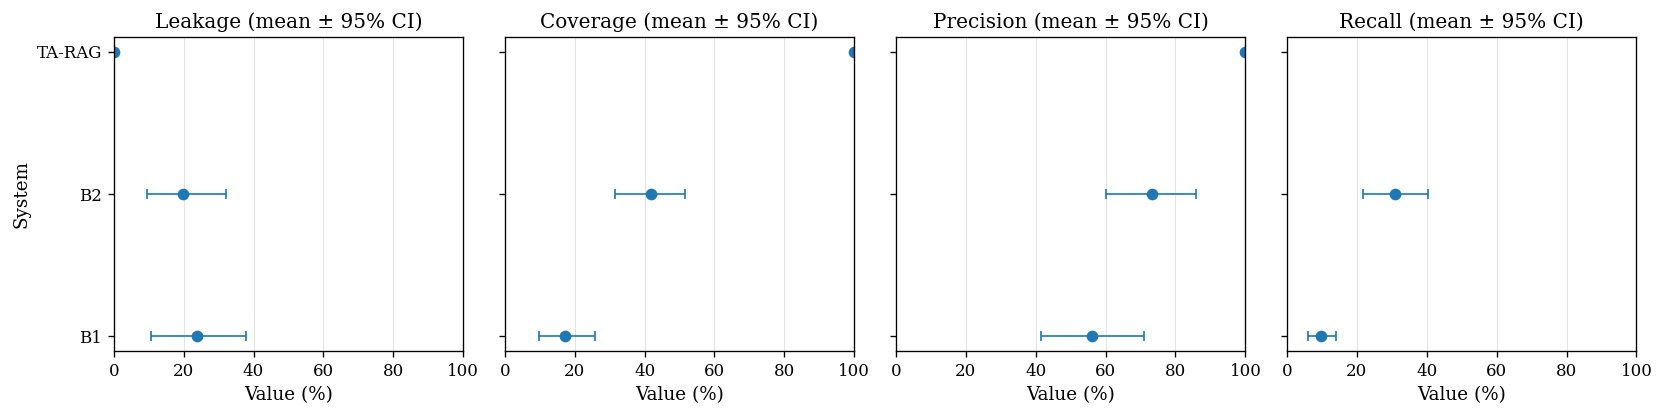

,system,metric,n,mean,std,ci_low,ci_high
0,B1,Leakage,30,23.729333,38.551214,10.660333,37.844333
1,B1,Coverage,40,17.140000,26.290772,9.884700,25.912487
2,B1,Precision,40,56.203000,46.867253,41.544000,71.127250
3,B1,Recall,40,9.687500,13.155989,6.145250,13.959250
4,B2,Leakage,35,19.833714,33.877271,9.533186,32.072986
5,B2,Coverage,40,41.748500,32.799420,31.644163,51.602269
6,B2,Precision,40,73.341500,41.701841,60.060119,85.763169
7,B2,Recall,40,30.807750,30.347661,21.666237,40.262612
8,TA-RAG,Leakage,40,0.000000,0.000000,0.000000,0.000000
9,TA-RAG,Coverage,40,100.000000,0.000000,100.000000,100.000000


In [ ]:
# =========================================
# Figure 1: Overall mean + 95% CI (Forest)
# =========================================
overall = summarize_overall_bootstrap(df_long, n_boot=5000, ci=0.95, base_seed=42)


fig, axes = plt.subplots(1, 4, figsize=(14, 3.6), sharey=True)

for ax, met in zip(axes, METRICS):
    sub = overall[overall["metric"] == met].copy()
    # y positions (top->bottom)
    y_labels = SYSTEM_ORDER
    y_pos = np.arange(len(y_labels))

    means = []
    xerr_low = []
    xerr_high = []

    for sys in y_labels:
        row = sub[sub["system"] == sys].iloc[0]
        mu = row["mean"]
        lo = row["ci_low"]
        hi = row["ci_high"]
        means.append(mu)
        if np.isnan(lo) or np.isnan(hi):
            xerr_low.append(0.0)
            xerr_high.append(0.0)
        else:
            xerr_low.append(mu - lo)
            xerr_high.append(hi - mu)

    # horizontal error bars
    ax.errorbar(
        means, y_pos,
        xerr=[xerr_low, xerr_high],
        fmt="o", capsize=3, linewidth=1.0
    )

    ax.set_title(f"{met} (mean ± 95% CI)")
    ax.set_xlabel("Value (%)")
    ax.grid(True, axis="x", alpha=0.35)
    ax.set_xlim(0, 100)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(y_labels)

axes[0].set_ylabel("System")

plt.tight_layout()
plt.savefig("fig1_overall_forest_mean_ci95.pdf", bbox_inches="tight")
plt.savefig("fig1_overall_forest_mean_ci95.png", bbox_inches="tight")
plt.show()

overall


new figure

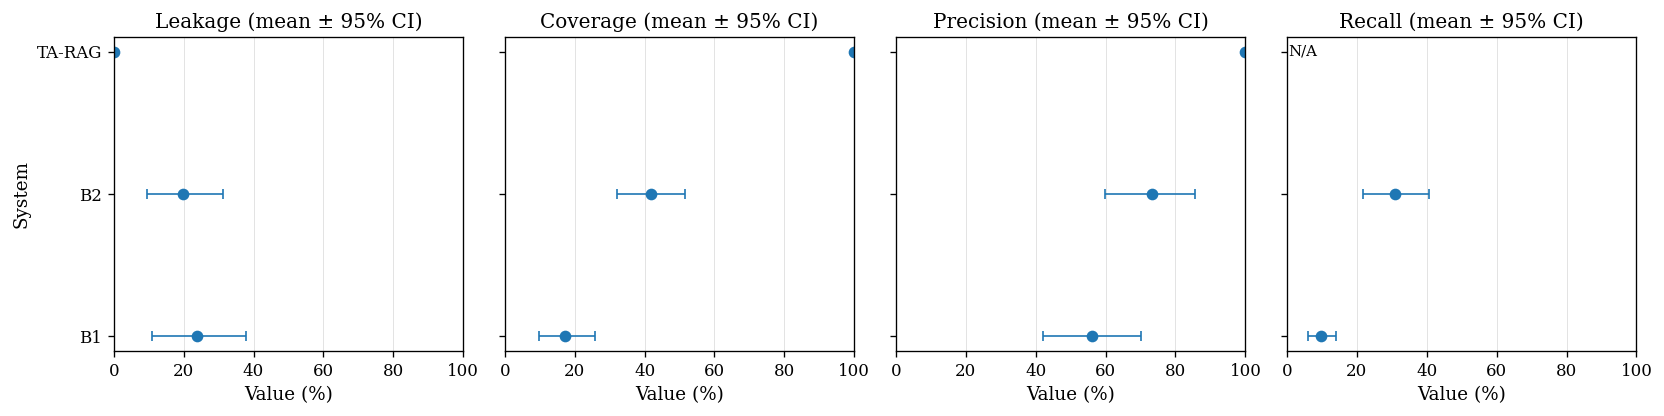

In [ ]:
# =========================================
# Figure 1: Overall mean + 95% CI (Forest)
# Algorithm: Single-system Bootstrap 95% CI for the MEAN (percentile)
# =========================================

overall = summarize_overall_bootstrap(df_long, n_boot=N_BOOT, ci=CI_LEVEL, base_seed=BASE_SEED)

fig, axes = plt.subplots(1, 4, figsize=(14, 3.6), sharey=True)

for ax, met in zip(axes, METRICS):
    sub = overall[overall["metric"] == met].copy()

    y_labels = SYSTEM_ORDER
    y_pos = np.arange(len(y_labels))

    means, xerr_low, xerr_high = [], [], []

    for sys in y_labels:
        row = sub[sub["system"] == sys].iloc[0]
        mu, lo, hi = row["mean"], row["ci_low"], row["ci_high"]

        means.append(mu)

        # If CI is not available (e.g., TA-RAG Recall where n=0 -> NaN),
        # plot point without errorbar (0 length).
        if np.isnan(mu) or np.isnan(lo) or np.isnan(hi):
            xerr_low.append(0.0)
            xerr_high.append(0.0)
        else:
            xerr_low.append(mu - lo)
            xerr_high.append(hi - mu)

    ax.errorbar(
        means, y_pos,
        xerr=[xerr_low, xerr_high],
        fmt="o", capsize=3, linewidth=1.0
    )

    ax.set_title(f"{met} (mean ± 95% CI)")
    ax.set_xlabel("Value (%)")
    ax.grid(True, axis="x", alpha=0.35)

    if met == "Leakage":
        # choose an upper bound based on data (ignore NaNs)
        finite = np.array([m for m in means if not np.isnan(m)], dtype=float)
        if finite.size > 0:
            xmax = max(100.0, float(np.nanmax(finite) + 10.0))
        else:
            xmax = 100.0
        ax.set_xlim(0, xmax)
    else:
        ax.set_xlim(0, 100)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(y_labels)

    for yp, mu in zip(y_pos, means):
        if np.isnan(mu):
            ax.text(0.5, yp, "N/A", va="center", ha="left", fontsize=9)

axes[0].set_ylabel("System")

plt.tight_layout()
plt.savefig("fig1_overall_forest_mean_ci95.pdf", bbox_inches="tight")
plt.savefig("fig1_overall_forest_mean_ci95.png", bbox_inches="tight")
plt.show()

with 4 seperate figures

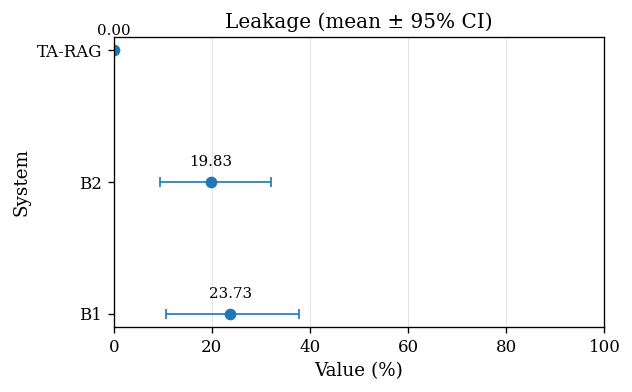

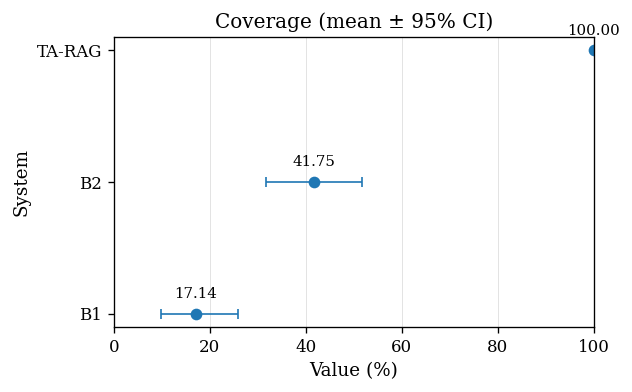

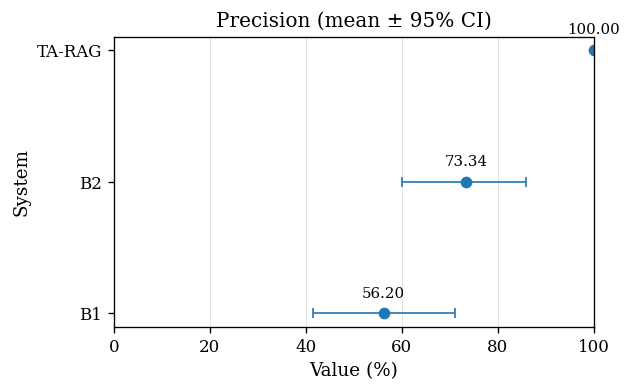

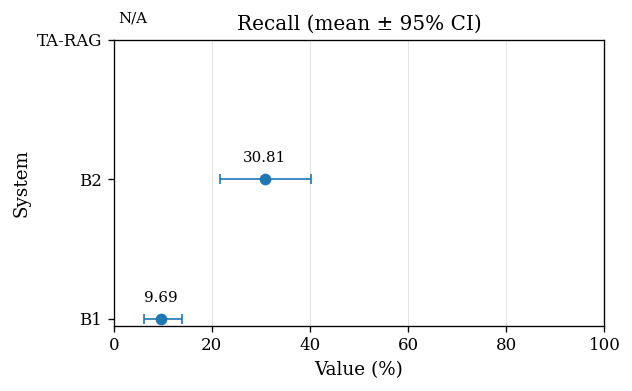

In [ ]:
# =========================================
# Figure 1: FOUR separate forest plots (one per metric)
# =========================================

overall = summarize_overall_bootstrap(df_long, n_boot=N_BOOT, ci=CI_LEVEL, base_seed=BASE_SEED)

for met in METRICS:
    sub = overall[overall["metric"] == met].copy()

    y_labels = SYSTEM_ORDER
    y_pos = np.arange(len(y_labels))

    means, xerr_low, xerr_high = [], [], []

    for sys in y_labels:
        row = sub[sub["system"] == sys].iloc[0]
        mu, lo, hi = row["mean"], row["ci_low"], row["ci_high"]

        means.append(mu)
        if np.isnan(mu) or np.isnan(lo) or np.isnan(hi):
            xerr_low.append(0.0)
            xerr_high.append(0.0)
        else:
            xerr_low.append(mu - lo)
            xerr_high.append(hi - mu)

    fig, ax = plt.subplots(1, 1, figsize=(5.4, 3.4))

    ax.errorbar(
        means, y_pos,
        xerr=[xerr_low, xerr_high],
        fmt="o", capsize=3, linewidth=1.0
    )

    ax.set_title(f"{met} (mean ± 95% CI)")
    ax.set_xlabel("Value (%)")
    ax.set_ylabel("System")
    ax.grid(True, axis="x", alpha=0.35)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(y_labels)
    ax.set_xlim(0, 100)

    # ---- Annotate each point with its mean value ABOVE the point ----
    for x, y in zip(means, y_pos):
        if np.isnan(x):
            ax.text(1.0, y + 0.1, "N/A", va="bottom", ha="left", fontsize=9)
        else:
            ax.text(x, y + 0.1, f"{x:.2f}", va="bottom", ha="center", fontsize=9)

    plt.tight_layout()

    safe_met = met.lower().replace("/", "_").replace(" ", "_")
    plt.savefig(f"fig1_forest_{safe_met}_mean_ci95_label_above.pdf", bbox_inches="tight")
    plt.savefig(f"fig1_forest_{safe_met}_mean_ci95_label_above.png", bbox_inches="tight")
    plt.show()

For paired bootstrap 95 CI

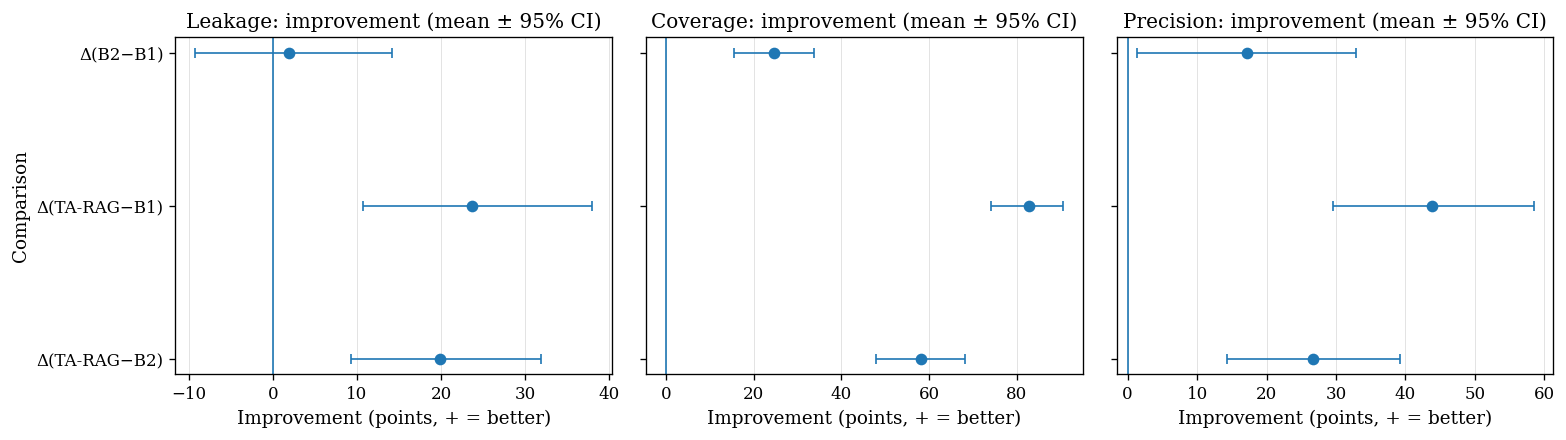

In [ ]:
# =========================================
# Figure: Paired-bootstrap improvement forest (Δ-forest)
# - Uses paired-bootstrap 95% CI from overall_delta
# - Unifies direction so "positive = better" for all metrics:
#     * Leakage (↓): improvement = -(Δ)
#     * Others (↑): improvement = Δ
# =========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = overall_delta.copy()

df = df.dropna(subset=["mean_diff", "ci_low", "ci_high"]).copy()

# Typically: TA-RAG vs B2, TA-RAG vs B1, and B2 vs B1
COMP_ORDER = ["Δ(TA-RAG−B2)", "Δ(TA-RAG−B1)", "Δ(B2−B1)"]
df["delta"] = df["delta"].astype(str)

# Keep only those present
df = df[df["delta"].isin(COMP_ORDER)].copy()


# For Leakage (lower is better): improvement = -Δ
# For other metrics (higher is better): improvement = Δ
df["improve_mean"] = df["mean_diff"]
df["improve_lo"] = df["ci_low"]
df["improve_hi"] = df["ci_high"]

is_leakage = df["metric"].str.lower().eq("leakage")
df.loc[is_leakage, "improve_mean"] = -df.loc[is_leakage, "mean_diff"]
df.loc[is_leakage, "improve_lo"]   = -df.loc[is_leakage, "ci_high"]  # swap because of sign flip
df.loc[is_leakage, "improve_hi"]   = -df.loc[is_leakage, "ci_low"]

# ---- 3) Choose metrics to plot (Recall often has N/A for TA-RAG) ----
METRICS_PLOT = ["Leakage", "Coverage", "Precision"]  # keep Recall separate or omit

# Enforce ordering
df["delta"] = pd.Categorical(df["delta"], categories=COMP_ORDER, ordered=True)

# ---- 4) Plot
fig, axes = plt.subplots(1, len(METRICS_PLOT), figsize=(13.2, 3.8), sharey=True)

if len(METRICS_PLOT) == 1:
    axes = [axes]

for ax, met in zip(axes, METRICS_PLOT):
    sub = df[df["metric"] == met].sort_values("delta").copy()

    y_labels = sub["delta"].astype(str).tolist()
    y_pos = np.arange(len(y_labels))

    means = sub["improve_mean"].to_numpy(dtype=float)
    lo = sub["improve_lo"].to_numpy(dtype=float)
    hi = sub["improve_hi"].to_numpy(dtype=float)

    xerr_low = means - lo
    xerr_high = hi - means

    ax.errorbar(
        means, y_pos,
        xerr=[xerr_low, xerr_high],
        fmt="o", capsize=3, linewidth=1.0
    )

    # Zero line: "no improvement"
    ax.axvline(0.0, linewidth=1.0)

    ax.set_title(f"{met}: improvement (mean ± 95% CI)")
    ax.set_xlabel("Improvement (points, + = better)")
    ax.grid(True, axis="x", alpha=0.35)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(y_labels)

# Shared y label
axes[0].set_ylabel("Comparison")

plt.tight_layout()
plt.savefig("fig_paired_bootstrap_improvement_forest.pdf", bbox_inches="tight")
plt.savefig("fig_paired_bootstrap_improvement_forest.png", bbox_inches="tight")
plt.show()

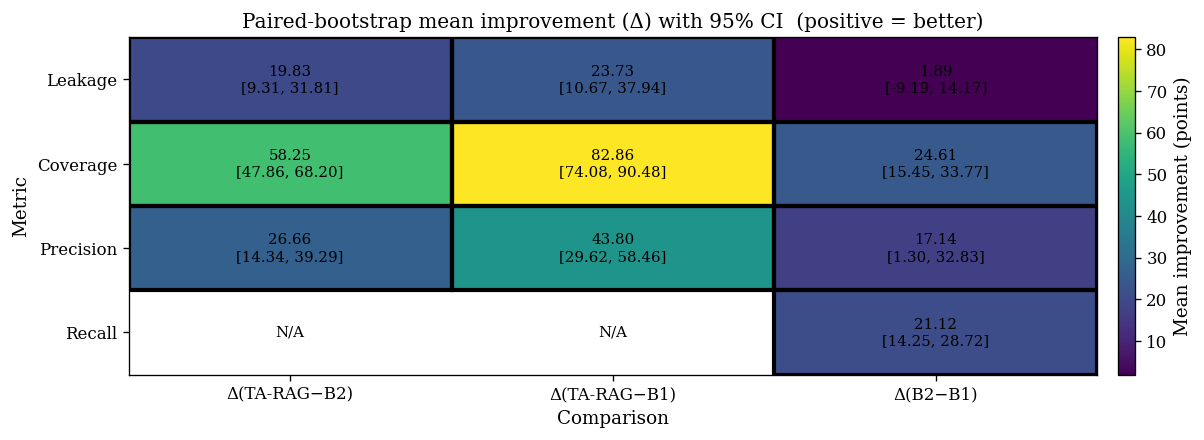

In [ ]:
# =========================================
# Paired-bootstrap improvement HEATMAP -more intuitive
# Input: overall_delta (from summarize_overall_paired_deltas)
# - Unify direction: positive = better for all metrics
#   * Leakage (↓): improvement = -(Δ)
#   * others (↑): improvement = Δ
# - Annotate each cell with: mean [lo, hi]
# =========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- 1) Choose what to show ----
COMP_ORDER = ["Δ(TA-RAG−B2)", "Δ(TA-RAG−B1)", "Δ(B2−B1)"]
METRIC_ORDER = ["Leakage", "Coverage", "Precision", "Recall"]

df = overall_delta.copy()
df["delta"] = df["delta"].astype(str)
df["metric"] = df["metric"].astype(str)

df = df[df["delta"].isin(COMP_ORDER)].copy()

# ---- 2) Build "improvement" values with unified direction (+ = better) ----
# Start from Δ = mean_diff, CI = [ci_low, ci_high]
df["imp_mean"] = df["mean_diff"]
df["imp_lo"]   = df["ci_low"]
df["imp_hi"]   = df["ci_high"]

# Flip sign for Leakage (because lower is better)
mask_leak = df["metric"].str.lower().eq("leakage")
df.loc[mask_leak, "imp_mean"] = -df.loc[mask_leak, "mean_diff"]
# when flipping sign, swap CI endpoints: [-hi, -lo]
df.loc[mask_leak, "imp_lo"]   = -df.loc[mask_leak, "ci_high"]
df.loc[mask_leak, "imp_hi"]   = -df.loc[mask_leak, "ci_low"]

# ---- 3) Pivot into matrices (mean + CI + robustness flag) ----
mean_mat = df.pivot_table(index="metric", columns="delta", values="imp_mean", aggfunc="first")
lo_mat   = df.pivot_table(index="metric", columns="delta", values="imp_lo",   aggfunc="first")
hi_mat   = df.pivot_table(index="metric", columns="delta", values="imp_hi",   aggfunc="first")

# Reindex to desired order
mean_mat = mean_mat.reindex(index=METRIC_ORDER, columns=COMP_ORDER)
lo_mat   = lo_mat.reindex(index=METRIC_ORDER, columns=COMP_ORDER)
hi_mat   = hi_mat.reindex(index=METRIC_ORDER, columns=COMP_ORDER)

# Robust if CI excludes 0
robust = (~mean_mat.isna()) & (~lo_mat.isna()) & (~hi_mat.isna()) & ((lo_mat > 0) | (hi_mat < 0))

# ---- 4) Plot heatmap ----
Z = mean_mat.to_numpy(dtype=float)

fig, ax = plt.subplots(figsize=(10.2, 3.8))

# Use a diverging colormap to show positive vs negative improvements.
im = ax.imshow(Z, aspect="auto")

# ticks/labels
ax.set_xticks(np.arange(len(COMP_ORDER)))
ax.set_yticks(np.arange(len(METRIC_ORDER)))
ax.set_xticklabels(COMP_ORDER, rotation=0)
ax.set_yticklabels(METRIC_ORDER)

ax.set_title("Paired-bootstrap mean improvement (Δ) with 95% CI  (positive = better)")
ax.set_xlabel("Comparison")
ax.set_ylabel("Metric")

# colorbar
cbar = plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
cbar.set_label("Mean improvement (points)")

# ---- 5) Annotate each cell with mean and CI, and draw robustness borders ----
for i, met in enumerate(METRIC_ORDER):
    for j, comp in enumerate(COMP_ORDER):
        mu = mean_mat.loc[met, comp]
        lo = lo_mat.loc[met, comp]
        hi = hi_mat.loc[met, comp]

        if pd.isna(mu) or pd.isna(lo) or pd.isna(hi):
            txt = "N/A"
        else:
            txt = f"{mu:.2f}\n[{lo:.2f}, {hi:.2f}]"

        ax.text(j, i, txt, ha="center", va="center", fontsize=9)

        # Draw a rectangle: thick if robust, thin otherwise (when not N/A)
        if not (pd.isna(mu) or pd.isna(lo) or pd.isna(hi)):
            is_rob = bool(robust.loc[met, comp])
            lw = 2.5 if is_rob else 0.8
            rect = plt.Rectangle((j - 0.5, i - 0.5), 1.0, 1.0, fill=False, linewidth=lw)
            ax.add_patch(rect)

plt.tight_layout()
plt.savefig("fig_paired_bootstrap_improvement_heatmap.pdf", bbox_inches="tight")
plt.savefig("fig_paired_bootstrap_improvement_heatmap.png", bbox_inches="tight")
plt.show()

some minor modifies, and this is the final version.

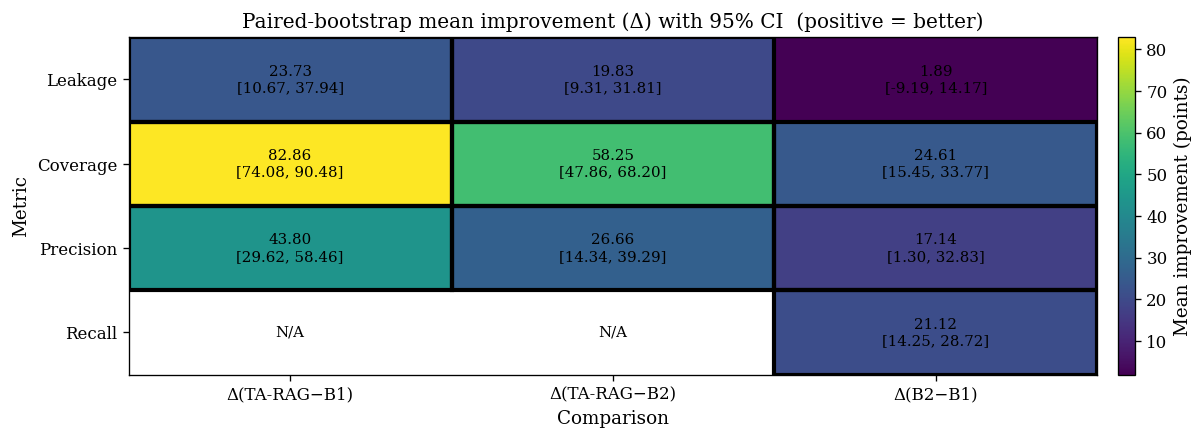

In [ ]:
# ---- 1) Choose what to show ----
# Put -B1 first, then -B2, then B2-B1
COMP_ORDER = ["Δ(TA-RAG−B1)", "Δ(TA-RAG−B2)", "Δ(B2−B1)"]
METRIC_ORDER = ["Leakage", "Coverage", "Precision", "Recall"]

df = overall_delta.copy()
df["delta"] = df["delta"].astype(str)
df["metric"] = df["metric"].astype(str)

df = df[df["delta"].isin(COMP_ORDER)].copy()

# ---- 2) Build "improvement" values with unified direction (+ = better) ----
df["imp_mean"] = df["mean_diff"]
df["imp_lo"]   = df["ci_low"]
df["imp_hi"]   = df["ci_high"]

# Flip sign for Leakage (because lower is better)
mask_leak = df["metric"].str.lower().eq("leakage")
df.loc[mask_leak, "imp_mean"] = -df.loc[mask_leak, "mean_diff"]
df.loc[mask_leak, "imp_lo"]   = -df.loc[mask_leak, "ci_high"]
df.loc[mask_leak, "imp_hi"]   = -df.loc[mask_leak, "ci_low"]

# ---- 3) Pivot into matrices (mean + CI + robustness flag) ----
mean_mat = df.pivot_table(index="metric", columns="delta", values="imp_mean", aggfunc="first")
lo_mat   = df.pivot_table(index="metric", columns="delta", values="imp_lo",   aggfunc="first")
hi_mat   = df.pivot_table(index="metric", columns="delta", values="imp_hi",   aggfunc="first")

# Reindex to desired order (this enforces the column order)
mean_mat = mean_mat.reindex(index=METRIC_ORDER, columns=COMP_ORDER)
lo_mat   = lo_mat.reindex(index=METRIC_ORDER, columns=COMP_ORDER)
hi_mat   = hi_mat.reindex(index=METRIC_ORDER, columns=COMP_ORDER)

# Robust if CI excludes 0
robust = (~mean_mat.isna()) & (~lo_mat.isna()) & (~hi_mat.isna()) & ((lo_mat > 0) | (hi_mat < 0))

# ---- 4) Plot heatmap ----
Z = mean_mat.to_numpy(dtype=float)

fig, ax = plt.subplots(figsize=(10.2, 3.8))
im = ax.imshow(Z, aspect="auto")

# ticks/labels
ax.set_xticks(np.arange(len(COMP_ORDER)))
ax.set_yticks(np.arange(len(METRIC_ORDER)))
ax.set_xticklabels(COMP_ORDER, rotation=0)
ax.set_yticklabels(METRIC_ORDER)

ax.set_title("Paired-bootstrap mean improvement (Δ) with 95% CI  (positive = better)")
ax.set_xlabel("Comparison")
ax.set_ylabel("Metric")

# colorbar
cbar = plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
cbar.set_label("Mean improvement (points)")

# ---- 5) Annotate each cell with mean and CI, and draw robustness borders ----
for i, met in enumerate(METRIC_ORDER):
    for j, comp in enumerate(COMP_ORDER):
        mu = mean_mat.loc[met, comp]
        lo = lo_mat.loc[met, comp]
        hi = hi_mat.loc[met, comp]

        if pd.isna(mu) or pd.isna(lo) or pd.isna(hi):
            txt = "N/A"
        else:
            txt = f"{mu:.2f}\n[{lo:.2f}, {hi:.2f}]"

        ax.text(j, i, txt, ha="center", va="center", fontsize=9)

        if not (pd.isna(mu) or pd.isna(lo) or pd.isna(hi)):
            lw = 2.5 if bool(robust.loc[met, comp]) else 0.8
            rect = plt.Rectangle((j - 0.5, i - 0.5), 1.0, 1.0, fill=False, linewidth=lw)
            ax.add_patch(rect)

plt.tight_layout()
plt.savefig("fig_paired_bootstrap_improvement_heatmap.pdf", bbox_inches="tight")
plt.savefig("fig_paired_bootstrap_improvement_heatmap.png", bbox_inches="tight")
plt.show()

Improve the font size and change the colour contrast of numbers over the cells colour.

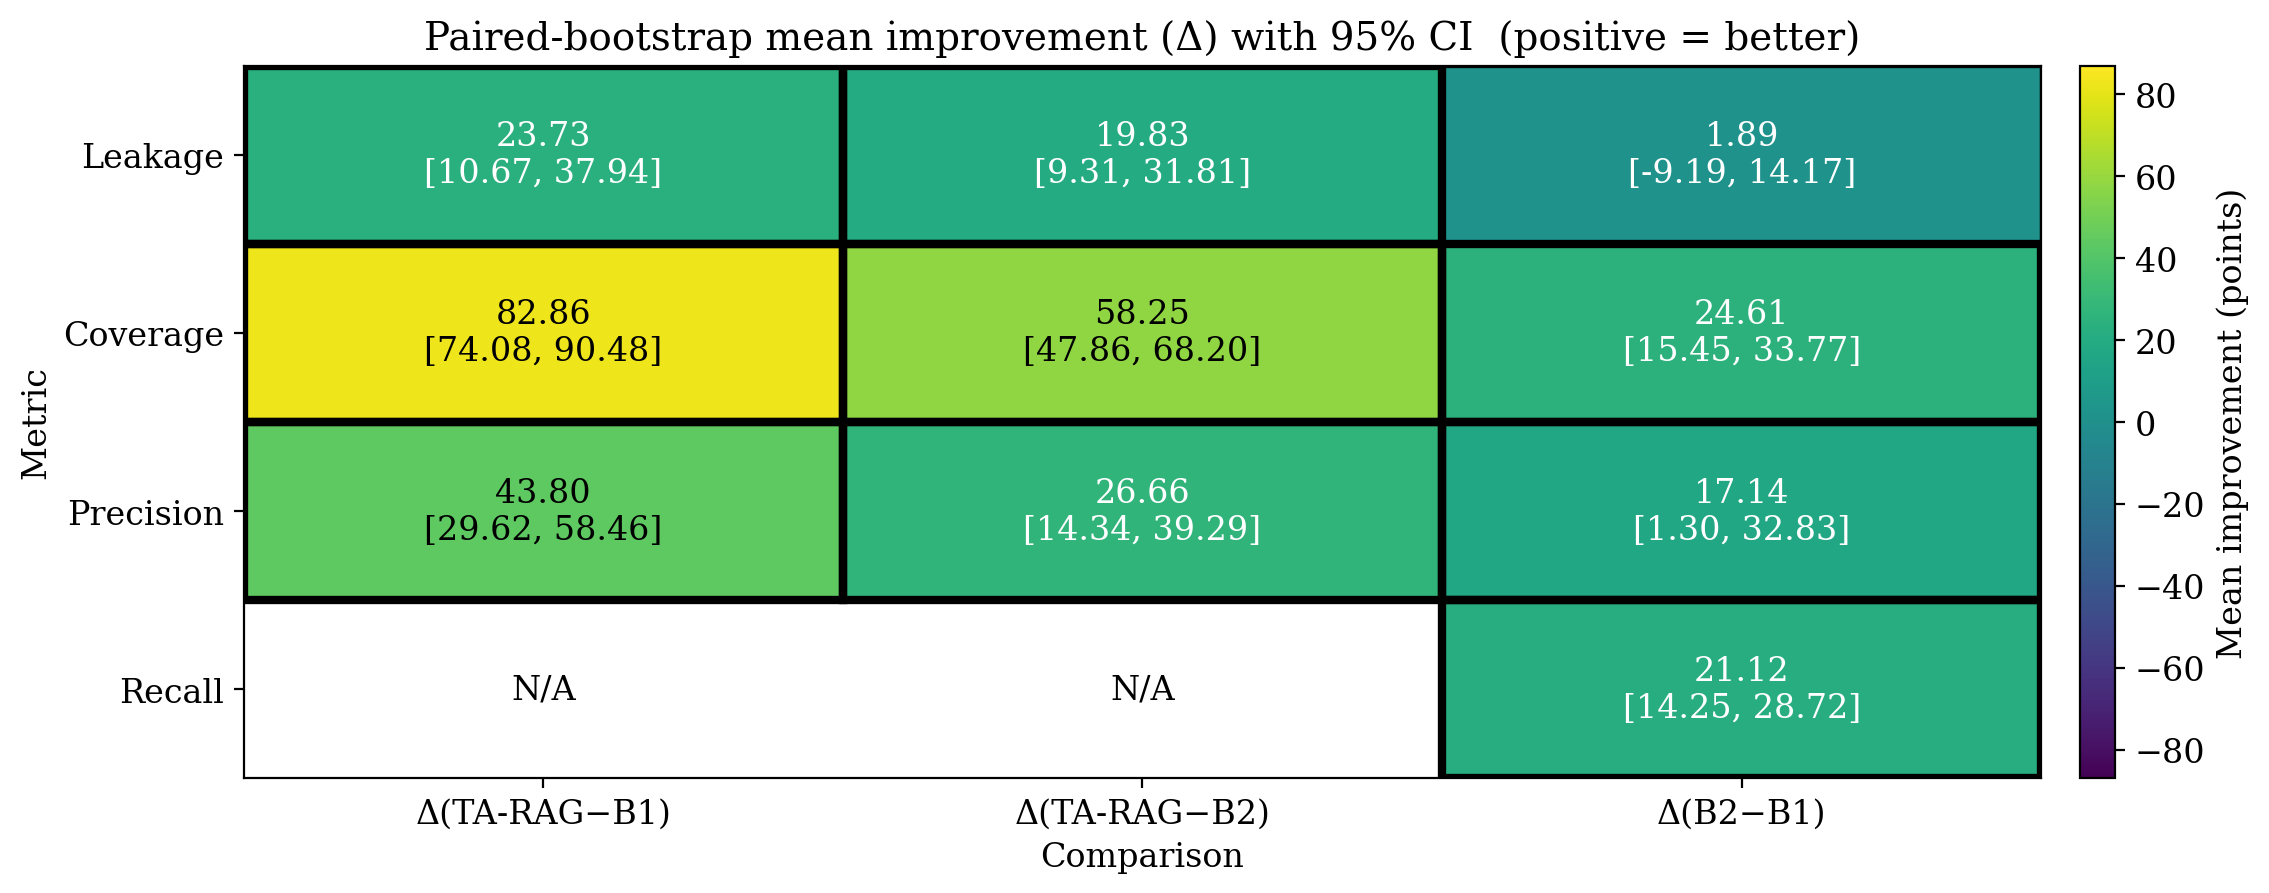

In [ ]:
# =========================================
# Executive-summary
# - Larger fonts and figure
# - Adaptive annotation color (white on dark, black on bright)
# - Better contrast via centered colormap normalization
# =========================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ---- Styling knobs for executive summary ----
FIG_W, FIG_H = 11.5, 4.6
ANN_FONTSIZE = 12
TICK_FONTSIZE = 12
TITLE_FONTSIZE = 14
CBAR_FONTSIZE = 12
BORDER_THIN = 1.2
BORDER_THICK = 3.0

# ---- Build Z safely ----
Z = mean_mat.to_numpy(dtype=float)

# ---- Colormap: center at 0 for interpretability (positive=better) ----
# Use a symmetric range around 0 based on finite values.
finite = Z[np.isfinite(Z)]
if finite.size == 0:
    v = 1.0
else:
    v = float(np.max(np.abs(finite)))
# Slight padding to avoid saturating max cell
vmax = max(1.0, v * 1.05)
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

fig, ax = plt.subplots(figsize=(FIG_W, FIG_H), dpi=200)

im = ax.imshow(Z, aspect="auto", norm=norm)

# ticks/labels
ax.set_xticks(np.arange(len(COMP_ORDER)))
ax.set_yticks(np.arange(len(METRIC_ORDER)))
ax.set_xticklabels(COMP_ORDER, rotation=0, fontsize=TICK_FONTSIZE)
ax.set_yticklabels(METRIC_ORDER, fontsize=TICK_FONTSIZE)

ax.set_title("Paired-bootstrap mean improvement (Δ) with 95% CI  (positive = better)",
             fontsize=TITLE_FONTSIZE)
ax.set_xlabel("Comparison", fontsize=TICK_FONTSIZE)
ax.set_ylabel("Metric", fontsize=TICK_FONTSIZE)

# colorbar
cbar = plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
cbar.set_label("Mean improvement (points)", fontsize=CBAR_FONTSIZE)
cbar.ax.tick_params(labelsize=CBAR_FONTSIZE)

# ---- choose white/black text based on background luminance ----
cmap = im.get_cmap()
def _text_color(val):
    # map value -> RGBA -> perceived luminance
    rgba = cmap(norm(val))  # (r,g,b,a)
    r, g, b = rgba[:3]
    lum = 0.2126*r + 0.7152*g + 0.0722*b
    return "black" if lum > 0.6 else "white"

# ---- Annotate cells + draw borders ----
for i, met in enumerate(METRIC_ORDER):
    for j, comp in enumerate(COMP_ORDER):
        mu = mean_mat.loc[met, comp]
        lo = lo_mat.loc[met, comp]
        hi = hi_mat.loc[met, comp]

        if np.isnan(mu) or np.isnan(lo) or np.isnan(hi):
            txt = "N/A"
            color = "black"
        else:
            txt = f"{mu:.2f}\n[{lo:.2f}, {hi:.2f}]"
            color = _text_color(mu)

        ax.text(j, i, txt, ha="center", va="center",
                fontsize=ANN_FONTSIZE, color=color)

        if not (np.isnan(mu) or np.isnan(lo) or np.isnan(hi)):
            is_rob = bool(robust.loc[met, comp])
            lw = BORDER_THICK if is_rob else BORDER_THIN
            rect = plt.Rectangle((j - 0.5, i - 0.5), 1.0, 1.0,
                                 fill=False, linewidth=lw, edgecolor="black")
            ax.add_patch(rect)

plt.tight_layout()
plt.savefig("fig_paired_bootstrap_improvement_heatmap_exec.pdf", bbox_inches="tight")
plt.savefig("fig_paired_bootstrap_improvement_heatmap_exec.png", bbox_inches="tight")
plt.show()

/tmp/ipython-input-2618873363.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


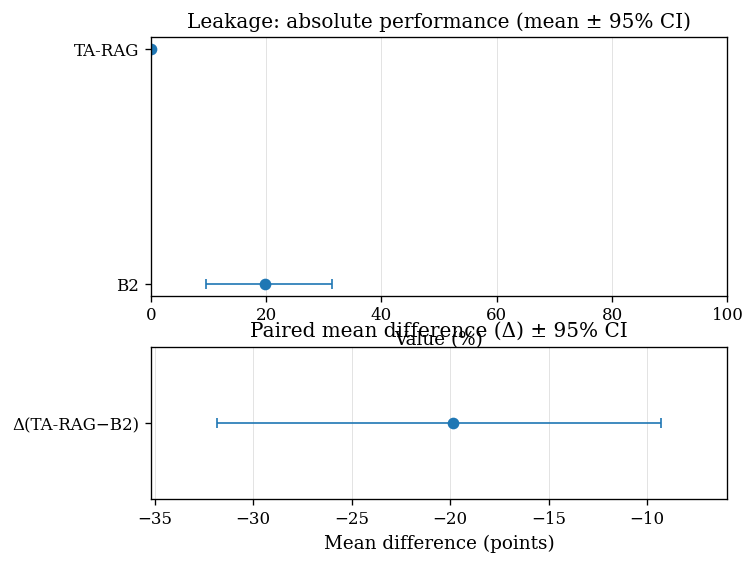

/tmp/ipython-input-2618873363.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


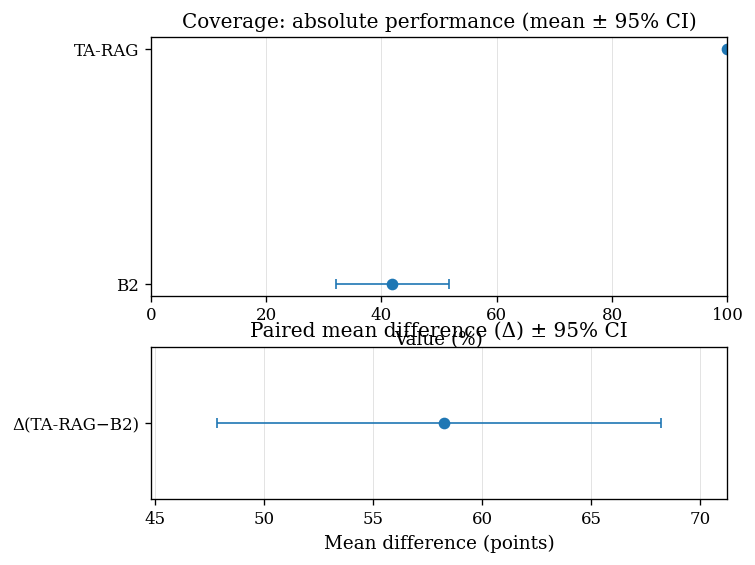

/tmp/ipython-input-2618873363.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


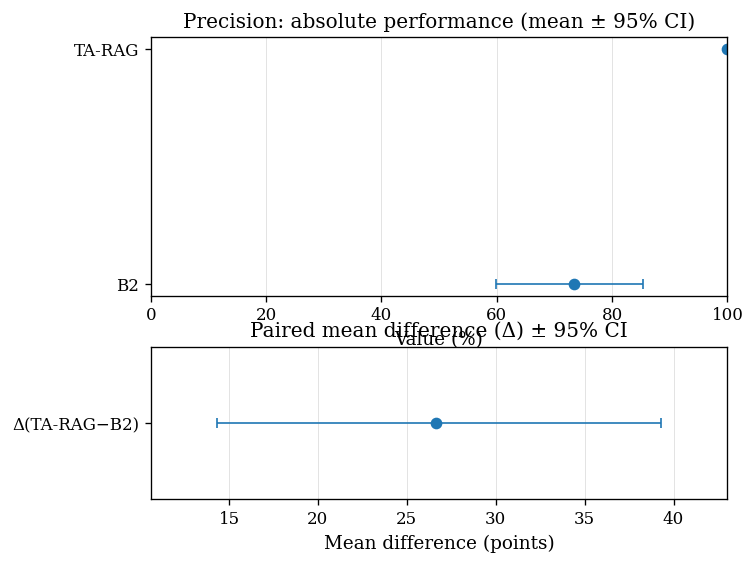

In [ ]:
# =========================================
# plot:
#   Top: A and B absolute mean ± 95% CI
#   Bottom: paired mean difference Δ(A−B) ± 95% CI
# Inputs:
#   overall_single : single-system bootstrap mean CIs (Table 4.5)
#   overall_delta  : paired-bootstrap delta CIs (Table 4.6)
# =========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- choose comparison and metrics ----
A, B = "TA-RAG", "B2"
DELTA_LABEL = f"Δ({A}−{B})"
METRICS_PLOT = ["Leakage", "Coverage", "Precision"]
def _get_single_ci(single_df, system, metric):
    r = single_df[(single_df["system"] == system) & (single_df["metric"] == metric)].iloc[0]
    return float(r["mean"]), float(r["ci_low"]), float(r["ci_high"])

def _get_delta_ci(delta_df, delta_label, metric):
    r = delta_df[(delta_df["delta"] == delta_label) & (delta_df["metric"] == metric)].iloc[0]
    return float(r["mean_diff"]), float(r["ci_low"]), float(r["ci_high"])

for met in METRICS_PLOT:
    # absolute means (single-system)
    muA, loA, hiA = _get_single_ci(overall_single, A, met)
    muB, loB, hiB = _get_single_ci(overall_single, B, met)

    # paired delta
    dmu, dlo, dhi = _get_delta_ci(overall_delta, DELTA_LABEL, met)

    fig = plt.figure(figsize=(6.2, 5.0))
    gs = fig.add_gridspec(2, 1, height_ratios=[2.2, 1.3], hspace=0.25)

    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[1, 0])

    systems = [B, A]
    y = np.arange(len(systems))

    means = [muB, muA]
    los = [loB, loA]
    his = [hiB, hiA]

    xerr_low = [m - l for m, l in zip(means, los)]
    xerr_high = [h - m for m, h in zip(means, his)]

    ax1.errorbar(means, y, xerr=[xerr_low, xerr_high], fmt="o", capsize=3, linewidth=1.0)
    ax1.set_yticks(y)
    ax1.set_yticklabels(systems)
    ax1.set_xlabel("Value (%)")
    ax1.set_title(f"{met}: absolute performance (mean ± 95% CI)")
    ax1.grid(True, axis="x", alpha=0.35)
    ax1.set_xlim(0, 100)

    # -------- bottom panel: paired difference --------
    # Center at 0 to show direction
    ax2.errorbar([dmu], [0], xerr=[[dmu - dlo], [dhi - dmu]], fmt="o", capsize=3, linewidth=1.0)
    ax2.axvline(0.0, linewidth=1.0)
    ax2.set_yticks([0])
    ax2.set_yticklabels([DELTA_LABEL])
    ax2.set_xlabel("Mean difference (points)")
    ax2.set_title("Paired mean difference (Δ) ± 95% CI")
    ax2.grid(True, axis="x", alpha=0.35)

    # Nice x-range for delta panel
    xmin = min(dlo, dmu, dhi)
    xmax = max(dlo, dmu, dhi)
    pad = 0.15 * (xmax - xmin + 1e-9)
    ax2.set_xlim(xmin - pad, xmax + pad)

    plt.tight_layout()
    safe_met = met.lower()
    plt.savefig(f"fig_estimation_{safe_met}_{A}_vs_{B}.pdf", bbox_inches="tight")
    plt.savefig(f"fig_estimation_{safe_met}_{A}_vs_{B}.png", bbox_inches="tight")
    plt.show()

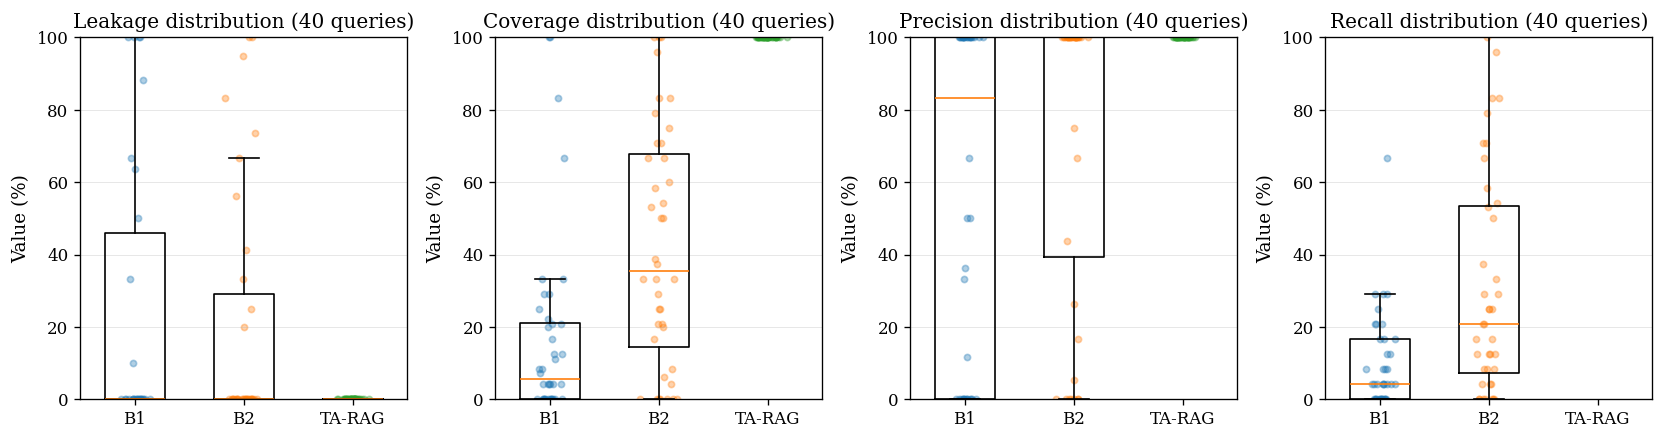

In [ ]:
# ==========================================================
# Figure 2: Boxplot distribution over 40 queries (per metric)
# ==========================================================
# Filter to the 40-query set if needed (here we assume df_long already contains them)

fig, axes = plt.subplots(1, 4, figsize=(14, 3.8), sharey=False)

for ax, met in zip(axes, METRICS):
    sub = df_long[df_long["metric"] == met].copy()
    # order systems
    data = []
    tick_labels = []
    for sys in SYSTEM_ORDER:
        vals = sub[sub["system"] == sys]["value"].dropna().to_numpy()
        data.append(vals)
        tick_labels.append(sys)

    # Boxplot
    bp = ax.boxplot(
        data,
        tick_labels=tick_labels,
        showfliers=False,
        widths=0.55
    )

    # Overlay jittered points for transparency (no manual colors)
    for i, vals in enumerate(data, start=1):
        if len(vals) == 0:
            continue
        x = np.random.normal(loc=i, scale=0.06, size=len(vals))
        ax.scatter(x, vals, s=14, alpha=0.35)

    ax.set_title(f"{met} distribution (40 queries)")
    ax.set_ylabel("Value (%)")
    ax.grid(True, axis="y", alpha=0.30)
    ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig("fig2_overall_boxplot_distributions.pdf", bbox_inches="tight")
plt.savefig("fig2_overall_boxplot_distributions.png", bbox_inches="tight")
plt.show()

with 4 seperate figures

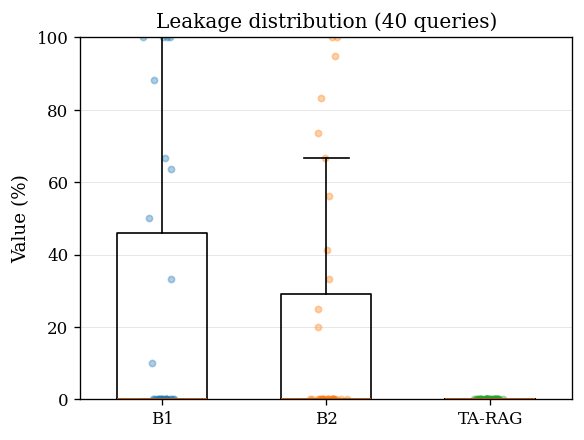

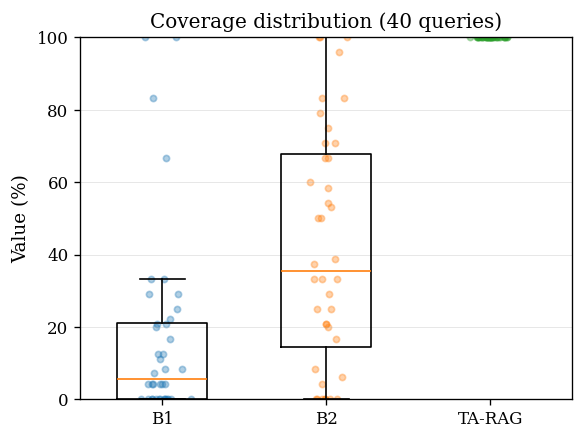

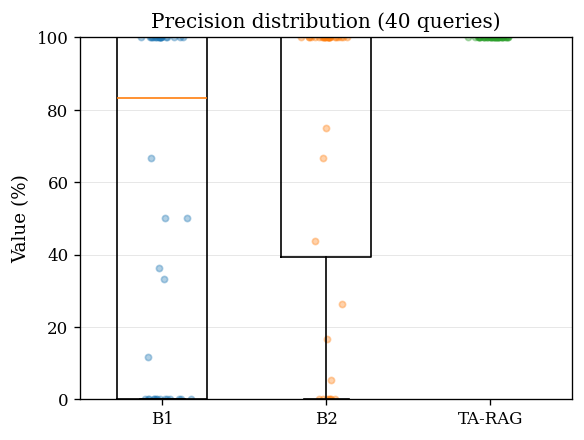

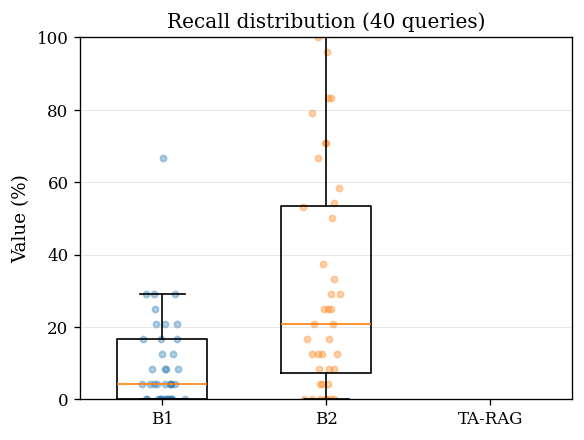

In [ ]:
# ==========================================================
# Figure 2: Boxplot distribution over 40 queries (per metric)
# ==========================================================

rng = np.random.default_rng(42)

for met in METRICS:
    sub = df_long[df_long["metric"] == met].copy()

    # order systems
    data = []
    tick_labels = []
    for sys in SYSTEM_ORDER:
        vals = sub[sub["system"] == sys]["value"].dropna().to_numpy()
        data.append(vals)
        tick_labels.append(sys)

    # --- one figure per metric ---
    fig, ax = plt.subplots(figsize=(5.0, 3.8))

    # Boxplot
    ax.boxplot(
        data,
        tick_labels=tick_labels,
        showfliers=False,
        widths=0.55
    )

    for i, vals in enumerate(data, start=1):
        if len(vals) == 0:
            continue
        x = rng.normal(loc=i, scale=0.06, size=len(vals))
        ax.scatter(x, vals, s=14, alpha=0.35)

    ax.set_title(f"{met} distribution (40 queries)")
    ax.set_ylabel("Value (%)")
    ax.grid(True, axis="y", alpha=0.30)
    ax.set_ylim(0, 100)

    plt.tight_layout()

    safe_met = met.lower().replace(" ", "_").replace("/", "_")
    plt.savefig(f"fig2_{safe_met}_boxplot_distribution.pdf", bbox_inches="tight")
    plt.savefig(f"fig2_{safe_met}_boxplot_distribution.png", bbox_inches="tight")

    plt.show()
    plt.close(fig)


distrubution figure and IQR without the whiskers/caps/median line, and with fixed seed.

/tmp/ipython-input-241/1114904917.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


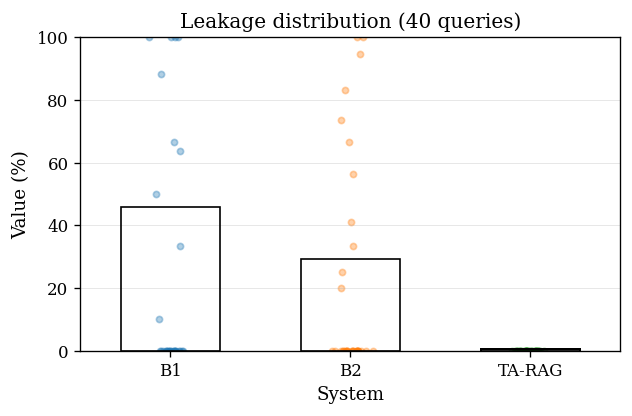

/tmp/ipython-input-241/1114904917.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


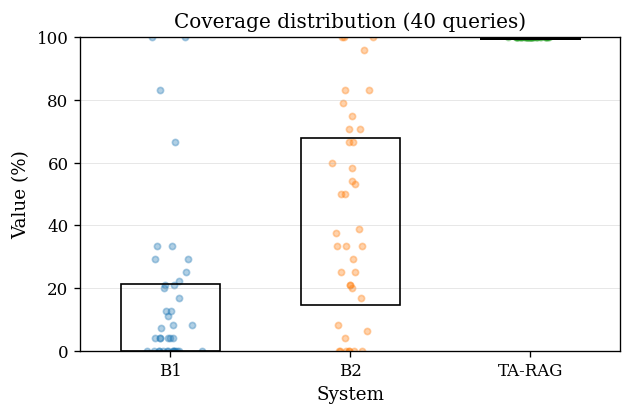

/tmp/ipython-input-241/1114904917.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


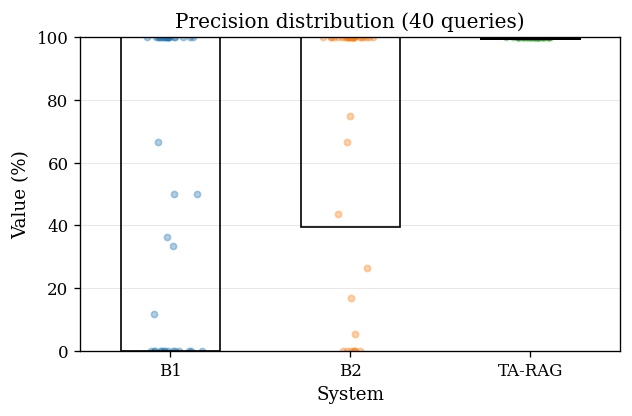

/tmp/ipython-input-241/1114904917.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


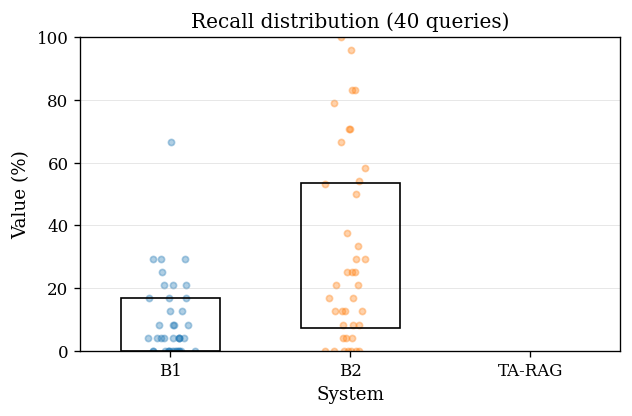

In [ ]:
# ==========================================================
# Figure 2 :
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt

JITTER_SEED = 42
rng = np.random.default_rng(JITTER_SEED)

EPS_Y = 1.2

for met in METRICS:
    sub = df_long[df_long["metric"] == met].copy()

    data = []
    tick_labels = []
    for sys in SYSTEM_ORDER:
        vals = sub[sub["system"] == sys]["value"].dropna().to_numpy(dtype=float)
        data.append(vals)
        tick_labels.append(sys)

    fig, ax = plt.subplots(1, 1, figsize=(5.4, 3.6))

    # ---- Boxplot: IQR only
    bp = ax.boxplot(
        data,
        labels=tick_labels,
        showfliers=False,
        widths=0.55,
        patch_artist=True,
        whis=0
    )

    for b in bp["boxes"]:
        b.set_facecolor((1, 1, 1, 0.0))  # fully transparent
        b.set_linewidth(1.0)

    # Hide whiskers, caps, and median line
    for w in bp["whiskers"]:
        w.set_linewidth(0)
    for c in bp["caps"]:
        c.set_linewidth(0)
    for m in bp["medians"]:
        m.set_linewidth(0)

    # ---- Overlay jittered points (fixed seed) ----
    for i, vals in enumerate(data, start=1):
        if len(vals) == 0:
            continue

        x = rng.normal(loc=i, scale=0.06, size=len(vals))
        ax.scatter(x, vals, s=14, alpha=0.35)

        # We draw a tiny rectangle centered at that value to indicate "collapsed IQR".
        if np.allclose(vals, vals[0]):
            y0 = float(vals[0])
            rect = plt.Rectangle(
                (i - 0.275, y0 - EPS_Y/2),   # x, y
                0.55,                        # width (match boxplot width)
                EPS_Y,                       # tiny height
                fill=False,
                linewidth=1.2
            )
            ax.add_patch(rect)

    ax.set_title(f"{met} distribution (40 queries)")
    ax.set_xlabel("System")
    ax.set_ylabel("Value (%)")
    ax.grid(True, axis="y", alpha=0.30)
    ax.set_ylim(0, 100)

    plt.tight_layout()

    safe_met = met.lower().replace("/", "_").replace(" ", "_")
    plt.savefig(f"fig2_box_iqronly_{safe_met}.pdf", bbox_inches="tight")
    plt.savefig(f"fig2_box_iqronly_{safe_met}.png", bbox_inches="tight")
    plt.show()

4723.figure 3 Per-family grouped bars (A–E) WITHOUT 95% CI whiskers

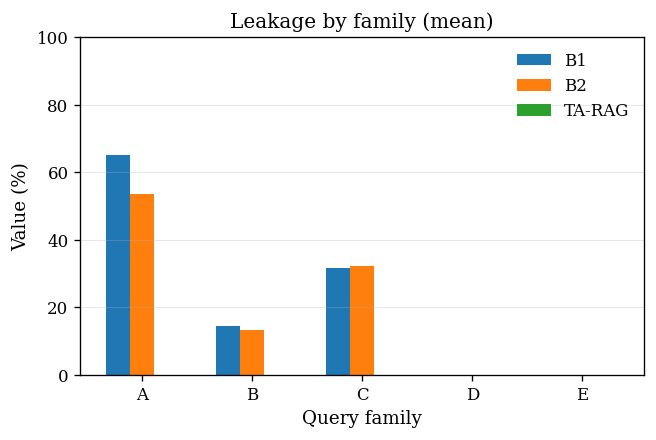

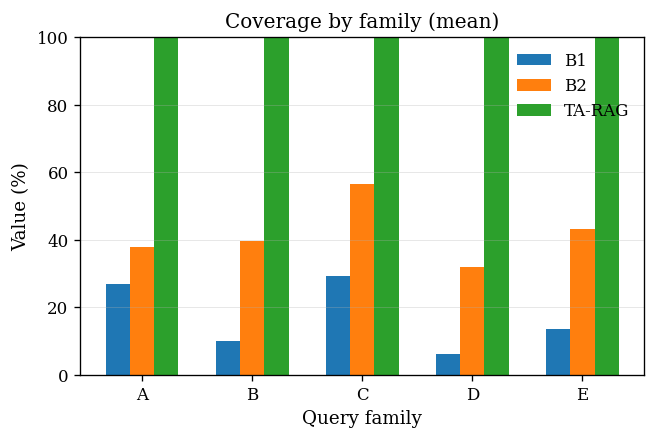

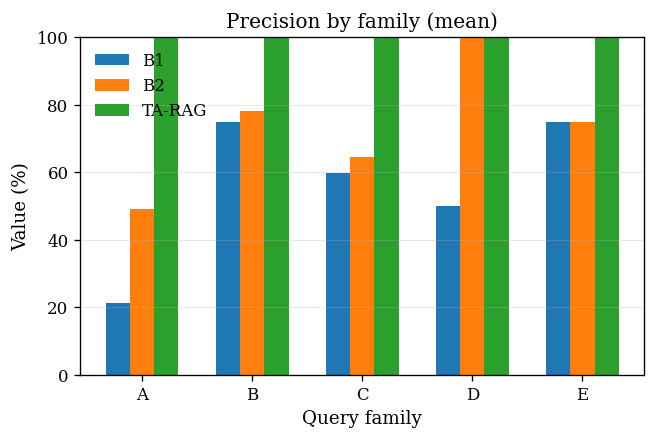

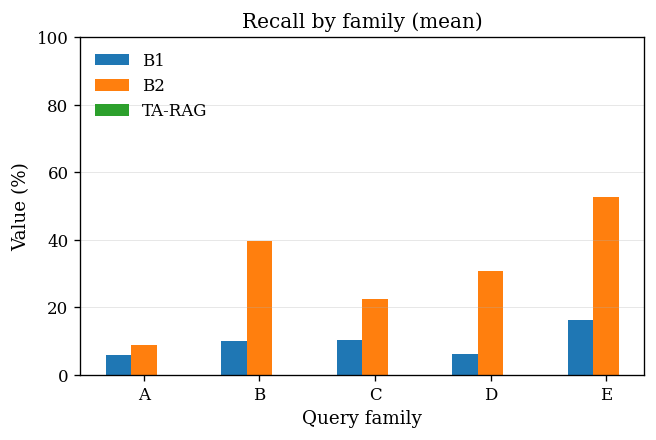

,family,system,metric,n,mean,std,ci_low,ci_high
0,A,B1,Leakage,6,65.051667,33.777574,39.986125,88.385000
1,A,B1,Coverage,8,26.805000,40.916739,3.888750,56.248750
2,A,B1,Precision,8,21.211250,23.402080,6.250000,36.172500
3,A,B1,Recall,8,5.730000,8.317158,1.040000,11.460000
4,A,B2,Leakage,7,53.571429,44.580437,22.620000,83.332857
5,A,B2,Coverage,8,37.707500,37.932145,13.541250,62.707500
6,A,B2,Precision,8,48.958750,48.883557,16.667500,81.250000
7,A,B2,Recall,8,8.853750,8.750737,3.125000,15.103750
8,A,TA-RAG,Leakage,8,0.000000,0.000000,0.000000,0.000000
9,A,TA-RAG,Coverage,8,100.000000,0.000000,100.000000,100.000000


Saved: fig3_byfamily_summary_bootstrap_ci95.csv


In [ ]:
# =========================================================
# Figure 3: Per-family grouped bars (A–E) WITHOUT 95% CI whiskers
# =========================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# 1) compute per-family summary (bootstrap version)
byfam = summarize_by_family_bootstrap(df_long, n_boot=5000, ci=0.95, base_seed=42)

bar_width = 0.22
x = np.arange(len(FAMILY_ORDER))

# 2) plot: one figure per metric
for met in METRICS:
    sub = byfam[byfam["metric"] == met].copy()

    fig, ax = plt.subplots(1, 1, figsize=(5.6, 3.8))

    for j, sys in enumerate(SYSTEM_ORDER):
        sys_sub = sub[sub["system"] == sys].set_index("family").reindex(FAMILY_ORDER)
        means = sys_sub["mean"].to_numpy(dtype=float)

        ax.bar(
            x + (j - 1) * bar_width,
            means,
            width=bar_width,
            label=sys,
        )

    ax.set_title(f"{met} by family (mean)")
    ax.set_xticks(x)
    ax.set_xticklabels(FAMILY_ORDER)
    ax.set_xlabel("Query family")
    ax.set_ylabel("Value (%)")
    ax.set_ylim(0, 100)
    ax.grid(True, axis="y", alpha=0.30)
    ax.legend(frameon=False)

    plt.tight_layout()
    safe_met = met.lower().replace("/", "_").replace(" ", "_")
    plt.savefig(f"fig3_byfamily_{safe_met}_mean_only.pdf", bbox_inches="tight")
    plt.savefig(f"fig3_byfamily_{safe_met}_mean_only.png", bbox_inches="tight")
    plt.show()

# 3) table output
byfam_show = byfam.copy()
byfam_show["family"] = pd.Categorical(byfam_show["family"], categories=FAMILY_ORDER, ordered=True)
byfam_show["system"] = pd.Categorical(byfam_show["system"], categories=SYSTEM_ORDER, ordered=True)
byfam_show["metric"] = pd.Categorical(byfam_show["metric"], categories=METRICS, ordered=True)
byfam_show = byfam_show.sort_values(["family", "system", "metric"]).reset_index(drop=True)

for c in ["mean", "std", "ci_low", "ci_high"]:
    if c in byfam_show.columns:
        byfam_show[c] = byfam_show[c].map(lambda v: np.nan if pd.isna(v) else round(float(v), 6))

display(byfam_show)
byfam_show.to_csv("fig3_byfamily_summary_bootstrap_ci95.csv", index=False)
print("Saved: fig3_byfamily_summary_bootstrap_ci95.csv")

This is the old version for 4 figures

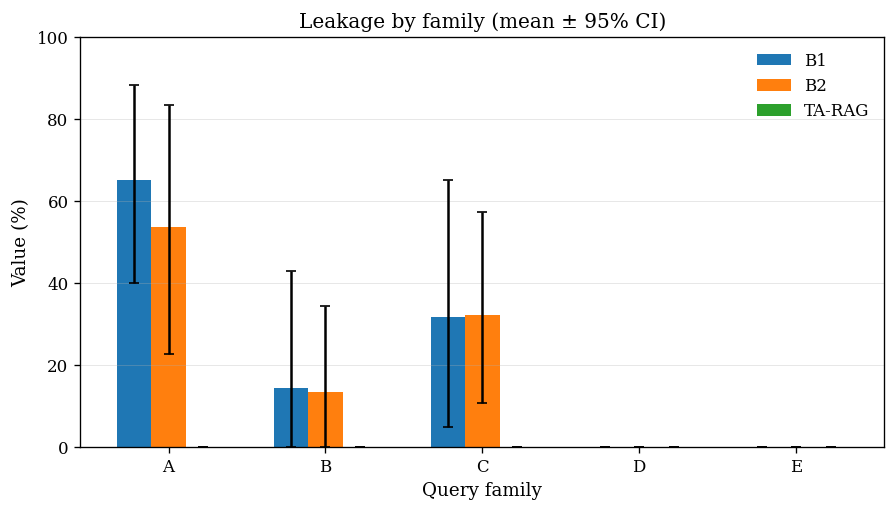

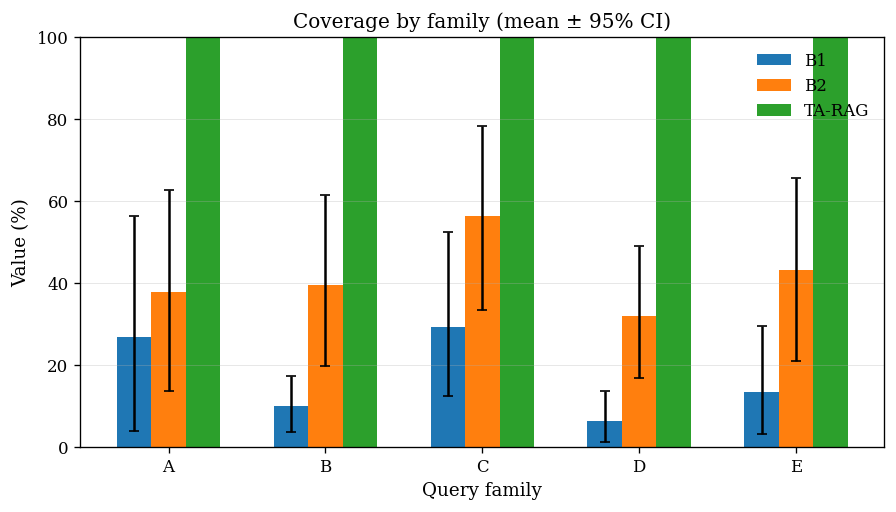

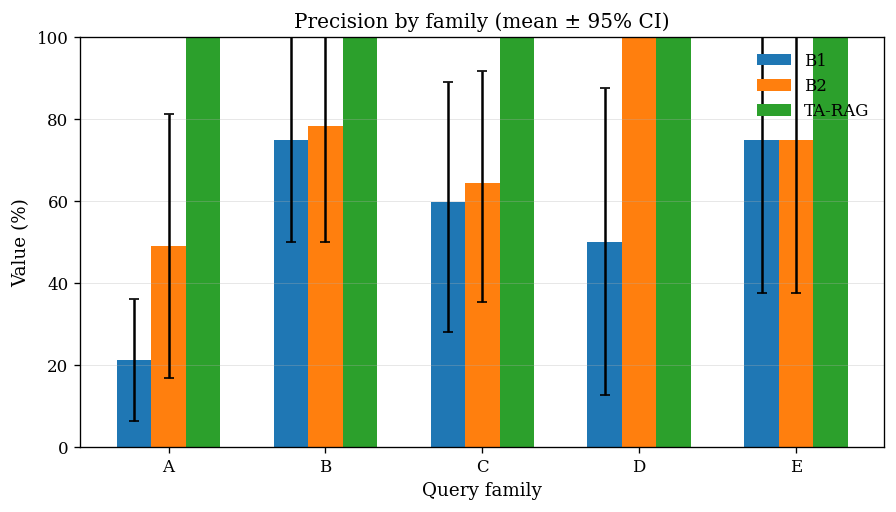

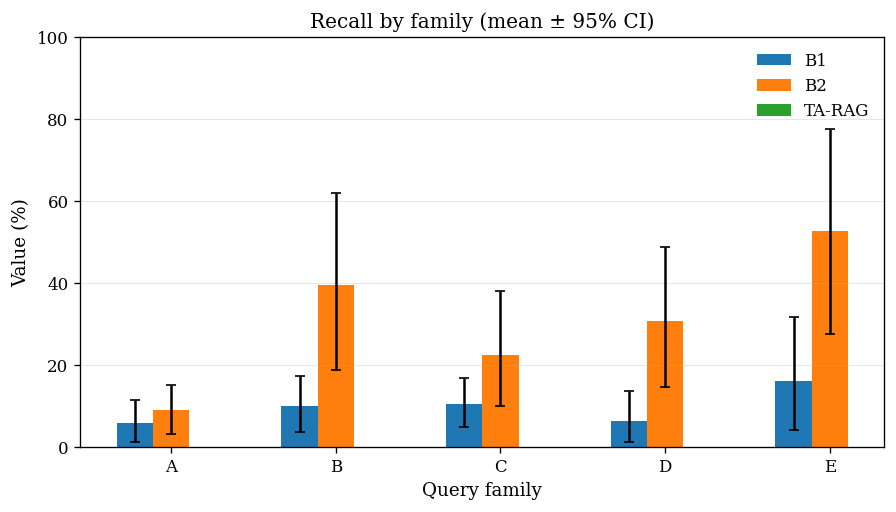

,family,system,metric,n,mean,std,ci_low,ci_high
0,A,B1,Leakage,6,65.051667,33.777574,39.986125,88.385000
1,A,B1,Coverage,8,26.805000,40.916739,3.888750,56.248750
2,A,B1,Precision,8,21.211250,23.402080,6.250000,36.172500
3,A,B1,Recall,8,5.730000,8.317158,1.040000,11.460000
4,A,B2,Leakage,7,53.571429,44.580437,22.620000,83.332857
5,A,B2,Coverage,8,37.707500,37.932145,13.541250,62.707500
6,A,B2,Precision,8,48.958750,48.883557,16.667500,81.250000
7,A,B2,Recall,8,8.853750,8.750737,3.125000,15.103750
8,A,TA-RAG,Leakage,8,0.000000,0.000000,0.000000,0.000000
9,A,TA-RAG,Coverage,8,100.000000,0.000000,100.000000,100.000000


Saved: fig3_byfamily_summary_bootstrap_ci95.csv


In [ ]:
# =========================================================
# Figure 3: Per-family grouped bars + 95% CI (A–E)
# =========================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# 1) compute per-family summary (bootstrap version)
byfam = summarize_by_family_bootstrap(df_long, n_boot=5000, ci=0.95, base_seed=42)

bar_width = 0.22
x = np.arange(len(FAMILY_ORDER))

# 2) plot: one metric per figure
for met in METRICS:
    sub = byfam[byfam["metric"] == met].copy()

    fig, ax = plt.subplots(figsize=(7.6, 4.4))  # adjust if needed

    for j, sys in enumerate(SYSTEM_ORDER):
        sys_sub = sub[sub["system"] == sys].set_index("family").reindex(FAMILY_ORDER)

        means = sys_sub["mean"].to_numpy(dtype=float)
        ci_low = sys_sub["ci_low"].to_numpy(dtype=float)
        ci_high = sys_sub["ci_high"].to_numpy(dtype=float)

        # yerr = distance from mean to CI bounds
        yerr = []
        for mu, lo, hi in zip(means, ci_low, ci_high):
            if np.isnan(mu) or np.isnan(lo) or np.isnan(hi):
                yerr.append([0.0, 0.0])
            else:
                yerr.append([mu - lo, hi - mu])
        yerr = np.array(yerr).T  # (2, n)

        # center bars automatically for any number of systems
        offset = (j - (len(SYSTEM_ORDER) - 1) / 2) * bar_width

        ax.bar(
            x + offset,
            means,
            width=bar_width,
            yerr=yerr,
            capsize=3,
            label=sys,
        )

    ax.set_title(f"{met} by family (mean ± 95% CI)")
    ax.set_xticks(x)
    ax.set_xticklabels(FAMILY_ORDER)
    ax.set_xlabel("Query family")
    ax.set_ylabel("Value (%)")
    ax.set_ylim(0, 100)
    ax.grid(True, axis="y", alpha=0.30)
    ax.legend(frameon=False)

    plt.tight_layout()

    safe_met = met.lower().replace(" ", "_").replace("/", "_")
    plt.savefig(f"fig3_family_{safe_met}_groupedbars_mean_ci95.pdf", bbox_inches="tight")
    plt.savefig(f"fig3_family_{safe_met}_groupedbars_mean_ci95.png", bbox_inches="tight")

    plt.show()
    plt.close(fig)

# 3) show the summary table (sorted + formatted)
byfam_show = byfam.copy()

# enforce nice ordering
byfam_show["family"] = pd.Categorical(byfam_show["family"], categories=FAMILY_ORDER, ordered=True)
byfam_show["system"] = pd.Categorical(byfam_show["system"], categories=SYSTEM_ORDER, ordered=True)
byfam_show["metric"] = pd.Categorical(byfam_show["metric"], categories=METRICS, ordered=True)
byfam_show = byfam_show.sort_values(["family", "system", "metric"]).reset_index(drop=True)

# round numbers
for c in ["mean", "std", "ci_low", "ci_high"]:
    if c in byfam_show.columns:
        byfam_show[c] = byfam_show[c].map(lambda v: np.nan if pd.isna(v) else round(float(v), 6))

display(byfam_show)

# optional: save the table for latex / excel usage
byfam_show.to_csv("fig3_byfamily_summary_bootstrap_ci95.csv", index=False)
print("Saved: fig3_byfamily_summary_bootstrap_ci95.csv")


## 471 TPA



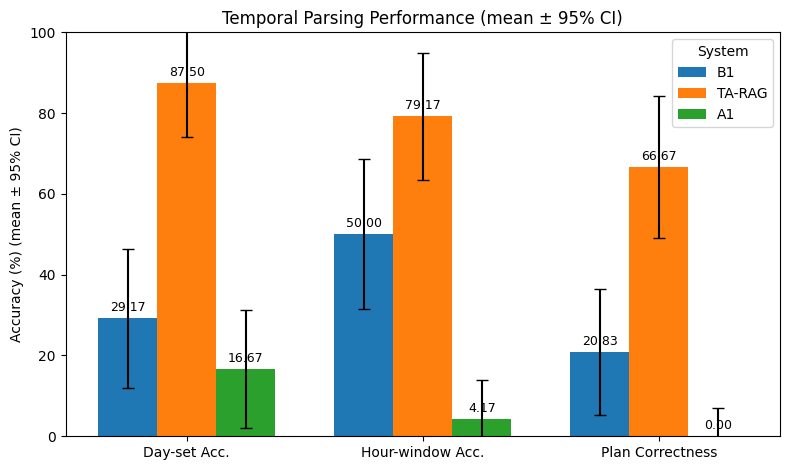

In [ ]:
# ===== Figure 1: Grouped bar chart (mean ± 95% CI) for 471 TPA =====
# compute 95% CI using the SAME Wilson-based metrics
#  i.e., use Wilson CI bounds, then convert to a symmetric ± half-width for plotting.
#

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast
import re
import math

# -----------------------------
# 1) Load CSV
# -----------------------------
CSV_PATH = "/content/drive/MyDrive/IOT_LLM/results_query/fortable2.csv"   # our file
df = pd.read_csv(CSV_PATH)

USE_ONLY_B_TO_E = False
if USE_ONLY_B_TO_E:
    df = df[df["family"].isin(["B", "C", "D", "E"])].copy()

df = df.sort_values(["qid", "system"]).drop_duplicates(["qid", "system"], keep="first")

# -----------------------------
# 2) data parsing helpers
# -----------------------------
# (minor robustness: accept both YYYY-M-D and YYYY/M/D and normalize to YYYY-MM-DD)
DATE_ANY_RE = re.compile(r"^\d{4}[-/]\d{1,2}[-/]\d{1,2}$")
DATE_FIND_RE = re.compile(r"\d{4}[-/]\d{1,2}[-/]\d{1,2}")

def normalize_date(s: str):
    s = str(s).strip().strip('"').strip("'")
    if not DATE_ANY_RE.match(s):
        return None
    sep = "-" if "-" in s else "/"
    y, m, d = s.split(sep)
    try:
        y = int(y); m = int(m); d = int(d)
        if not (1 <= m <= 12 and 1 <= d <= 31):
            return None
        return f"{y:04d}-{m:02d}-{d:02d}"
    except Exception:
        return None

def parse_dates_cell(x):
    if pd.isna(x):
        return []
    s = str(x).strip()
    if s == "" or s.lower() in {"none", "nan"}:
        return []
    nd = normalize_date(s)
    if nd:
        return [nd]
    for s_try in (s, s.replace("“", '"').replace("”", '"').replace("'", '"')):
        try:
            v = ast.literal_eval(s_try)
            if isinstance(v, (list, tuple)):
                out = []
                for it in v:
                    nd2 = normalize_date(it)
                    if nd2:
                        out.append(nd2)
                return out
        except Exception:
            pass
    found = DATE_FIND_RE.findall(s)
    out = []
    for it in found:
        nd3 = normalize_date(it)
        if nd3:
            out.append(nd3)
    return out

def parse_int_or_none(x):
    # key fix: treat NaN as None
    if x is None:
        return None
    if isinstance(x, float) and math.isnan(x):
        return None
    if pd.isna(x):
        return None
    s = str(x).strip()
    if s == "" or s.lower() in {"none", "nan"}:
        return None
    try:
        return int(float(s))
    except Exception:
        return None

# -----------------------------
# 3) Build parsed columns
# -----------------------------
df["gold_dates_list"] = df["gold_dates"].apply(parse_dates_cell)
df["pred_dates_list"] = df["pred_dates"].apply(parse_dates_cell)

df["gold_h1_i"] = df["gold_h1"].apply(parse_int_or_none)
df["gold_h2_i"] = df["gold_h2"].apply(parse_int_or_none)
df["pred_h1_i"] = df["pred_h1"].apply(parse_int_or_none)
df["pred_h2_i"] = df["pred_h2"].apply(parse_int_or_none)

# -----------------------------
# 4) Scoring rules
# -----------------------------
def day_score(g, p, system):
    gset, pset = set(g), set(p)

    if len(gset) == 0 and len(pset) == 0:
        return 1
    if len(gset) == 0 and len(pset) > 0:
        return 0

    if system == "B1":
        # single-day gold -> HIT is enough; multi-day -> full cover
        return 1 if gset.issubset(pset) else 0
    else:
        return 1 if (gset == pset) else 0

def normalize_window(h1, h2):
    """
    Normalize window [h1, h2). If missing => (None,None).
    If cross-midnight (h2<=h1), add 24 to h2.
    """
    h1 = parse_int_or_none(h1)
    h2 = parse_int_or_none(h2)
    if h1 is None or h2 is None:
        return None, None
    if h2 <= h1:
        h2 = h2 + 24
    return h1, h2

def hour_score(g1, g2, p1, p2, system):
    gs, ge = normalize_window(g1, g2)
    ps, pe = normalize_window(p1, p2)

    # gold missing => correct only if pred also missing
    if gs is None or ge is None:
        return 1 if (ps is None and pe is None) else 0
    # gold exists but pred missing => wrong
    if ps is None or pe is None:
        return 0

    if system == "B1":
        overlap = (max(ps, gs) < min(pe, ge))
        full_cover = (ps <= gs) and (pe >= ge)
        return 1 if (overlap and full_cover) else 0
    else:
        return 1 if (ps == gs and pe == ge) else 0

df["day_acc"] = df.apply(lambda r: day_score(r["gold_dates_list"], r["pred_dates_list"], r["system"]), axis=1)
df["hour_acc"] = df.apply(lambda r: hour_score(r["gold_h1_i"], r["gold_h2_i"], r["pred_h1_i"], r["pred_h2_i"], r["system"]), axis=1)
df["plan"] = (df["day_acc"] & df["hour_acc"]).astype(int)

# -----------------------------
# 5) Aggregate mean ± 95% CI, Wilson CI, then ± half-width for plotting)
# -----------------------------
SYSTEM_ORDER = ["B1", "TA-RAG", "A1"]
METRICS = [("Day-set Acc.", "day_acc"),
           ("Hour-window Acc.", "hour_acc"),
           ("Plan Correctness", "plan")]

def wilson_ci(k, n, z=1.96):
    if n == 0:
        return 0.0, 0.0, 0.0
    p = k / n
    denom = 1.0 + (z**2)/n
    center = (p + (z**2)/(2*n)) / denom
    half = (z / denom) * math.sqrt((p*(1-p) + (z**2)/(4*n)) / n)
    lo = max(0.0, center - half)
    hi = min(1.0, center + half)
    return p, lo, hi

def mean_and_ci95(x):
    """
    Match the TABLE: compute Wilson 95% CI for the binomial proportion k/n.
    For a bar chart that expects symmetric yerr, we convert [lo, hi] to a single ± value
    by taking the half-width: (hi - lo)/2 (same '±' you used in the table).
    Returns: (mean, ci_halfwidth) in [0,1].
    """
    x = np.asarray(x, dtype=float)
    n = len(x)
    if n == 0:
        return np.nan, np.nan
    k = int(np.nansum(x))
    p, lo, hi = wilson_ci(k, n, z=1.96)
    ci_half = 0.5 * (hi - lo)
    return p, ci_half

means_ci = {mname: [] for mname, _ in METRICS}
errs_ci  = {mname: [] for mname, _ in METRICS}

for sys in SYSTEM_ORDER:
    sub = df[df["system"] == sys]
    for mname, col in METRICS:
        p, ci = mean_and_ci95(sub[col])
        means_ci[mname].append(p * 100)
        errs_ci[mname].append(ci * 100)

# -----------------------------
# 6) Plot (single figure) + safe labels
# -----------------------------
x = np.arange(len(METRICS))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 4.8))
bars_list = []

for i, sys in enumerate(SYSTEM_ORDER):
    y = [means_ci[mname][i] for mname, _ in METRICS]
    e = [errs_ci[mname][i]  for mname, _ in METRICS]
    bars = ax.bar(x + (i - 1)*width, y, width, label=sys, yerr=e, capsize=4)
    bars_list.append((bars, y))

ax.set_xticks(x)
ax.set_xticklabels([mname for mname, _ in METRICS])
ax.set_ylabel("Accuracy (%) (mean ± 95% CI)")
ax.set_ylim(0, 100)
ax.legend(title="System", frameon=True)
ax.set_title("Temporal Parsing Performance (mean ± 95% CI)")

# bar value labels
for bars, yvals in bars_list:
    for rect, val in zip(bars.patches, yvals):
        if np.isnan(val):
            continue
        ax.text(rect.get_x() + rect.get_width()/2,
                rect.get_height() + 1.0,
                f"{val:.2f}",
                ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

Here is the part for calculating the MEAN WITH STD, but we use binary metrics here, so the std is high, we don't pick these metrics, use the same as above that is 95% CI.

In [ ]:
# ===== Table 4.6: Temporal parsing performance (mean ± std) =====
# CSV columns required:
# qid,family,system,gold_dates,gold_h1,gold_h2,pred_dates,pred_h1,pred_h2,anchor_now

import pandas as pd
import numpy as np
import ast
import re
import math

# -----------------------------
# 1) Load CSV
# -----------------------------
CSV_PATH = "/content/drive/MyDrive/IOT_LLM/results_query/fortable2.csv"   # <-- our file
df = pd.read_csv(CSV_PATH)

# -----------------------------
# 2) Parsing helpers  Excel / JSON / Python-list strings)
# -----------------------------
DATE_RE = re.compile(r"^\d{4}-\d{2}-\d{2}$")
DATE_FIND_RE = re.compile(r"\d{4}-\d{2}-\d{2}")

def _parse_dates_cell(x):
    """Return list[str] of ISO dates."""
    if pd.isna(x):
        return []
    s = str(x).strip()
    if s == "" or s.lower() in {"none", "nan"}:
        return []
    if DATE_RE.match(s):
        return [s]

    # try Python literal list/tuple
    try:
        v = ast.literal_eval(s)
        if isinstance(v, (list, tuple)):
            out = []
            for it in v:
                it = str(it).strip().strip('"').strip("'")
                if it and DATE_RE.match(it):
                    out.append(it)
            return out
    except Exception:
        pass

    # try JSON-like list
    s2 = s.replace("“", '"').replace("”", '"').replace("'", '"')
    try:
        v = ast.literal_eval(s2)
        if isinstance(v, (list, tuple)):
            out = []
            for it in v:
                it = str(it).strip().strip('"').strip("'")
                if it and DATE_RE.match(it):
                    out.append(it)
            return out
    except Exception:
        pass

    # last resort: extract ISO dates by regex
    return DATE_FIND_RE.findall(s)

def _parse_int_or_none(x):
    # Fix: NaN should become None (avoid int(NaN) crash)
    if x is None:
        return None
    if isinstance(x, float) and math.isnan(x):
        return None
    if pd.isna(x):
        return None
    s = str(x).strip()
    if s == "" or s.lower() in {"none", "nan"}:
        return None
    try:
        return int(float(s))
    except Exception:
        return None

# -----------------------------
# 3) System-specific scoring rules
# -----------------------------
def _day_score(gold_list, pred_list, system):
    gset, pset = set(gold_list), set(pred_list)

    # both empty -> treat as correct
    if len(gset) == 0 and len(pset) == 0:
        return 1
    # gold empty but pred not -> wrong
    if len(gset) == 0 and len(pset) > 0:
        return 0

    if system == "B1":
        # single-day gold -> hit is enough
        if len(gset) == 1:
            return 1 if len(gset & pset) == 1 else 0
        # multi-day gold -> pred must fully cover gold
        return 1 if gset.issubset(pset) else 0
    else:
        # strict equality for TA-RAG / A1
        return 1 if gset == pset else 0

def _normalize_window(h1, h2):
    """
    Normalize [h1, h2) to support cross-midnight.
    If h2 <= h1 => add 24 to h2.
    Return (start, end) or (None,None) if missing.
    """
    h1 = _parse_int_or_none(h1)
    h2 = _parse_int_or_none(h2)
    if h1 is None or h2 is None:
        return None, None
    if h2 <= h1:
        h2 = h2 + 24
    return h1, h2

def _hour_score(g1, g2, p1, p2, system):
    gs, ge = _normalize_window(g1, g2)
    ps, pe = _normalize_window(p1, p2)

    # gold missing => correct only if pred also missing
    if gs is None or ge is None:
        return 1 if (ps is None and pe is None) else 0
    # gold exists but pred missing => wrong
    if ps is None or pe is None:
        return 0

    if system == "B1":
        # B1 rule: overlap + pred fully covers gold
        overlap = (ps < ge) and (gs < pe)          # interval overlap
        cover   = (ps <= gs) and (pe >= ge)        # pred covers gold
        return 1 if (overlap and cover) else 0
    else:
        # strict equality for TA-RAG / A1
        return 1 if (ps == gs and pe == ge) else 0

# -----------------------------
# 4) Compute per-row scores
# -----------------------------
df["gold_dates_list"] = df["gold_dates"].apply(_parse_dates_cell)
df["pred_dates_list"] = df["pred_dates"].apply(_parse_dates_cell)

df["gold_h1_i"] = df["gold_h1"].apply(_parse_int_or_none)
df["gold_h2_i"] = df["gold_h2"].apply(_parse_int_or_none)
df["pred_h1_i"] = df["pred_h1"].apply(_parse_int_or_none)
df["pred_h2_i"] = df["pred_h2"].apply(_parse_int_or_none)

df["day_acc"] = df.apply(lambda r: _day_score(r["gold_dates_list"], r["pred_dates_list"], r["system"]), axis=1)
df["hour_acc"] = df.apply(lambda r: _hour_score(r["gold_h1_i"], r["gold_h2_i"], r["pred_h1_i"], r["pred_h2_i"], r["system"]), axis=1)
df["plan"] = (df["day_acc"] & df["hour_acc"]).astype(int)

# -----------------------------
# 5) Filter families optionally
# -----------------------------
USE_ONLY_B_TO_E = False
if USE_ONLY_B_TO_E:
    df_eval = df[df["family"].isin(["B", "C", "D", "E"])].copy()
else:
    df_eval = df.copy()

df_eval = df_eval.sort_values(["qid", "system"]).drop_duplicates(["qid", "system"], keep="first")

# -----------------------------
# 6) Aggregate: mean ± std per system
# -----------------------------
SYSTEM_ORDER = ["B1", "TA-RAG", "A1"]

def mean_std(series):
    m = float(series.mean())
    s = float(series.std(ddof=1)) if len(series) > 1 else 0.0
    return m, s

rows = []
for sys in SYSTEM_ORDER:
    sub = df_eval[df_eval["system"] == sys]
    m_d, s_d = mean_std(sub["day_acc"])
    m_h, s_h = mean_std(sub["hour_acc"])
    m_p, s_p = mean_std(sub["plan"])

    # convert to percent
    m_d, s_d = m_d * 100, s_d * 100
    m_h, s_h = m_h * 100, s_h * 100
    m_p, s_p = m_p * 100, s_p * 100

    rows.append({
        "System": sys,
        "Day-set Acc. (%)": f"{m_d:.2f} ± {s_d:.2f}",
        "Hour-window Acc. (%)": f"{m_h:.2f} ± {s_h:.2f}",
        "Plan Correctness (%)": f"{m_p:.2f} ± {s_p:.2f}",
        "N": len(sub)
    })

table46 = pd.DataFrame(rows)
print("\n=== Table 4.6 (mean ± std) in % ===")
print(table46.to_string(index=False))


=== Table 4.6 (mean ± std) in % ===
System Day-set Acc. (%) Hour-window Acc. (%) Plan Correctness (%)  N
    B1    29.17 ± 46.43        50.00 ± 51.08        20.83 ± 41.49 24
TA-RAG    87.50 ± 33.78        79.17 ± 41.49        66.67 ± 48.15 24
    A1    16.67 ± 38.07         4.17 ± 20.41          0.00 ± 0.00 24


mean with 95% confidence intervial in Wilson

In [ ]:
# ===== Table 4.6: Temporal parsing performance (mean ± 95% CI) =====
# CSV columns required:
# qid,family,system,gold_dates,gold_h1,gold_h2,pred_dates,pred_h1,pred_h2,anchor_now

import pandas as pd
import numpy as np
import ast
import re
import math

# -----------------------------
# 1) Load CSV
# -----------------------------
CSV_PATH = "/content/drive/MyDrive/IOT_LLM/results_query/fortable2.csv"   # <-- our file
df = pd.read_csv(CSV_PATH)

# -----------------------------
# 2) Parsing helpers (robust to Excel / JSON / Python-list strings)
#    + normalize dates like 2025/6/10 or 2025/06/10 into ISO 2025-06-10
# -----------------------------
DATE_ISO_RE = re.compile(r"^\d{4}-\d{2}-\d{2}$")
DATE_SLASH_RE = re.compile(r"^\d{4}/\d{1,2}/\d{1,2}$")
DATE_FIND_ISO_RE = re.compile(r"\d{4}-\d{2}-\d{2}")
DATE_FIND_SLASH_RE = re.compile(r"\d{4}/\d{1,2}/\d{1,2}")

def _to_iso_date(s: str):
    s = str(s).strip().strip('"').strip("'")
    if DATE_ISO_RE.match(s):
        return s
    if DATE_SLASH_RE.match(s):
        y, m, d = s.split("/")
        return f"{int(y):04d}-{int(m):02d}-{int(d):02d}"
    return None

def _parse_dates_cell(x):
    """Return list[str] of ISO dates."""
    if pd.isna(x):
        return []
    s = str(x).strip()
    if s == "" or s.lower() in {"none", "nan"}:
        return []

    # single scalar date
    iso = _to_iso_date(s)
    if iso is not None:
        return [iso]

    # try Python literal list/tuple
    try:
        v = ast.literal_eval(s)
        if isinstance(v, (list, tuple)):
            out = []
            for it in v:
                iso = _to_iso_date(it)
                if iso is not None:
                    out.append(iso)
            return out
    except Exception:
        pass

    # try JSON-like list
    s2 = s.replace("“", '"').replace("”", '"').replace("'", '"')
    try:
        v = ast.literal_eval(s2)
        if isinstance(v, (list, tuple)):
            out = []
            for it in v:
                iso = _to_iso_date(it)
                if iso is not None:
                    out.append(iso)
            return out
    except Exception:
        pass

    # last resort: extract dates by regex (ISO + slash) and normalize
    out = []
    for it in DATE_FIND_ISO_RE.findall(s):
        iso = _to_iso_date(it)
        if iso is not None:
            out.append(iso)
    for it in DATE_FIND_SLASH_RE.findall(s):
        iso = _to_iso_date(it)
        if iso is not None:
            out.append(iso)
    return out

def _parse_int_or_none(x):
    if x is None:
        return None
    if isinstance(x, float) and math.isnan(x):
        return None
    if pd.isna(x):
        return None
    s = str(x).strip()
    if s == "" or s.lower() in {"none", "nan"}:
        return None
    try:
        return int(float(s))
    except Exception:
        return None

# -----------------------------
# 3) System-specific scoring rules
# -----------------------------
def _day_score(gold_list, pred_list, system):
    gset, pset = set(gold_list), set(pred_list)

    # both empty -> treat as correct
    if len(gset) == 0 and len(pset) == 0:
        return 1
    # gold empty but pred not -> wrong
    if len(gset) == 0 and len(pset) > 0:
        return 0

    if system == "B1":
        if len(gset) == 1:
            return 1 if len(gset & pset) == 1 else 0
        return 1 if gset.issubset(pset) else 0
    else:
        return 1 if gset == pset else 0

def _normalize_window(h1, h2):
    h1 = _parse_int_or_none(h1)
    h2 = _parse_int_or_none(h2)
    if h1 is None or h2 is None:
        return None, None
    if h2 <= h1:
        h2 = h2 + 24
    return h1, h2

def _hour_score(g1, g2, p1, p2, system):
    gs, ge = _normalize_window(g1, g2)
    ps, pe = _normalize_window(p1, p2)

    if gs is None or ge is None:
        return 1 if (ps is None and pe is None) else 0
    if ps is None or pe is None:
        return 0

    if system == "B1":
        overlap = (ps < ge) and (gs < pe)
        cover   = (ps <= gs) and (pe >= ge)
        return 1 if (overlap and cover) else 0
    else:
        return 1 if (ps == gs and pe == ge) else 0

# -----------------------------
# 4) Compute per-row scores
# -----------------------------
df["gold_dates_list"] = df["gold_dates"].apply(_parse_dates_cell)
df["pred_dates_list"] = df["pred_dates"].apply(_parse_dates_cell)

df["gold_h1_i"] = df["gold_h1"].apply(_parse_int_or_none)
df["gold_h2_i"] = df["gold_h2"].apply(_parse_int_or_none)
df["pred_h1_i"] = df["pred_h1"].apply(_parse_int_or_none)
df["pred_h2_i"] = df["pred_h2"].apply(_parse_int_or_none)

df["day_acc"] = df.apply(lambda r: _day_score(r["gold_dates_list"], r["pred_dates_list"], r["system"]), axis=1)
df["hour_acc"] = df.apply(lambda r: _hour_score(r["gold_h1_i"], r["gold_h2_i"], r["pred_h1_i"], r["pred_h2_i"], r["system"]), axis=1)
df["plan"] = ((df["day_acc"] == 1) & (df["hour_acc"] == 1)).astype(int)

# -----------------------------
# 5) Filter families
# -----------------------------
USE_ONLY_B_TO_E = False
if USE_ONLY_B_TO_E:
    df_eval = df[df["family"].isin(["B", "C", "D", "E"])].copy()
else:
    df_eval = df.copy()

df_eval = df_eval.sort_values(["qid", "system"]).drop_duplicates(["qid", "system"], keep="first")

# -----------------------------
# 6) Aggregate: mean ± 95% CI per system
#    Recommended for proportions: Wilson score CI (more stable than normal approx.)
# -----------------------------
SYSTEM_ORDER = ["B1", "TA-RAG", "A1"]

def wilson_ci(k, n, z=1.96):
    """
    Wilson score interval for a binomial proportion.
    Returns (p_hat, lo, hi) in [0,1].
    """
    if n == 0:
        return 0.0, 0.0, 0.0
    p = k / n
    denom = 1.0 + (z**2)/n
    center = (p + (z**2)/(2*n)) / denom
    half = (z / denom) * math.sqrt((p*(1-p) + (z**2)/(4*n)) / n)
    lo = max(0.0, center - half)
    hi = min(1.0, center + half)
    return p, lo, hi

rows = []
for sys in SYSTEM_ORDER:
    sub = df_eval[df_eval["system"] == sys]
    n = len(sub)

    # counts of successes (since metrics are 0/1)
    k_d = int(sub["day_acc"].sum())
    k_h = int(sub["hour_acc"].sum())
    k_p = int(sub["plan"].sum())

    p_d, lo_d, hi_d = wilson_ci(k_d, n)
    p_h, lo_h, hi_h = wilson_ci(k_h, n)
    p_p, lo_p, hi_p = wilson_ci(k_p, n)

    # convert to percent
    p_d, lo_d, hi_d = 100*p_d, 100*lo_d, 100*hi_d
    p_h, lo_h, hi_h = 100*p_h, 100*lo_h, 100*hi_h
    p_p, lo_p, hi_p = 100*p_p, 100*lo_p, 100*hi_p

    rows.append({
        "System": sys,
        "Day-set Acc. (%)": f"{p_d:.2f} [{lo_d:.2f}, {hi_d:.2f}] ({k_d}/{n})",
        "Hour-window Acc. (%)": f"{p_h:.2f} [{lo_h:.2f}, {hi_h:.2f}] ({k_h}/{n})",
        "Plan Correctness (%)": f"{p_p:.2f} [{lo_p:.2f}, {hi_p:.2f}] ({k_p}/{n})",
        "N": n
    })

table46 = pd.DataFrame(rows)

print("\n=== Table 4.6 (mean with 95% CI, Wilson) ===")
print(table46.to_string(index=False))


=== Table 4.6 (mean with 95% CI, Wilson) ===
System             Day-set Acc. (%)         Hour-window Acc. (%)         Plan Correctness (%)  N
    B1  29.17 [14.91, 49.17] (7/24) 50.00 [31.43, 68.57] (12/24)   20.83 [9.24, 40.47] (5/24) 24
TA-RAG 87.50 [69.00, 95.66] (21/24) 79.17 [59.53, 90.76] (19/24) 66.67 [46.71, 82.03] (16/24) 24
    A1   16.67 [6.68, 35.85] (4/24)    4.17 [0.74, 20.24] (1/24)    0.00 [0.00, 13.80] (0/24) 24


Wald / Normal approximation CI (symmetric)

In [ ]:
# -----------------------------
# Aggregate: mean ± half-width of 95% CI per system (Wald / Normal)
# -----------------------------
SYSTEM_ORDER = ["B1", "TA-RAG", "A1"]

def wald_ci(k, n, z=1.96):
    """
    Wald (normal-approximation) CI for a binomial proportion.
    Returns (p_hat, lo, hi) in [0,1].
    """
    if n == 0:
        return 0.0, 0.0, 0.0
    p = k / n
    se = math.sqrt(p * (1.0 - p) / n) if n > 0 else 0.0
    lo = p - z * se
    hi = p + z * se
    lo = max(0.0, lo)
    hi = min(1.0, hi)
    return p, lo, hi

def fmt_with_pm_halfwidth(p, lo, hi, k, n):
    """
    p, lo, hi are in PERCENT (already converted).
    Print: mean ± half-width, and also keep [lo, hi] and (k/n) for traceability.
    """
    half = 0.5 * (hi - lo)
    return f"{p:.2f} ± {half:.2f} [{lo:.2f}, {hi:.2f}] ({k}/{n})"

rows = []
for sys in SYSTEM_ORDER:
    sub = df_eval[df_eval["system"] == sys]
    n = len(sub)

    k_d = int(sub["day_acc"].sum())
    k_h = int(sub["hour_acc"].sum())
    k_p = int(sub["plan"].sum())

    p_d, lo_d, hi_d = wald_ci(k_d, n)
    p_h, lo_h, hi_h = wald_ci(k_h, n)
    p_p, lo_p, hi_p = wald_ci(k_p, n)

    # convert to percent
    p_d, lo_d, hi_d = 100*p_d, 100*lo_d, 100*hi_d
    p_h, lo_h, hi_h = 100*p_h, 100*lo_h, 100*hi_h
    p_p, lo_p, hi_p = 100*p_p, 100*lo_p, 100*hi_p

    rows.append({
        "System": sys,
        "Day-set Acc. (%)": fmt_with_pm_halfwidth(p_d, lo_d, hi_d, k_d, n),
        "Hour-window Acc. (%)": fmt_with_pm_halfwidth(p_h, lo_h, hi_h, k_h, n),
        "Plan Correctness (%)": fmt_with_pm_halfwidth(p_p, lo_p, hi_p, k_p, n),
        "N": n
    })

table46 = pd.DataFrame(rows)
print("\n=== Table 4.6 (mean ± half-width of 95% CI, Wald/Normal) ===")
print(table46.to_string(index=False))


=== Table 4.6 (mean ± half-width of 95% CI, Wald/Normal) ===
System                      Day-set Acc. (%)                 Hour-window Acc. (%)                 Plan Correctness (%)  N
    B1   29.17 ± 18.18 [10.98, 47.35] (7/24) 50.00 ± 20.00 [30.00, 70.00] (12/24)   20.83 ± 16.25 [4.59, 37.08] (5/24) 24
TA-RAG 87.50 ± 12.87 [74.27, 100.00] (21/24) 79.17 ± 16.25 [62.92, 95.41] (19/24) 66.67 ± 18.86 [47.81, 85.53] (16/24) 24
    A1    16.67 ± 14.91 [1.76, 31.58] (4/24)     4.17 ± 6.08 [0.00, 12.16] (1/24)      0.00 ± 0.00 [0.00, 0.00] (0/24) 24


Wilson CI is asymmetric, we can still report a single “±” by using the half-width: Δ=(hi−lo​)/2, report p​±Δ


In [ ]:
def fmt_mean_pm_ci(p, lo, hi, k, n):
    # p, lo, hi are already in PERCENT
    half = 0.5 * (hi - lo)
    return f"{p:.2f} ± {half:.2f} ({k}/{n})"

rows = []
for sys in SYSTEM_ORDER:
    sub = df_eval[df_eval["system"] == sys]
    n = len(sub)

    k_d = int(sub["day_acc"].sum())
    k_h = int(sub["hour_acc"].sum())
    k_p = int(sub["plan"].sum())

    p_d, lo_d, hi_d = wilson_ci(k_d, n)
    p_h, lo_h, hi_h = wilson_ci(k_h, n)
    p_p, lo_p, hi_p = wilson_ci(k_p, n)

    # convert to percent
    p_d, lo_d, hi_d = 100*p_d, 100*lo_d, 100*hi_d
    p_h, lo_h, hi_h = 100*p_h, 100*lo_h, 100*hi_h
    p_p, lo_p, hi_p = 100*p_p, 100*lo_p, 100*hi_p

    rows.append({
        "System": sys,
        "Day-set Acc. ↑": fmt_mean_pm_ci(p_d, lo_d, hi_d, k_d, n),
        "Hour-window Acc. ↑": fmt_mean_pm_ci(p_h, lo_h, hi_h, k_h, n),
        "Plan Correctness ↑": fmt_mean_pm_ci(p_p, lo_p, hi_p, k_p, n),
    })

table46 = pd.DataFrame(rows)
print(table46.to_string(index=False))

System        Day-set Acc. ↑    Hour-window Acc. ↑    Plan Correctness ↑
    B1  29.17 ± 17.13 (7/24) 50.00 ± 18.57 (12/24)  20.83 ± 15.61 (5/24)
TA-RAG 87.50 ± 13.33 (21/24) 79.17 ± 15.61 (19/24) 66.67 ± 17.66 (16/24)
    A1  16.67 ± 14.59 (4/24)    4.17 ± 9.75 (1/24)    0.00 ± 6.90 (0/24)


## 473-Answer Faithfulness and Evidence Traceability

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# 0) Load data
# =========================
# Change to file path
DATA_PATH = "/content/drive/MyDrive/IOT_LLM/results_query/test_473.csv"   # e.g., "/content/473_results.csv"
# If your file is Excel, set DATA_PATH to .xlsx and set USE_EXCEL=True
USE_EXCEL = False

if USE_EXCEL:
    df = pd.read_excel(DATA_PATH)
else:
    df = pd.read_csv(DATA_PATH)

# ---- Required columns ----
# system, CCR, FCR, UCR
required = ["system", "CCR", "FCR", "UCR"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}. Found columns: {list(df.columns)}")

# Ensure numeric
for c in ["CCR", "FCR", "UCR"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=["system", "CCR", "FCR", "UCR"]).copy()

print("Loaded rows:", len(df))
print(df.head(3))


Loaded rows: 80
  qid family  system  C_total  C_cited  C_supported  C_unsupported  \
0  A1      A      B2        4        3            3              1   
1  A1      A  TA-RAG       22       20           20              2   
2  A1      A      A3       21       17           17              4   

                                               query   CCR  FCR   UCR  
0  On June 10, between 09:00 and 18:00, when did ...  0.75  1.0  0.25  
1  On June 10, between 09:00 and 18:00, when did ...  0.91  1.0  0.09  
2  On June 10, between 09:00 and 18:00, when did ...  0.81  1.0  0.19  


In [ ]:
import numpy as np
import pandas as pd

# =========================================================
# 0) Assumptions / required columns
# =========================================================
# df must contain at least:
#   system, CCR, FCR, UCR
REQUIRED = {"system", "CCR", "FCR", "UCR"}
missing = REQUIRED - set(df.columns)
if missing:
    raise ValueError(f"df is missing required columns: {missing}")

if "qid" not in df.columns:
    raise ValueError(
        "Paired bootstrap Δ(A−B) requires a 'qid' column (one row per query per system). "
        "Please add qid to your df."
    )

# Optional: control order in tables/plots
order = ["B0", "B0-CSV", "B1", "B2", "A3", "TA-RAG"]

# =========================================================
# 1) Bootstrap CI for macro mean (per system, per metric)
# =========================================================
def bootstrap_mean_ci(x, n_boot=10000, ci=0.95, seed=42):
    """
    Nonparametric bootstrap CI for the mean (percentile CI).
    Returns: (mean, ci_low, ci_high, half_width)
    """
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    n = len(x)
    if n == 0:
        return np.nan, np.nan, np.nan, np.nan

    rng = np.random.default_rng(seed)
    boot_means = np.empty(n_boot, dtype=float)
    for b in range(n_boot):
        sample = rng.choice(x, size=n, replace=True)
        boot_means[b] = sample.mean()

    alpha = 1.0 - ci
    lo = np.quantile(boot_means, alpha / 2.0)
    hi = np.quantile(boot_means, 1.0 - alpha / 2.0)
    m = x.mean()
    half = (hi - lo) / 2.0
    return m, lo, hi, half


def summarize_with_bootstrap(df, metrics=("CCR", "FCR", "UCR"), n_boot=10000, ci=0.95, seed=42):
    rows = []
    for sys, g in df.groupby("system"):
        row = {"system": sys, "N": len(g)}
        for met in metrics:
            mean = g[met].mean()
            std = g[met].std(ddof=1)
            m, lo, hi, half = bootstrap_mean_ci(g[met].values, n_boot=n_boot, ci=ci, seed=seed)
            row[f"{met}_mean"] = mean
            row[f"{met}_std"] = std
            row[f"{met}_ci_low"] = lo
            row[f"{met}_ci_high"] = hi
            row[f"{met}_ci_half"] = half
        rows.append(row)
    out = pd.DataFrame(rows)

    out["system"] = pd.Categorical(out["system"], categories=order, ordered=True)
    out = out.sort_values("system").dropna(subset=["system"]).reset_index(drop=True)
    return out


summary_boot = summarize_with_bootstrap(df, n_boot=10000, ci=0.95, seed=42)
print("=== Macro mean ± std + Bootstrap 95% CI (percentile) ===")
print(summary_boot)

# =========================================================
# 2) Paired bootstrap Δ(A−B) for mean differences
#    (same query ids resampled across systems)
# =========================================================
def paired_bootstrap_delta(df, sysA, sysB, metric, n_boot=10000, ci=0.95, seed=42):
    """
    Paired bootstrap CI for mean difference Δ(A−B).
    Requires one value per (qid, system).
    Returns: (delta_mean, ci_low, ci_high, half_width, N_pairs)
    """
    sub = df[df["system"].isin([sysA, sysB])][["qid", "system", metric]].copy()

    wide = sub.pivot_table(index="qid", columns="system", values=metric, aggfunc="mean")
    wide = wide.dropna(subset=[sysA, sysB])  # keep only paired qids
    if wide.empty:
        return np.nan, np.nan, np.nan, np.nan, 0

    diffs = (wide[sysA] - wide[sysB]).to_numpy(dtype=float)
    n = len(diffs)

    rng = np.random.default_rng(seed)
    boot = np.empty(n_boot, dtype=float)
    for b in range(n_boot):
        sample = rng.choice(diffs, size=n, replace=True)
        boot[b] = sample.mean()

    alpha = 1.0 - ci
    lo = np.quantile(boot, alpha / 2.0)
    hi = np.quantile(boot, 1.0 - alpha / 2.0)
    dm = diffs.mean()
    half = (hi - lo) / 2.0
    return dm, lo, hi, half, n


# ---- Choose the Δ comparisons you want ----
# Typical choices in Section 4.7.3 narrative:
#   TA-RAG vs A3   (isolates Layer 5 effect)
#   TA-RAG vs B2   (full vs retrieval+filter baseline)
#   B2 vs B0-CSV   (retrieval vs in-context CSV)
comparisons = [
    ("TA-RAG", "A3"),
    ("TA-RAG", "B2"),
    ("TA-RAG", "B0-CSV"),
    ("B2", "B0-CSV"),
]

metrics = ["CCR", "FCR", "UCR"]

delta_rows = []
for A, B in comparisons:
    for met in metrics:
        dm, lo, hi, half, n_pairs = paired_bootstrap_delta(
            df, sysA=A, sysB=B, metric=met, n_boot=10000, ci=0.95, seed=42
        )
        delta_rows.append({
            "A": A,
            "B": B,
            "metric": met,
            "N_pairs": n_pairs,
            "delta_mean": dm,
            "ci_low": lo,
            "ci_high": hi,
            "ci_half": half,
        })

delta_table = pd.DataFrame(delta_rows)

# Optional: sort to keep a stable reading order
delta_table["metric"] = pd.Categorical(delta_table["metric"], categories=metrics, ordered=True)
delta_table = delta_table.sort_values(["A", "B", "metric"]).reset_index(drop=True)

print("\n=== Paired Bootstrap Δ(A−B): mean difference + 95% CI ===")
print(delta_table)

# =========================================================
AS_PERCENT = True  # set False if CCR/FCR/UCR are already in [0,1] and want raw
if AS_PERCENT:
    # If max <= 1.5, assume [0,1] and convert to %
    for col in [c for c in summary_boot.columns if any(k in c for k in ["CCR_", "FCR_", "UCR_"])]:
        if pd.to_numeric(summary_boot[col], errors="coerce").max(skipna=True) <= 1.5:
            summary_boot[col] = summary_boot[col] * 100.0

    for col in ["delta_mean", "ci_low", "ci_high", "ci_half"]:
        if pd.to_numeric(delta_table[col], errors="coerce").max(skipna=True) <= 1.5:
            delta_table[col] = delta_table[col] * 100.0

    print("\n=== (Percent) Macro summary ===")
    print(summary_boot)

    print("\n=== (Percent) Paired deltas ===")
    print(delta_table)

=== Macro mean ± std + Bootstrap 95% CI (percentile) ===
   system   N  CCR_mean   CCR_std  CCR_ci_low  CCR_ci_high  CCR_ci_half  \
0  B0-CSV  20  0.543590  0.268507    0.431330     0.662153     0.115411   
1      B2  20  0.650355  0.255043    0.543498     0.762282     0.109392   
2      A3  20  0.593325  0.182126    0.514950     0.670296     0.077673   
3  TA-RAG  20  0.969645  0.046943    0.948415     0.988555     0.020070   

   FCR_mean   FCR_std  FCR_ci_low  FCR_ci_high  FCR_ci_half  UCR_mean  \
0  0.396825  0.456864    0.207935     0.596820     0.194442  0.812220   
1  0.660585  0.396351    0.483843     0.826276     0.171216  0.625560   
2  0.994500  0.024597    0.983500     1.000000     0.008250  0.409175   
3  0.991665  0.027189    0.977775     1.000000     0.011112  0.038690   

    UCR_std  UCR_ci_low  UCR_ci_high  UCR_ci_half  
0  0.308576    0.665950     0.930092     0.132071  
1  0.219177    0.531028     0.720330     0.094651  
2  0.185520    0.330837     0.489457     0.07

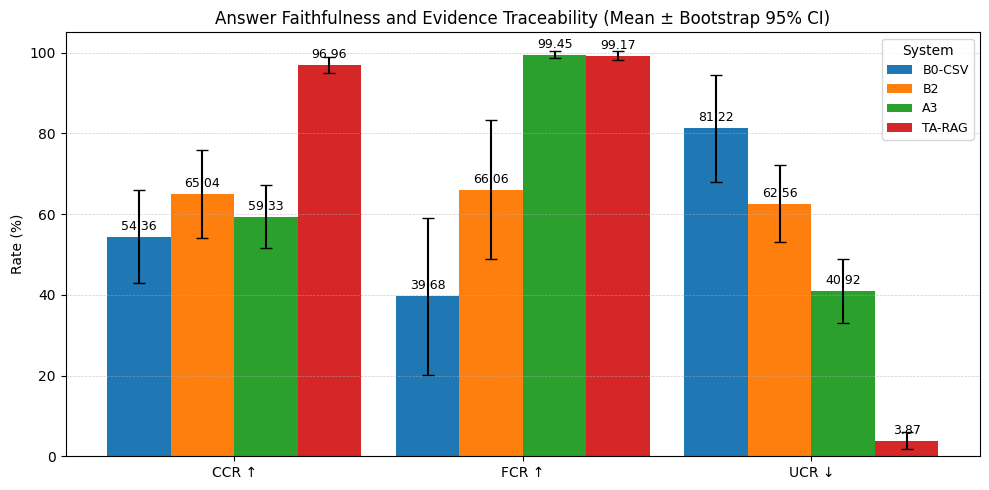

(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'Answer Faithfulness and Evidence Traceability (Mean ± Bootstrap 95% CI)'}, ylabel='Rate (%)'>)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# Input: summary_boot
# code assumes summary_boot is already in PERCENT scale (0..100),
# =========================================================
def plot_traceability_mean_ci_like_fig41(
    summary_boot,
    systems_order=("B0-CSV", "B2", "A3", "TA-RAG"),
    metrics=(
        ("CCR", "CCR ↑"),
        ("FCR", "FCR ↑"),
        ("UCR", "UCR ↓"),
    ),
    title="Answer Faithfulness and Evidence Traceability (Mean ± Bootstrap 95% CI)",
    ylabel="Rate (%)",
    decimals=2,
):
    # ---- filter + enforce system order ----
    dfp = summary_boot.copy()
    dfp["system"] = dfp["system"].astype(str)
    dfp = dfp[dfp["system"].isin(systems_order)].copy()
    dfp["system"] = pd.Categorical(dfp["system"], categories=list(systems_order), ordered=True)
    dfp = dfp.sort_values("system").reset_index(drop=True)

    x = np.arange(len(metrics))        # metrics on x-axis
    width = 0.22

    fig, ax = plt.subplots(figsize=(10, 5))

    for j, sys in enumerate(systems_order):
        row = dfp[dfp["system"].astype(str) == sys].iloc[0]

        means = []
        halfs = []
        for met_key, _ in metrics:
            means.append(float(row[f"{met_key}_mean"]))
            # (equivalent to (ci_high - ci_low)/2)
            halfs.append(float(row[f"{met_key}_ci_half"]))

        means = np.array(means, dtype=float)
        halfs = np.array(halfs, dtype=float)

        bars = ax.bar(
            x + (j - (len(systems_order)-1)/2) * width,
            means,
            width,
            yerr=halfs,
            capsize=4,
            label=sys
        )

        # numeric mean labels
        for b, v in zip(bars, means):
            ax.text(
                b.get_x() + b.get_width()/2,
                b.get_height() + 1.0,
                f"{v:.{decimals}f}",
                ha="center",
                va="bottom",
                fontsize=9
            )

    ax.set_xticks(x)
    ax.set_xticklabels([lab for _, lab in metrics])
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.legend(title="System", loc="upper right", fontsize=9)
    ax.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.6)

    # percent axis like screenshot2
    ax.set_ylim(0, 105)
    fig.tight_layout()
    plt.show()
    return fig, ax


# ---- CALL ----
plot_traceability_mean_ci_like_fig41(
    summary_boot,
    systems_order=("B0-CSV", "B2", "A3", "TA-RAG"),
    decimals=2
)

for paired bootstrap-95 CI compared figures

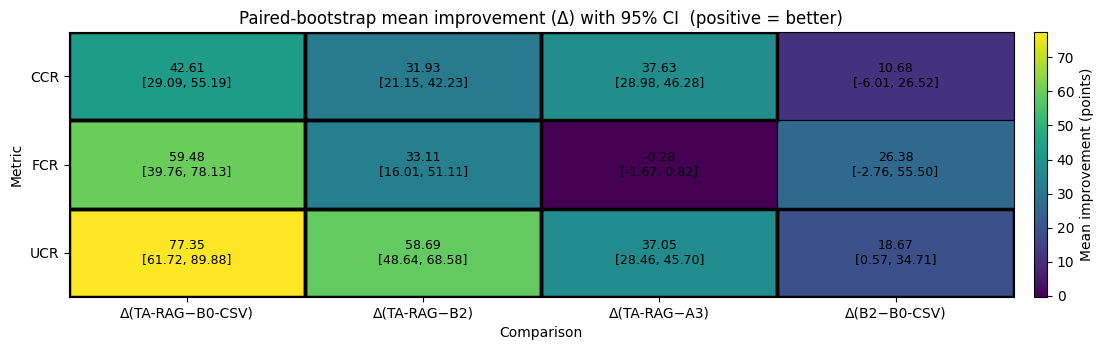

In [ ]:
# =========================================
# Paired-bootstrap improvement HEATMAP (Traceability / Faithfulness)
# Input: delta_table (paired deltas for CCR/FCR/UCR)
#   - heatmap value = mean improvement (positive = better)
#   - annotate each cell: mean \n [lo, hi]
#   - thick border if CI excludes 0 (robust)
#   - handle metric direction: CCR/FCR (↑) positive better; UCR (↓) negative better -> flip sign
# =========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

COMP_ORDER = [
    "Δ(TA-RAG−B0-CSV)",
    "Δ(TA-RAG−B2)",
    "Δ(TA-RAG−A3)",
    "Δ(B2−B0-CSV)",
]
METRIC_ORDER = ["CCR", "FCR", "UCR"]

df = delta_table.copy()

# normalize text columns
df["A"] = df["A"].astype(str)
df["B"] = df["B"].astype(str)
df["metric"] = df["metric"].astype(str)

# Build comparison label Δ(A−B) using the same dash symbol as COMP_ORDER (−)
def comp_label(a, b):
    return f"Δ({a}−{b})"

df["comp"] = [comp_label(a, b) for a, b in zip(df["A"], df["B"])]

df = df[df["comp"].isin(COMP_ORDER)].copy()

# ---- Build "improvement" values with unified direction (+ = better) ----
# Start from Δ = mean_diff, CI = [ci_low, ci_high]
df["imp_mean"] = df["delta_mean"].astype(float)
df["imp_lo"]   = df["ci_low"].astype(float)
df["imp_hi"]   = df["ci_high"].astype(float)

# Flip sign for UCR (because lower is better)
mask_ucr = df["metric"].str.upper().eq("UCR")
df.loc[mask_ucr, "imp_mean"] = -df.loc[mask_ucr, "delta_mean"]
# when flipping sign, swap CI endpoints: [-hi, -lo]
df.loc[mask_ucr, "imp_lo"]   = -df.loc[mask_ucr, "ci_high"]
df.loc[mask_ucr, "imp_hi"]   = -df.loc[mask_ucr, "ci_low"]

# ---- Pivot into matrices (mean + CI + robustness flag) ----
mean_mat = df.pivot_table(index="metric", columns="comp", values="imp_mean", aggfunc="first")
lo_mat   = df.pivot_table(index="metric", columns="comp", values="imp_lo",   aggfunc="first")
hi_mat   = df.pivot_table(index="metric", columns="comp", values="imp_hi",   aggfunc="first")

# Reindex to desired order
mean_mat = mean_mat.reindex(index=METRIC_ORDER, columns=COMP_ORDER)
lo_mat   = lo_mat.reindex(index=METRIC_ORDER, columns=COMP_ORDER)
hi_mat   = hi_mat.reindex(index=METRIC_ORDER, columns=COMP_ORDER)

# Robust if CI excludes 0
robust = (~mean_mat.isna()) & (~lo_mat.isna()) & (~hi_mat.isna()) & ((lo_mat > 0) | (hi_mat < 0))

# ---- Plot heatmap ----
Z = mean_mat.to_numpy(dtype=float)

fig, ax = plt.subplots(figsize=(11.2, 3.6))
im = ax.imshow(Z, aspect="auto")

# ticks/labels
ax.set_xticks(np.arange(len(COMP_ORDER)))
ax.set_yticks(np.arange(len(METRIC_ORDER)))
ax.set_xticklabels(COMP_ORDER, rotation=0)
ax.set_yticklabels(METRIC_ORDER)

ax.set_title("Paired-bootstrap mean improvement (Δ) with 95% CI  (positive = better)")
ax.set_xlabel("Comparison")
ax.set_ylabel("Metric")

# colorbar
cbar = plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
cbar.set_label("Mean improvement (points)")

# ---- Annotate cells + robustness borders ----
for i, met in enumerate(METRIC_ORDER):
    for j, comp in enumerate(COMP_ORDER):
        mu = mean_mat.loc[met, comp]
        lo = lo_mat.loc[met, comp]
        hi = hi_mat.loc[met, comp]

        if pd.isna(mu) or pd.isna(lo) or pd.isna(hi):
            txt = "N/A"
        else:
            txt = f"{mu:.2f}\n[{lo:.2f}, {hi:.2f}]"

        ax.text(j, i, txt, ha="center", va="center", fontsize=9)

        if not (pd.isna(mu) or pd.isna(lo) or pd.isna(hi)):
            is_rob = bool(robust.loc[met, comp])
            lw = 2.5 if is_rob else 0.8
            rect = plt.Rectangle((j - 0.5, i - 0.5), 1.0, 1.0, fill=False, linewidth=lw)
            ax.add_patch(rect)

plt.tight_layout()
plt.show()

improve the font size and change the contrast colours of the text with the cells' colours.

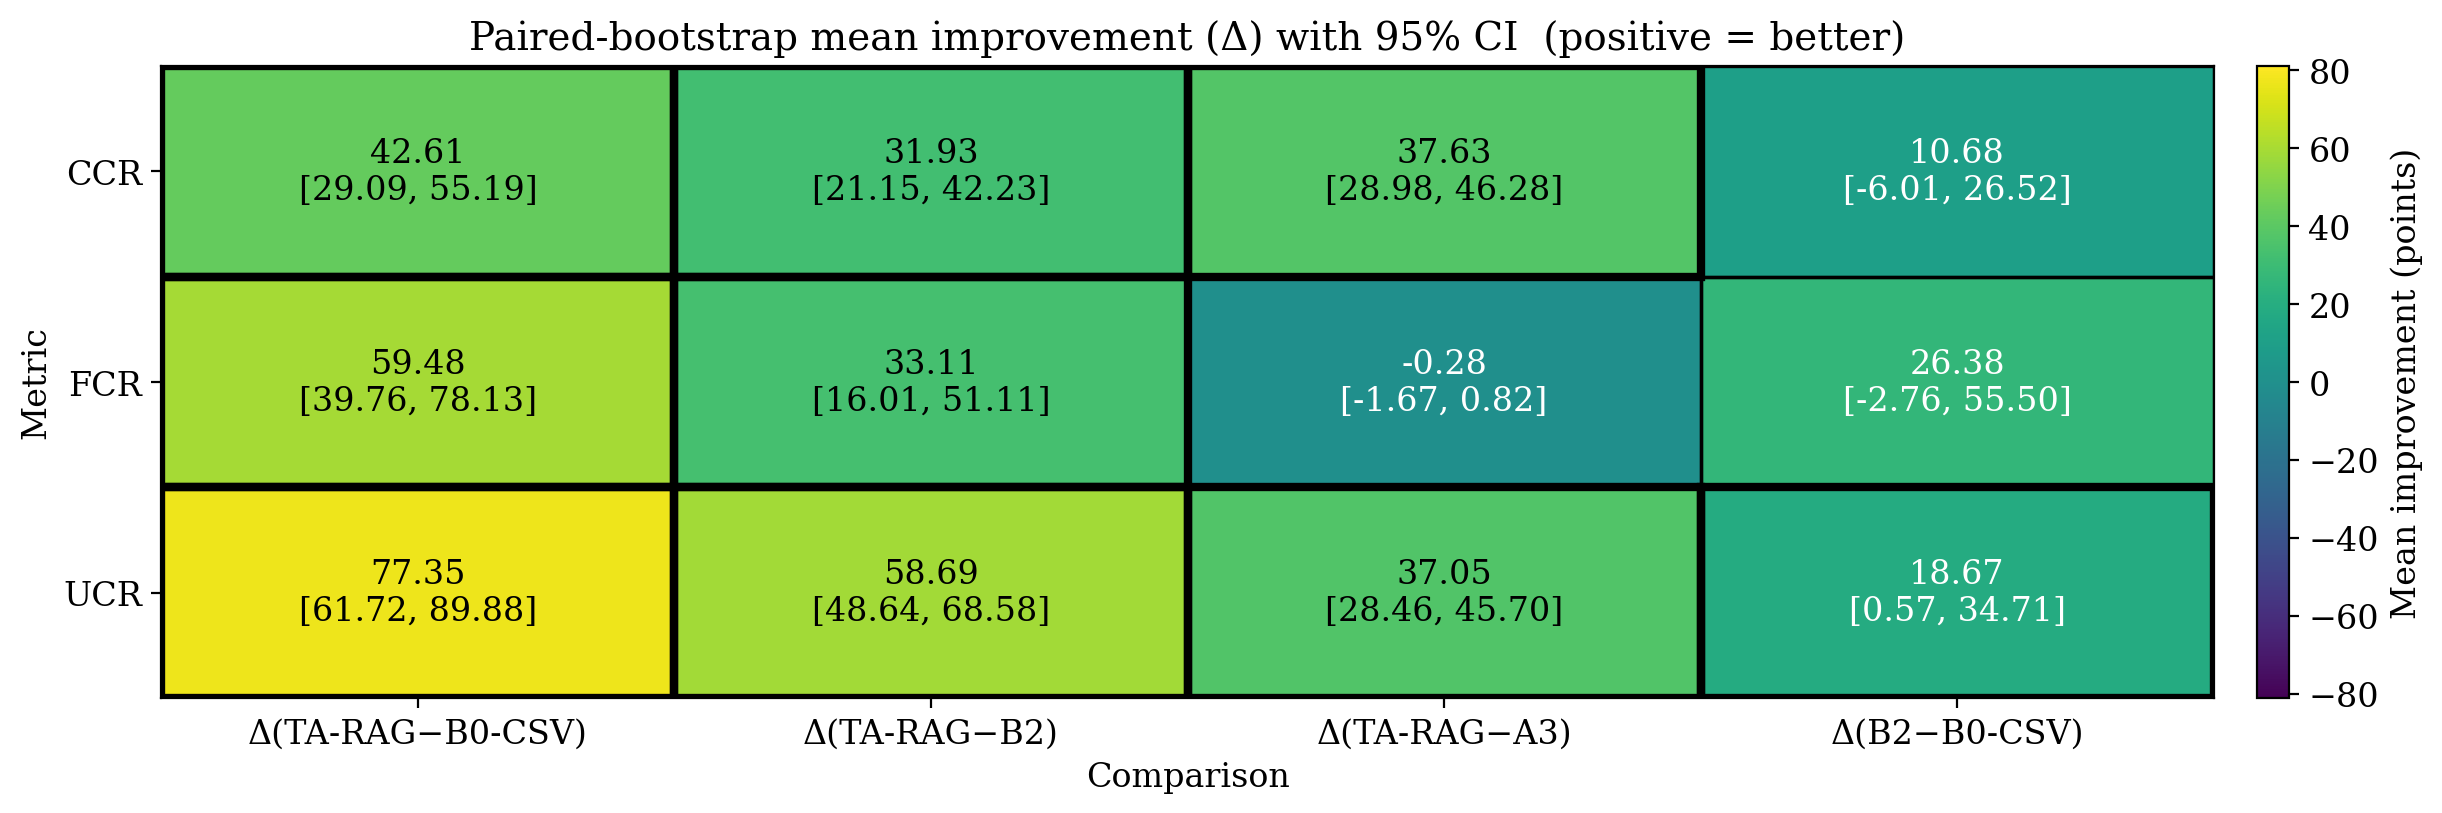

In [ ]:
# =========================================
# Exec-summary heatmap (473: Traceability / Faithfulness)
# Better contrast, adaptive annotation color (white on dark, black on bright), Centered diverging normalization at 0 (positive = better), Thicker borders for robust cells
# =========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

COMP_ORDER = [
    "Δ(TA-RAG−B0-CSV)",
    "Δ(TA-RAG−B2)",
    "Δ(TA-RAG−A3)",
    "Δ(B2−B0-CSV)",
]
METRIC_ORDER = ["CCR", "FCR", "UCR"]

df = delta_table.copy()
df["A"] = df["A"].astype(str)
df["B"] = df["B"].astype(str)
df["metric"] = df["metric"].astype(str)

def comp_label(a, b):
    return f"Δ({a}−{b})"

df["comp"] = [comp_label(a, b) for a, b in zip(df["A"], df["B"])]
df = df[df["comp"].isin(COMP_ORDER)].copy()

# ---- unify direction (+ = better) ----
df["imp_mean"] = df["delta_mean"].astype(float)
df["imp_lo"]   = df["ci_low"].astype(float)
df["imp_hi"]   = df["ci_high"].astype(float)

mask_ucr = df["metric"].str.upper().eq("UCR")
df.loc[mask_ucr, "imp_mean"] = -df.loc[mask_ucr, "delta_mean"]
df.loc[mask_ucr, "imp_lo"]   = -df.loc[mask_ucr, "ci_high"]
df.loc[mask_ucr, "imp_hi"]   = -df.loc[mask_ucr, "ci_low"]

# ---- pivot to matrices ----
mean_mat = df.pivot_table(index="metric", columns="comp", values="imp_mean", aggfunc="first")
lo_mat   = df.pivot_table(index="metric", columns="comp", values="imp_lo",   aggfunc="first")
hi_mat   = df.pivot_table(index="metric", columns="comp", values="imp_hi",   aggfunc="first")

mean_mat = mean_mat.reindex(index=METRIC_ORDER, columns=COMP_ORDER)
lo_mat   = lo_mat.reindex(index=METRIC_ORDER, columns=COMP_ORDER)
hi_mat   = hi_mat.reindex(index=METRIC_ORDER, columns=COMP_ORDER)

robust = (~mean_mat.isna()) & (~lo_mat.isna()) & (~hi_mat.isna()) & ((lo_mat > 0) | (hi_mat < 0))

# ---- executive-summary styling knobs ----
FIG_W, FIG_H = 12.4, 4.2
ANN_FONTSIZE = 12
TICK_FONTSIZE = 12
TITLE_FONTSIZE = 14
CBAR_FONTSIZE = 12
BORDER_THIN = 1.2
BORDER_THICK = 3.0

Z = mean_mat.to_numpy(dtype=float)

# centered colormap around 0 (positive = better)
finite = Z[np.isfinite(Z)]
v = 1.0 if finite.size == 0 else float(np.max(np.abs(finite)))
vmax = max(1.0, v * 1.05)
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

fig, ax = plt.subplots(figsize=(FIG_W, FIG_H), dpi=200)
im = ax.imshow(Z, aspect="auto", norm=norm)

ax.set_xticks(np.arange(len(COMP_ORDER)))
ax.set_yticks(np.arange(len(METRIC_ORDER)))
ax.set_xticklabels(COMP_ORDER, rotation=0, fontsize=TICK_FONTSIZE)
ax.set_yticklabels(METRIC_ORDER, fontsize=TICK_FONTSIZE)

ax.set_title("Paired-bootstrap mean improvement (Δ) with 95% CI  (positive = better)",
             fontsize=TITLE_FONTSIZE)
ax.set_xlabel("Comparison", fontsize=TICK_FONTSIZE)
ax.set_ylabel("Metric", fontsize=TICK_FONTSIZE)

cbar = plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
cbar.set_label("Mean improvement (points)", fontsize=CBAR_FONTSIZE)
cbar.ax.tick_params(labelsize=CBAR_FONTSIZE)

# adaptive text color
cmap = im.get_cmap()
def _text_color(val):
    rgba = cmap(norm(val))
    r, g, b = rgba[:3]
    lum = 0.2126*r + 0.7152*g + 0.0722*b
    return "black" if lum > 0.6 else "white"

for i, met in enumerate(METRIC_ORDER):
    for j, comp in enumerate(COMP_ORDER):
        mu = mean_mat.loc[met, comp]
        lo = lo_mat.loc[met, comp]
        hi = hi_mat.loc[met, comp]

        if pd.isna(mu) or pd.isna(lo) or pd.isna(hi):
            txt = "N/A"
            color = "black"
        else:
            txt = f"{mu:.2f}\n[{lo:.2f}, {hi:.2f}]"
            color = _text_color(mu)

        ax.text(j, i, txt, ha="center", va="center",
                fontsize=ANN_FONTSIZE, color=color)

        if not (pd.isna(mu) or pd.isna(lo) or pd.isna(hi)):
            lw = BORDER_THICK if bool(robust.loc[met, comp]) else BORDER_THIN
            rect = plt.Rectangle((j - 0.5, i - 0.5), 1.0, 1.0,
                                 fill=False, linewidth=lw, edgecolor="black")
            ax.add_patch(rect)

plt.tight_layout()
plt.savefig("fig473_paired_bootstrap_improvement_heatmap_exec.pdf", bbox_inches="tight")
plt.savefig("fig473_paired_bootstrap_improvement_heatmap_exec.png", bbox_inches="tight")
plt.show()

boxplot

Detected qid: using per-query aggregation. Rows: 80


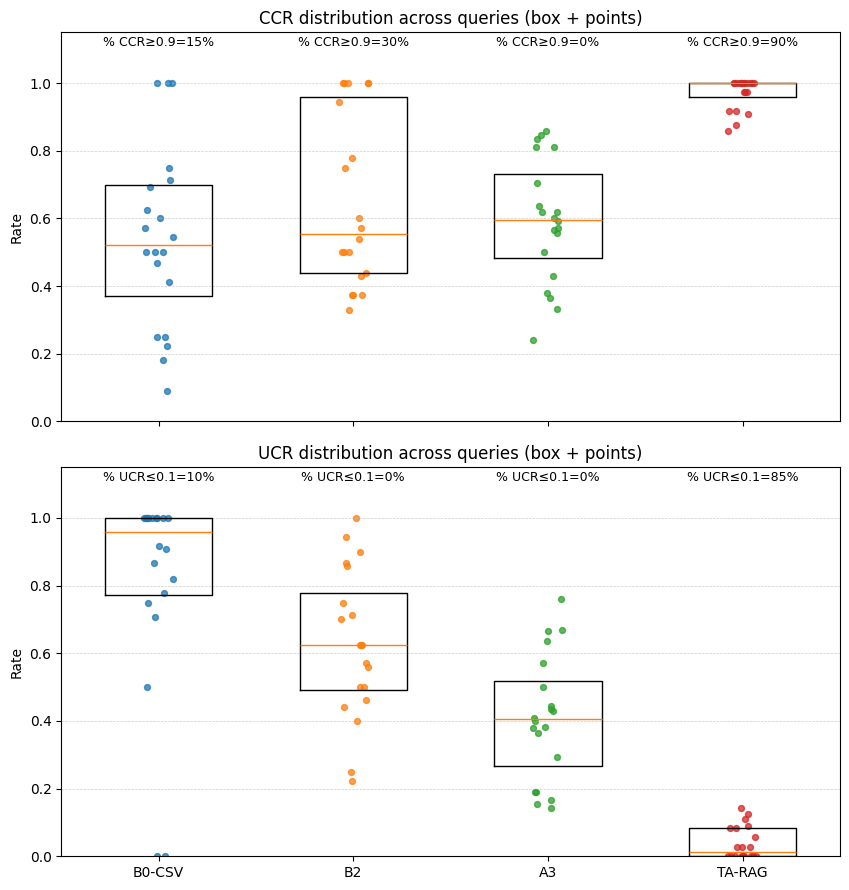

(<Figure size 860x900 with 2 Axes>,
 array([<Axes: title={'center': 'CCR distribution across queries (box + points)'}, ylabel='Rate'>,
        <Axes: title={'center': 'UCR distribution across queries (box + points)'}, ylabel='Rate'>],
       dtype=object))

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1) Build per-query dataframe
# =========================
# If you have qid -> aggregate to 1 row per (qid, system)
if "qid" in df.columns:
    df["qid"] = df["qid"].astype(str)
    df_perq = (
        df.groupby(["qid", "system"], as_index=False)
          .agg(CCR=("CCR", "mean"),
               UCR=("UCR", "mean"))
    )
    print("Detected qid: using per-query aggregation. Rows:", len(df_perq))
else:
    # Fallback: treat each row as a sample
    df_perq = df[["system", "CCR", "UCR"]].copy()
    print("No qid found: plotting per-row distribution. Rows:", len(df_perq))

# =========================
# 2) Plot: box (no whiskers) + jitter points + % thresholds
# =========================
def plot_ccr_ucr_boxpoints_with_threshold_rates(
    df_per_query,
    system_col="system",
    ccr_col="CCR",
    ucr_col="UCR",
    system_order=("B0-CSV", "B2", "A3", "TA-RAG"),
    ccr_thr=0.9,
    ucr_thr=0.1,
    jitter=0.08,
    point_size=18,
    alpha=0.75,
    figsize=(8.6, 9),
):
    d = df_per_query.copy()
    d[system_col] = d[system_col].astype(str)

    avail = set(d[system_col].unique().tolist())
    want = [s for s in system_order if s in avail]
    if len(want) == 0:
        raise ValueError(f"No systems matched system_order. Available systems: {sorted(avail)}")

    d = d[d[system_col].isin(want)].copy()
    d[system_col] = pd.Categorical(d[system_col], categories=want, ordered=True)
    d = d.sort_values(system_col)

    # arrays per system
    ccr_data = [d.loc[d[system_col] == s, ccr_col].astype(float).dropna().to_numpy() for s in want]
    ucr_data = [d.loc[d[system_col] == s, ucr_col].astype(float).dropna().to_numpy() for s in want]

    # percentages
    ccr_pct = [100.0 * np.mean(arr >= ccr_thr) if len(arr) else np.nan for arr in ccr_data]
    ucr_pct = [100.0 * np.mean(arr <= ucr_thr) if len(arr) else np.nan for arr in ucr_data]

    fig, axes = plt.subplots(2, 1, figsize=figsize, sharex=True)
    rng = np.random.default_rng(42)

    def draw(ax, data, title, pct_list, pct_prefix, ylim=(0, 1.15), pct_y=1.1):
        pos = np.arange(1, len(want) + 1)

        bp = ax.boxplot(
            data,
            positions=pos,
            widths=0.55,
            patch_artist=False,
            showfliers=False,
            whis=0,           # collapse whiskers
            showmeans=False   # no mean marker (triangle)
        )

        # hide whiskers and caps (strong guarantee)
        for w in bp.get("whiskers", []):
            w.set_visible(False)
        for c in bp.get("caps", []):
            c.set_visible(False)

        # scatter points
        for i, arr in enumerate(data, start=1):
            if len(arr) == 0:
                continue
            x = i + rng.uniform(-jitter, jitter, size=len(arr))
            ax.scatter(x, arr, s=point_size, alpha=alpha)

        # percentage text
        for i, pct in enumerate(pct_list, start=1):
            if np.isnan(pct):
                continue
            ax.text(i, pct_y, f"{pct_prefix}{pct:.0f}%",
                    ha="center", va="bottom", fontsize=9)

        ax.set_title(title)
        ax.set_ylabel("Rate")
        ax.set_ylim(*ylim)
        ax.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.6)

    draw(
        axes[0],
        ccr_data,
        "CCR distribution across queries (box + points)",
        ccr_pct,
        pct_prefix=f"% CCR≥{ccr_thr}=",
        ylim=(0, 1.15), pct_y=1.1
    )

    draw(
        axes[1],
        ucr_data,
        "UCR distribution across queries (box + points)",
        ucr_pct,
        pct_prefix=f"% UCR≤{ucr_thr}=",
        ylim=(0, 1.15), pct_y=1.1
    )

    axes[1].set_xticks(np.arange(1, len(want) + 1))
    axes[1].set_xticklabels(list(want))

    fig.tight_layout()
    plt.show()
    return fig, axes


# =========================
# 3) CALL
# =========================
plot_ccr_ucr_boxpoints_with_threshold_rates(
    df_per_query=df_perq,
    system_order=("B0-CSV", "B2", "A3", "TA-RAG"),
    ccr_thr=0.9,
    ucr_thr=0.1
)